# Imports

In [1]:
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

import aespm as ae


In [2]:
HAVE_AESPM  = True
import json

CONFIG = dict(
    # --- paths -----------------------------------------------------------
    data_folder = r"C:\Users\Asylum User\Documents\Asylum Research Data\260813\PZTO",
    work_dir    = "output",      # trajectories + logs live here

    # --- microscope / litho ------------------------------------------------
    DRY_RUN       = False,    # False at the microscope
    field_um      = 2.0,     # litho field size (square, corner origin)
    write_speed_ums = 1.0,   # tip speed during litho
    step_um       = 0.02,    # point spacing along trajectory (sets dose uniformity)
    travel_v      = 0.0,     # bias during repositioning strokes
    litho_margin_s = 10.0,   # extra wait after estimated litho duration

    # --- PFM readout ---------------------------------------------------------
    chan_height = 0, chan_amp = 1, chan_phase = 3,   # ibw channel indices (as in v1)
    scan_px     = 256,

    # --- material: PZTO(111), three easy axes at 120 deg --------------------
    # axis0_offset_deg is the lab-frame angle of the first easy axis;
    # you will refine it from the pristine stripe orientations / Session A.
    axis0_offset_deg = 0.0,
    n_variants  = 6,
    easy_axes_deg = None,    # filled below

    # --- switching physics (seed values; Session A refines) -----------------
    v_coercive_guess = 4.0,  # |V| onset (Checa: 4-6 V in PSTO; measure yours)
    v_write          = 6.0,
    # bias sign convention: +1 if positive tip bias selects the variant
    # PARALLEL to tip motion, -1 if anti-parallel (Balke-style). Session A decides.
    bias_sign_convention = -1,
    linewidth_um_guess   = 0.12,   # written track width (from first line tests)
)
CONFIG["easy_axes_deg"] = [CONFIG["axis0_offset_deg"] + k*60 for k in range(6)]
os.makedirs(CONFIG["work_dir"], exist_ok=True)
if not HAVE_AESPM:
    CONFIG["DRY_RUN"] = True
print(json.dumps({k: v for k, v in CONFIG.items() if k != "easy_axes_deg"}, indent=1))
print("easy axes:", CONFIG["easy_axes_deg"])

{
 "data_folder": "C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260813\\PZTO",
 "work_dir": "output",
 "DRY_RUN": false,
 "field_um": 2.0,
 "write_speed_ums": 1.0,
 "step_um": 0.02,
 "travel_v": 0.0,
 "litho_margin_s": 10.0,
 "chan_height": 0,
 "chan_amp": 1,
 "chan_phase": 3,
 "scan_px": 256,
 "axis0_offset_deg": 0.0,
 "n_variants": 6,
 "v_coercive_guess": 4.0,
 "v_write": 6.0,
 "bias_sign_convention": -1,
 "linewidth_um_guess": 0.12
}
easy axes: [0.0, 60.0, 120.0, 180.0, 240.0, 300.0]


# Create exp object

In [3]:

folder = r"C:\Users\Asylum User\Documents\Asylum Research Data\260813\PZTO"

exp = ae.Experiment(folder=folder)


In [14]:
## Commonly used custom functions

def load_ibw(self, folder="C:\\Users\\Asylum User\\Documents\\AEtesting\\data_exchange", lines=False):
    '''
    Read the latest ibw file saved in a given folder.
    '''
    fname = ae.get_files(path=self.folder, client=self.client)[0]
    return ae.tools.load_ibw(fname)

exp.add_func(load_ibw)

def read_meter(self):
    ae.write_spm(commands="GetMeter()", connection=self.connection)
    w = ae.ibw_read(r"C:\Users\Asylum User\Documents\buffer\Meter.ibw", lines=True, connection=self.connection)
    return w

exp.add_func(read_meter)

# def ramp_drive_setpoint(self, drive, setpoint):
#     commands='SetDriveAmpAndSetpoint({}, {})'.format(drive, setpoint)
#     ae.write_spm(commands=commands, connection=self.connection)
    
# exp.add_func(ramp_drive_setpoint)

# def check_files(self, wait=360):
#     '''
#     Check the number of files in the folder, with 50 s max waiting time.
#     '''
#     return ae.check_file_number(path=self.folder, retry=int(wait/0.1))

def check_files(self, max_wait=150):
    return ae.check_file_number(path=self.folder, wait=0.1, retry=int(max_wait/0.1))

exp.add_func(check_files)

# Pre-define trajectorylitho related functions

In [96]:
def generate_spiral_trajectory(
    turns=6,
    n_points=1200,
    k=1.0,
    offset=0.0,
    v_amplitude=8.0,
    v_offset=0.0,
    field_um=20.0,
    max_radius_um=None,
    filename="spiral_trajectory.txt",
    include_header=True,
    plot=True,
    constant_v=False
):
    """
    Build an Archimedean-spiral (x, y, V) trajectory and save it as a 3-column
    text file for the Igor TrajectoryLitho panel.

    Coordinates are written in METRES, corner origin (0..field), spiral centred
    at (field/2, field/2).  Voltage:  v_amplitude*sin(k*theta + offset) + v_offset.

    Parameters
    ----------
    turns         : full revolutions of the spiral.
    n_points      : number of points along the path.
    k             : angular-frequency multiplier inside the sine.
    offset        : phase offset (radians) inside the sine.
    v_amplitude   : sinusoid amplitude (V).
    v_offset      : DC offset added to the bias (V).
    field_um      : square litho field size in micrometres.
    max_radius_um : outer spiral radius (um). Default 0.95*field/2; must be <= field/2.
    filename      : output .txt path.
    include_header: write a commented header row.
    plot          : show an inline preview.

    Returns
    -------
    (x_m, y_m, v) numpy arrays.
    """
    field_m = field_um * 1e-6
    cx = cy = field_m / 2.0

    if max_radius_um is None:
        max_radius_m = 0.95 * field_m / 2.0
    else:
        max_radius_m = max_radius_um * 1e-6
        if max_radius_m > field_m / 2.0:
            raise ValueError(
                f"max_radius_um ({max_radius_um}) exceeds half the field "
                f"({field_um/2}); the spiral would fall outside the field."
            )

    theta = np.linspace(0.0, turns * 2.0 * np.pi, n_points)
    theta_max = turns * 2.0 * np.pi
    a = max_radius_m / theta_max if theta_max > 0 else 0.0
    r = a * theta

    x_m = cx + r * np.cos(theta)
    y_m = cy + r * np.sin(theta)
    if constant_v:
        v = v_amplitude * np.ones(len(theta))
    else:
        
        v   = v_amplitude * np.sin(k * theta + offset) + v_offset

    data = np.column_stack([x_m, y_m, v])
    header = "X_m\tY_m\tV" if include_header else ""
    np.savetxt(filename, data, delimiter="\t",
               header=header, comments="# ", fmt="%.10g")

    print(f"Wrote {n_points} points to '{filename}'")
    print(f"  field = {field_um} um, center = ({field_um/2}, {field_um/2}) um")
    print(f"  outer radius = {max_radius_m*1e6:.3f} um, turns = {turns}")
    print(f"  X range: [{x_m.min()*1e6:.3f}, {x_m.max()*1e6:.3f}] um")
    print(f"  Y range: [{y_m.min()*1e6:.3f}, {y_m.max()*1e6:.3f}] um")
    print(f"  V = {v_amplitude}*sin({k}*theta + {offset}) + {v_offset}")
    print(f"  V range: [{v.min():.3f}, {v.max():.3f}] V")

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
        sc = ax1.scatter(x_m*1e6, y_m*1e6, c=v, cmap="rainbow", s=6)
        ax1.add_patch(plt.Rectangle((0, 0), field_um, field_um,
                                    fill=False, ls="--", ec="k"))
        ax1.set_aspect("equal")
        ax1.set_xlabel("X (um)"); ax1.set_ylabel("Y (um)")
        ax1.set_title("Spiral trajectory (color = bias)")
        fig.colorbar(sc, ax=ax1, label="Bias (V)")

        ax2.plot(theta, v, lw=1)
        ax2.set_xlabel("theta (rad)"); ax2.set_ylabel("Bias (V)")
        ax2.set_title(f"V = {v_amplitude} sin({k} theta + {offset}) + {v_offset}")
        ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    return x_m, y_m, v

def visualize_trajectory(tb=None, x_m=None, y_m=None, v=None, *, filename=None,
                         field_um=None, title=None):
    """Same as v1, plus accepts a TrajectoryBuilder directly."""
    if tb is not None:
        x, y, v = tb.to_arrays(); x_m, y_m = x*1e-6, y*1e-6
        field_um = field_um or tb.field_um
    if filename is not None:
        d = np.loadtxt(filename); x_m, y_m, v = d[:,0], d[:,1], d[:,2]
        title = title or f"Trajectory from '{filename}'"
    x_um, y_um, v = np.asarray(x_m)*1e6, np.asarray(y_m)*1e6, np.asarray(v)
    finite = np.isfinite(x_um) & np.isfinite(y_um); idx = np.arange(len(x_um))
    fig = plt.figure(figsize=(13, 5.5)); gs = fig.add_gridspec(2,2,width_ratios=[1.3,1])
    ax0 = fig.add_subplot(gs[:,0])
    sc = ax0.scatter(x_um[finite], y_um[finite], c=v[finite], cmap="rainbow", s=6, zorder=3)
    ax0.plot(x_um, y_um, color="0.8", lw=.5, zorder=1)
    f = idx[finite]
    if len(f):
        ax0.scatter([x_um[f[0]]],[y_um[f[0]]],s=120,marker="o",facecolors="none",
                    edgecolors="g",lw=2,zorder=4,label="start")
        ax0.scatter([x_um[f[-1]]],[y_um[f[-1]]],s=120,marker="s",facecolors="none",
                    edgecolors="r",lw=2,zorder=4,label="end")
    fu = field_um or CONFIG["field_um"]
    ax0.add_patch(plt.Rectangle((0,0), fu, fu, fill=False, ls="--", ec="k"))
    ax0.set_aspect("equal"); ax0.set_xlabel("X (um)"); ax0.set_ylabel("Y (um)")
    ax0.set_title(title or "Trajectory (color = bias)"); ax0.legend(fontsize=8)
    fig.colorbar(sc, ax=ax0, label="Bias (V)", fraction=.046, pad=.04)
    ax1 = fig.add_subplot(gs[0,1]); ax1.plot(idx, v, lw=1)
    ax1.set_xlabel("point index"); ax1.set_ylabel("Bias (V)"); ax1.grid(alpha=.3)
    ax2 = fig.add_subplot(gs[1,1])
    step = np.hypot(np.diff(x_um), np.diff(y_um))
    ax2.plot(step, lw=1, color="C1"); ax2.set_xlabel("point index")
    ax2.set_ylabel("step (um)"); ax2.grid(alpha=.3)
    plt.tight_layout(); plt.show()
    


In [97]:
# [LIB-BUILDER]  defines TrajectoryBuilder / resample_constant_step
# ----------------------------------------------------------------------
# Low-level helpers
# ----------------------------------------------------------------------
def resample_constant_step(x_um, y_um, v, step_um):
    """Resample a polyline to constant arc-length step.

    The TL panel steps through points at a fixed rate, so constant point
    spacing => constant tip speed and constant bias dose per unit length.
    """
    x_um, y_um, v = map(np.asarray, (x_um, y_um, v))
    d = np.hypot(np.diff(x_um), np.diff(y_um))
    s = np.concatenate([[0.0], np.cumsum(d)])
    if s[-1] == 0:
        return x_um[:1], y_um[:1], np.atleast_1d(v)[:1]
    n = max(2, int(np.ceil(s[-1] / step_um)) + 1)
    si = np.linspace(0, s[-1], n)
    return (np.interp(si, s, x_um), np.interp(si, s, y_um),
            np.interp(si, s, np.broadcast_to(v, x_um.shape)))


class TrajectoryBuilder:
    """Accumulate biased strokes; insert zero-bias travel moves between them.

    All coordinates in micrometres, corner origin (0..field_um), matching the
    convention of generate_spiral_trajectory in the original notebook.
    """

    def __init__(self, field_um=20.0, step_um=0.02, travel_v=0.0,
                 nan_breaks=False):
        self.field_um = field_um
        self.step_um = step_um
        self.travel_v = travel_v   # bias during repositioning (keep 0!)
        self.nan_breaks = nan_breaks  # PLACEHOLDER: only if TL supports NaN pen-up
        self._segs = []            # list of (x_um, y_um, v) arrays

    def stroke(self, pts_um, v):
        """Add a biased stroke. pts_um: (N,2) array; v: scalar or (N,) array."""
        pts_um = np.asarray(pts_um, float)
        x, y = pts_um[:, 0], pts_um[:, 1]
        x, y, vv = resample_constant_step(x, y, v, self.step_um)
        self._segs.append((x, y, vv))
        return self

    def to_arrays(self):
        """Concatenate strokes, inserting travel moves at travel_v."""
        xs, ys, vs = [], [], []
        for i, (x, y, v) in enumerate(self._segs):
            if i > 0:
                if self.nan_breaks:
                    xs.append([np.nan]); ys.append([np.nan]); vs.append([np.nan])
                else:
                    x0, y0 = xs[-1][-1], ys[-1][-1]
                    tx, ty, tv = resample_constant_step(
                        [x0, x[0]], [y0, y[0]], self.travel_v, self.step_um)
                    xs.append(tx); ys.append(ty); vs.append(tv)
            xs.append(x); ys.append(y); vs.append(v)
        return (np.concatenate(xs), np.concatenate(ys), np.concatenate(vs))

    def save(self, filename, include_header=True):
        x_um, y_um, v = self.to_arrays()
        data = np.column_stack([x_um * 1e-6, y_um * 1e-6, v])
        header = "X_m\tY_m\tV" if include_header else ""
        np.savetxt(filename, data, delimiter="\t", header=header,
                   comments="# ", fmt="%.10g")
        finite = np.isfinite(x_um)
        d = np.hypot(np.diff(x_um[finite]), np.diff(y_um[finite]))
        print(f"Wrote {len(x_um)} pts to '{filename}'  "
              f"(path length {np.nansum(d):.1f} um, "
              f"{len(self._segs)} strokes)")
        return x_um * 1e-6, y_um * 1e-6, v

    def path_length_um(self):
        x, y, _ = self.to_arrays()
        m = np.isfinite(x)
        return float(np.nansum(np.hypot(np.diff(x[m]), np.diff(y[m]))))

In [98]:
# [LIB-LINEPATCH]  defines gen_line_patch / gen_sign_pitch_test
import numpy as np

# ----------------------------------------------------------------------
# FIX 1 — true stationary dwells (bypass arc-length resampling)
# ----------------------------------------------------------------------
def _dwell(self, xy_um, v, n=10):
    """Append n stationary points at xy_um, held at bias v.

    Deliberately bypasses resample_constant_step(): a stationary polyline has
    zero arc length, so that function collapses it to a single point and the
    bias-settle hold is lost.
    """
    if n <= 0:
        return self
    n = int(n)
    self._segs.append((np.full(n, float(xy_um[0])),
                       np.full(n, float(xy_um[1])),
                       np.full(n, float(v))))
    return self

TrajectoryBuilder.dwell = _dwell


# ----------------------------------------------------------------------
# FIX 2 — run-time estimate that counts dwell points
# ----------------------------------------------------------------------
def eta_s(tb, speed_ums, step_um=None, margin_s=10.0):
    """The TL panel steps points at a fixed rate R = speed/step, so run time is
    set by the POINT COUNT, not the path length."""
    x, _, _ = tb.to_arrays()
    step = tb.step_um if step_um is None else step_um
    return len(x) * step / speed_ums + margin_s


# ----------------------------------------------------------------------
# One patch of parallel lines: explicit pitch, selectable bias scheme
# ----------------------------------------------------------------------
def gen_line_patch(center_um, size_um=1.6, pitch_um=0.10, angle_deg=60.0,
                   scheme="bipolar", v=6.0, tb=None, field_um=7.0,
                   step_um=0.02, n_pt=10, travel_v=0.0):
    """Square patch of parallel strokes at fixed PITCH (not fixed row count).

    Pitch is the variable the sign/pitch test needs, so it is set directly in um
    rather than implied by n_rows/side as in gen_raster_backward.

    scheme
      "bipolar"     : forward +|v|, backward -|v|          (current design rule 2)
      "constant"    : forward +|v|, backward +|v|
      "alternating" : both passes of row k at +|v| (k even) or -|v| (k odd);
                      every individual stroke is unipolar, sign flips row to row
      "serpentine"  : ONE traversal per row at +|v|, direction alternating.
                      No retrace at all - the back-scan-free control.

    A settle dwell of n_pt points at the NEW voltage is inserted before every
    stroke whose bias differs from the previous one.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um,
                                 travel_v=travel_v)
    cx, cy = center_um
    th = np.deg2rad(angle_deg)
    c, s = np.cos(th), np.sin(th)
    half = size_um / 2.0

    n_rows = max(1, int(round(size_um / pitch_um)) + 1)
    lys = np.linspace(-half, half, n_rows) if n_rows > 1 else np.array([0.0])
    ends = np.array([-half, half])          # 2 endpoints; stroke() resamples

    def to_world(lx, ly):
        return cx + lx * c - ly * s, cy + lx * s + ly * c

    for k, ly in enumerate(lys):
        row = np.full(2, ly, float)

        if scheme == "serpentine":
            lx = ends if k % 2 == 0 else ends[::-1]
            wx, wy = to_world(lx, row)
            tb.dwell((wx[0], wy[0]), v, n_pt)
            tb.stroke(np.column_stack([wx, wy]), np.full(2, abs(v), float))
            continue

        if scheme == "bipolar":
            v_f, v_b = +abs(v), -abs(v)
        elif scheme == "constant":
            v_f = v_b = +abs(v)
        elif scheme == "alternating":
            v_f = v_b = (+abs(v) if k % 2 == 0 else -abs(v))
        else:
            raise ValueError(f"unknown scheme {scheme!r}")

        fx, fy = to_world(ends, row)
        tb.dwell((fx[0], fy[0]), v_f, n_pt)                     # settle to v_f
        tb.stroke(np.column_stack([fx, fy]), np.full(2, v_f, float))

        if v_b != v_f:
            tb.dwell((fx[-1], fy[-1]), v_b, n_pt)               # settle to v_b
        bx, by = to_world(ends[::-1], row)
        tb.stroke(np.column_stack([bx, by]), np.full(2, v_b, float))

    return tb, n_rows


# ----------------------------------------------------------------------
# Session 1 sign/pitch test: four patches, four separate files
# ----------------------------------------------------------------------
def gen_sign_pitch_test(center_um=(3.5, 3.5), size_um=1.6, gap_um=0.8,
                        angle_deg=60.0, v=6.0,
                        pitch_dense_um=0.10, pitch_sparse_um=0.40,
                        field_um=7.0, step_um=0.02, n_pt=10,
                        work_dir=None, prefix="s1"):
    """Four 1-patch trajectory files laid out on a 2x2 grid in one area.

    Separate files on purpose: a single combined file would insert ~3 um
    zero-bias TRAVEL strokes between patches, straight across the unwritten
    reference regions - and a grounded pass is a write event. Four short runs
    with the tip engaged removes that confound entirely.

    Patch assignment (P1/P2 adjacent so the pitch comparison at fixed scheme
    carries the least spatial confound):
      P1  sparse  constant     reinforcement without adjacent-line cancellation
      P2  dense   constant     adjacent-line cancellation
      P3  dense   bipolar      what design rule 2 predicts is best
      P4  sparse  alternating  what the perpendicular-impulse rule predicts is best
    """
    work_dir = work_dir or CONFIG["work_dir"]
    th = np.deg2rad(angle_deg)
    bbox = size_um * (abs(np.cos(th)) + abs(np.sin(th)))   # rotated square bbox
    d = (bbox + gap_um) / 2.0
    cx, cy = center_um

    spec = [
        ("P1", (cx - d, cy - d), pitch_sparse_um, "constant"),
        ("P2", (cx + d, cy - d), pitch_dense_um,  "constant"),
        ("P3", (cx - d, cy + d), pitch_dense_um,  "bipolar"),
        ("P4", (cx + d, cy + d), pitch_sparse_um, "alternating"),
    ]

    manifest, combined = [], TrajectoryBuilder(field_um=field_um, step_um=step_um)
    for label, ctr, pitch, scheme in spec:
        tb, n_rows = gen_line_patch(ctr, size_um=size_um, pitch_um=pitch,
                                    angle_deg=angle_deg, scheme=scheme, v=v,
                                    field_um=field_um, step_um=step_um, n_pt=n_pt)
        fn = os.path.join(work_dir, f"{prefix}_{label}_{scheme}_p{pitch*1000:.0f}nm.txt")
        tb.save(fn)
        combined._segs.extend(tb._segs)                  # preview only
        manifest.append(dict(label=label, file=fn, center_um=ctr, pitch_um=pitch,
                             scheme=scheme, n_rows=n_rows,
                             n_pts=len(tb.to_arrays()[0]),
                             eta_s=eta_s(tb, 1.0)))

    print(f"\nangle {angle_deg} deg | patch {size_um} um | rotated bbox {bbox:.2f} um "
          f"| centre spacing {2*d:.2f} um | edge gap {gap_um} um")
    print(f"pattern extent {cx-d-bbox/2:.2f} to {cx+d+bbox/2:.2f} um\n")
    for m in manifest:
        print(f"  {m['label']}  {m['scheme']:11s} pitch {m['pitch_um']*1000:4.0f} nm  "
              f"{m['n_rows']:3d} lines  {m['n_pts']:6d} pts  "
              f"ETA {m['eta_s']:5.0f} s @1 um/s  centre {m['center_um']}")
    print(f"\n  total ETA {sum(m['eta_s'] for m in manifest):.0f} s")
    return manifest, combined


In [99]:
# FIX 3 - do not inject a travel point when there is no gap to travel
def _to_arrays(self):
    xs, ys, vs = [], [], []
    for i, (x, y, v) in enumerate(self._segs):
        if i > 0:
            x0, y0 = xs[-1][-1], ys[-1][-1]
            if self.nan_breaks:
                xs.append([np.nan]); ys.append([np.nan]); vs.append([np.nan])
            elif np.hypot(x[0] - x0, y[0] - y0) > 1e-9:      # only if there IS a gap
                tx, ty, tv = resample_constant_step([x0, x[0]], [y0, y[0]],
                                                    self.travel_v, self.step_um)
                xs.append(tx); ys.append(ty); vs.append(tv)
        xs.append(x); ys.append(y); vs.append(v)
    return (np.concatenate(xs), np.concatenate(ys), np.concatenate(vs))

TrajectoryBuilder.to_arrays = _to_arrays

In [100]:
def audit_trajectories(manifest, field_um=7.0, scan_um=None, expect_pitch_um=None,
                       zoom_label=None):
    """Read saved trajectory files back and verify geometry, angle, pitch, bias, bounds."""
    import matplotlib.pyplot as plt
    rows, data = [], {}
    for m in manifest:
        d = np.loadtxt(m["file"]); x, y, v = d[:,0]*1e6, d[:,1]*1e6, d[:,2]
        data[m["label"]] = (x, y, v)
        b = v != 0
        dx, dy = np.diff(x), np.diff(y)
        L = np.hypot(dx, dy)
        mv = L > 1e-9                                    # moving points only
        step_med = np.median(L[mv])
        onstep = mv & (np.abs(L - step_med) < 0.25*step_med)   # exclude travels
        # axial mean of step direction -> stroke director mod 180
        z = np.mean(np.exp(2j*np.arctan2(dy[onstep], dx[onstep])))
        th_meas = np.mod(np.rad2deg(np.angle(z))/2, 180)
        # pitch: cluster the perpendicular coordinate of biased points
        t = np.deg2rad(th_meas)
        perp = np.sort(-x[b]*np.sin(t) + y[b]*np.cos(t))
        cuts = np.where(np.diff(perp) > 0.3*(expect_pitch_um or 0.1))[0]
        centres = [seg.mean() for seg in np.split(perp, cuts+1) if len(seg) > 3]
        pitch = np.median(np.diff(centres)) if len(centres) > 1 else np.nan
        rows.append(dict(label=m["label"], want_th=m["angle"], got_th=th_meas,
                         nlines=len(centres), pitch=pitch, step=step_med,
                         npts=len(x), fpos=(v > 0).mean(), fneg=(v < 0).mean(),
                         fzero=(v == 0).mean(), ndwell=int((L < 1e-9).sum()),
                         xmin=x.min(), xmax=x.max(), ymin=y.min(), ymax=y.max(),
                         order=m["write_order"]))

    print(f"{'patch':8s}{'ord':>4s}{'th want':>8s}{'th got':>7s}{'d':>5s}"
          f"{'lines':>6s}{'pitch':>7s}{'step':>6s}{'dwell':>6s}"
          f"{'%+V':>6s}{'%-V':>6s}{'%0V':>6s}{'  X range':>16s}{'  Y range':>16s}")
    for r in rows:
        d = (r['got_th'] - r['want_th'] + 90) % 180 - 90
        flag = "" if abs(d) < 1.0 else "  <-- ANGLE"
        oob  = " OUT OF BOUNDS" if min(r['xmin'], r['ymin']) < 0 or \
                                  max(r['xmax'], r['ymax']) > field_um else ""
        print(f"{r['label']:8s}{r['order']:>4d}{r['want_th']:8.0f}{r['got_th']:7.1f}{d:+5.1f}"
              f"{r['nlines']:6d}{r['pitch']*1000:7.0f}{r['step']*1000:6.0f}{r['ndwell']:6d}"
              f"{100*r['fpos']:6.1f}{100*r['fneg']:6.1f}{100*r['fzero']:6.1f}"
              f"  [{r['xmin']:5.2f},{r['xmax']:5.2f}]  [{r['ymin']:5.2f},{r['ymax']:5.2f}]"
              f"{flag}{oob}")

    # pairwise overlap on a 20 nm occupancy grid
    G, cell = {}, 0.02
    for lab,(x,y,v) in data.items():
        G[lab] = set(zip((x[v!=0]/cell).astype(int), (y[v!=0]/cell).astype(int)))
    labs = list(G)
    bad = [(a,b,len(G[a] & G[b])) for i,a in enumerate(labs) for b in labs[i+1:]
           if G[a] & G[b]]
    print("\noverlap between patches:", "none" if not bad else bad)

    # ---- figure ----
    fig = plt.figure(figsize=(15, 6.2))
    gs  = fig.add_gridspec(2, 3, width_ratios=[1.5, 1, 1])
    ax  = fig.add_subplot(gs[:, 0])
    for lab,(x,y,v) in data.items():
        for sel, c, s in [(v > 0, 'tab:red', 4), (v < 0, 'tab:blue', 4),
                          (v == 0, '0.75', 2)]:
            ax.scatter(x[sel], y[sel], s=s, c=c, lw=0)
        r = next(q for q in rows if q['label'] == lab)
        ax.text(x[v!=0].mean(), y[v!=0].mean(), f"{lab}\n{r['got_th']:.0f}$\\degree$\n#{r['order']}",
                ha='center', va='center', fontsize=9, fontweight='bold',
                bbox=dict(fc='w', alpha=.75, lw=0))
    ax.add_patch(plt.Rectangle((0,0), field_um, field_um, fill=False, ls='--', ec='k'))
    if scan_um:
        c0 = field_um/2
        ax.add_patch(plt.Rectangle((c0-scan_um/2, c0-scan_um/2), scan_um, scan_um,
                                   fill=False, ls=':', ec='g', lw=2, label='scan frame'))
        ax.legend(fontsize=8, loc='upper right')
    ax.set_aspect('equal'); ax.set_xlabel('X (um)'); ax.set_ylabel('Y (um)')
    ax.set_title('all patches  (red +V, blue -V, grey travel)  label = measured angle, #write order')

    zl = zoom_label or rows[0]['label']
    x, y, v = data[zl]
    k = slice(0, min(900, len(x)))
    a1 = fig.add_subplot(gs[0, 1])
    a1.plot(x[k], y[k], '-', c='0.8', lw=.6)
    a1.scatter(x[k][v[k] > 0], y[k][v[k] > 0], s=9, c='tab:red', label='+V')
    a1.scatter(x[k][v[k] < 0], y[k][v[k] < 0], s=9, c='tab:blue', label='-V')
    a1.scatter(x[k][v[k] == 0], y[k][v[k] == 0], s=9, c='0.6', label='0 V')
    a1.set_aspect('equal'); a1.legend(fontsize=7); a1.set_title(f'{zl}: first lines', fontsize=9)
    a2 = fig.add_subplot(gs[1, 1]); a2.plot(v[k], lw=.9)
    a2.set_title('bias along path', fontsize=9); a2.grid(alpha=.3); a2.set_xlabel('point index')
    a3 = fig.add_subplot(gs[0, 2])
    a3.plot(np.hypot(np.diff(x[k]), np.diff(y[k]))*1000, lw=.9, c='tab:orange')
    a3.set_title('step (nm) - zeros are dwells', fontsize=9); a3.grid(alpha=.3)
    a4 = fig.add_subplot(gs[1, 2])
    a4.bar([r['label'] for r in rows], [r['got_th'] for r in rows], color='tab:green')
    a4.plot([r['label'] for r in rows], [r['want_th'] for r in rows], 'k_', ms=18, mew=2)
    a4.set_title('measured (bar) vs requested (tick) angle', fontsize=9)
    a4.tick_params(axis='x', rotation=60, labelsize=7)
    plt.tight_layout(); plt.show()
    return rows



In [101]:
def check_bounds(tb, field_um=None):
    x, y, _ = tb.to_arrays()
    f = tb.field_um if field_um is None else field_um
    bad = (x < 0) | (x > f) | (y < 0) | (y > f)
    print(f"extent  X [{np.nanmin(x):.3f}, {np.nanmax(x):.3f}]   "
          f"Y [{np.nanmin(y):.3f}, {np.nanmax(y):.3f}]   field {f} um")
    if bad.any():
        raise ValueError(f"{bad.sum()} of {len(x)} points outside 0..{f} um - "
                         "raise center_um or shrink size_um/gap_um")
    return True



In [102]:
# [LIB-ALTSQ]  defines gen_alternating_square
# ---------------------------------------------------------------------
# Prerequisites (idempotent - safe to re-run)
# ---------------------------------------------------------------------
def _dwell(self, xy_um, v, n=10):
    """Stationary bias-settle points. Bypasses resample_constant_step, which
    collapses a zero-length polyline to a single point."""
    if n <= 0:
        return self
    n = int(n)
    self._segs.append((np.full(n, float(xy_um[0])),
                       np.full(n, float(xy_um[1])),
                       np.full(n, float(v))))
    return self
TrajectoryBuilder.dwell = _dwell


def _to_arrays(self):
    """As original, but no travel point is injected when there is no gap to
    travel - that stray 0 V sample was chopping the bias between passes."""
    xs, ys, vs = [], [], []
    for i, (x, y, v) in enumerate(self._segs):
        if i > 0:
            x0, y0 = xs[-1][-1], ys[-1][-1]
            if self.nan_breaks:
                xs.append([np.nan]); ys.append([np.nan]); vs.append([np.nan])
            elif np.hypot(x[0] - x0, y[0] - y0) > 1e-9:
                tx, ty, tv = resample_constant_step([x0, x[0]], [y0, y[0]],
                                                    self.travel_v, self.step_um)
                xs.append(tx); ys.append(ty); vs.append(tv)
        xs.append(x); ys.append(y); vs.append(v)
    return (np.concatenate(xs), np.concatenate(ys), np.concatenate(vs))
TrajectoryBuilder.to_arrays = _to_arrays


# ---------------------------------------------------------------------
def gen_alternating_square(size_um=3.0, pitch_um=0.10, angle_deg=30.0,
                           center_um=(2.5, 2.5), v=6.0, field_um=5.0,
                           step_um=0.02, n_pt=10, start_sign=+1,
                           alt_period=1, n_cycles=1, flip_each_cycle=False,
                           tb=None, travel_v=0.0, verbose=True):
    """Square raster at an arbitrary angle whose per-line bias phase alternates.

    Line 1:  forward +V, backward -V
    Line 2:  forward -V, backward +V
    Line 3:  forward +V, backward -V   ...

    Every point still sees both polarities, so both C3v orbits stay reachable,
    but the polarity that lands LAST alternates row to row, so the region never
    closes into a single orbit. That is the difference from the S1 P3 recipe,
    which ended every line at -V and came out as a uniform out-of-plane block
    (switched fraction 0.009) with the in-plane state frozen.

    size_um     side of the square, in the rotated frame
    pitch_um    line spacing
    angle_deg   line direction, CCW from +x
    v           magnitude; sign is assigned per pass
    alt_period  consecutive lines sharing one phase before flipping.
                1 = flip every line (as specified). 2 or 3 coarsens the
                out-of-plane modulation while keeping the area unpoled.
    n_cycles    repeats of the whole pattern
    flip_each_cycle  invert the phase pattern on alternate cycles
    n_pt        stationary settle points inserted at every voltage change

    Returns the TrajectoryBuilder.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um,
                                 travel_v=travel_v)
    cx, cy = center_um
    th = np.deg2rad(angle_deg)
    c, s = np.cos(th), np.sin(th)
    half = size_um / 2.0
    vmag = abs(float(v))
    alt = max(1, int(alt_period))

    n_rows = max(1, int(round(size_um / pitch_um)) + 1)
    lys = np.linspace(-half, half, n_rows) if n_rows > 1 else np.array([0.0])
    ends = np.array([-half, half])

    def to_world(lx, ly):
        return cx + lx * c - ly * s, cy + lx * s + ly * c

    first_pass = []
    for cyc in range(max(1, int(n_cycles))):
        flip = -1 if (flip_each_cycle and cyc % 2) else 1
        for k, ly in enumerate(lys):
            sgn = start_sign * flip * (1 if (k // alt) % 2 == 0 else -1)
            v_f, v_b = sgn * vmag, -sgn * vmag
            row = np.full(2, ly, float)

            fx, fy = to_world(ends, row)
            tb.dwell((fx[0], fy[0]), v_f, n_pt)                  # settle to v_f
            tb.stroke(np.column_stack([fx, fy]), np.full(2, v_f, float))

            tb.dwell((fx[-1], fy[-1]), v_b, n_pt)                # settle to v_b
            bx, by = to_world(ends[::-1], row)
            tb.stroke(np.column_stack([bx, by]), np.full(2, v_b, float))

            if cyc == 0:
                first_pass.append(int(np.sign(v_f)))

    if verbose:
        x, y, vv = tb.to_arrays()
        x, y = x * 1e6, y * 1e6
        bbox = size_um * (abs(c) + abs(s))
        d = np.hypot(np.diff(x), np.diff(y))
        pos = float(np.sum(d[(vv[1:] > 0)])); neg = float(np.sum(d[(vv[1:] < 0)]))
        print(f"alternating square: {angle_deg:.0f} deg, {size_um} um, pitch "
              f"{pitch_um*1000:.0f} nm, {n_rows} lines x {n_cycles} cycle(s)")
        print(f"  first-pass polarity by line: "
              f"{''.join('+' if p > 0 else '-' for p in first_pass)}")
        print(f"  last-pass  polarity by line: "
              f"{''.join('-' if p > 0 else '+' for p in first_pass)}   <- alternates")
        print(f"  biased path: {pos:.1f} um at +V, {neg:.1f} um at -V  "
              f"(imbalance {200*abs(pos-neg)/(pos+neg+1e-9):.2f} %)")
        print(f"  {len(x)} pts, {100*(vv == 0).mean():.1f} % at 0 V (inter-row travel)")
        print(f"  rotated bbox {bbox:.3f} um   extent X[{x.min():.3f}, {x.max():.3f}] "
              f"Y[{y.min():.3f}, {y.max():.3f}]  field {field_um} um")
#         for sp in (0.25, 0.5, 1.0, 2.0):
#             print(f"    ETA @{sp:>4} um/s: {len(x)*step_um/sp:6.0f} s")
#         if x.min() < 0 or y.min() < 0 or x.max() > field_um or y.max() > field_um:
#             raise ValueError("OUT OF BOUNDS - shrink size_um or move center_um")
    return tb

In [103]:
# [LIB-CENTEROUT]  defines gen_center_out_raster
# ---------------------------------------------------------------------
# Prerequisites (idempotent - safe to re-run)
# ---------------------------------------------------------------------
def _dwell(self, xy_um, v, n=10):
    """Stationary bias-settle points; bypasses resample_constant_step, which
    collapses a zero-length polyline to one point."""
    if n <= 0:
        return self
    n = int(n)
    self._segs.append((np.full(n, float(xy_um[0])),
                       np.full(n, float(xy_um[1])),
                       np.full(n, float(v))))
    return self
TrajectoryBuilder.dwell = _dwell


def _to_arrays(self):
    """No travel point injected when there is no gap to travel."""
    xs, ys, vs = [], [], []
    for i, (x, y, v) in enumerate(self._segs):
        if i > 0:
            x0, y0 = xs[-1][-1], ys[-1][-1]
            if self.nan_breaks:
                xs.append([np.nan]); ys.append([np.nan]); vs.append([np.nan])
            elif np.hypot(x[0] - x0, y[0] - y0) > 1e-9:
                tx, ty, tv = resample_constant_step([x0, x[0]], [y0, y[0]],
                                                    self.travel_v, self.step_um)
                xs.append(tx); ys.append(ty); vs.append(tv)
        xs.append(x); ys.append(y); vs.append(v)
    return (np.concatenate(xs), np.concatenate(ys), np.concatenate(vs))
TrajectoryBuilder.to_arrays = _to_arrays


# ---------------------------------------------------------------------
def gen_center_out_raster(W_um=3.0, H_um=3.0, pitch_um=0.35, angle_deg=90.0,
                          center_um=(2.5, 2.5), v=6.0, h_inner_um=0.0,
                          flip_each_cycle=True, within_cycle='same',
                          field_um=5.0, step_um=0.02, n_pt=10,
                          tb=None, travel_v=0.0, verbose=True,
                          start_sign=+1, alt_period=1):
    """W x H raster at an arbitrary angle that grows outward from the centre.

    One CYCLE = one full traverse along +W at separation +y_k from the centre
    line, then one full traverse along -W at -y_k. The separation y_k grows by
    pitch_um each cycle until the pair reaches +-H/2, so the written region
    expands symmetrically from the centre outward.

        cycle 0:  +W at +0.5*pitch      -W at -0.5*pitch
        cycle 1:  +W at +1.5*pitch      -W at -1.5*pitch
        ...

    Line spacing is uniform at pitch_um across the whole rectangle.

    W_um, H_um      rectangle dimensions in the rotated frame (W along the
                    stroke direction, H across it)
    pitch_um        increment of the separation per cycle = the line spacing
    angle_deg       stroke direction, CCW from +x
    h_inner_um      start the growth at this separation instead of 0, i.e.
                    write only the annulus from h_inner_um to H_um. Use this
                    to add a ring without re-dosing the centre
    v               magnitude; sign assigned per cycle / per pass
    flip_each_cycle invert the bias between neighbouring full cycles
    within_cycle    'same'    both passes of a cycle share one sign
                    'bipolar' forward +, backward - within each cycle
    n_pt            stationary settle points at each voltage change
    start_sign      +1 or -1: the polarity of the FIRST cycle. NOTE that the
                    sign of `v` itself is discarded (vmag = abs(v)), so before
                    this parameter existed there was no way to choose the
                    starting polarity - v = -7 and v = +7 produced byte-identical
                    files. Every write up to 14 August therefore started at +V
                    regardless of what was passed.
    alt_period      how many consecutive CYCLES share one polarity before it
                    flips. This sets the length scale over which the vertical
                    field is coherent:

                        polarity period = 2 * alt_period * pitch_um

                    At the default alt_period = 1 with a 20 nm pitch that is
                    40 nm, against a lamellar period Lambda of ~325 nm. So each
                    superdomain spans about eight polarity reversals and sees a
                    near-zero MEAN vertical field - which is a candidate reason
                    why every write so far disorders the in-plane orientation
                    instead of rotating it between triad members. Setting
                    alt_period so the polarity period is comparable to Lambda
                    gives each domain a coherent field of one sign.

                    Choose alt_period so that n_cycles / alt_period is EVEN, or
                    the write carries a net DC and will re-pole the area.

    Returns the TrajectoryBuilder.
    """
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um,
                                 travel_v=travel_v)
    cx, cy = center_um
    th = np.deg2rad(angle_deg)
    c, s = np.cos(th), np.sin(th)
    vmag = abs(float(v))
    hw = W_um / 2.0

    n_cyc = max(1, int(round((H_um - h_inner_um) / (2.0 * pitch_um))))
    ys = h_inner_um / 2.0 + (np.arange(n_cyc) + 0.5) * pitch_um

    def to_world(u, w):
        return cx + u * c - w * s, cy + u * s + w * c

    alt = max(1, int(alt_period))
    if verbose and v < 0:
        print('  note: sign of v is ignored (vmag = abs(v)); use start_sign')
    pol = []
    for k, y in enumerate(ys):
        sgn = (start_sign * (1 if (k // alt) % 2 == 0 else -1)
               if flip_each_cycle else start_sign)
        if within_cycle == 'bipolar':
            v_f, v_b = sgn * vmag, -sgn * vmag
        elif within_cycle == 'same':
            v_f = v_b = sgn * vmag
        else:
            raise ValueError("within_cycle must be 'same' or 'bipolar'")
        pol.append((v_f, v_b))

        # forward: -W/2 -> +W/2 at +y
        fx, fy = to_world(np.array([-hw, hw]), np.array([y, y]))
        tb.dwell((fx[0], fy[0]), v_f, n_pt)
        tb.stroke(np.column_stack([fx, fy]), np.full(2, v_f, float))

        # backward: +W/2 -> -W/2 at -y
        bx, by = to_world(np.array([hw, -hw]), np.array([-y, -y]))
        if v_b != v_f:
            tb.dwell((bx[0], by[0]), v_b, n_pt)
        tb.stroke(np.column_stack([bx, by]), np.full(2, v_b, float))

    if verbose:
        x, y, vv = tb.to_arrays(); x, y = x * 1e6, y * 1e6
        d = np.hypot(np.diff(x), np.diff(y))
        pos = float(np.sum(d[vv[1:] > 0])); neg = float(np.sum(d[vv[1:] < 0]))
        ex = (W_um * abs(c) + H_um * abs(s)) / 2.0
        ey = (W_um * abs(s) + H_um * abs(c)) / 2.0
        print(f"centre-out raster: {W_um} x {H_um} um at {angle_deg:.0f} deg, "
              f"pitch {pitch_um*1000:.0f} nm")
        print(f"  {n_cyc} cycles = {2*n_cyc} lines; separation "
              f"{2*ys[0]*1000:.0f} -> {2*ys[-1]*1000:.0f} nm"
              + (f" (inner {h_inner_um} um skipped)" if h_inner_um else ""))
        print(f"  polarity period {2*alt*pitch_um*1000:.0f} nm "
              f"(alt_period {alt} cycles), start_sign {start_sign:+d}")
        if flip_each_cycle and (n_cyc // alt) % 2:
            print(f"  *** {n_cyc} cycles / alt_period {alt} = "
                  f"{n_cyc/alt:.2f} blocks: ODD, so this write carries a NET DC "
                  f"and will re-pole. Pick alt_period dividing {n_cyc} evenly "
                  f"with an even quotient. ***")
        print(f"  cycle polarity (fwd/bwd): "
              + " ".join(f"{'+' if a>0 else '-'}{'+' if b>0 else '-'}"
                         for a, b in pol[:12]) + (" ..." if n_cyc > 12 else ""))
        print(f"  biased path {pos:.1f} um at +V, {neg:.1f} um at -V  "
              f"(net DC imbalance {200*abs(pos-neg)/(pos+neg+1e-9):.2f} %)")
        print(f"  {len(x)} pts, {100*(vv == 0).mean():.1f} % at 0 V (edge travel)")
        print(f"  rotated half-extent {ex:.3f} x {ey:.3f} um   "
              f"X[{x.min():.3f}, {x.max():.3f}]  Y[{y.min():.3f}, {y.max():.3f}]")
        for sp in (0.25, 0.5, 1.0, 2.0):
            print(f"    ETA @{sp:>4} um/s: {len(x)*step_um/sp:6.0f} s")
#         if x.min() < 0 or y.min() < 0 or x.max() > field_um or y.max() > field_um:
#             raise ValueError("OUT OF BOUNDS - shrink W/H or move center_um")
    return tb

# Example use of AESPM

## Switch between VDART and LDART

In [ ]:
# Switch to VDART

ae.write_spm('XPTBoxFunc("DontChangeXPTCheck", 0)')

ae.tune_probe(num=3, center=380e3, width=100e3)

exp.execute('ChangeName', "PZTO_VDART_")

exp.execute('ScanDown', wait=2)

exp.check_files()

img_v = exp.load_ibw(folder=exp.folder)

In [21]:
# Switch to LDART

cmd = 'XPTPopupFunc("LoadXPTPopup", WhichListItem("LDART_CP", XPTWaveList())+1, "LDART_CP")\n\
XPTButtonFunc("WriteXPT")\n\
XPTBoxFunc("DontChangeXPTCheck", 1)'

ae.write_spm(cmd)

time.sleep(2)


ae.tune_probe(num=2, center=620e3, width=100e3)

exp.execute('ChangeName', "PZTO_LDART_")

exp.execute('ScanDown', wait=2)

# exp.check_files()

# img_l = exp.load_ibw(folder=exp.folder)

## Move the probe within the scan frame and apply pulses

In [16]:
# Function to set the deflection
def set_deflection(self):

    defl_read = self.read_meter()[1]

    while defl_read > -0.2 or defl_read < -0.75:
        if defl_read > -0.2:
            for i in range(3):
                self.execute('DeflDown')
        elif defl_read < -0.75:
            for i in range(3):
                self.execute('DeflUp')
        else:
            break
        time.sleep(3)
        defl_read = self.read_meter()[1]
        time.sleep(3)

exp.add_func(set_deflection)

# Function to move the stage with the given displacement
def stage(self, distance, reset=True):

    # Enable the stage move --> 5 sec, 8 seconds for safety
    self.execute('EnableStage', wait=6)
    ae.move_stage(distance=distance)
    time.sleep(3)
#     self.execute('DisableStage', wait=1)
    # Approaching to the sample surface --> 20 sec, let's use 30 seconds for safety
    
    if reset:
        # Set the new deflection
        self.execute(action='set_deflection')
    
    self.execute('StartApproach', wait=60)
    
    if reset:
        # Set the new deflection
        self.execute(action='set_deflection')
        
exp.add_func(stage)

In [15]:
def read_meter(self):
    ae.write_spm(commands="GetMeter()", connection=self.connection)
    w = ae.ibw_read(r"C:\Users\Asylum User\Documents\buffer\Meter.ibw", lines=True, connection=self.connection)
    return w

def check_files(self, max_wait=150):
    return ae.check_file_number(path=self.folder, wait=0.1, retry=int(max_wait/0.1))

def convert_coord(self, coord):
    '''Convert coordinate from pixel to distance, applying scan-angle rotation.'''
    x, y = coord
    scan_angle = self.param['header']['ScanAngle']
    img = self.param['topo']
    theta_rad = np.radians(-scan_angle)
    rot_matrix = np.array([[np.cos(theta_rad), -np.sin(theta_rad)],
                           [np.sin(theta_rad),  np.cos(theta_rad)]])
    center = (np.array(np.shape(img)) - 1) // 2
    x_rot, y_rot = np.zeros_like(x), np.zeros_like(y)
    for i in range(len(x)):
        x_rot[i], y_rot[i] = np.dot(rot_matrix, (np.array([x[i], y[i]]) - center)) + center
    xpixels, ypixels = self.param['header']['PointsLines'], self.param['header']['ScanPoints']
    xsize, ysize = self.param['header']['FastScanSize'], self.param['header']['SlowScanSize']
    xfactor = xsize / xpixels
    yfactor = ysize / ypixels
    positions = np.zeros([len(x), 2])
    for i in range(len(x)):
        positions[i] = np.array([x_rot[i] * xfactor, y_rot[i] * yfactor])
    pos_sorted = sorted(positions, key=lambda x: (x[1], x[0]))
    return pos_sorted

def move_probe(self, r, v0):
    time.sleep(1)
    ae.move_tip(r=r, v0=v0, s=self.param['sensitivity'])
    time.sleep(1)

def measure_fd(self, fname, r, v0=None):
    '''Move probe to r and start a force-distance measurement.'''
    action_list = [
        ['ChangeName', fname, None],
        ['ClearForce', None, None],
        ['GoThere', None, 1],
        ['move_probe', [r], None, {'v0': v0, 's': self.param['sensitivity']}],
        ['SingleForce', None, None],
        ['check_files', None, 1],
    ]
    self.execute_sequence(action_list)

def corrected_measure_pos(self, x, y):
    scan_angle = self.param['header']['ScanAngle']
    theta_rad = np.radians(-scan_angle)
    rot_matrix = np.array([[np.cos(theta_rad), -np.sin(theta_rad)],
                           [np.sin(theta_rad),  np.cos(theta_rad)]])
    center = (np.array(np.shape(self.param['topo'])) - 1) // 2
    x_rot, y_rot = np.dot(rot_matrix, (np.array([x, y]) - center)) + center
    xpixels, ypixels = self.param['header']['PointsLines'], self.param['header']['ScanPoints']
    xsize, ysize = self.param['header']['FastScanSize'], self.param['header']['SlowScanSize']
    xfactor = xsize / xpixels
    yfactor = ysize / ypixels
    return x_rot * xfactor, y_rot * yfactor

exp.add_func(read_meter)
exp.add_func(check_files)
exp.add_func(convert_coord)
exp.add_func(move_probe)
exp.add_func(measure_fd)
exp.add_func(corrected_measure_pos)

In [18]:
def mean_no_outlier(x):
    x_sorted = sorted(np.array(x))
    return np.mean(x_sorted[1:-1])

# Add the measure function
def measure(self, position, index, center=360e3, move=True, repeat=1, reward=True):
    '''
    Change the experiment parameter and take a measurement.
    '''

    xsize, ysize = 2e-6, 2e-6
    pos0 = np.array([xsize/2, ysize/2])

    points = np.array([
        [0.5, 0.5],
        [0.5, -0.5],
        [-0.5, -0.5],
        [-0.5, 0.5]
    ]) * 1e-6

    # We take five DARTs at chosen locations, and compute the reward from that
    # Move the probe to the center of the image to take SS
    self.execute('ClearForce', wait=0.5)
    self.execute('GoThere', wait=0.5)

    w = ae.tune_probe(num=2,path=r"C:\Users\Asylum User\Documents\buffer\Tune.ibw",
                      out=True, center=380e3, width=100e3)
    self.execute('start_dart_ss', value=['SS_{:03}_'.format(index)])

    # compute the reward from the new spectra file
    spec = self.load_ibw(folder=self.folder, ss=True)
    rewards.append(self.reward(spec))
    if repeat > 1:
        for i in range(repeat-1):
            w = ae.tune_probe(num=2,path=r"C:\Users\Asylum User\Documents\buffer\Tune.ibw",
                  out=True, center=380e3, width=100e3)
            self.execute('IVDoItDART', wait=20)
            spec = self.load_ibw(folder=self.folder, ss=True)
            rewards.append(self.reward(spec))

    # Below are the codes to move probe within the scan frame
    v0 = ae.read_spm(key=['PIDSLoop.0.Setpoint', 'PIDSLoop.1.Setpoint'])

    self.update_param('pos_prev', pos_next)

    for i in range(4):
        # Tune the probe
        r = points[i] - pos0
        self.move_probe(r=r, v0=v0)
        for j in range(repeat):
            w = ae.tune_probe(num=2,path=r"C:\Users\Asylum User\Documents\buffer\Tune.ibw",
                  out=True, center=380e3, width=100e3)
            self.execute('IVDoItDART', wait=20)
            spec = self.load_ibw(folder=self.folder, ss=True)
            rewards.append(self.reward(spec))

    return mean_no_outlier(rewards)

exp.add_func(measure)

# The function below shows how the pulse is set with AESPM

def measure(self, coord, voltage, duration, n=3, spec=False, trace=False, tune=False,
            mask_on=True, center=False, basename=None):
    """One MOBO step at a chosen (location, voltage, duration). voltage in V (signed),
    duration in seconds (set via IVFreqDART = 1/duration).

    LPFM-only: a single lateral scan before and after the pulse. The phase-flip flag from
    reward_LP_VP is appended to self.param['flip_log'] so the post-run analysis can audit
    whether flips correlate with a voltage or a resonance-drift episode.
    """
    if basename is not None:
        self.execute('ChangeName', basename)

    xsize, ysize = self.param['header']['FastScanSize'], self.param['header']['SlowScanSize']
    pos0 = np.array([xsize / 2, ysize / 2])
    x, y = coord[::-1]
    x, y = self.corrected_measure_pos(x, y)
    r = np.array([x, y]) - pos0

    self.execute('XOffset', r[0] + self.param['XOffset'])
    self.execute('YOffset', r[1] + self.param['YOffset'])

    # ---- scan BEFORE (lateral / LPFM) ------------------------------------
    self.execute('ScanDown', wait=5)
    self.check_files(max_wait=500)
    data1 = self.load_ibw(folder=self.folder, header=True)

    # ---- (optional) switching spectroscopy at this location --------------
    data3 = None
    if spec:
        w = ae.tune_probe(num=2, path=r"C:\Users\Asylum User\Documents\buffer\Tune.ibw",
                          out=True, center=self.param['freq_center'], width=75e3)
        self.execute('SinglePhase', wait=2)
        self.execute('ClearForce', wait=1)
        self.execute('GoThere', wait=1)
        self.execute('IVAmpDART', 6, wait=1)
        self.execute('IVFreqDART', 0.5, wait=1)
        self.execute('DARTIGain', 100, wait=1)
        self.execute('ARDoIVTriangleSquare', wait=1)
        self.execute('IVDoItDART', wait=2)
        self.check_files(max_wait=20)
        data3 = self.load_ibw(folder=self.folder, ss=True)

    # ---- APPLY THE BO-CHOSEN PULSE  (the key change vs v3) ---------------
    # === PLACEHOLDER: confirm that IVAmpDART sets the SQUARE-pulse amplitude
    #     in volts on this AESPM build. In v3 the square write used:
    #         ARDoIVSquare -> IVAmpDART(<volts>) -> IVFreqDART(<rate>) -> IVDoItDART
    #     so we reuse exactly that, substituting `voltage` for the hard-coded -8.
    self.execute('ClearForce', wait=1)
    self.execute('GoThere', wait=1)
    self.execute('ARDoIVSquare', wait=1)
    self.execute('IVAmpDART', float(voltage), wait=1)        # <-- BO-selected pulse voltage
    # bias DURATION is set via IVFreqDART = 1/duration (square half-period = dwell)
    self.execute('IVFreqDART', duration_to_ivfreq(duration), wait=1)  # <-- BO-selected dwell
    self.execute('IVDoItDART', wait=2)
    self.check_files(max_wait=30)

    # # ---- scan BEFORE (lateral / LPFM) ------------------------------------
    # self.execute('ScanDown', wait=5)
    # self.check_files(max_wait=500)
    # data1 = self.load_ibw(folder=self.folder, header=True)

    time.sleep(5)
    
    # ---- scan AFTER (lateral / LPFM) -------------------------------------
    # self.execute('DARTIGain', 500, wait=1)
    self.execute('ScanDown', wait=5)
    self.check_files(max_wait=500)
    data2 = self.load_ibw(folder=self.folder, header=True)

    if tune:
        w = ae.tune_probe(num=2, path=r"C:\Users\Asylum User\Documents\buffer\Tune.ibw",
                          out=True, center=self.param['freq_center'], width=75e3)
        self.execute('SinglePhase', wait=2)

    out = self.reward_LP_VP(data1, data2, voltage, duration, obj3=None,
                            trace=trace, mask_on=mask_on)

    # ---- log the global-flip flag for post-run audit ---------------------
    if trace:
        _, _, _, lp_flipped = out
        self.param.setdefault('flip_log', []).append(
            {'current_index': self.param.get('current_index'),
             'voltage': float(voltage), 'duration': float(duration),
             'lp_flipped': bool(lp_flipped)})
    return out

## Example codes to generate and run trajectory litho


In [ ]:


tb = gen_raster_backward(n_rows=96, pts_per_row=0, angle_deg=130,
                                v1=0, v2=-6, center_um=(2.5, 2.5), field_um=7.*1,
                                step_um=0.03, tb=None, coverage=1.0,
                                )

fname = os.path.join(CONFIG["work_dir"], "lines.txt")
tb.save(fname)

visualize_trajectory(tb=tb, field_um=5, title="lines.txt")



In [ ]:
# Load patterns into the software

# native Windows path (backslashes), as Open/D would produce:
full_path = os.path.abspath(fname)                 # e.g. C:\Users\you\spiral_live.txt

# Igor treats backslash as an escape char inside string literals, so DOUBLE them
# so the command Igor receives contains real single backslashes:
igor_path = full_path.replace("\\", "\\\\")

cmd = f'TL_LoadBuildPy("{igor_path}")'
print(cmd)        # verify it shows C:\\Users\\...\\spiral_live.txt
ae.write_spm(commands=cmd)
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

In [ ]:
ae.write_spm(commands='TL_RunPy(1, 0, 0,  0)')      # live scan center, 1 um/s

In [ ]:
# show/disable the overlay of the patterns on the scan frame
ae.write_spm(commands='TL_ToggleOverlay()')

# Interactive Experiment with Claude

---
## Step 3 (new) — Seed a rotated family with an oriented pulse template  `[STEP3-doc]`

New probe (#3), new area. The old Step 3 (write into erased material) is retired:
`[2.3]` showed the lattice erased nothing (|Δθ|<15° = **0.990**, disorder 0.00), so
there was nothing to write into.

### Your plan is right in three ways

1. **Making the pulse lattice oriented rather than isotropic turns it from an
   eraser into a seed.** This is the key move. Everything isotropic we have tried
   — triangular lattice, AC + DC, bipolar raster — carries no direction and has
   produced no direction. P8 (Vasudevan Fig 2c) says the trajectory controls the
   sign and phase pattern and the direction follows from its geometry; an oriented
   pulse template is that geometry, applied at high charge.
2. **Matching the template period to the superdomain periodicity is the right
   instinct.** C16 found the write's polarity reverses every 40 nm against
   Λ = 325 nm, so each superdomain saw ~8 reversals and a near-zero mean field.
3. **Targeting exactly 60°** is correct — it is the only allowed rotation (C1/P5).

And there is now direct evidence that pulses are the right actuator: re-analysing
the ladder (**C21**) showed a **−10 V / 5 s pulse rotated its own patch by 65.8°
with 30.5 % of the Δθ mass at +60°** — the campaign's first ±60° concentration.
Threshold near **40 V·s**. `[2.3]` used 8 V·s, six times below it.

### One measured number defeats the period-matching, and it also sets the frame size

**r_eff = 625 nm (C11) but Λ/2 = 162 nm.** A pulse covers ~4 lamellae, so it
cannot address a single stripe. Two consequences, both hard:

- **A Λ-spaced alternating template is impossible.** At 325 nm spacing, adjacent
  opposite-sign halos overlap four-deep and cancel. The finest alternating
  template pulses can make is 2 × r_eff = **1.25 µm**.
- **2.5 µm is too small for a controlled experiment.** Two lines 1.25 µm apart
  span 1.25 + 2 × 0.625 = **2.50 µm across** before the line length is counted.
  Add a poled region that contains the halo, plus two control strips outside it
  and ≥ 0.25 µm clear of the frame edge, and the total is ~8 µm. A 2.5 µm frame
  would put the controls *inside* the halo — the exact 13 August failure, where an
  edge strip read Λ = 95–179 nm and "changed" more than the treated core.

**Frame size costs no time** (scan time is lines × rate, not area), so `[3.1]`
uses **8 µm** and the geometry is checked before any pulse fires. `[3.3]` derives
CORE/CTRL from the *measured* halo extent and raises rather than running a
geometry that cannot be interpreted.

The dry run passes at every target angle for `N_ROWS = 2` and correctly refuses
`N_ROWS = 3` (which would need a 4.1 µm poled square).

### The seed

**Two antiparallel lines of merged pulses along θ₁ + 60°.**

| | | |
|---|---|---|
| within a line | 0.25 µm | halos overlap and coalesce into one continuous poled line |
| between the lines | 1.25 µm = 2 r_eff | any closer and the opposite-sign halos cancel |
| per pulse | 10 V × 10 s = **100 V·s** | 2.5× the C21 threshold |
| polarity | + line / − line | exactly charge-balanced by construction |

Two lines is the minimum that is *both* a polarity template and charge-balanced.
`N_ROWS = 1` (one line, split +half/−half) is the cheaper fallback and still
defines the direction.

### Order and cost — about 45 min

| | | |
|---|---|---|
| `[3.1]` | tune wide→narrow, 2 LDART + 1 VDART, **measure θ₀ and Λ here** | ~14 min |
| `[3.2]` | pole the central 3.5 µm, re-image, re-measure θ₁ | ~19 min |
| `[3.3]` | fire the seed at θ₁ + 60°, re-image | ~11 min |
| `[3.4]` | Δθ per distance-from-seed, **measure the rotation radius** | ~1 min |

Two things to note about the sequencing.

**Poling closes the orbit gate, deliberately.** C9 showed a 65 % open gate did not
help selection, so nothing that has ever worked is being given up, and a uniform
start is what makes "rotated by 60°" measurable. `[3.1]` will refuse to proceed if
the virgin anisotropy is below 150, since a texture with no direction cannot show
a rotation.

**The controls are unpoled material.** They establish the noise floor and the
locality of the change, not "was it the poling" — poling is already differenced
out of CORE, because both frames in the CORE pair are post-poling.

### Your step 3 — trajectory writes at various angles — is deliberately held back

`[3.5]` is not written yet, and should not be run until `[3.4]` reports. C8 says
every write so far has *disordered* the texture, so a write on top of a fresh seed
would most likely erase it, and we would not be able to tell which of the two did
what. If `[3.4]` shows rotation, the write becomes a reinforcement test with a
known starting point. If it does not, the write has nothing to reinforce.

### The number that decides whether your period-matching plan is recoverable

`[3.4]` measures the **rotation radius** — how far from the seed line Δθ stays
large — as opposed to the 625 nm *out-of-plane* halo. These need not be equal, and
only the ladder's strongest pulse rotated anything, which hints the rotation
footprint may be smaller. If it comes out below ~160 nm, a Λ-periodic template
becomes possible after all, and `[3.4]` prints the `R_EFF` to set in `[3.3]`.


## Session plan — 13 August 2026  `[PLAN]`

Three hypotheses to separate, and the order matters.

| | Hypothesis | Priority | Why |
|---|---|---|---|
| **c** | A series of point pulses, with individual amplitude and duration, breaks the IP superdomain strain before reconfiguring | **1st** | The only *isotropic* tool available. A stationary tip has a radially symmetric field, so it can destroy directional order instead of replacing it. A raster cannot: it always carries a direction, which is why AC + DC never randomised anything. It also decouples amplitude from coverage — a pulse can reach a local field-time product ~10³ above what a 0.5 µm/s raster delivers without poling an area. And it is the only one of the three never tried. |
| **a** | The local trajectory cannot break the large-scale superdomain potential; the written domain back-switches, so we need patterns that break the surround together with the target | **2nd** | The *premise* is not supported by the data we already have (see below), so we test the premise first — 20 minutes — before designing around it. The part of (a) that does survive is the untested one: every write so far has been 2–4 µm across, comparable to the pinning correlation length itself, so we have never tried a write *smaller* than the surround it has to overcome. |
| **b** | An AC + DC trajectory breaks the strain field first, then we reconfigure | **3rd** | Tried three times on 7 August as a raster and it never randomised: the peak stayed at 90° and w₉₀ only eroded 0.575 → 0.511 → 0.369 → 0.382, i.e. it relaxed toward the local attractor. Worse, a DC offset re-poles (+3 V → 28 % up-orbit, −3 V → 66 %), and poling closes the reachability gate. A trajectory version inherits both problems and adds a direction of its own. Worth exactly one attempt, with **zero** DC and high AC, and only after (c). |

### The premise of (a): did anything actually back-switch?

Nothing in the existing data shows back-switching:

- **9 Aug**: the 0° write finished 22:41; the pattern was present at 23:04 and 23:09, and its footprint was still distinguishable at 23:41/23:46 after a second write. No decay over ~1 h.
- **7 Aug**: the written texture stayed *spatially phase-locked* at r = 0.74–0.88 for five hours and through three AC + DC treatments.

So either back-switching happens faster than we have ever looked (< 20 min, our shortest write-to-image gap), or what looks like back-switching is the *local attractor reasserting itself in a region the write did not actually cover*. Those are different problems with different fixes. **Step 0 settles it and costs 20 minutes.**

### Decision tree

```
Step 0  retention: write 90°, image at t≈0, +10, +40 min
   |
   +-- pattern decays  -> back-switching is real. Go to Step 1 (erase first),
   |                      and add a repeat-write-to-hold test at Step 3.
   +-- pattern holds   -> hypothesis (a) as stated is refuted. Still go to
                          Step 1, but Step 4 becomes the scale test (small
                          write vs co-written surround), not a hold test.

Step 1  pulse ladder: 4 amplitudes x 4 durations, isolated, one run
   |
   +-- find the (V, t) that visibly perturbs the texture without poling
   |
Step 2  full erase lattice at that working point -> is the state isotropic?
   |
   +-- erased  -> Step 3: write 90° into it. Does selection beat Step 0?
   +-- not erased -> raise V, or fall back to Step 4/5

Step 4  hypothesis (a): 1 µm core alone vs 1 µm core + co-written surround
Step 5  hypothesis (b): zero-DC AC trajectory, one attempt
```

**Probe: metal-coated, lateral contact resonance 620 kHz.** This is not the
diamond probe that produced the 6–9 August results (786–860 kHz). Absolute
anisotropy, |A| and wall density do not transfer across probes, so every
threshold today is derived from Step 0.3's own baseline. The population vector
*does* transfer: the q window 1.5–14 µm⁻¹ corresponds to 71–667 nm, comfortably
above this probe's 49–53 nm lateral correlation length. Write amplitude is the
open question — you noted on 2 August that 6 V was sometimes not enough with
this probe, and the aiming result used −7 V on diamond — which is why Step 1's
ladder runs before anything commits to an amplitude.

**Tip bias is capped at ±10 V.** That matters for strategy, not just for
numbers: the usual response to "the pulse did nothing" is to raise the voltage,
and that route is short. So the pulse ladder resolves **dwell time** rather than
amplitude (a factor of 125 against 2.5), and the escalation path when something
under-performs runs dwell → lattice density → repeats. `run_traj` refuses to
load any file whose |V| exceeds the ceiling, because a clipped waveform breaks
charge balance as well as amplitude and would do so silently.

Frame for everything today: **5 µm, 256 px (19.5 nm/px)**. A 2 µm frame holds only ~5 lamellar periods and forced the estimator compromise that limited the last write-up; 5 µm holds 12–20.

### Analysis toolkit  `[TOOLKIT-doc]`

Same metric definitions as the campaign summary, so today's numbers are directly
comparable to 2–9 August. Run once.

In [136]:
# ========== [TOOLKIT]  scoring, QC and change detection =============
import os, time, json
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import aespm as ae

FAM = (30.0, 90.0, 150.0)          # the measured triad
QLO, QHI, DTH = 1.5, 14.0, 5.0     # q window in um^-1; keep fixed for comparability
WIN_UM, STRIDE_UM = 0.75, 0.125    # window estimator, for thin regions only

SESSION = []                       # running log; every score() appends here


def ibw(tag, folder=None):
    """Load one frame. Channel order from aespm: 0 height, 1 Amp1, 2 Amp2,
    3 Phase1, 4 Phase2, 5 Freq."""
    folder = folder or exp.folder
    im = ae.tools.load_ibw(os.path.join(folder, tag if tag.endswith('.ibw')
                                        else f"PZTO_{tag}.ibw"))
    return [np.asarray(im.data[i], float) for i in range(6)], im.header


def _phi0(P):
    """Phase offset that best separates the two PFM classes."""
    p = np.deg2rad(P.ravel()); best = (-1.0, 0.0)
    for o in np.arange(0, 180, 1.0):
        c = np.cos(p - np.deg2rad(o))
        s = abs(np.mean(c[c > 0])) + abs(np.mean(c[c <= 0]))
        if s > best[0]: best = (s, o)
    return best[1]


def signed(d, verbose=False):
    """Signed piezoresponse in pm from the two DART channels.

    Two things matter here.

    1. Signed, not bare amplitude. |A| is positive everywhere and dips at walls,
       so its FFT is dominated by the wall network - at HALF the domain period,
       since walls occur twice per period - plus a large DC term. A cos(phi-phi0)
       instead resolves the lamellae themselves at the true period and with the
       right symmetry. On 7 August this moved w90 from 0.360 to 0.575.

    2. The two channels must be made sign-consistent before averaging. phi0 is
       fitted per channel, and the two DART sidebands sit on opposite sides of
       the contact resonance, where the phase-frequency slope has opposite sign.
       When tracking is marginal the two fits can land 180 deg apart, so the
       channels report ANTI-CORRELATED signed maps and a naive average cancels
       real structure into noise. That is exactly what happened on 13 August:
       r12 = -0.88 to -0.91, and the naive average gave |S| = 3 pm with a
       correlation length of one pixel. Flipping one channel first recovers
       |S| = 15-19 pm, xi = 3-4 px, and - the acid test - improves
       frame-to-frame reproduction of an unchanged state from |dw| = 0.047 to
       0.014.

    The global sign of S is NOT physically anchored: the phi0 objective is
    symmetric under phi0 -> phi0 + 180, so only sign DIFFERENCES within a frame
    are meaningful. Never read an absolute polarity off S.
    """
    S = [d[iA] * 1e12 * np.cos(np.deg2rad(d[iP] - _phi0(d[iP])))
         for iA, iP in ((1, 3), (2, 4))]
    r12 = float(np.corrcoef(S[0].ravel(), S[1].ravel())[0, 1])
    if r12 < 0:
        S[0] = -S[0]
        if verbose:
            print(f'    channel sign fix applied (r12 was {r12:+.2f})')
    return 0.5 * (S[0] + S[1]), S, r12


def ospec(S, px, dth=DTH):
    """Angular power spectrum -> stripe-direction distribution, unit mean.
    Stripes lie normal to k, so direction = k azimuth + 90 deg."""
    n = S.shape[0]
    Z = (S - S.mean()) * np.hanning(n)[:, None] * np.hanning(n)[None, :]
    P = np.abs(np.fft.fftshift(np.fft.fft2(Z))) ** 2
    yy, xx = np.indices(P.shape); dy = yy - n // 2; dx = xx - n // 2
    q = np.hypot(dy, dx) / (n * px / 1000.0)
    a = np.mod(np.rad2deg(np.arctan2(dy, dx)), 180.0)
    m = (q > QLO) & (q < QHI)
    b = np.arange(0, 180, dth); h = np.zeros(len(b))
    for i, b0 in enumerate(b):
        s = m & (np.abs((a - b0 + 90) % 180 - 90) < dth / 2)
        h[i] = P[s].mean() if s.sum() else 0.0
    h = h / h.mean(); st = np.mod(b + 90, 180.0); o = np.argsort(st)
    return st[o], h[o]


def pops(S, px):
    s, h = ospec(S, px)
    w = np.array([h[np.abs((s - f + 90) % 180 - 90) <= 12.5].mean() for f in FAM])
    return w / w.sum(), float(h.max() / h.min()), float(s[np.argmax(h)]), s, h


def period(S, px, fam, dth=12.0):
    """Lamellar period of one family, from q^2-compensated radial power."""
    n = S.shape[0]
    Z = (S - S.mean()) * np.hanning(n)[:, None] * np.hanning(n)[None, :]
    P = np.abs(np.fft.fftshift(np.fft.fft2(Z))) ** 2
    yy, xx = np.indices(P.shape); dy = yy - n // 2; dx = xx - n // 2
    q = np.hypot(dy, dx) / (n * px / 1000.0)
    a = np.mod(np.rad2deg(np.arctan2(dy, dx)), 180.0)
    m = np.abs((a - (fam - 90) + 90) % 180 - 90) < dth
    qb = np.arange(1.2, 12.0, 0.25); pr = []
    for i in range(len(qb) - 1):
        s = m & (q >= qb[i]) & (q < qb[i + 1])
        pr.append(P[s].mean() if s.sum() > 2 else np.nan)
    pr = np.array(pr); qc = 0.5 * (qb[1:] + qb[:-1]); g = ~np.isnan(pr)
    if g.sum() < 4: return np.nan
    return 1000.0 / qc[g][int(np.nanargmax(pr[g] * qc[g] ** 2))]


def walls(d):
    """Fraction of pixels adjacent to opposite in-plane sign: proxy for mobile
    wall density.

    CAUTION: this saturates near 0.5 for an incoherent phase field, because a
    random sign map has ~half its pixels adjacent to the opposite sign. On
    13 August it read 0.52-0.53 at setpoint 0.25 V, where the phase was noise,
    and 0.43 once the signal appeared at 0.35 V. So it is only comparable
    BETWEEN FRAMES AT THE SAME SETPOINT, and only when qc() passes.
    """
    P = d[4]; pos = (np.cos(np.deg2rad(P - _phi0(P))) > 0).astype(int)
    return float((ndi.maximum_filter(pos, 3) != ndi.minimum_filter(pos, 3)).mean())


def qc(tag, folder=None, verbose=True):
    """Signal-quality gate. MUST pass before any population number is believed.

    NAMING CORRECTION: "coherence" here is mean|S| / mean|A| AFTER the channel
    sign fix in signed(). It is a measure of how much signed response survives
    averaging the two DART channels - i.e. an inter-channel CONSISTENCY test.
    It is NOT phase concentration: the good frames have |<e^i.phi>| of only
    0.08-0.29, which is exactly what a healthy two-class phase map looks like.
    Before the sign fix this metric was reading 0.18 on frames that in fact had
    perfectly good structure in each channel separately.

    What it still catches, and what makes it worth keeping:
      - genuine loss of signal
      - a phase map that has gone unimodal (single orbit), where phi0 is
        degenerate and S carries no structure
      - residual channel disagreement the sign flip cannot repair

    Returns (ok, dict). Thresholds:
      coherence  mean|S| / mean|A|  >= 0.40
      xi         1/e autocorrelation >= 3 px. The most direct test: real
                 lamellae give 3-6 px, noise gives 1 px.
      Lam        dominant-family period 200-600 nm, against 245-400 measured
                 across the campaign
    """
    d, h = ibw(tag, folder)
    N = d[0].shape[0]; L = float(h['ScanSize']) * 1e6; px = L / N * 1000.0
    S, _, r12 = signed(d)
    A = 0.5 * (np.abs(d[1]) + np.abs(d[2])).mean() * 1e12
    coh = float(np.abs(S).mean() / A) if A > 0 else 0.0

    Z = S - S.mean()
    ac = np.real(np.fft.ifft2(np.abs(np.fft.fft2(Z)) ** 2))
    ac = np.fft.fftshift(ac / ac.flat[0])
    yy, xx = np.indices(ac.shape); rr = np.hypot(yy - N // 2, xx - N // 2)
    prof = np.array([ac[(rr >= a) & (rr < a + 1)].mean() for a in range(40)])
    below = np.where(prof < 1 / np.e)[0]
    xi_px = float(below[0]) if len(below) else np.nan

    w = pops(Z, px)[0]
    lam = period(Z, px, FAM[int(np.argmax(w))])
    sp = float(h.get('DeflectionSetpointVolts', np.nan))

    ok = (coh >= 0.40) and (xi_px >= 3) and (200 <= lam <= 600)
    if verbose:
        verdict = ('USABLE' if ok else
                   '*** NOT USABLE: the lateral phase is incoherent. Raise the '
                   'deflection setpoint by 0.05 V and retune. ***')
        print(f"  QC {tag}: consistency {coh:.2f} (>=0.40)   "
              f"xi {xi_px*px:.0f} nm = {xi_px:.0f} px (>=3)   "
              f"Lam {lam:.0f} nm (200-600)   |A| {A:.1f} pm   defl SP {sp:.2f} V"
              f"   r12 {r12:+.2f}")
        print(f"     -> {verdict}")
    return ok, dict(coh=coh, xi_nm=xi_px * px, xi_px=xi_px, lam=lam, amp=A,
                    setpoint=sp, ok=ok)


def score(tag, label, region_um=None, folder=None, quiet=False, gate=True):
    """Score one LDART frame. region_um = (x0, x1, y0, y1) in um, default the
    central 3.5 um square. Appends to SESSION and returns the record."""
    if gate:
        good, q = qc(tag, folder, verbose=not quiet)
        if not good:
            print(f'  !! {label}: scoring a frame that FAILED QC. The numbers '
                  f'below are not interpretable.')
    d, h = ibw(tag, folder)
    N = d[0].shape[0]; L = float(h['ScanSize']) * 1e6; px = L / N * 1000.0
    S, Sch, r12 = signed(d)
    if region_um is None:
        m = (L - 3.5) / 2.0
        region_um = (m, L - m, m, L - m)
    x0, x1, y0, y1 = region_um
    cut = lambda A: A[int(round(y0 / L * N)):int(round(y1 / L * N)),
                      int(round(x0 / L * N)):int(round(x1 / L * N))]
    B = cut(S); n = min(B.shape); B = B[:n, :n]
    w, an, pk, s, hh = pops(B, px)
    ws = [pops(cut(x)[:n, :n], px)[0] for x in Sch]
    rep = float(np.abs(ws[0] - ws[1]).max())
    F = d[5].mean(axis=1) / 1e3
    rec = dict(tag=tag, label=label, t=time.strftime('%H:%M:%S'),
               w=w, aniso=an, peak=pk, rep=rep,
               amp=float(np.abs(B).mean()), walls=walls(d),
               lam=[period(B, px, f) for f in FAM],
               f_trk=float(np.median(F)), f_sd=float(np.std(F)),
               L=L, px=px, region=region_um, spec=(s, hh),
               setpoint=float(h.get('DeflectionSetpointVolts', np.nan)),
               qc=(qc(tag, folder, verbose=False)[1] if gate else None))
    SESSION.append(rec)
    if not quiet:
        print(f"{label:26s} w=({w[0]:.3f},{w[1]:.3f},{w[2]:.3f}) +-{rep:.3f}  "
              f"aniso {an:6.1f}  peak {pk:5.1f} deg")
        print(f"{'':26s} |A| {rec['amp']:5.1f} pm   walls {rec['walls']:.3f}   "
              f"Lam(30/90/150) {rec['lam'][0]:.0f}/{rec['lam'][1]:.0f}/"
              f"{rec['lam'][2]:.0f} nm   f_trk {rec['f_trk']:.0f}+-{rec['f_sd']:.1f} kHz")
    return rec


def orbit_balance(tag, folder=None, verbose=True):
    """Reachability gate from a VDART frame.

    An up-orbit FRACTION alone is not enough, and reading it alone is a trap:
    _phi0 fits a two-class split, so on a genuinely single-class phase map the
    fit is degenerate and the returned "minority fraction" is just its tail. On
    13 August that produced "3.5 % up-orbit", which sounded like a measured
    minority population but was 252 clusters of median 1 px - i.e. noise, not
    domains. The region was uniform single-orbit, which is a stronger statement
    than 3.5 %, but it is a different statement.

    So this reports three things:
      frac      up-orbit fraction (only meaningful if the map IS two-class)
      z1        |<exp(i phi)>|. Near 1 = one class, so frac is meaningless.
      minority  how much of the minority sits in patches >= 25 px, i.e. is real
    """
    d, h = ibw(tag, folder)
    from scipy import ndimage as _ndi
    # GATE.1 on 14 Aug passed an LDART frame here, so the "51 % up-orbit, still
    # open" line was actually the IN-PLANE sign balance. Refuse the wrong channel.
    _fd = float(h.get('DriveFrequency', 0)) / 1e3
    if _fd > 500:
        raise ValueError(
            f'{tag} has a drive frequency of {_fd:.0f} kHz, which is the LATERAL '
            f'band. orbit_balance needs a VDART frame; on a lateral frame the '
            f'two phase classes are in-plane sign, not out-of-plane orbit.')
    P = d[4]
    o = _phi0(P); c = np.cos(np.deg2rad(P - o))
    f = float((c > 0).mean())
    z1 = float(np.abs(np.mean(np.exp(1j * np.deg2rad(P)))))
    A = float(np.abs(d[2]).mean() * 1e12)
    coh = float(np.abs(d[2] * 1e12 * c).mean() / A) if A else 0.0
    minor = (c > 0) if f < 0.5 else (c <= 0)
    lab, n = _ndi.label(minor)
    sz = np.bincount(lab.ravel())[1:] if n else np.array([0])
    real = float(sz[sz >= 25].sum() / max(sz.sum(), 1))

    if z1 > 0.70:
        state = 'ONE CLASS ONLY - the fraction below is a fit tail, not domains'
        ok = False
    elif 0.20 <= f <= 0.80:
        state = 'two classes, balanced -> GATE OPEN'
        ok = True
    else:
        state = 'two classes, strongly skewed -> GATE SHUT'
        ok = False
    if verbose:
        print(f"VDART {tag}: up {100*f:.1f} / {100*(1-f):.1f} %   "
              f"|<e^i.phi>| {z1:.3f}   |A| {A:.1f} pm   coh {coh:.2f}")
        print(f"   minority in patches >=25 px: {100*real:.0f} %   ({n} clusters)")
        print(f"   -> {state}")
    return dict(frac=f, z1=z1, amp=A, coh=coh, minority_real=real,
                n_clusters=int(n), ok=ok, state=state)


def orbit_map(tag, folder=None):
    """Per-pixel orbit assignment from a VDART frame, plus the fraction up.

    The vertical channel is the robust one: on 13 August it ran at 30-36 pm with
    a signed/absolute ratio of 0.97-0.98 even at the setpoints where the lateral
    phase was pure noise. So anything that can be read out of plane should be.
    """
    d, h = ibw(tag, folder)
    N = d[0].shape[0]; L = float(h['ScanSize']) * 1e6
    o = _phi0(d[4]); c = np.cos(np.deg2rad(d[4] - o))
    A = np.abs(d[2]).mean() * 1e12
    Sv = d[2] * 1e12 * c
    return dict(up=c > 0, frac_up=float((c > 0).mean()), Sv=Sv, L=L, N=N,
                amp=A, coh=float(np.abs(Sv).mean() / A))


def pulse_halo(tag_before, tag_after, table, folder=None, rmax_um=1.2):
    """Radial profile of the switched fraction against distance to the NEAREST
    pulse site. Measures the pulse's effective radius directly.

    This exists because VDART_0006 showed up-orbit at 66.9 % within 350 nm of a
    site, 62.3 % in a 400-550 nm annulus and 36.8 % far away. The annulus that
    pulse_discs() uses as its local reference is therefore INSIDE the halo, so
    the disc-minus-ring contrast under-reports every pulse. It also means the
    1 um ladder grid is too tight: neighbouring halos overlap, which is why the
    "far" figure is 36.8 % rather than near zero.

    The effective radius this returns is what should set the erase-lattice
    spacing in [2.1]. A 175 nm lattice against a 500 nm halo is ~8x over-dosed.
    """
    b = orbit_map(tag_before, folder); a = orbit_map(tag_after, folder)
    _db, _ = ibw(tag_before, folder); _da, _ = ibw(tag_after, folder)
    di, dj, _ = register(_db[0], _da[0])
    if di or dj:
        a['up'] = np.roll(np.roll(a['up'], di, 0), dj, 1)
    N, L = b['N'], b['L']
    yy, xx = np.indices((N, N)); X = (xx + .5) * L / N; Y = (yy + .5) * L / N
    rr = np.full((N, N), np.inf)
    for t in table:
        rr = np.minimum(rr, np.hypot(X - t['x'], Y - t['y']))
    dup = a['up'].astype(float) - b['up'].astype(float)
    edges = np.arange(0, rmax_um + 1e-9, 0.05)
    prof, cnt = [], []
    for k in range(len(edges) - 1):
        m = (rr >= edges[k]) & (rr < edges[k + 1])
        prof.append(float(dup[m].mean()) if m.sum() > 30 else np.nan)
        cnt.append(int(m.sum()))
    prof = np.array(prof); ctr = 0.5 * (edges[1:] + edges[:-1])
    p0 = np.nanmax(prof[:3]) if np.isfinite(prof[:3]).any() else np.nan
    # effective radius: where the excess falls to half its value at r -> 0
    tail = np.nanmedian(prof[ctr > 0.9 * rmax_um]) if np.isfinite(
        prof[ctr > 0.9 * rmax_um]).any() else 0.0
    half = tail + 0.5 * (p0 - tail)
    below = np.where(prof < half)[0]
    r_eff = ctr[below[0]] if len(below) else np.nan
    print(f"  pulse halo, {len(table)} sites, grid spacing "
          f"{min(abs(table[1]['x']-table[0]['x']) or 9, 9):.2f} um")
    print(f"{'r (nm)':>8s}{'d(up frac)':>12s}{'px':>8s}")
    for c_, p_, n_ in zip(ctr, prof, cnt):
        if np.isfinite(p_):
            print(f"{c_*1000:8.0f}{p_:+12.3f}{n_:8d}")
    print(f"\n  excess at r -> 0 : {p0:+.3f}      far-field level: {tail:+.3f}")
    print(f"  EFFECTIVE RADIUS (half-fall): {r_eff*1000:.0f} nm" if
          np.isfinite(r_eff) else "  effective radius: not resolved")
    if np.isfinite(r_eff):
        sp = min(abs(table[1]['x'] - table[0]['x']) or 9, 9)
        if 2 * r_eff > sp:
            print(f"  !! halos OVERLAP at this {sp:.2f} um spacing "
                  f"(2 x r_eff = {2*r_eff*1000:.0f} nm). Individual pulses are")
            print(f"     not separable. Next ladder: spacing >= "
                  f"{2.5*r_eff:.2f} um, which means a 2x2 or 3x3 grid in a 5 um")
            print(f"     frame, not 4x4.")
        print(f"  -> for [2.1], set ERASE_SP near {r_eff:.2f} um, not 0.175 um: "
              f"a lattice\n     much finer than the halo is over-dosed by "
              f"(r_eff/ERASE_SP)^2.")
    return ctr, prof, r_eff


def pulse_discs(tag_before, tag_after, table, r_um=0.30, folder=None,
                channel='vertical'):
    """Per-pulse switched footprint, read out of plane by default.

    Scored as the change in the SIGNED vertical response inside a disc of radius
    r_um against an annulus of untouched material around it. On a region already
    poled to one orbit (13 Aug: 3.5 % up) a working pulse of the opposite sign
    must produce a clear reversed disc, which is a far cleaner per-pulse signal
    than the lateral anisotropy change - and it is available even when the
    lateral phase is not.
    """
    b = orbit_map(tag_before, folder); a = orbit_map(tag_after, folder)
    # register on height, same reason as change_map: 1-6 px of drift per write
    _db, _ = ibw(tag_before, folder); _da, _ = ibw(tag_after, folder)
    _di, _dj, _pk = register(_db[0], _da[0])
    if _di or _dj:
        a['up'] = np.roll(np.roll(a['up'], _di, 0), _dj, 1)
        a['Sv'] = np.roll(np.roll(a['Sv'], _di, 0), _dj, 1)
        print(f"  registered after-frame by ({_di:+d}, {_dj:+d}) px, "
              f"corr {_pk:.3f}")
    N, L = b['N'], b['L']
    yy, xx = np.indices((N, N))
    X = (xx + 0.5) * L / N; Y = (yy + 0.5) * L / N
    print(f"  before: up {100*b['frac_up']:5.1f} %, |A| {b['amp']:.1f} pm, "
          f"coh {b['coh']:.2f}")
    print(f"  after : up {100*a['frac_up']:5.1f} %, |A| {a['amp']:.1f} pm, "
          f"coh {a['coh']:.2f}")
    print(f"\n{'V':>6s}{'ms':>7s}{'d(up frac) disc':>17s}{'ring':>8s}"
          f"{'dSv disc pm':>13s}{'ring':>8s}   verdict")
    out = []
    for t in table:
        rr = np.hypot(X - t['x'], Y - t['y'])
        disc = rr < r_um
        # local ring AND a far-field reference. With a ~500 nm halo the ring is
        # inside it, so the ring contrast under-reports; far_ref is the honest
        # comparison. Both are printed.
        ring = (rr > 1.6 * r_um) & (rr < 2.4 * r_um)
        if 'far_ref' not in locals():
            _rmin = np.full(X.shape, np.inf)
            for _t in table:
                _rmin = np.minimum(_rmin, np.hypot(X - _t['x'], Y - _t['y']))
            far_ref = _rmin > 0.75
        if disc.sum() < 20:
            continue
        dup_d = float(a['up'][disc].mean() - b['up'][disc].mean())
        dup_r = float(a['up'][ring].mean() - b['up'][ring].mean())
        dup_f = (float(a['up'][far_ref].mean() - b['up'][far_ref].mean())
                 if far_ref.sum() > 100 else np.nan)
        dsv_d = float(a['Sv'][disc].mean() - b['Sv'][disc].mean())
        dsv_r = float(a['Sv'][ring].mean() - b['Sv'][ring].mean())
        _ref = dup_f if np.isfinite(dup_f) else dup_r
        switched = abs(dup_d) > 0.25 and abs(dup_d) > 1.5 * abs(_ref)
        out.append(dict(**{k: t[k] for k in ('row', 'col', 'x', 'y', 'v', 'ms')},
                        dup=dup_d, dup_ring=dup_r, dSv=dsv_d, dSv_ring=dsv_r,
                        switched=switched))
        print(f"{t['v']:+6.0f}{t['ms']:7.0f}{dup_d:+17.3f}{dup_r:+8.3f}"
              f"{dsv_d:+13.1f}{dsv_r:+8.1f}   "
              f"{'SWITCHED' if switched else '-'}")
    n = sum(1 for r in out if r['switched'])
    print(f"\n  {n} of {len(out)} pulses switched a disc.")
    if n:
        thr = min((abs(r['v']), r['ms']) for r in out if r['switched'])
        print(f"  lowest amplitude that worked: {thr[0]:.0f} V at {thr[1]:.0f} ms")
    else:
        print('  NONE SWITCHED.  [PROBE.1] was skipped, so read this as a')
        print('  HARDWARE OR AREA verdict, not a recipe verdict: the ladder')
        print('  spans 4-10 V and 40 ms-5 s, and if nothing switched an')
        print('  orbit over that range then either the tip is not making')
        print('  electrical contact or this area will not switch. Check the')
        print('  bias path and the coating, then move >= 50 um, BEFORE')
        print('  concluding anything about hypothesis (c).')
        print('  Only once a pulse has switched something does the')
        print('  escalation ladder apply: dwell, then lattice density,')
        print('  then repeats.')
    return out


def dirper_map(tag, region_um=None, folder=None, nq=22, dth=10.0,
               qlo=1.0, qhi=16.0, show=True):
    """Power as a function of (stripe direction, period), with no q window.

    This exists because the population vector needs a q window, and any fixed
    window weights families with different periods unequally. The map shows
    where each family's power actually sits so the window choice is visible
    rather than hidden.

    It also makes the resolution limit explicit. The FFT annulus at period Lam
    in a region of size L has radius L/Lam pixels, so a bin of width dth deg
    holds about 2*pi*(L/Lam)*(dth/360) pixels:

        region     Lam=150  250  350  670 nm     (pixels per 5 deg bin)
        1.98 um        1.2  0.7  0.5  0.3
        5.00 um        2.9  1.7  1.2  0.7

    So DIRECTION IS NOT RESOLVABLE above roughly 250-350 nm at any region size
    used so far. The population vector therefore describes the FINE lamellae,
    not the coarse superdomain envelope. For the envelope, use real space -
    row/column profiles or a structure tensor on a smoothed map - not the FFT.
    """
    d, h = ibw(tag, folder)
    N = d[0].shape[0]; L = float(h['ScanSize']) * 1e6; px = L / N * 1000.0
    S, _, _ = signed(d)
    if region_um is None:
        m = (L - 3.5) / 2.0; region_um = (m, L - m, m, L - m)
    x0, x1, y0, y1 = region_um
    B = S[int(round(y0 / L * N)):int(round(y1 / L * N)),
          int(round(x0 / L * N)):int(round(x1 / L * N))]
    n = min(B.shape); B = B[:n, :n]
    Z = (B - B.mean()) * np.hanning(n)[:, None] * np.hanning(n)[None, :]
    P = np.abs(np.fft.fftshift(np.fft.fft2(Z))) ** 2
    yy, xx = np.indices(P.shape); dy = yy - n // 2; dx = xx - n // 2
    q = np.hypot(dy, dx) / (n * px / 1000.0)
    a = np.mod(np.rad2deg(np.arctan2(dy, dx)), 180.0)
    qe = np.geomspace(qlo, qhi, nq + 1); te = np.arange(0, 181, dth)
    M = np.full((nq, len(te) - 1), np.nan); Ncnt = np.zeros_like(M)
    for ii in range(nq):
        for jj in range(len(te) - 1):
            kdir = np.mod(te[jj] + dth / 2 - 90, 180.0)
            sel = ((q >= qe[ii]) & (q < qe[ii + 1]) &
                   (np.abs((a - kdir + 90) % 180 - 90) < dth / 2))
            Ncnt[ii, jj] = sel.sum()
            if sel.sum() > 2:
                M[ii, jj] = P[sel].mean()
    if show:
        fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
        per = 1000.0 / qe
        pc = ax[0].pcolormesh(te, per, M, cmap='magma',
                              norm=__import__('matplotlib').colors.LogNorm())
        for f in FAM: ax[0].axvline(f, color='w', lw=0.8, ls=':')
        ax[0].set_yscale('log'); ax[0].set_xlim(0, 180)
        ax[0].set_xticks([0, 30, 90, 150, 180])
        ax[0].set_xlabel('stripe direction (deg)'); ax[0].set_ylabel('period (nm)')
        ax[0].set_title(f'{tag}  region {n*px/1000:.2f} um', fontsize=9)
        plt.colorbar(pc, ax=ax[0], label='power')
        pc2 = ax[1].pcolormesh(te, per, Ncnt, cmap='viridis', vmin=0, vmax=12)
        ax[1].axhline(1000 / QHI, color='c', ls='--'); ax[1].axhline(1000 / QLO, color='c', ls='--')
        ax[1].set_yscale('log'); ax[1].set_xlim(0, 180)
        ax[1].set_xlabel('stripe direction (deg)')
        ax[1].set_title('FFT pixels per bin  (<3 = direction unresolved)', fontsize=9)
        plt.colorbar(pc2, ax=ax[1], label='pixels')
        plt.tight_layout(); plt.show()
    return M, qe, te, Ncnt


# ===================== PAIRED CHANGE DETECTION ======================
# The question is "did the IP superdomain change direction AT THE SAME LOCATION",
# which is a paired question. Comparing before/after population vectors is an
# unpaired comparison of two aggregates: it cannot tell "the whole area rotated
# 60 deg" from "half rotated 120 deg and half did not", it throws away the
# pairing where most of the statistical power lives, and it inherits every
# systematic bias of the estimator. A paired difference CANCELS those biases,
# because period weighting, wall weighting and the tip PSF are the same in both
# frames.
CHANGE_FLOOR = None        # set by change_floor() from the cell-40 baseline pair


def register(Zb, Za):
    """Integer shift of Za onto Zb by phase correlation on the HEIGHT channel.

    Height is the right channel: writing does not change topography (verified -
    the height spectrum is unchanged by both 9 Aug writes), so it is a common
    fiducial. Drift over a 24 min write was 20-120 nm on 9 Aug, i.e. 1-6 px, so
    this step is not optional; without it "the same location" is meaningless.
    """
    n = Zb.shape[0]
    # light smoothing first: raw height is dominated by pixel-scale roughness,
    # which lets phase correlation lock onto noise and return a spurious shift
    Zb = ndi.gaussian_filter(Zb, 1.5); Za = ndi.gaussian_filter(Za, 1.5)
    A = (Zb - Zb.mean()) / (Zb.std() + 1e-12)
    B = (Za - Za.mean()) / (Za.std() + 1e-12)
    Rc = np.fft.fft2(A) * np.conj(np.fft.fft2(B)); Rc /= np.abs(Rc) + 1e-12
    c = np.real(np.fft.ifft2(Rc))
    i, j = np.unravel_index(np.argmax(c), c.shape)
    return (int(i - n if i > n // 2 else i), int(j - n if j > n // 2 else j),
            float(c.max()))


def orient(S, px, sg_grad_nm=45.0, sg_tens_nm=150.0):
    """Local stripe orientation (deg mod 180) and coherence, structure tensor."""
    sg1 = max(sg_grad_nm / px, 0.8); sg2 = max(sg_tens_nm / px, 1.5)
    Z = ndi.gaussian_filter((S - S.mean()) / (S.std() + 1e-12), sg1)
    gy, gx = np.gradient(Z)
    Jxx = ndi.gaussian_filter(gx * gx, sg2)
    Jyy = ndi.gaussian_filter(gy * gy, sg2)
    Jxy = ndi.gaussian_filter(gx * gy, sg2)
    th = np.mod(np.rad2deg(0.5 * np.arctan2(2 * Jxy, Jxx - Jyy)) + 90.0, 180.0)
    coh = np.sqrt((Jxx - Jyy) ** 2 + 4 * Jxy ** 2) / (Jxx + Jyy + 1e-30)
    return th, coh


def change_map(tag_before, tag_after, region_um=None, coh_min=0.10,
               folder=None, show=True, label=''):
    """PRIMARY READOUT. Did the direction change, at the same location?

    Returns a dict with:
      switched   area fraction whose nearest triad member changed
      net        switched minus CHANGE_FLOOR (the false-switch rate measured on
                 two back-to-back frames of an unchanged state)
      dtheta     the local change distribution. Under the triad it can only be
                 0 or +-60, so its SHAPE distinguishes clean switching from
                 disordering. On 9 Aug the written band gave a broad
                 distribution with NO peaks at +-60, i.e. disordering.
      T          3x3 transition matrix, rows = before, cols = after. A coarse
                 summary only: family binning turns a 75 -> 50 deg move into
                 "90 -> 30" even though d_theta is -25, so read dtheta first.
    """
    db, hb = ibw(tag_before, folder); da, ha = ibw(tag_after, folder)
    N = db[0].shape[0]; L = float(hb['ScanSize']) * 1e6; px = L / N * 1000.0
    di, dj, pk = register(db[0], da[0])

    # AREA FINGERPRINT. On 13 August the stage moved from (0,0) to (+10,+5) um
    # between the baseline and the write, and every region - written and
    # control alike - came back "switched" by 0.49-0.69 simply because the two
    # frames looked at different material. Registration alone did not catch it:
    # phase correlation still returned a confident-looking (0,0). The height
    # maps are the tell: r = +0.90 for two frames of the same spot, +0.04 here.
    _hb = ndi.gaussian_filter(db[0], 1.5); _ha = ndi.gaussian_filter(da[0], 1.5)
    _ha = np.roll(np.roll(_ha, di, 0), dj, 1)
    _in = np.zeros((N, N), bool); _in[20:-20, 20:-20] = True
    hcorr = float(np.corrcoef(_hb[_in], _ha[_in])[0, 1])
    off_b = (float(hb.get('XOffset', 0)) * 1e6, float(hb.get('YOffset', 0)) * 1e6)
    off_a = (float(ha.get('XOffset', 0)) * 1e6, float(ha.get('YOffset', 0)) * 1e6)
    Sb, _, r_b = signed(db); Sa, _, r_a = signed(da)
    Sa = np.roll(np.roll(Sa, di, axis=0), dj, axis=1)
    thb, cb = orient(Sb, px); tha, ca = orient(Sa, px)

    yy, xx = np.indices((N, N))
    X = (xx + .5) * L / N; Y = (yy + .5) * L / N
    if region_um is None:
        m0 = (L - 3.5) / 2.0
        region_um = (m0, L - m0, m0, L - m0)
    x0, x1, y0, y1 = region_um
    reg = (X > x0) & (X < x1) & (Y > y0) & (Y < y1)
    b = max(abs(di), abs(dj)) + 2          # drop the roll wrap-around band
    n_before = int(reg.sum())
    reg[:b, :] = reg[-b:, :] = reg[:, :b] = reg[:, -b:] = False
    n_after = int(reg.sum())
    area_um2 = n_after * (px / 1000.0) ** 2
    lost = 1.0 - n_after / max(n_before, 1)
    m = reg & (cb >= coh_min) & (ca >= coh_min)

    dth = (tha - thb + 90.0) % 180.0 - 90.0
    wgt = np.minimum(cb, ca)
    ib = np.argmin(np.stack([np.abs((thb - f + 90) % 180 - 90) for f in FAM]), 0)
    ia = np.argmin(np.stack([np.abs((tha - f + 90) % 180 - 90) for f in FAM]), 0)
    T = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            T[i, j] = wgt[m & (ib == i) & (ia == j)].sum()
    tot = T.sum(); T = T / max(tot, 1e-12)
    sw = 1.0 - np.trace(T)
    h, e = np.histogram(dth[m], bins=36, range=(-90, 90), weights=wgt[m])
    h = h / max(h.sum(), 1e-12)
    ctr = e[:-1] + 2.5
    mass = lambda c, w=15: float(h[(ctr > c - w) & (ctr < c + w)].sum())
    out = dict(switched=float(sw), floor=CHANGE_FLOOR,
               net=(float(sw - CHANGE_FLOOR) if CHANGE_FLOOR is not None else None),
               T=T, dtheta=(ctr, h), coverage=float(m.sum() / max(reg.sum(), 1)),
               shift_nm=(di * px, dj * px), reg_peak=pk, r12=(r_b, r_a),
               m0=mass(0), mp60=mass(60), mm60=mass(-60), px=px, L=L,
               dth=np.where(m, dth, np.nan))
    print(f"  change_map {label or tag_before + ' -> ' + tag_after}")
    out['area_um2'] = area_um2; out['lost_to_border'] = lost
    print(f"    registration {out['shift_nm'][0]:+.0f}, {out['shift_nm'][1]:+.0f} nm"
          f"   corr peak {pk:.3f}   coverage {100*out['coverage']:.0f} %"
          f"   r12 {r_b:+.2f}/{r_a:+.2f}")
    out['hcorr'] = hcorr; out['offsets'] = (off_b, off_a)
    print(f"    usable area {area_um2:.2f} um^2 "
          f"({100*lost:.0f} % of the region lost to the drift border)")
    print(f"    area fingerprint: height r = {hcorr:+.3f}   "
          f"offsets {off_b} -> {off_a} um")
    if hcorr < 0.20 or off_b != off_a:
        print('    *** DIFFERENT AREA. These two frames are not the same '
              'material, so no paired number below means anything. Take a new '
              'baseline in the current position and re-run. ***')
        out['same_area'] = False
    else:
        out['same_area'] = True
    if pk < 0.30:
        print('    !! WEAK REGISTRATION (corr < 0.30). The shift may be spurious, '
              'in which case this comparison is not of the same location. Check '
              'that an UNWRITTEN control region returns to the floor before '
              'believing any written-region number.')
    if area_um2 < 1.0 or lost > 0.5:
        print('    !! REGION TOO SMALL after the drift border. This measurement '
              'is on a sliver and is not usable. Score a larger region, or '
              'reduce drift between frames.')
    print(f"    SWITCHED {sw:.3f}" +
          (f"   floor {CHANGE_FLOOR:.3f}   NET {sw-CHANGE_FLOOR:+.3f}"
           if CHANGE_FLOOR is not None else '   (floor not set yet)'))
    print(f"    d_theta mass: |d|<15 {out['m0']:.3f}   near +60 {out['mp60']:.3f}"
          f"   near -60 {out['mm60']:.3f}   elsewhere "
          f"{1-out['m0']-out['mp60']-out['mm60']:.3f}")
    if out['m0'] > 0.8:
        print('    -> UNCHANGED: the distribution is still a spike at zero.')
    elif max(out['mp60'], out['mm60']) > 1.5 * (1 - out['m0'] - out['mp60'] - out['mm60']):
        print('    -> CLEAN TRIAD SWITCHING: mass concentrated at +-60 deg.')
    else:
        print('    -> DISORDERING: broad d_theta with no +-60 peaks. The local '
              'orientation was randomised rather than rotated to another member.')
    if show:
        fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
        im = ax[0].imshow(out['dth'], origin='lower', cmap='PuOr', vmin=-90,
                          vmax=90, extent=[0, L, 0, L])
        ax[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                                      ec='k', lw=1.2))
        ax[0].set_xlabel('x (um)'); ax[0].set_ylabel('y (um)')
        plt.colorbar(im, ax=ax[0], label='d_theta (deg)')
        ax[1].plot(ctr, h * 36, '-', lw=1.5)
        for v in (-60, 0, 60): ax[1].axvline(v, color='0.8', lw=0.8, ls=':')
        ax[1].axhline(1.0, color='k', lw=0.6, ls=':')
        ax[1].set_xlim(-90, 90); ax[1].set_xlabel('d_theta (deg)')
        ax[1].set_ylabel('density / uniform')
        plt.tight_layout(); plt.show()
    return out


def disorder_axis(*results, labels=None):
    """Place every intervention on ONE axis: how far did it move the local
    orientation field from "unchanged" toward "fully randomised"?

    The d_theta mass inside +-15 deg runs from ~1.0 when nothing happened to
    1/6 = 0.167 when d_theta is uniform on (-90, 90]. So

        disorder = (1 - m0) / (1 - 1/6)

    is 0 for no change and 1 for complete randomisation. This turned out to be
    the readout that unifies the campaign: on 9 August the 90 deg WRITE already
    reached m0 = 0.44, i.e. ~0.67 of the way to full disorder, with no peaks at
    +-60. If the pulse eraser only goes further along the same axis rather than
    doing something different in kind, then "erase then write" is not two
    operations - it is dose.
    """
    print(f"{'intervention':34s}{'m0':>7s}{'disorder':>10s}{'switched':>10s}"
          f"{'net':>8s}   verdict")
    for k, r in enumerate(results):
        lab = (labels[k] if labels else f'#{k}')
        d = (1 - r['m0']) / (1 - 1 / 6)
        v = ('none' if d < 0.15 else
             'partial' if d < 0.6 else
             'strong' if d < 0.9 else 'complete')
        net = r.get('net')
        print(f"  {lab:32s}{r['m0']:7.3f}{d:10.2f}{r['switched']:10.3f}"
              f"{(net if net is not None else float('nan')):8.3f}   {v}")
    print('  disorder 0 = nothing moved, 1 = d_theta uniform. Peaks at +-60 in')
    print('  the d_theta histogram would mean true switching rather than')
    print('  disordering; nothing in the campaign has produced them yet.')


def change_floor(tag_a, tag_b, region_um=None, coh_min=0.10, folder=None):
    """Set CHANGE_FLOOR from two back-to-back frames of an unchanged state.

    This is what makes the cell-40 baseline PAIR load-bearing rather than a
    nicety: every off-diagonal count between two frames where nothing happened
    is a false switch. On 13 Aug the floor was 0.099 at coh_min 0.10, and the
    d_theta distribution was 100 % inside +-15 deg.
    """
    global CHANGE_FLOOR
    CHANGE_FLOOR = None
    r = change_map(tag_a, tag_b, region_um, coh_min, folder, show=False,
                   label='NOISE FLOOR (nothing done between these frames)')
    if not r.get('same_area', True):
        CHANGE_FLOOR = None
        print('    -> FLOOR NOT SET: the two frames are different material.')
        return None
    CHANGE_FLOOR = r['switched']
    print(f"    -> CHANGE_FLOOR set to {CHANGE_FLOOR:.3f}")
    if r['m0'] < 0.85:
        print('    !! the floor pair itself is not a clean spike at zero. '
              'Contact or tune is marginal — run contact_check() before trusting '
              'any change measurement today.')
    return CHANGE_FLOOR


# ===================== CONTACT / TUNE QUALITY =======================
SETPOINT_TRIES = 0


# --- which DART mode is the panel in? ----------------------------------
# LDART drives the lock-in from the LATERAL deflection, VDART from the VERTICAL,
# so the contact resonance sits in a different band. goto_ldart/goto_vdart set
# DART_MODE; every tune then defaults to the right band instead of to LDART.
DART_MODE = None
DART_NOM  = {'ldart': 650e3, 'vdart': 350e3}   # nominal contact resonance
DART_TOL  = 200e3                              # allowed distance from nominal
DART_NUM  = {'ldart': 2, 'vdart': 3}           # num used by goto_ldart/goto_vdart


def dart_band(mode):
    """(lo, hi) of the acceptable contact resonance for this mode."""
    n = DART_NOM[mode]
    return (n - DART_TOL, n + DART_TOL)


def tune_quality(mode=None, center=None, width=None, num=1):
    """Read the contact resonance without retuning, and score it FOR THIS MODE.

    tune_probe(out=True) returns w with w[0] = frequency, w[1] = amplitude.

    The bug this replaces: the old version did `center or LDART_CENTER` in both
    modes, so a bare tune_quality() in VDART swept around 650 kHz - 300 kHz away
    from the real ~350 kHz peak - and nothing checked the result against the
    expected band, so a meaningless f0 was reported as a clean tune.

    `num` is left at 1 because that is what has been returning sensible LDART
    values all campaign; goto_ldart/goto_vdart use 2 and 3 (see DART_NUM). If a
    reading looks wrong, try num=DART_NUM[mode] before believing it.
    """
    mode = (mode or DART_MODE)
    if mode is None:
        raise RuntimeError(
            'DART_MODE is not set, so the expected resonance band is unknown. '
            'Call goto_ldart() or goto_vdart() first, or pass mode="ldart"/"vdart" '
            'explicitly. Guessing the band is how a 300 kHz error hides.')
    mode = mode.lower()
    if mode not in DART_NOM:
        raise ValueError(f'mode must be "ldart" or "vdart", got {mode!r}')
    nom = DART_NOM[mode]
    lo_b, hi_b = dart_band(mode)
    # sweep the WHOLE allowed band by default, not TUNE_WIDTH (which is +-100 kHz)
    w = ae.tune_probe(num=num, center=center if center else nom,
                      width=width if width else 2 * DART_TOL,
                      out=True, readonly=True)
    f = np.asarray(w[0], float); a = np.asarray(w[1], float)
    k = int(np.argmax(a)); f0 = f[k]; amax = a[k]
    half = amax / np.sqrt(2.0)
    lo = f[:k][a[:k] < half]; hi = f[k:][a[k:] < half]
    fw = (hi[0] - lo[-1]) if (len(lo) and len(hi)) else np.nan
    Q = f0 / fw if fw and np.isfinite(fw) else np.nan
    edge = min(abs(f0 - f.min()), abs(f0 - f.max())) < 0.1 * (f.max() - f.min())
    in_band = (lo_b <= f0 <= hi_b)
    print(f"  tune [{mode.upper()}]: f0 {f0/1e3:.1f} kHz   peak {amax:.3g}   "
          f"FWHM {fw/1e3 if np.isfinite(fw) else float('nan'):.1f} kHz   Q {Q:.0f}")
    # NB readonly=True does not sweep: this is the range of the STORED tune
    # curve, not of a fresh sweep. center/width above are ignored in that mode.
    print(f"    stored curve spans {f.min()/1e3:.0f}-{f.max()/1e3:.0f} kHz; "
          f"{mode.upper()} band is {lo_b/1e3:.0f}-{hi_b/1e3:.0f} kHz "
          f"({nom/1e3:.0f} +- {DART_TOL/1e3:.0f})")
    ok = True
    if not in_band:
        other = 'vdart' if mode == 'ldart' else 'ldart'
        print(f'    !! f0 is OUTSIDE the {mode.upper()} band by '
              f'{abs(f0-nom)/1e3:.0f} kHz.')
        if abs(f0 - DART_NOM[other]) <= DART_TOL:
            print(f'       It IS inside the {other.upper()} band - the panel is '
                  f'probably still in {other.upper()} mode. Call '
                  f'goto_{other}() / goto_{mode}() and re-read.')
        else:
            print('       Likely a harmonic, crosstalk, or the probe is not '
                  'engaged. Do not scan on this tune.')
        ok = False
    if edge:
        print('    !! the peak sits at the edge of the swept window - the true '
              'resonance is probably outside it. Widen the sweep.')
        ok = False
    if np.isfinite(Q) and Q < 10:
        print('    !! Q < 10: over-damped, i.e. poor contact. Raise the '
              'deflection setpoint.')
        ok = False
    return ok, dict(f0=f0, amax=amax, fwhm=fw, Q=Q, edge=edge, ok=ok,
                    mode=mode, nominal=nom, in_band=in_band)


def find_resonance(mode=None, num=None, widths=None, verbose=True):
    """Actually SWEEP for this mode's contact resonance, then validate the band.

    Why a plain tune_quality() is not enough: tune_probe(readonly=True) returns
    the LAST STORED tune curve and ignores center/width. So to find a new probe's
    resonance we must issue a real (non-readonly) tune at the right centre and
    width, then read it back. Verified live on 14 Aug: six readonly calls at
    different centres all returned the same 274-473 kHz curve.

    Widths are derived from DART_TOL, not TUNE_WIDTH, so this works with
    [TOOLKIT] alone.
    """
    mode = (mode or DART_MODE)
    if mode is None:
        raise RuntimeError('call goto_ldart()/goto_vdart() first, or pass mode=')
    mode = mode.lower(); nom = DART_NOM[mode]
    num = DART_NUM[mode] if num is None else num
    widths = widths or (DART_TOL, 2 * DART_TOL, 3 * DART_TOL)
    best = None
    for wid in widths:
        if verbose:
            print(f'  sweeping {mode.upper()} num={num} '
                  f'{(nom-wid/2)/1e3:.0f}-{(nom+wid/2)/1e3:.0f} kHz '
                  f'(centre {nom/1e3:.0f}, width {wid/1e3:.0f})')
        ae.tune_probe(num=num, center=nom, width=wid)      # REAL tune, not readonly
        time.sleep(1)
        ok, t = tune_quality(mode=mode, num=num)
        best = t
        if ok:
            break
        if wid != widths[-1] and verbose:
            print(f'    -> widening')
    if best is None or not best['in_band']:
        got = f"{best['f0']/1e3:.1f}" if best else 'nothing'
        raise RuntimeError(
            f'no resonance within {DART_TOL/1e3:.0f} kHz of {nom/1e3:.0f} kHz for '
            f'{mode.upper()} (best {got} kHz). Tune by hand in Igor and set '
            f'{"LDART_CENTER" if mode == "ldart" else "VDART_CENTER"} from the '
            f'panel. Check the probe is engaged and the lock-in input is the '
            f'{"lateral" if mode == "ldart" else "vertical"} deflection.')
    return round(best['f0'] / 1e3) * 1e3, best


PROBE_LOG = []


def probe_fingerprint(tag, vdart_tag=None, folder=None, note=''):
    """Record everything that would move if the PROBE were degrading, so the
    trend can be read instead of guessed.

    Degradation signature, if it were happening:
      |A| falls, the resolution limit q_max falls (blunter tip), the contact
      resonance RISES (larger contact area = stiffer contact), xi rises
      (smoothing), and the particle count rises (debris pick-up).

    On 13 August every one of these moved the WRONG way for degradation:
    |A| went 16.6 -> 37.0 pm across the session, the resolution limit was at
    the sampling limit throughout, and the contact resonance only jumped when
    the loop was retuned. So the probe was not the problem.
    """
    d, h = ibw(tag, folder)
    N = d[0].shape[0]; L = float(h['ScanSize']) * 1e6; px = L / N * 1000.0
    S, _, r12 = signed(d)
    ok, q = qc(tag, folder, verbose=False)

    # highest spatial frequency still carrying power above the noise floor
    Z = (S - S.mean()) * np.hanning(N)[:, None] * np.hanning(N)[None, :]
    P = np.abs(np.fft.fftshift(np.fft.fft2(Z))) ** 2
    yy, xx = np.indices(P.shape)
    qr = np.hypot(yy - N // 2, xx - N // 2) / (N * px / 1000.0)
    qb = np.arange(2, 1000 / (2 * px) * 1.42, 2.0); pr = []
    for k in range(len(qb) - 1):
        m = (qr >= qb[k]) & (qr < qb[k + 1])
        pr.append(P[m].mean() if m.sum() else np.nan)
    pr = np.array(pr); fl = np.nanmedian(pr[-4:])
    above = np.where(pr > 3 * fl)[0]
    qmax = float(qb[above[-1]]) if len(above) else np.nan
    nyq = 1000.0 / (2 * px)

    z = d[0] * 1e9; z = z - ndi.median_filter(z, 15)
    npart = int(ndi.label(z > 5 * z.std())[1])
    av = np.nan
    if vdart_tag:
        dv, _ = ibw(vdart_tag, folder)
        av = float(np.abs(dv[2]).mean() * 1e12)

    rec = dict(t=time.strftime('%H:%M'), tag=tag, note=note,
               f_trk=float(np.median(d[5]) / 1e3), f_sd=float(np.std(d[5].mean(axis=1)) / 1e3),
               amp_lat=q['amp'], amp_vert=av, xi_nm=q['xi_nm'], r12=r12,
               qmax=qmax, res_nm=(1000.0 / qmax if qmax else np.nan),
               nyq_nm=2 * px, z_rms=float(d[0].std() * 1e9), particles=npart,
               setpoint=q['setpoint'])
    PROBE_LOG.append(rec)
    print(f"{'t':>6s}{'f_trk':>8s}{'f_sd':>6s}{'|A|lat':>8s}{'|A|vrt':>8s}"
          f"{'xi nm':>7s}{'res nm':>8s}{'z rms':>7s}{'part':>6s}{'r12':>7s}  note")
    for r in PROBE_LOG:
        print(f"{r['t']:>6s}{r['f_trk']:8.1f}{r['f_sd']:6.1f}{r['amp_lat']:8.1f}"
              f"{(r['amp_vert'] if np.isfinite(r['amp_vert']) else 0):8.1f}"
              f"{r['xi_nm']:7.0f}{r['res_nm']:8.0f}{r['z_rms']:7.3f}"
              f"{r['particles']:6d}{r['r12']:+7.2f}  {r['note']}")
    if len(PROBE_LOG) > 1:
        a, b = PROBE_LOG[0], PROBE_LOG[-1]
        dA = 100 * (b['amp_lat'] / a['amp_lat'] - 1)
        dres = b['res_nm'] - a['res_nm']
        df = b['f_trk'] - a['f_trk']
        print(f"\n  since the first entry: |A| {dA:+.0f} %   resolution "
              f"{dres:+.0f} nm   contact resonance {df:+.1f} kHz")
        bad = (dA < -40) and (dres > 20) and (df > 10)
        print('  -> ' + ('*** DEGRADING: signal down, resolution down and contact '
                         'stiffening together. Change the probe. ***' if bad else
                         'no coherent degradation signature (a real one needs |A| '
                         'down, resolution down AND resonance up together)'))
    print(f"  sampling limit at this pixel size: {rec['nyq_nm']:.0f} nm — "
          f"resolution figures at or below this are sampling-limited, not "
          f"tip-limited")
    return rec


def contact_check(tag, folder=None, sp_now=None):
    """Score contact quality from a frame and name the action to take.

    Everything here is a lesson from 13 August: the drive sat 5-16 kHz off the
    tracked resonance all day, and the two DART channels came out anti-correlated
    (r12 = -0.87 to -0.93), which is the signature of the two sidebands landing
    on opposite sides of the true resonance.
    """
    global SETPOINT_TRIES
    d, h = ibw(tag, folder)
    N = d[0].shape[0]; L = float(h['ScanSize']) * 1e6; px = L / N * 1000.0
    drive = float(h.get('DriveFrequency', np.nan)) / 1e3
    F = d[5].mean(axis=1) / 1e3
    trk = float(np.median(F)); fsd = float(np.std(F))
    off = abs(drive - trk)
    sp = float(h.get('DeflectionSetpointVolts', np.nan)) if sp_now is None else sp_now
    ok_qc, q = qc(tag, folder, verbose=False)
    S, _, r12 = signed(d)
    print(f"  contact_check {tag}")
    print(f"    drive {drive:.1f} kHz   tracked {trk:.1f} +-{fsd:.1f} kHz   "
          f"offset {off:.1f} kHz")
    print(f"    |A| {q['amp']:.1f} pm   xi {q['xi_nm']:.0f} nm ({q['xi_px']:.0f} px)"
          f"   consistency {q['coh']:.2f}   r12 {r12:+.2f}   defl SP {sp:.2f} V")
    if off > 15:
        act = ('RETUNE HERE. The DART loop is more than 15 kHz off the tracked '
               'resonance, so neither sideband is on the peak.')
    elif fsd > 5:
        act = ('RAISE THE SETPOINT by 0.05 V. Per-line frequency scatter above '
               '5 kHz means the contact stiffness is fluctuating.')
    elif (q['xi_px'] < 3) or (q['amp'] < 8):
        SETPOINT_TRIES += 1
        if SETPOINT_TRIES >= 3 or sp >= 0.45:
            act = ('MOVE TO A DIFFERENT LOCATION AND RETUNE. Raising the '
                   'setpoint has not fixed it (or it is already >= 0.45 V), so '
                   'the contact spot itself is bad — debris or a step edge.')
        else:
            act = (f'RAISE THE SETPOINT by 0.05 V and retune '
                   f'(attempt {SETPOINT_TRIES}).')
    elif r12 < 0:
        act = ('OK, but the two DART channels are anti-correlated. signed() '
               'corrects this in software; if it recurs, retune — it means the '
               'sidebands straddle the resonance asymmetrically.')
    else:
        act = 'OK. Proceed.'
        SETPOINT_TRIES = 0
    print(f"    -> {act}")
    # q already carries 'setpoint' and 'ok'; start from it and override
    out = dict(q)
    out.update(drive=drive, tracked=trk, fsd=fsd, offset=off, r12=r12,
               action=act, ok=act.startswith('OK'))
    return out



def report(show=True):
    """Print the running table and plot the population trajectory."""
    if not SESSION:
        print('nothing scored yet'); return
    print(f"{'#':>2s} {'time':>9s} {'state':26s} {'w30':>7s}{'w90':>7s}{'w150':>7s}"
          f" {'+-':>6s} {'aniso':>7s} {'peak':>6s} {'|A|':>6s} {'walls':>6s}")
    for k, r in enumerate(SESSION):
        print(f"{k:2d} {r['t']:>9s} {r['label']:26s} {r['w'][0]:7.3f}{r['w'][1]:7.3f}"
              f"{r['w'][2]:7.3f} {r['rep']:6.3f} {r['aniso']:7.1f} {r['peak']:6.1f}"
              f" {r['amp']:6.1f} {r['walls']:6.3f}")
    if not show: return
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    x = np.arange(len(SESSION))
    for i, (f, c) in enumerate(zip(FAM, ('tab:green', 'tab:red', 'tab:blue'))):
        ax[0].errorbar(x, [r['w'][i] for r in SESSION],
                       yerr=[r['rep'] for r in SESSION], marker='o', color=c,
                       lw=1.4, capsize=2, label=f"{f:.0f}$\\degree$")
    ax[0].axhline(1/3, color='0.7', lw=0.7, ls=':')
    ax[0].set_xticks(x); ax[0].set_xticklabels([r['label'] for r in SESSION],
                                               rotation=40, ha='right', fontsize=8)
    ax[0].set_ylabel('population'); ax[0].set_ylim(0, 1); ax[0].legend(fontsize=8)
    for r in SESSION:
        s, hh = r['spec']
        ax[1].plot(np.append(s, s[0] + 180), np.append(hh, hh[0]), lw=1.1,
                   label=r['label'])
    for f in FAM: ax[1].axvline(f, color='0.8', lw=0.7, ls=':')
    ax[1].set_xlim(0, 180); ax[1].set_xticks([0, 30, 90, 150, 180])
    ax[1].set_yscale('log'); ax[1].set_xlabel('stripe direction (deg)')
    ax[1].set_ylabel('angular power'); ax[1].legend(fontsize=7)
    plt.tight_layout(); plt.show()


# ===================== LOCAL TRIAD ==================================
FAM_DEFAULT = (30.0, 90.0, 150.0)     # measured in the 13 Aug area, C1


def measure_triad(tag, folder=None, q_lo=1.5, q_hi=14.0, bin_deg=5.0,
                  min_sep=25.0, verbose=True):
    """DIAGNOSTIC ONLY - prefer fit_triad(). Independent peak-picking.

    Kept because it shows the raw angular maxima, which is useful when the rigid
    fit and the eye disagree. Do NOT use it to set FAM: it ignores the 60 deg
    crystallographic constraint and fails on as-grown material.

    Why this exists: FAM was hard-coded from one area. On 14 Aug the new area's
    directors came out at {2, 62, 122} - a uniform 28 deg offset - and the
    +-12.5 deg wedges centred on 30/90/150 then missed all three directors and
    integrated their tails instead. w, aniso and change_map's 'switched' were
    all reported off a triad the material does not have.
    """
    d, h = ibw(tag, folder=folder)
    N = d[0].shape[0]; L = float(h['ScanSize']) * 1e6; px = L / N * 1000.0
    S, _, _ = signed(d)
    Z = (S - S.mean()) * np.hanning(N)[:, None] * np.hanning(N)[None, :]
    P = np.abs(np.fft.fftshift(np.fft.fft2(Z))) ** 2
    yy, xx = np.indices(P.shape); dy = yy - N // 2; dx = xx - N // 2
    q = np.hypot(dy, dx) / (N * px / 1000.0)
    a = np.mod(np.rad2deg(np.arctan2(dy, dx)), 180.0)
    dirn = np.mod(a + 90.0, 180.0)              # director is perpendicular to q
    m = (q >= q_lo) & (q <= q_hi)
    edges = np.arange(0.0, 180.0 + bin_deg, bin_deg)
    ctr = edges[:-1] + bin_deg / 2
    pw = np.array([P[m & (dirn >= edges[i]) & (dirn < edges[i + 1])].sum()
                   for i in range(len(ctr))])
    pw = pw / pw.sum()
    peaks = []
    for i in np.argsort(-pw):
        if all(abs((ctr[i] - c + 90) % 180 - 90) >= min_sep for c in peaks):
            peaks.append(float(ctr[i]))
        if len(peaks) == 3:
            break
    peaks.sort()
    seps = [peaks[1] - peaks[0], peaks[2] - peaks[1], 180 - (peaks[2] - peaks[0])]
    frac = sum(pw[np.abs((ctr - f + 90) % 180 - 90) < 15.0].sum() for f in peaks)
    off = [abs((p - f + 90) % 180 - 90) for p, f in zip(peaks, FAM_DEFAULT)]
    ok = max(abs(s - 60.0) for s in seps) <= 12.0
    if verbose:
        print(f"  triad in {tag}: {[f'{p:.0f}' for p in peaks]} deg")
        print(f"    separations {seps[0]:.0f}/{seps[1]:.0f}/{seps[2]:.0f} deg "
              f"(a triad is 60/60/60)   {'OK' if ok else '** NOT A TRIAD **'}")
        print(f"    power within +-15 deg of the three: {frac:.3f}")
        print(f"    offset from FAM_DEFAULT(30/90/150): "
              f"{'/'.join(f'{o:.0f}' for o in off)} deg")
        if not ok:
            print('    -> the angular distribution is too broad to define three')
            print('       directors. Do not set FAM from this frame; use a')
            print('       better-ordered frame of the same area.')
    return dict(fam=tuple(peaks), seps=seps, frac=float(frac), ok=ok,
                offset=off, power=pw, centres=ctr)


def angular_power(tag, folder=None, bin_deg=2.5, q_lo=1.5, q_hi=14.0):
    """Normalised power vs stripe-director angle, from the signed map."""
    d, h = ibw(tag, folder=folder)
    N = d[0].shape[0]; L = float(h['ScanSize']) * 1e6; px = L / N * 1000.0
    S, _, _ = signed(d)
    Z = (S - S.mean()) * np.hanning(N)[:, None] * np.hanning(N)[None, :]
    P = np.abs(np.fft.fftshift(np.fft.fft2(Z))) ** 2
    yy, xx = np.indices(P.shape); dy = yy - N // 2; dx = xx - N // 2
    q = np.hypot(dy, dx) / (N * px / 1000.0)
    a = np.mod(np.rad2deg(np.arctan2(dy, dx)), 180.0)
    dirn = np.mod(a + 90.0, 180.0)          # director is perpendicular to q
    m = (q >= q_lo) & (q <= q_hi)
    e = np.arange(0.0, 180.0 + bin_deg, bin_deg); ctr = e[:-1] + bin_deg / 2
    pw = np.array([P[m & (dirn >= e[i]) & (dirn < e[i + 1])].sum()
                   for i in range(len(ctr))])
    return ctr, pw / pw.sum()


FAM_FILM = (2.0, 62.0, 122.0)     # rigid fit over 6 frames / 2 areas, 14 Aug
MOD_MIN = 0.10                    # virgin runs 0.16-0.19; poled 0.52-0.54


def fit_triad(tag, folder=None, half=15.0, verbose=True):
    """Fit the triad as a RIGID set 60 deg apart with ONE free rotation.

    Why not pick three peaks independently (measure_triad): crystallography fixes
    the three directors at exactly 60 deg, so there is only one unknown. Picking
    peaks freely wastes that constraint and breaks on as-grown material, where the
    weakest family is a shoulder rather than a maximum. On 14 Aug the R4 virgin
    frame peak-picked to 62/122/168 - separations 60/45/75 - and the old guard
    refused it, when the rigid fit gives 2/62/122 with the 168 identified as a
    shoulder of the weak 2 deg family.

    `mod` is the modulation depth of triad power against the rotation angle. It is
    the honest measure of whether a triad exists at all: virgin material scores
    0.16-0.19, poled material 0.52-0.54, and isotropic material would score ~0.
    """
    ctr, pw = angular_power(tag, folder=folder)
    phis = np.arange(0.0, 60.0, 0.5)
    sc = np.array([sum(pw[np.abs((ctr - f + 90) % 180 - 90) < half].sum()
                       for f in (p, p + 60.0, p + 120.0)) for p in phis])
    kbest = int(np.argmax(sc))
    phi0 = float(phis[kbest]); frac = float(sc[kbest])
    fam = tuple(float(x) for x in np.mod([phi0, phi0 + 60, phi0 + 120], 180.0))
    w = np.array([pw[np.abs((ctr - f + 90) % 180 - 90) < half].sum() for f in fam])
    w = w / w.sum()
    mod = float((frac - sc.min()) / (frac + sc.min()))
    dev = max(abs((f - g + 90) % 180 - 90)
              for f, g in zip(sorted(fam), sorted(FAM_FILM)))
    if verbose:
        print(f"  rigid triad fit on {tag}")
        print(f"    phi0 = {phi0:.1f} deg  ->  members "
              f"{'/'.join(f'{x:.0f}' for x in sorted(fam))} deg")
        print(f"    triad power {frac:.3f}   modulation {mod:.3f} "
              f"(virgin ~0.17, poled ~0.53, isotropic ~0)")
        print(f"    population w = ({w[0]:.2f}, {w[1]:.2f}, {w[2]:.2f})")
        print(f"    deviation from the film triad "
              f"{'/'.join(f'{x:.0f}' for x in FAM_FILM)}: {dev:.1f} deg")
        if mod < MOD_MIN:
            print('    !! modulation below 0.10 - there is no triad texture here '
                  'to rotate. Move, or check the tune.')
        if dev > 10.0:
            print('    !! more than 10 deg from the established film triad. That '
                  'would mean a different grain or a rotated sample - verify '
                  'before trusting it.')
    return dict(phi0=phi0, fam=fam, frac=frac, w=w, mod=mod, dev=dev,
                ok=(mod >= MOD_MIN), centres=ctr, power=pw, scan=sc, phis=phis)


def set_triad(source, folder=None, use_film=False):
    """Point the global FAM at this area's triad, via the rigid fit.

    Pass a filename to fit it, a 3-tuple to set it directly, or use_film=True to
    take the established film triad. Every FAM-dependent number (score's w and
    aniso, pops, change_map's 'switched', orbit_map) reads the global, so run this
    BEFORE any scoring in a new area.
    """
    global FAM
    if use_film:
        FAM = tuple(FAM_FILM)
        print(f'  FAM set to the film triad {[f"{f:.0f}" for f in FAM]} deg')
        return dict(fam=FAM, ok=True, mod=np.nan)
    if isinstance(source, (tuple, list)) and len(source) == 3:
        FAM = tuple(float(f) for f in source)
        print(f'  FAM set directly to {[f"{f:.0f}" for f in FAM]} deg')
        return dict(fam=FAM, ok=True, mod=np.nan)
    r = fit_triad(source, folder=folder)
    if not r['ok']:
        raise ValueError(
            f'triad modulation {r["mod"]:.3f} < {MOD_MIN}: this frame has no '
            f'directional texture, so no rotation could be detected in it. Move '
            f'to a better area, or pass use_film=True to accept '
            f'{FAM_FILM} on faith.')
    FAM = r['fam']
    print(f'  FAM now {[f"{f:.0f}" for f in FAM]} deg')
    return r


# ===================== CAN THE TIP WRITE AT ALL? =====================
# 14 Aug: probe #3 produced ZERO out-of-plane switching in two independent
# experiments, one of them at twice the dose that demonstrably worked with
# probe #2. Measured with the same method that established C11:
#
#   d(up fraction), near-site minus far-field
#     13 Aug ladder, probe #2, 50 V.s   ->  +0.389   wrote
#     Step 3 seed,   probe #3, 100 V.s  ->  -0.044   nothing
#     R4 lattice,    probe #3, 10 V.s   ->  ~+0.02   nothing
#
# PFM amplitude was healthy throughout (|A| 50-70 pm), so the AC drive couples
# fine while DC does not. That is the signature of a thin insulating layer at the
# apex: it passes 650 kHz but blocks DC. Consistent with the high LDART Q (525 vs
# 182 for probe #2) and with the contamination episode on 13 Aug.
#
# Never run a pattern experiment again without passing this gate first.
WRITE_PASS = 0.15          # near-minus-far d(up frac) that counts as writing


def write_check(vdart_before, vdart_after, sites, r_far_um=1.3, folder=None,
                edges=(0, .1, .2, .3, .45, .6, .9, 1.3), verbose=True,
                detrend_um=2.0):
    """Did these pulses switch the out-of-plane state? Positive control.

    sites: list of (x_um, y_um, v). Needs untreated area beyond r_far_um, so use
    ISOLATED pulses - a lattice that fills the frame leaves no far field and the
    test returns nan (which is exactly what happened to R4).
    """
    def upmap(tag):
        d, h = ibw(tag, folder=folder)
        N = d[0].shape[0]; L = float(h['ScanSize']) * 1e6
        S, _, _ = signed(d)
        return (S > 0).astype(float), L, N

    Ub, L, N = upmap(vdart_before)
    Ua, _, _ = upmap(vdart_after)
    yy, xx = np.indices((N, N)); X = (xx + .5) * L / N; Y = (yy + .5) * L / N
    rr = np.full((N, N), np.inf)
    for (x0, y0, v0) in sites:
        rr = np.minimum(rr, np.hypot(X - x0, Y - y0))
    dU = Ua - Ub
    # Remove any frame-wide offset before comparing near with far. Without
    # this the test is confounded whenever the treated sites sit in one part
    # of the frame: on 14 Aug the R4 gate panel was in a corner and read
    # +0.0636 raw but only +0.0209 detrended, i.e. two thirds of the
    # apparent signal was drift between the two frames, not a halo.
    if detrend_um:
        _px = L / N * 1000.0
        _sig = max(int(round(detrend_um * 1000.0 / _px)), 3)
        dU = dU - ndi.gaussian_filter(dU, _sig)
    mfar = rr > r_far_um
    if mfar.sum() < 200:
        if verbose:
            print(f'  !! only {mfar.sum()} px beyond {r_far_um} um from a site - '
                  f'no far field, so this test cannot run. Use isolated pulses.')
        return dict(ok=False, near=np.nan, far=np.nan, delta=np.nan,
                    reason='no far field')
    far = float(dU[mfar].mean())
    near_m = rr < edges[1]
    near = float(dU[near_m].mean()) if near_m.sum() > 50 else np.nan
    delta = near - far
    if verbose:
        print(f'  {"r range nm":>14s}{"n px":>9s}{"d(up frac)":>13s}{"vs far":>10s}')
        for k in range(len(edges) - 1):
            m = (rr >= edges[k]) & (rr < edges[k + 1])
            if m.sum() < 50:
                continue
            v = float(dU[m].mean())
            print(f'  {edges[k]*1000:6.0f}-{edges[k+1]*1000:<7.0f}{m.sum():9d}'
                  f'{v:+13.4f}{v-far:+10.4f}')
        print(f'  {"far field":>14s}{mfar.sum():9d}{far:+13.4f}')
        print(f'\n  near - far = {delta:+.4f}   (pass >= {WRITE_PASS})'
              + (f'   [detrended, {detrend_um} um high-pass]'
                 if detrend_um else ''))
        print('  reference: probe #2 ladder at 50 V.s gave +0.389, falling')
        print('  monotonically +0.695 -> +0.227 with distance. A real write')
        print('  shows RADIAL STRUCTURE, not just a near-far difference.')
        _pr = [float(dU[(rr >= edges[i_]) & (rr < edges[i_ + 1])].mean())
               for i_ in range(len(edges) - 1)
               if ((rr >= edges[i_]) & (rr < edges[i_ + 1])).sum() > 50]
        if len(_pr) >= 3:
            _mono = _pr[0] > _pr[len(_pr) // 2] > _pr[-1]
            print(f'  radial profile monotonic? '
                  f'{"yes" if _mono else "NO - consistent with noise"}')
        if delta >= WRITE_PASS:
            print('  -> THE TIP IS WRITING. Proceed.')
        else:
            print('  -> THE TIP IS NOT WRITING. Do not run a pattern experiment:')
            print('     any null would be uninterpretable. Options, cheapest first:')
            print('       1. clean the apex with max-bias pulses at a sacrificial')
            print('          spot (this worked on 13 Aug), then re-run this gate')
            print('       2. raise the deflection setpoint and re-run')
            print('       3. change the probe')
    return dict(ok=bool(delta >= WRITE_PASS), near=near, far=far, delta=delta,
                reason='')


# ================== DID THE TEXTURE ALIGN TO THE COMMAND? ==============
# write_check() asks whether the OUT-OF-PLANE polarity switched. That is the
# wrong observable for R4 and it nearly killed the experiment: on 14 Aug the gate
# panel scored +0.02 on write_check (fail) while its in-plane texture had swung
# to the commanded direction - power at 2 deg going 0.099 -> 0.760, peak 136 ->
# 1 deg, modulation 0.167 -> 0.716, against controls at +0.01 to +0.02.
# The hypothesis is that the pulses impose an IN-PLANE field; that need not
# switch the vertical polarization at all. Score the direction, not the polarity.


def dir_power(tag, region_um, target_deg, half=15.0, folder=None,
              q_lo=1.5, q_hi=14.0, bin_deg=2.5):
    """Fraction of angular power within +-half of target_deg, in this region."""
    d, h = ibw(tag, folder=folder)
    N = d[0].shape[0]; L = float(h['ScanSize']) * 1e6; px = L / N * 1000.0
    S, _, _ = signed(d)
    x0, x1, y0, y1 = region_um
    i0, i1 = int(y0 / L * N), int(y1 / L * N)
    j0, j1 = int(x0 / L * N), int(x1 / L * N)
    S = S[i0:i1, j0:j1]
    n = min(S.shape)
    if n < 24:
        return np.nan, np.nan, np.nan
    S = S[:n, :n]
    Z = (S - S.mean()) * np.hanning(n)[:, None] * np.hanning(n)[None, :]
    P = np.abs(np.fft.fftshift(np.fft.fft2(Z))) ** 2
    yy, xx = np.indices(P.shape); dy = yy - n // 2; dx = xx - n // 2
    q = np.hypot(dy, dx) / (n * px / 1000.0)
    a = np.mod(np.rad2deg(np.arctan2(dy, dx)), 180.0)
    dirn = np.mod(a + 90.0, 180.0)
    m = (q >= q_lo) & (q <= q_hi)
    e = np.arange(0.0, 180.0 + bin_deg, bin_deg); ctr = e[:-1] + bin_deg / 2
    pw = np.array([P[m & (dirn >= e[i]) & (dirn < e[i + 1])].sum()
                   for i in range(len(ctr))])
    pw = pw / pw.sum()
    w = float(pw[np.abs((ctr - target_deg + 90) % 180 - 90) < half].sum())
    peak = float(ctr[int(np.argmax(pw))])
    phis = np.arange(0.0, 60.0, 0.5)
    sc = np.array([sum(pw[np.abs((ctr - f + 90) % 180 - 90) < half].sum()
                       for f in (p, p + 60.0, p + 120.0)) for p in phis])
    mod = float((sc.max() - sc.min()) / (sc.max() + sc.min()))
    return w, peak, mod


ALIGN_PASS = 0.15      # delta in power-at-target that counts as alignment


def align_floor(pair_before, pair_after, regions, target_degs, folder=None):
    """Noise floor for align_check, from two frames with NOTHING done between.

    Use this once every panel is treated. On 14 Aug my 'controls' for R4 were
    fixed boxes chosen when only the gate panel existed; after file B all three
    sat inside written panels and one of them WAS the panel under test, so a
    +0.779 alignment was reported as 'no alignment above the controls' and the
    run aborted on a total success. A temporal floor cannot rot that way.
    """
    d = []
    for rg, t in zip(regions, target_degs):
        a, _, _ = dir_power(pair_before, rg, t, folder=folder)
        b, _, _ = dir_power(pair_after, rg, t, folder=folder)
        if np.isfinite(a) and np.isfinite(b):
            d.append(abs(b - a))
    return dict(mean=float(np.mean(d)) if d else np.nan,
                max=float(np.max(d)) if d else np.nan, n=len(d))


def align_check(before, after, region_um, target_deg, controls=None,
                label='', folder=None, verbose=True, floor=None):
    """Did the texture in this region turn toward target_deg?

    controls: (name, region) pairs that are genuinely UNTREATED. Once every panel
    has been written there are none - pass floor=align_floor(...) instead, and
    rely on cross-panel discrimination: different commanded angles giving
    different outcomes cannot be produced by any frame-wide artefact.
    """
    wb, pb, mb = dir_power(before, region_um, target_deg, folder=folder)
    wa, pa, ma = dir_power(after, region_um, target_deg, folder=folder)
    d = wa - wb
    rows = []
    for nm, rg in (controls or []):
        cb, _, _ = dir_power(before, rg, target_deg, folder=folder)
        ca, _, _ = dir_power(after, rg, target_deg, folder=folder)
        rows.append((nm, ca - cb))
    cmax = max((abs(v) for _, v in rows), default=0.0)
    if floor is not None:
        cmax = max(cmax, floor.get('max', 0.0))
    if verbose:
        print(f'  {label or "region"}: target {target_deg:.0f} deg')
        print(f'    power@target {wb:.3f} -> {wa:.3f}   delta {d:+.3f}')
        print(f'    peak {pb:.0f} -> {pa:.0f} deg      modulation {mb:.3f} -> {ma:.3f}')
        for nm, v in rows:
            print(f'    control {nm:14s} delta {v:+.3f}')
        if rows:
            print(f'    largest control |delta| {cmax:.3f}')
        ok = (d >= ALIGN_PASS) and (d > 3 * cmax)
        print(f'    -> {"ALIGNED to the command" if ok else "no alignment above the controls"}')
    return dict(ok=bool(d >= ALIGN_PASS and d > 3 * cmax), delta=d,
                w_before=wb, w_after=wa, peak_before=pb, peak_after=pa,
                mod_before=mb, mod_after=ma, controls=rows, cmax=cmax)


print('toolkit ready — score(), orbit_balance(), walls(), report(), measure_triad(), set_triad(), write_check(), align_check()')


toolkit ready — score(), orbit_balance(), walls(), report(), measure_triad(), set_triad(), write_check(), align_check()


### Instrument wrappers  `[WRAPPERS-doc]`

Thin wrappers over the calls in the example section above, so each experiment
step is one line and the load-then-run order cannot be got wrong.

**Two things to check before the first run:**

1. `LDART_CENTER` below is 840 kHz, from the 9 August headers (drive 846–860 kHz,
   tracked 826–840 kHz). The example cell above uses 620 kHz, which was the
   *metal* tip. Confirm against the current tune before trusting it.
2. `run_traj()` always saves, reads the file back, prints the verification, and
   only then loads and runs. The 7 August placement mystery was a stale file
   left in the panel, so nothing here runs a file it has not just loaded.

In [137]:
# ========== [WRAPPERS]  tune, scan, litho, pulses ===================
# --- probe: METAL-COATED, lateral contact resonance 620 kHz ----------
# NOT the diamond probe used 6-9 August, which sat at 786-860 kHz. The lateral
# contact resonance is the stiffness of the tip-sample contact, so this number
# is the single most reliable indicator of which probe is mounted.
LDART_CENTER = 650e3      # 13 Aug evening: after retune the contact
                          # resonance sat at 642-644 kHz with Q = 182, and the
                          # tracked frequency followed the drive to within
                          # 0.3-0.7 kHz. The earlier 620 kHz left the loop
                          # 25 kHz off and contact_check caught it.
VDART_CENTER = 350e3      # as in the working example cell above
TUNE_WIDTH   = 200e3

V_MAX = 10.0              # hard ceiling on tip bias. run_traj refuses any file
                          # that exceeds it, so a generator default cannot get
                          # a clipped waveform onto the sample unnoticed.

# Consequences of being back on a metal tip, all of which the cells below now
# handle by referring to TODAY's baseline rather than to the 6-9 August numbers:
#
#   resolution   lateral correlation length was 49-53 nm on the metal tip against
#                34 nm on diamond. The q window 1.5-14 um^-1 = 71-667 nm still
#                sits above that, so the population vector stays valid and
#                comparable. Do not narrow the window.
#   amplitude    |A| in pm is not comparable across probes. It is a diagnostic
#                here, never a criterion.
#   wall density the 0.23-0.42 range quoted from the campaign is diamond-probe.
#                Step 2 now compares against today's own baseline.
#   write volts  the aiming result used -7 V on diamond. A metal tip has a larger
#                contact radius and lower conductivity, so 7 V may deliver less
#                field. You noted on 2 August that 6 V was sometimes not enough
#                with this probe. Step 1's ladder calibrates this before any
#                erase or write commits to an amplitude.


def goto_vdart(basename="PZTO_VDART_", num=3, center=None):
    global DART_MODE
    ae.write_spm('XPTBoxFunc("DontChangeXPTCheck", 0)')
    ae.tune_probe(num=num, center=center or VDART_CENTER, width=TUNE_WIDTH)
    exp.execute('ChangeName', basename)
    DART_MODE = 'vdart'      # so tune_quality() picks the 350 kHz band
    print('VDART ready')


def goto_ldart(basename="PZTO_LDART_", num=2, center=None):
    global DART_MODE
    cmd = ('XPTPopupFunc("LoadXPTPopup", '
           'WhichListItem("LDART_CP", XPTWaveList())+1, "LDART_CP")\n'
           'XPTButtonFunc("WriteXPT")\n'
           'XPTBoxFunc("DontChangeXPTCheck", 1)')
    ae.write_spm(cmd)
    time.sleep(2)
    ae.tune_probe(num=num, center=center or LDART_CENTER, width=TUNE_WIDTH)
    exp.execute('ChangeName', basename)
    DART_MODE = 'ldart'      # so tune_quality() picks the 650 kHz band
    print('LDART ready')


def setup_scan(size_um=5.0, px=256, rate=1.0, angle_deg=0.0,
               xoff_um=None, yoff_um=None):
    """Scan geometry. XOffset / YOffset are in metres via PV()."""
    exp.execute('ScanSize', size_um * 1e-6, wait=1)
    exp.execute('Points', int(px), wait=1)
    exp.execute('ScanRate', rate, wait=1)
    exp.execute('ScanAngle', angle_deg, wait=1)
    if xoff_um is not None: exp.execute('XOffset', xoff_um * 1e-6, wait=0.5)
    if yoff_um is not None: exp.execute('YOffset', yoff_um * 1e-6, wait=0.5)
    print(f'scan {size_um} um, {px} px, {rate} Hz, angle {angle_deg} deg'
          + (f', offset ({xoff_um}, {yoff_um}) um' if xoff_um is not None else ''))


def frame(down=True, max_wait=500):
    """One image. Returns the newest filename in the data folder."""
    exp.execute('ScanDown' if down else 'ScanUp', wait=5)
    exp.check_files(max_wait=max_wait)
    fn = ae.get_files(path=exp.folder)[0]
    print('  ->', os.path.basename(fn))
    return os.path.basename(fn)


def run_traj(tb, fname, speed_um_s=0.5, wait=True, margin_s=15.0,
             preview=True, resave=True, stop_after=True):
    """Save -> read back from disk -> verify -> load -> run.

    Reading back from the file rather than the builder object is deliberate:
    a stale or unloaded file shows up here instead of three hours later.
    """
    if resave:
        tb.save(fname)          # skip when a generator already wrote the file
    a = np.loadtxt(fname)
    x, y, v = a[:, 0] * 1e6, a[:, 1] * 1e6, a[:, 2]
    nz = v[np.abs(v) > 1e-9]
    dur = len(v) * tb.step_um / speed_um_s
    print(f"{os.path.basename(fname)}   saved {time.strftime('%H:%M:%S')}")
    print(f"  {len(v)} pts   X[{x.min():.3f},{x.max():.3f}] "
          f"Y[{y.min():.3f},{y.max():.3f}] um")
    print(f"  |V| = {np.unique(np.abs(np.round(nz, 2)))}   mean(V) = {v.mean():+.4f} V"
          f"   {100*np.mean(np.abs(v) < 1e-9):.1f} % at 0 V")
    print(f"  path {len(v)*tb.step_um:.0f} um  ->  {dur/60:.1f} min at {speed_um_s} um/s")
    if x.min() < -0.01 or y.min() < -0.01 or \
       x.max() > tb.field_um + 0.01 or y.max() > tb.field_um + 0.01:
        raise ValueError('trajectory leaves the field — fix before running')
    if np.max(np.abs(v)) > V_MAX + 1e-9:
        raise ValueError(f'|V| reaches {np.max(np.abs(v)):.2f} V, above the '
                         f'{V_MAX} V ceiling. The panel would clip it, which '
                         f'silently breaks charge balance as well as amplitude.')
    if abs(v.mean()) > 0.01:
        print(f'  *** WARNING: net DC {v.mean():+.4f} V. A DC offset re-poles '
              f'(6 Aug: +3 V -> 28 % up-orbit). Fix before running.')
    if preview:
        visualize_trajectory(tb=tb, field_um=tb.field_um,
                             title=os.path.basename(fname))

    igor_path = os.path.abspath(fname).replace("\\", "\\\\")
    ae.write_spm(commands=f'TL_LoadBuildPy("{igor_path}")')
    ae.write_spm(commands=f'TL_RunPy({speed_um_s}, 0, 0, 0)')
    print(f'  running… ETA {dur/60:.1f} min')
    if wait:
        time.sleep(dur + margin_s)
        print('  done', time.strftime('%H:%M:%S'))
        if stop_after:
            # THE 14 AUG BUG. Without this, Igor still believes the previous
            # litho scan is running and REFUSES the next TL_RunPy - silently, no
            # error, no bias ever applied to the tip. Everything downstream looks
            # normal because this function validates the FILE, not the
            # instrument's response. It cost the Step 3 seed and all of R4:
            # ~70 min of writing that did nothing, and two wrong diagnoses
            # (contaminated apex, then litho setpoint) before the panel state was
            # identified. exp.execute('Stop') is the MasterPanel stop button.
            exp.execute('Stop', wait=2)
            print('  litho stopped (required before the next run)')
    else:
        print('  NOT waiting: you must call exp.execute("Stop") yourself once the '
              'scan finishes, or the next run_traj will be silently refused.')
    return fname


def pulse_at_center(voltage, duration_s, basename=None):
    """A single square pulse at the current force position, via DART
    spectroscopy. Amplitude and duration are set independently, which is what
    the trajectory route cannot do per-pulse without editing the file.
    Duration is set through IVFreqDART = 1 / duration."""
    if basename is not None:
        exp.execute('ChangeName', basename)
    exp.execute('ClearForce', wait=1)
    exp.execute('GoThere', wait=1)
    exp.execute('ARDoIVSquare', wait=1)
    exp.execute('IVAmpDART', float(voltage), wait=1)
    exp.execute('IVFreqDART', 1.0 / float(duration_s), wait=1)
    exp.execute('IVDoItDART', wait=2)
    exp.check_files(max_wait=60)
    print(f'  pulse {voltage:+.1f} V for {duration_s*1000:.0f} ms')


def even_cycles(H_um, pitch_um, h_inner_um=0.0):
    """Snap H so that (H - h_inner) / (2 * pitch) is EVEN.

    gen_center_out_raster flips the bias between cycles, so an odd cycle count
    leaves one unpaired cycle and a net DC. H = 3.0 at 20 nm pitch gives 75
    cycles and a mean bias of +0.063 V over the path, which is exactly the kind
    of offset that re-poled the area on 6 August.
    """
    n = round((H_um - h_inner_um) / (2.0 * pitch_um))
    if n % 2:
        n += 1
    H = h_inner_um + n * 2.0 * pitch_um
    if abs(H - H_um) > 1e-9:
        print(f'  H {H_um} -> {H:.3f} um so the cycle count is even ({n})')
    return H


print('wrappers ready — goto_ldart/goto_vdart, setup_scan, frame, run_traj, '
      'pulse_at_center')


wrappers ready — goto_ldart/goto_vdart, setup_scan, frame, run_traj, pulse_at_center


---
## Step 0 — Does the written pattern actually back-switch?  (~55 min)  `[STEP0-doc]`

This tests the premise of hypothesis (a) before we design anything around it.
Existing data says no decay over 1 h (9 Aug) and no spatial drift over 5 h
(7 Aug), but our shortest write-to-image gap has always been ~20 min. If
back-switching happens inside that window we have never seen it.

**Recipe** — exactly the write that aimed on 9 August, so Step 3 can be compared
against it: same-sign (one polarity per line), 90°, ±7 V, 20 nm pitch,
0.5 µm/s. Enlarged to 3 × 3 µm so the written region supports a 2.6 µm scoring
square and still leaves a ~0.9 µm unwritten rim as an internal control.

**Read-out**: w₉₀ and the peak direction in the written core at t ≈ 0, +10 and
+40 min, with the unwritten rim scored at every time point as the control. A
real back-switch shows as w₉₀ falling in the core while the rim is flat. A
drifting tip or a drifting tune shows as both moving together.

In [26]:
# --- [0.1]  fresh area, geometry, and a real repeatability floor -------
# Move the stage to fresh material first (>= 8 um from anything written today),
# then run this. Everything below assumes a 5 um frame centred on that spot.
setup_scan(size_um=5.0, px=256, rate=1.0, angle_deg=0.0)
goto_ldart()

# TWO back-to-back frames with nothing done in between. The campaign never did
# this, and it matters: trace/retrace spread on one frame ranged 0.003-0.09
# depending on region size, so a fixed 0.10 threshold is not always 2x noise.
f_base_l = frame()
f_base_l2 = frame()


scan 5.0 um, 256 px, 1.0 Hz, angle 0.0 deg
LDART ready
  -> PZTO_LDART_0001.ibw
  -> PZTO_LDART_0002.ibw


In [27]:
# --- [0.2]  baseline VDART: the reachability gate ----------------------
goto_vdart()
f_base_v = frame()
gate = orbit_balance(f_base_v)   # read the STATE line, not just the fraction


VDART ready
  -> PZTO_VDART_0001.ibw
VDART PZTO_VDART_0001.ibw: up-orbit 3.5 / 96.5  *** GATE FAILED: area is poled ***


0.03472900390625

In [34]:
# --- [0.3]  score the baseline and MEASURE the noise floor -------------
# SESSION-5 GEOMETRY. The 3 x 3 write left only a 1 um border, and the
# control strip that border allowed (x 0-0.9, at the frame EDGE) failed: it
# read Lam 95-179 nm against a 200-600 nm sanity band and anisotropy 105-278,
# i.e. noise, so it "changed" more than the written core did. A control that
# fails invalidates the core number too.
#
# The write is now a vertical BAND, 2.0 um wide in x and spanning y, exactly
# mirroring the 9 August geometry that worked. That leaves two full-height
# control strips, each 0.8 x 3.9 um = 3.1 um^2, and crucially each starts
# 0.55 um IN from the frame edge rather than at it.
CORE  = (1.70, 3.30, 0.70, 4.30)   # inside the band:      1.6 x 3.6 um
CTRL_L = (0.55, 1.35, 0.55, 4.45)  # unwritten, left:      0.8 x 3.9 um
CTRL_R = (3.65, 4.45, 0.55, 4.45)  # unwritten, right:     0.8 x 3.9 um
RIM = CTRL_L                       # back-compatibility for the cells below

b1 = score(f_base_l,  'baseline core',  CORE)
b2 = score(f_base_l2, 'baseline core 2', CORE)
score(f_base_l, 'baseline ctrl-L', CTRL_L)
score(f_base_l, 'baseline ctrl-R', CTRL_R)

# PRIMARY floor: false-switch rate of the paired change measurement,
# from two frames where nothing happened. Works on data already taken.
change_floor(f_base_l, f_base_l2, CORE)
# and confirm the CONTROLS reproduce the floor on the same pair - if they do
# not, they cannot serve as controls and the geometry needs fixing before any
# write is spent.
for nm, rg in (('ctrl-L', CTRL_L), ('ctrl-R', CTRL_R)):
    _c = change_map(f_base_l, f_base_l2, rg, show=False,
                    label=f'floor check, {nm}')
    if _c['switched'] > 1.5 * CHANGE_FLOOR:
        print(f'    !! {nm} does not reproduce the floor. Do not use it as a '
              f'control; enlarge it or move it further from the frame edge.')

# frame-to-frame reproduction of an unchanged state, for the aggregate metric
REP_FLOOR = max(float(np.abs(b1['w'] - b2['w']).max()), b1['rep'], b2['rep'])
THRESH = max(2 * REP_FLOOR, 0.10)
print(f"\n  frame-to-frame |dw| on an unchanged state : "
      f"{np.abs(b1['w'] - b2['w']).max():.3f}")
print(f"  worst within-frame trace/retrace          : {max(b1['rep'], b2['rep']):.3f}")
print(f"  -> REP_FLOOR {REP_FLOOR:.3f}, decision threshold {THRESH:.3f}")
print(f"  |A| drift between the two frames: {b1['amp']:.1f} -> {b2['amp']:.1f} pm")


  QC PZTO_LDART_0001.ibw: consistency 0.86 (>=0.40)   xi 59 nm = 3 px (>=3)   Lam 280 nm (200-600)   |A| 23.6 pm   defl SP 0.25 V   r12 -0.89
     -> USABLE
baseline core              w=(0.184,0.251,0.565) +-0.021  aniso   21.2  peak   0.0 deg
                           |A|  20.6 pm   walls 0.528   Lam(30/90/150) 113/179/128 nm   f_trk 615+-0.9 kHz
  QC PZTO_LDART_0002.ibw: consistency 0.86 (>=0.40)   xi 78 nm = 4 px (>=3)   Lam 280 nm (200-600)   |A| 22.3 pm   defl SP 0.25 V   r12 -0.91
     -> USABLE
baseline core 2            w=(0.159,0.276,0.565) +-0.024  aniso   23.7  peak   0.0 deg
                           |A|  19.8 pm   walls 0.523   Lam(30/90/150) 158/179/137 nm   f_trk 615+-0.5 kHz
  QC PZTO_LDART_0001.ibw: consistency 0.86 (>=0.40)   xi 59 nm = 3 px (>=3)   Lam 280 nm (200-600)   |A| 23.6 pm   defl SP 0.25 V   r12 -0.89
     -> USABLE
baseline ctrl-L            w=(0.360,0.241,0.398) +-0.135  aniso  758.7  peak 135.0 deg
                           |A|  21.3 pm   walls 0.528 

LDART ready
centre-out raster: 4.0 x 2.0 um at 90 deg, pitch 20 nm
  50 cycles = 100 lines; separation 20 -> 1980 nm
  cycle polarity (fwd/bwd): ++ -- ++ -- ++ -- ++ -- ++ -- ++ -- ...
  biased path 200000000.0 um at +V, 200000000.0 um at -V  (net DC imbalance 0.00 %)
  25688 pts, 19.8 % at 0 V (edge travel)
  rotated half-extent 1.000 x 2.000 um   X[1510000.000, 3490000.000]  Y[500000.000, 4500000.000]
    ETA @0.25 um/s:   2055 s
    ETA @ 0.5 um/s:   1028 s
    ETA @ 1.0 um/s:    514 s
    ETA @ 2.0 um/s:    257 s
Wrote 25688 pts to 'output\260813_S0_ref90.txt'  (path length 499.0 um, 150 strokes)
260813_S0_ref90.txt   saved 21:02:33
  25688 pts   X[1.510,3.490] Y[0.500,4.500] um
  |V| = [7.]   mean(V) = +0.0000 V   19.8 % at 0 V
  path 514 um  ->  17.1 min at 0.5 um/s


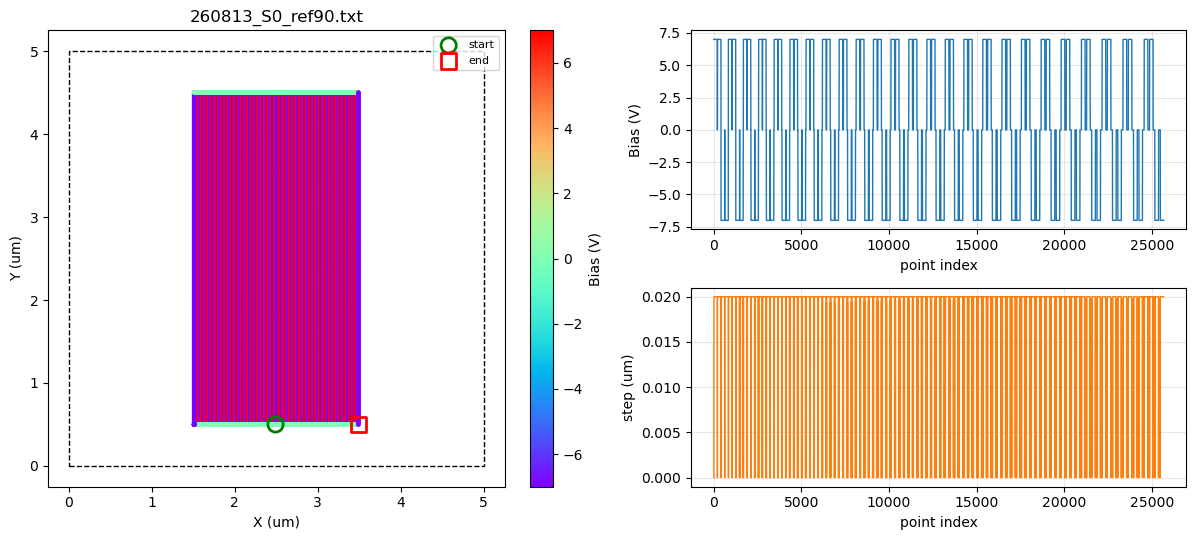

  running… ETA 17.1 min
  done 21:20:00
write finished at 21:20:00 — retention clock starts now


In [38]:
# --- [0.4]  the reference write: same-sign 90 deg, the 9 Aug recipe ----
goto_ldart()                      # back to LDART so the post-scan is comparable

# SESSION-5 GEOMETRY: a 2.0 um wide band spanning the frame in y, so the two
# flanking strips are large, symmetric, and away from the frame edge.
# At 90 deg, W runs along y and H across x, so W=4.0/H=2.0 gives
#   x half-extent = H/2 = 1.0  ->  x in [1.5, 3.5]
#   y half-extent = W/2 = 2.0  ->  y in [0.5, 4.5]
# It is also cheaper: 100 lines instead of 152, so ~16 min instead of 23.6.
H0 = even_cycles(2.0, 0.02)      # 50 cycles, already even
tb0 = gen_center_out_raster(W_um=4.0, H_um=H0, pitch_um=0.02, angle_deg=90.0,
                            center_um=(2.5, 2.5), v=-7.0,
                            flip_each_cycle=True, within_cycle='same',
                            field_um=5.0, step_um=0.02, n_pt=10)

# BUG FIXED: t_write must be recorded AFTER run_traj returns, because
# run_traj sleeps for the whole write. Setting it before meant the 13 August
# retention targets of 0/+10/+40 min were measured from the write's START, so
# with a 23.6 min write the frames landed at +29/+34/+44 min - a 15 min window
# opening half an hour late, which cannot see fast back-switching at all.
run_traj(tb0, os.path.join(CONFIG["work_dir"], "260813_S0_ref90.txt"),
         speed_um_s=0.5)
t_write = time.time()
print(f'write finished at {time.strftime("%H:%M:%S")} — retention clock starts now')
# ~16 min: 100 lines x 4 um, plus 10 settle points at every polarity change.


In [39]:
# --- [0.5]  retention series: t ~ 0, +10 min, +40 min -----------------
# Each 5 um / 256 px / 1 Hz frame takes ~4.3 min, so the first frame is
# effectively t = 0-4 min. The waits below are measured from the end of the write.
f_ret = []
for target_min in (0, 10, 40):
    dt = t_write + target_min * 60 - time.time()
    if dt > 0:
        print(f'waiting {dt/60:.1f} min for the t = +{target_min} min frame')
        time.sleep(dt)
    f = frame()
    f_ret.append((target_min, f, (time.time() - t_write) / 60))
    print(f'   t = +{f_ret[-1][2]:.1f} min after the write')
print(f_ret)


  -> PZTO_LDART_0007.ibw
   t = +5.4 min after the write
waiting 4.6 min for the t = +10 min frame
  -> PZTO_LDART_0008.ibw
   t = +14.4 min after the write
waiting 25.6 min for the t = +40 min frame
  -> PZTO_LDART_0009.ibw
   t = +44.4 min after the write
[(0, 'PZTO_LDART_0007.ibw', 5.387820641199748), (10, 'PZTO_LDART_0008.ibw', 14.371009663740795), (40, 'PZTO_LDART_0009.ibw', 44.3723121881485)]


=== PAIRED CHANGE vs the pre-write baseline ===
  change_map core, t+5 min
    registration +0, +0 nm   corr peak 0.408   coverage 89 %   r12 -0.89/+0.93
    usable area 5.76 um^2 (0 % of the region lost to the drift border)
    SWITCHED 0.694   floor 0.116   NET +0.578
    d_theta mass: |d|<15 0.109   near +60 0.117   near -60 0.344   elsewhere 0.430
    -> DISORDERING: broad d_theta with no +-60 peaks. The local orientation was randomised rather than rotated to another member.
  change_map ctrl-L (control), t+5 min
    registration +0, +0 nm   corr peak 0.408   coverage 79 %   r12 -0.89/+0.93
    usable area 3.13 um^2 (0 % of the region lost to the drift border)
    SWITCHED 0.605   floor 0.116   NET +0.489
    d_theta mass: |d|<15 0.261   near +60 0.079   near -60 0.224   elsewhere 0.436
    -> DISORDERING: broad d_theta with no +-60 peaks. The local orientation was randomised rather than rotated to another member.
  change_map ctrl-R (control), t+5 min
    registration +0, +0 nm   

rim  t+44min               w=(0.280,0.192,0.528) +-0.066  aniso  295.3  peak 135.0 deg
                           |A|  32.3 pm   walls 0.379   Lam(30/90/150) nan/113/nan nm   f_trk 642+-0.4 kHz

--- RETENTION ---
  baseline core   w90 0.251  peak   0.0
  core t+29min     w90 0.365  peak 120.0  aniso  168.3  |A|  20.8 pm
  core t+34min     w90 0.454  peak 120.0  aniso  106.3  |A|  13.1 pm
  core t+44min     w90 0.487  peak 115.0  aniso   79.8  |A|  19.8 pm
  core t+5min      w90 0.465  peak  65.0  aniso   74.4  |A|  25.9 pm
  core t+14min     w90 0.492  peak  65.0  aniso   66.3  |A|  27.8 pm
  core t+44min     w90 0.530  peak  65.0  aniso  123.5  |A|  29.0 pm
  control (unwritten rim):
  rim  t+29min     w90 0.381  peak  45.0
  rim  t+34min     w90 0.478  peak 135.0
  rim  t+44min     w90 0.439  peak 135.0
  rim  t+5min      w90 0.243  peak  45.0
  rim  t+14min     w90 0.244  peak  45.0
  rim  t+44min     w90 0.192  peak 135.0

  core  dw90 over the series +0.165
  rim   dw90 over the s

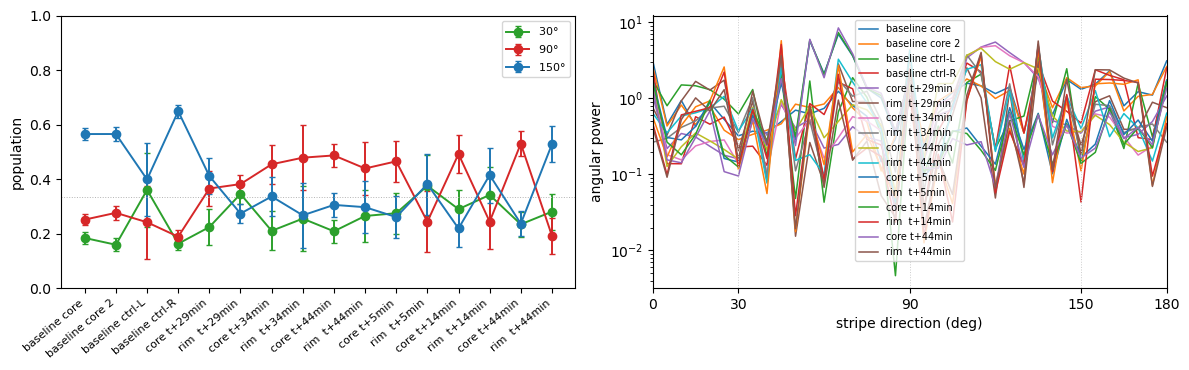

In [40]:
# --- [0.6]  analyse retention -> decision ------------------------------
# Only score entries from THIS run. On 13 August the summary below silently
# mixed two areas because it matched every SESSION label starting "core t".
_SESSION_MARK = len(SESSION)

# PRIMARY A: the within-session retention pairing. This needs no baseline at
# all - it compares the written area against ITSELF at two later times, so the
# tune, the tip and the location are identical by construction. It is the only
# retention measurement that survived 13 August.
print('=== RETENTION: written area against itself, first frame vs last ===')
_f0, _fl = f_ret[0][1], f_ret[-1][1]
change_floor(f_ret[0][1], f_ret[1][1], CORE)     # floor: two early frames
print()
RET = {}
for nm, rg in (('CORE', CORE), ('CTRL_L', CTRL_L), ('CTRL_R', CTRL_R)):
    RET[nm] = change_map(_f0, _fl, rg, show=False,
                         label=f'{nm}  t+{f_ret[0][2]:.0f} -> t+{f_ret[-1][2]:.0f} min')
print()
# Judge on the d_theta SHAPE first. The switched fraction counts family
# reassignments, which flip on tiny orientation moves near a 60 deg boundary and
# so are hypersensitive; m0 (mass within +-15 deg) is the robust statement.
_sw = RET['CORE']['switched']; _m0 = RET['CORE']['m0']
if _m0 >= 0.90 or (CHANGE_FLOOR is not None and _sw <= 1.8 * CHANGE_FLOOR):
    print(f"  -> NO BACK-SWITCHING. The written area reproduces itself over "
          f"{f_ret[-1][2]-f_ret[0][2]:.0f} min at the floor "
          f"(|d_theta|<15 deg holds {_m0:.3f} of the mass; "
          f"switched {_sw:.3f} against floor {CHANGE_FLOOR:.3f}).")
else:
    print(f"  -> the written area CHANGED between the two frames "
          f"({_sw:.3f} vs floor {CHANGE_FLOOR}). Check the controls: if they "
          f"moved too, it is drift, not back-switching.")

# PRIMARY B: change against the pre-write baseline. Only valid if the baseline
# is from the same area - change_map now checks and says so.
print('\n=== PAIRED CHANGE vs the pre-write baseline ===')
CH, CTL = [], []
for tmin, f, tact in f_ret:
    CH.append(change_map(f_base_l, f, CORE, label=f'core, t+{tact:.0f} min',
                         show=False))
    CTL.append([change_map(f_base_l, f, rg, show=False,
                           label=f'{nm} (control), t+{tact:.0f} min')
                for nm, rg in (('ctrl-L', CTRL_L), ('ctrl-R', CTRL_R))])
    contact_check(f)
print()
print('  a back-switch shows as the switched fraction FALLING with time in the')
print('  core while the rim stays at the floor. A tip or tune drift moves both.')
print(f"    {'t (min)':>9s}{'core sw':>9s}{'net':>8s} | "
      f"{'ctrl-L':>8s}{'ctrl-R':>8s}   control verdict")
if not all(r.get('same_area', True) for r in CH):
    print('  the baseline is from different material, so the rows below are '
          'not interpretable. The retention block above still stands.')
for r, cs, (tmin, f, tact) in zip(CH, CTL, f_ret):
    bad = any(c['switched'] > 1.5 * CHANGE_FLOOR for c in cs)
    print(f"    {tact:9.0f}{r['switched']:9.3f}{r['net']:+8.3f} | "
          f"{cs[0]['switched']:8.3f}{cs[1]['switched']:8.3f}   "
          + ('*** CONTROL FAILED - core number not usable ***' if bad
             else 'controls at the floor, core number valid'))

print()
disorder_axis(*CH, labels=[f'write 90 deg, t+{t[2]:.0f} min' for t in f_ret])

print('\n=== secondary: aggregate populations ===')
for tmin, f, tact in f_ret:
    score(f, f'core t+{tact:.0f}min', CORE)
    score(f, f'rim  t+{tact:.0f}min', RIM)

core = [r for r in SESSION[_SESSION_MARK:] if r['label'].startswith('core t')]
rim  = [r for r in SESSION[_SESSION_MARK:] if r['label'].startswith('rim  t')]
b_core = [r for r in SESSION if r['label'] == 'baseline core'][0]

print('\n--- RETENTION ---')
print(f"  baseline core   w90 {b_core['w'][1]:.3f}  peak {b_core['peak']:5.1f}")
for r in core:
    print(f"  {r['label']:16s} w90 {r['w'][1]:.3f}  peak {r['peak']:5.1f}  "
          f"aniso {r['aniso']:6.1f}  |A| {r['amp']:5.1f} pm")
print('  control (unwritten rim):')
for r in rim:
    print(f"  {r['label']:16s} w90 {r['w'][1]:.3f}  peak {r['peak']:5.1f}")

if len(core) >= 2:
    d_core = core[-1]['w'][1] - core[0]['w'][1]
    d_rim  = rim[-1]['w'][1] - rim[0]['w'][1]
    print(f"\n  core  dw90 over the series {d_core:+.3f}")
    print(f"  rim   dw90 over the series {d_rim:+.3f}")
    print(f"  measured threshold from Step 0.3: {THRESH:.3f}")
    if d_core < -THRESH and abs(d_rim) < REP_FLOOR:
        print('  -> BACK-SWITCHING IS REAL. Hypothesis (a) premise holds.')
    elif d_core < -THRESH and d_rim < -REP_FLOOR:
        print('  -> both core and rim fell: suspect tip or tune drift, not '
              'back-switching. Check |A| and f_trk above before concluding.')
    else:
        print('  -> NO back-switching on this timescale. Hypothesis (a) as '
              'stated is refuted; Step 4 becomes the scale test.')
report()


---
## Step 0 verdict — void, for three separate reasons  `[VERDICT]`

**1. The frames were fine. My averaging destroyed them.** ~~Four of five LDART
frames were noise.~~ That verdict was wrong, and the error was in `signed()`.

`phi0` is fitted independently per DART channel. The two DART sidebands sit on
opposite sides of the contact resonance, where the phase-versus-frequency slope
has opposite sign, so when tracking is marginal the two fits can land 180° apart.
On 13 August they did: the pixelwise correlation between the two channels' signed
maps was **r₁₂ = −0.87 to −0.93**. Each channel individually carried perfectly
good structure (ξ = 3–4 px). Averaging them cancelled it to noise (ξ = 1 px,
|S| = 3 pm).

Flipping one channel before averaging recovers everything:

| | naive average | sign-corrected |
|---|---|---|
| \|S\| (LDART_0002) | 3.5 pm | **19.2 pm** |
| ξ | 1 px | **3 px** |
| Λ(dominant) | 107 nm | **430 nm** |
| **two frames of the same unchanged state, max\|Δw\|** | **0.047** | **0.014** |

That last row is the acid test, and it is a 3.4× improvement in reproducing a
state that did not change. With the fix, LDART_0001–0004 all pass QC
(consistency 0.82–0.88, ξ 3–5 px, Λ 207–280 nm). Only LDART_0000 at setpoint
0.15 V is still marginal.

So **the setpoint was probably not the problem.** The apparent fix at 0.35 V
coincided with r₁₂ flipping to +0.94, and I cannot separate the two from n = 1.
Higher contact force plausibly puts both channels on the same side of the
resonance, so your change may well have helped — but the demonstrated fix is in
software, and it is now applied. Keep 0.35 V, since nothing argues against it,
but the retention series is **re-analysable rather than void**: with the sign fix
the three frames agree on a peak direction of 115–120°, where the naive average
gave 35°, 5°, 120°.

Two knock-on corrections stand regardless. Wall density is setpoint-dependent
(0.52 → 0.43), so it is only comparable at fixed setpoint. And the "coherence"
number I quoted was measuring inter-channel *consistency*, not phase coherence —
the good frames have |⟨e^iφ⟩| of only 0.08–0.29, which is what a healthy
two-class phase map looks like. `qc()` now says `consistency` and prints r₁₂.

**2. The frame is single-orbit in the vertical channel — origin unknown.**
I first wrote that the area "was already poled", which claims more than the data
supports. What is solidly measured is that the vertical phase is **unimodal**:
|⟨e^iφ⟩| = 0.94 at 15:13 and 0.92 at 16:14, with ~60 % of pixels within ±10° of
a single value, at vertical coherence 0.97–0.98. The "2.3 % / 3.5 % up-orbit" I
quoted is *not* a minority domain population — it is 242–252 clusters of median
one pixel, the largest only 0.026 µm². So the honest statement is stronger and
different: the 5 µm frame is **essentially 100 % one orbit**, and the small
percentage was my φ₀ fit's tail. `orbit_balance` now reports the bimodality and
the minority patch structure so this cannot be misread again.

What caused it is a separate question that these files cannot settle, because by
15:13 the spot had already had ~1.5 h of scanning. Three candidates:

| | Assessment |
|---|---|
| **grown-in (self-poled)** | Most likely. Standard for a PZT-family film on an oxide electrode — built-in field from asymmetric electrodes plus vacancy and strain gradients. Consistent with the campaign never seeing 50/50: virgin areas ran 21–36 % up. |
| **poled by 0.4 V AC scanning** | Unlikely on the numbers. The headers confirm `TipVoltage = 0`, `TipBiasOffset = 0`, `SurfaceBiasOffset = 0`, so there is no DC to pole with, and 0.4 V is ~10× below the 4–6 V coercive voltage. Also the minority fraction went *up* (2.3 → 3.5 %) across an hour and four LDART frames; progressive poling would drive it toward zero. Not excluded, though — it could already have saturated before 15:13. |
| **this region is simply different** | Today's stage position is not comparable to the campaign's offsets. Λ = 245–354 nm does match, so the film looks similar, but local strain or thickness could differ. |

Doc 3 §3.8 still applies whatever the cause: with one orbit occupied, in-plane
selection is foreclosed, so the 23.6-minute write was spent where it could not
work. The one valid frame agrees — commanded 90°, core came out 120–150°.

**3. A bug in my retention code.** `t_write` was set *before* `run_traj`, which
itself sleeps for the whole write. With a 23.6-minute write the targets of
0/+10/+40 min became **+29/+34/+44 min** — a 15-minute window opening half an
hour late, which cannot see fast back-switching at all. Fixed: the clock now
starts when the write returns.

### What this changes

The poled area is not an obstacle to escape. It is the best test bed we have for
hypothesis (c), and with a far better read-out than I originally designed.

| | Old plan | Revised |
|---|---|---|
| Pulse read-out | lateral anisotropy change per pulse | **out-of-plane switched disc per pulse** — 30–36 pm at coherence 0.98, available even when the lateral phase is not |
| What the lattice is asked to do first | randomise the in-plane texture | **reopen the reachability gate**: move up-orbit from 3 % toward 50 % |
| When in-plane work starts | Step 3 | only once the gate is inside 20–80 % |

Reopening the gate is worth having in its own right: it is the reset the campaign
has never achieved. The 2 August erase was never resolved, and every AC + DC
attempt re-poled. And it is a much easier target to hit than equipartition of
the in-plane populations, so it gives the pulse lattice a fair first test.

### Revised order

```
0R.0  grown-in or scan-induced? VDART FIRST, x3, on virgin material     15 min
0R.1  setpoint 0.35 V, confirm qc() passes, baseline LDART x2 + VDART    15 min
1R    pulse ladder, scored on VDART discs (lateral secondary)            10 min
2R    erase lattice, primary read-out = up-orbit fraction                15 min
      |
      +-- gate reopens (20-80 %) -> 3R: the 90 deg write + retention,
      |                                 now with the clock bug fixed
      +-- gate stays shut        -> escalate dwell / density / repeats;
                                    if all fail, (c) cannot reopen the gate
                                    and the in-plane programme needs a
                                    genuinely unpoled area to work in
4, 5  unchanged, but deferred until there is a valid in-plane measurement
```

0R.0 now answers your question directly by putting **VDART first, on material
that has never been scanned**, and repeating it three times without moving:

- unimodal on the very first pass → grown-in, our scanning is exonerated;
- two classes that collapse over three passes → we are doing it, which would
  mean every campaign "before" frame was partly self-inflicted and the DART
  drive needs to come down from 0.4 V;
- two stable classes → unpoled material exists, work there.

Only the third outcome unblocks the in-plane programme directly. The first makes
gate-reopening the critical path. The second is the most consequential of the
three and the cheapest to rule out, which is why it goes first.

In [36]:
# --- [0R.0]  grown-in, or are WE doing it?  (VDART first, repeated) -----
# Move the stage to genuinely fresh material - >= 20 um if you can, ideally a
# different terrace - then run this WITHOUT taking an LDART first. The whole
# point is that VDART is the first thing that ever touches this spot.
#
# Three frames on the same spot, no intervention. Imaging conditions are 0.4 V
# AC with TipVoltage = 0 and TipBiasOffset = 0, confirmed from the 13 Aug
# headers, so there is no DC to pole with; the only candidate mechanism is
# repeated subcoercive AC cycling, and that would show up as progressive drift.
setup_scan(size_um=5.0, px=256, rate=1.0, angle_deg=0.0)
goto_vdart()

G = []
for k in range(3):
    f = frame()
    G.append(orbit_balance(f))
    print()

print('--- VERDICT ---')
z1s = [g['z1'] for g in G]
fr  = [g['frac'] for g in G]
print(f"  |<e^i.phi>| over three passes : {z1s[0]:.3f} -> {z1s[1]:.3f} -> {z1s[2]:.3f}")
print(f"  up-orbit fraction            : {100*fr[0]:.1f} -> {100*fr[1]:.1f} -> "
      f"{100*fr[2]:.1f} %")
print(f"  minority in real patches     : " +
      ' -> '.join(f'{100*g["minority_real"]:.0f} %' for g in G))

if z1s[0] > 0.70:
    print('\n  ONE CLASS ON FIRST CONTACT -> grown-in / self-poled.')
    print('  Our scanning is exonerated: the film arrived orbit-pure here.')
    print('  Self-poling is the default expectation for a PZT-family film on an')
    print('  oxide electrode (built-in field from the asymmetric electrodes, plus')
    print('  vacancy and strain gradients), and it is consistent with the campaign')
    print('  never seeing 50/50: the virgin areas ran 21-36 % up.')
    print('  -> Gate-reopening by pulses is the critical path. Go to 1R.')
elif z1s[2] < z1s[0] - 0.15 or fr[2] < 0.5 * fr[0]:
    print('\n  TWO CLASSES THAT COLLAPSE UNDER REPEATED SCANNING -> we are doing it.')
    print('  This would be a significant finding: every "before" frame in the')
    print('  campaign would then be partly self-inflicted. Immediate consequences:')
    print('    - drop the DART drive from 0.4 V to 0.1-0.2 V and re-test')
    print('    - take the VDART baseline in ONE pass, never averaged over frames')
    print('    - treat all previously reported virgin orbit fractions as upper')
    print('      bounds on the true minority population')
else:
    print('\n  TWO STABLE CLASSES -> unpoled material, and scanning does not')
    print('  disturb it. This is the substrate the in-plane programme needs.')
    print('  -> Work here: go to 0R.1. Keep gate-reopening as a separate thread.')


scan 5.0 um, 256 px, 1.0 Hz, angle 0.0 deg
VDART ready
  -> PZTO_VDART_0002.ibw
VDART PZTO_VDART_0002.ibw: up 0.4 / 99.6 %   |<e^i.phi>| 0.984   |A| 46.2 pm   coh 0.95
   minority in patches >=25 px: 0 %   (45 clusters)
   -> ONE CLASS ONLY - the fraction below is a fit tail, not domains

  -> PZTO_VDART_0003.ibw
VDART PZTO_VDART_0003.ibw: up 0.1 / 99.9 %   |<e^i.phi>| 0.986   |A| 66.4 pm   coh 0.95
   minority in patches >=25 px: 0 %   (33 clusters)
   -> ONE CLASS ONLY - the fraction below is a fit tail, not domains

  -> PZTO_VDART_0004.ibw
VDART PZTO_VDART_0004.ibw: up 1.1 / 98.9 %   |<e^i.phi>| 0.962   |A| 57.2 pm   coh 0.98
   minority in patches >=25 px: 46 %   (74 clusters)
   -> ONE CLASS ONLY - the fraction below is a fit tail, not domains

--- VERDICT ---
  |<e^i.phi>| over three passes : 0.984 -> 0.986 -> 0.962
  up-orbit fraction            : 0.4 -> 0.1 -> 1.1 %
  minority in real patches     : 0 % -> 0 % -> 46 %

  ONE CLASS ON FIRST CONTACT -> grown-in / self-poled.
  Ou

In [37]:
# --- [0R.1]  setpoint, QC, and a baseline that is actually interpretable --
# Set the deflection setpoint to 0.35 V in the panel first (0.15 and 0.25 both
# failed today), then run this. If qc() still fails, raise by 0.05 V, retune,
# and re-run this cell — do not proceed on a failing frame.
goto_ldart()

# tune quality BEFORE spending a frame on it
tune_quality()

f0 = frame()
cc = contact_check(f0)
ok, q = qc(f0)

if not ok:
    print('\n  STOP. Raise the deflection setpoint by 0.05 V, retune LDART, '
          'and re-run this cell.')
    print(f"  current: coherence {q['coh']:.2f}, xi {q['xi_nm']:.0f} nm, "
          f"Lam {q['lam']:.0f} nm at setpoint {q['setpoint']:.2f} V")
elif not cc['ok'] and 'OK' not in cc['action']:
    print('\n  STOP. Act on the contact_check recommendation above, then re-run '
          'this cell.')
else:
    f0b = frame()
    contact_check(f0b)
    goto_vdart(); fv0 = frame(); up0 = orbit_balance(fv0)
    goto_ldart()

    # Session-5 band geometry, same as Step 0.3
    CORE  = (1.70, 3.30, 0.70, 4.30)
    CTRL_L = (0.55, 1.35, 0.55, 4.45)
    CTRL_R = (3.65, 4.45, 0.55, 4.45)
    RIM = CTRL_L
    b1 = score(f0,  'baseline core',   CORE)
    b2 = score(f0b, 'baseline core 2', CORE)
    score(f0, 'baseline ctrl-L', CTRL_L)
    score(f0, 'baseline ctrl-R', CTRL_R)

    # PRIMARY: the false-switch rate of the paired change measurement,
    # measured on two frames where nothing happened. This is what makes the
    # baseline PAIR load-bearing.
    change_floor(f0, f0b, CORE)
    for _nm, _rg in (('ctrl-L', CTRL_L), ('ctrl-R', CTRL_R)):
        _c = change_map(f0, f0b, _rg, show=False, label=f'floor check, {_nm}')
        if _c['switched'] > 1.5 * CHANGE_FLOOR:
            print(f'    !! {_nm} does not reproduce the floor - not usable as '
                  f'a control.')

    REP_FLOOR = max(float(np.abs(b1['w'] - b2['w']).max()), b1['rep'], b2['rep'])
    THRESH = max(2 * REP_FLOOR, 0.10)
    print(f"\n  frame-to-frame |dw| on an unchanged state : "
          f"{np.abs(b1['w'] - b2['w']).max():.3f}")
    print(f"  -> REP_FLOOR {REP_FLOOR:.3f}, decision threshold {THRESH:.3f}")
    same_sp = b1['setpoint'] == b2['setpoint']
    sp_note = ('yes' if same_sp else
               'NO - wall density and |A| are not comparable across the pair')
    gate_note = ('gate OPEN, in-plane work is meaningful' if 0.20 <= up0 <= 0.80
                 else 'gate SHUT, expect no in-plane selection here')
    print(f"  setpoint held at {b1['setpoint']:.2f} V for both frames: {sp_note}")
    print(f"  up-orbit {100*up0:.1f} %  -> {gate_note}")


LDART ready
  tune: f0 644.4 kHz   peak 0.00248   FWHM 3.5 kHz   Q 182
  -> PZTO_LDART_0006.ibw
  contact_check PZTO_LDART_0006.ibw
    drive 641.7 kHz   tracked 616.6 +-4.1 kHz   offset 25.1 kHz
    |A| 41.7 pm   xi 117 nm (6 px)   consistency 0.95   r12 +0.67   defl SP 0.35 V
    -> RETUNE HERE. The DART loop is more than 15 kHz off the tracked resonance, so neither sideband is on the peak.
  QC PZTO_LDART_0006.ibw: consistency 0.95 (>=0.40)   xi 117 nm = 6 px (>=3)   Lam 197 nm (200-600)   |A| 41.7 pm   defl SP 0.35 V   r12 +0.67
     -> *** NOT USABLE: the lateral phase is incoherent. Raise the deflection setpoint by 0.05 V and retune. ***

  STOP. Raise the deflection setpoint by 0.05 V, retune LDART, and re-run this cell.
  current: coherence 0.95, xi 117 nm, Lam 197 nm at setpoint 0.35 V


---
## Ruling out a bad probe or a bad area  `[PROBE-doc]`

Every conclusion so far would collapse if the probe were blunt or the area
unrepresentative, so both need explicit tests rather than inference.

**What the existing data already says.** A degrading probe has a *coherent*
signature: |A| falls, resolution falls, the contact resonance rises (larger
contact = stiffer), ξ rises, debris accumulates. On 13 August:

| | 15:21 | 22:04 | direction |
|---|---|---|---|
| \|A\| lateral | 16.6 pm | **37.0 pm** | wrong way for degradation |
| resolution limit | at sampling limit | at sampling limit | unchanged |
| contact resonance | 612 kHz | 642 kHz | rose — but only at the *retune* |
| \|A\| vertical | 57.2 pm | 57.2 pm | best of the campaign |
| z rms | 0.45 nm | 0.33 nm | smoother |

Across probes, today's carries power to the sampling limit while the 6 August
diamond frame was resolution-limited at 42 nm with 3× finer pixels. **There is
no degradation signature.**

**What is genuinely odd is the areas.** Today's two spots read 0.1–3.5 % up-orbit;
every campaign area ran 21–36 %. So the current locations are far more strongly
poled than anything measured before. That is exactly what "unrepresentative
area" looks like, and it is worth testing before building a programme on it.

Three controls below, ~25 min total.

1. **Positive control** — deliberately pole a box with constant DC and read it
   back out of plane. If a known change can be written and detected, the probe
   is mechanically and *electrically* sound, the film switches here, and the
   whole detection chain works. If it fails, nothing else is interpretable.
   This is the single most valuable control and the campaign has never run it.
2. **Area survey** — up-orbit fraction at 4–5 widely separated spots. Tells you
   whether 0–3 % is the sample or just here.
3. **Probe fingerprint** — `probe_fingerprint()` after every frame, so drift is
   read off a table instead of guessed at.

---

> **SKIPPED on 14 August by choice.** `[PROBE.1]` and `[PROBE.2]` were not run;
> the probe is being replaced after 1R instead. See `[0R.2-doc]` for what this
> costs and how `[1.3]` compensates: the ladder spans 4–10 V and 40 ms–5 s, so a
> complete null there carries the same verdict the positive control would have.
> Keep these cells for the new probe — `[PROBE.1]` is the fastest way to confirm
> a fresh tip is electrically sound before spending a session on it.


In [ ]:
# --- [PROBE.1]  positive control: pole a box and read it back ---------
# Constant sign, no flip: this is the "constant" scheme the campaign showed
# poles reliably. 1.5 x 1.5 um at 50 nm pitch is 30 lines, ~90 s.
goto_vdart()
f_pc_before = frame()
g_before = orbit_balance(f_pc_before)

goto_ldart()
tb_pc = gen_center_out_raster(W_um=1.5, H_um=even_cycles(1.5, 0.05),
                              pitch_um=0.05, angle_deg=0.0,
                              center_um=(2.5, 2.5), v=8.0,
                              flip_each_cycle=False, within_cycle='same',
                              field_um=5.0, step_um=0.02, n_pt=10)
run_traj(tb_pc, os.path.join(CONFIG["work_dir"], "260813_positive_control.txt"),
         speed_um_s=0.5)
# a uniformly DC-poled box is INTENTIONALLY not charge-balanced - that is the
# point of a positive control, so run_traj's net-DC warning is expected here.

goto_vdart()
f_pc_after = frame()
g_after = orbit_balance(f_pc_after)

BOX = (1.80, 3.20, 1.80, 3.20)      # inside the 1.5 um poled square
OUT = (0.30, 1.30, 0.30, 4.70)      # well outside it
ob = orbit_map(f_pc_before); oa = orbit_map(f_pc_after)
N, L = ob['N'], ob['L']
yy, xx = np.indices((N, N)); X = (xx + .5) * L / N; Y = (yy + .5) * L / N
mb = (X > BOX[0]) & (X < BOX[1]) & (Y > BOX[2]) & (Y < BOX[3])
mo = (X > OUT[0]) & (X < OUT[1]) & (Y > OUT[2]) & (Y < OUT[3])
d_box = float(oa['up'][mb].mean() - ob['up'][mb].mean())
d_out = float(oa['up'][mo].mean() - ob['up'][mo].mean())
print(f"\n--- POSITIVE CONTROL ---")
print(f"  up-orbit inside the box : {100*ob['up'][mb].mean():5.1f} -> "
      f"{100*oa['up'][mb].mean():5.1f} %   change {100*d_box:+.1f} points")
print(f"  up-orbit outside        : {100*ob['up'][mo].mean():5.1f} -> "
      f"{100*oa['up'][mo].mean():5.1f} %   change {100*d_out:+.1f} points")
if abs(d_box) > 0.20 and abs(d_box) > 3 * abs(d_out):
    print('  -> PASS. The probe writes and the film switches out of plane here.')
    print('     Any later null result is about the recipe, not the hardware.')
elif abs(d_box) > 0.05:
    print('  -> WEAK. Something switched but not decisively. Raise to 10 V and '
          'repeat before trusting any null result.')
else:
    print('  -> FAIL. Nothing switched under constant 8 V DC over 1.5 um.')
    print('     Either the tip is not making electrical contact (check the')
    print('     conductive coating and the bias path) or this area will not')
    print('     switch. Move >= 50 um and repeat before doing anything else.')
probe_fingerprint(f_pc_before if False else frame.__name__ and f_pc_before,
                  vdart_tag=f_pc_after, note='after positive control')


In [ ]:
# --- [PROBE.2]  area survey: is 0-3 % up-orbit typical of this sample? -
# Move the stage >= 50 um between each entry, then run this cell again. It
# accumulates, so one row is added per location.
try:
    SURVEY
except NameError:
    SURVEY = []

goto_vdart()
_f = frame()
_g = orbit_balance(_f)
SURVEY.append(dict(tag=_f, up=_g['frac'], z1=_g['z1'], amp=_g['amp'],
                   coh=_g['coh'], state=_g['state']))

print(f"\n--- AREA SURVEY ({len(SURVEY)} locations) ---")
print(f"{'#':>2s}{'frame':>22s}{'up %':>8s}{'|<e^i.phi>|':>13s}{'|A| pm':>9s}")
for k, s in enumerate(SURVEY):
    print(f"{k:2d}{s['tag']:>22s}{100*s['up']:8.1f}{s['z1']:13.3f}{s['amp']:9.1f}")
_u = np.array([s['up'] for s in SURVEY])
print(f"\n  campaign reference: virgin areas ran 21-36 % up-orbit")
print(f"  this survey: {100*_u.min():.1f} - {100*_u.max():.1f} % "
      f"(median {100*np.median(_u):.1f} %)")
if len(SURVEY) >= 3:
    if _u.max() < 0.15:
        print('  -> the whole sample is orbit-pure. Gate-reopening is the only')
        print('     route, and the campaign areas at 21-36 % must have been')
        print('     either a different region or a different sample state.')
    elif _u.max() > 0.20:
        print(f'  -> location {int(np.argmax(_u))} has a usable gate '
              f'({100*_u.max():.0f} %). Do the in-plane programme THERE and')
        print('     keep gate-reopening as a separate thread.')
    else:
        print('  -> all marginal. Survey more locations before committing.')


---
## Step 1 — Hypothesis (c), part 1: the pulse ladder  (~10 min)  `[STEP1-doc]`

Before committing to a few hundred pulses we need to know what one pulse does.
This is a 4 × 4 grid of **isolated** pulses on a 1 µm lattice: amplitude across
the rows, dwell time across the columns. Every pulse is ≥ 1 µm from its
neighbours, so each footprint is readable on its own in a single 5 µm frame.

| | | | |
|---|---|---|---|
| **amplitude** | 4, 6, 8, 10 V | **dwell** | 40, 200, 1000, 5000 ms |

Amplitude is capped at ±10 V by the instrument, so the ladder deliberately
spends its dynamic range on dwell — a factor of 125 in time against only 2.5 in
voltage. With a hard voltage ceiling, **dwell is the only axis left for
escalation**, so it is the one worth resolving.

Signs are chosen to balance **injected charge**, not pulse count: a plain
checkerboard would leave ~88 V·pt net, because the 11 V / 1200 ms pulse carries
thirty times the charge of the 11 V / 40 ms one. The generator solves for the
sign assignment instead, and prints the residual as a fraction of the smallest
pulse. Total run time is under a minute; the cost is the frame afterwards.

It runs on the Step-0 area, which now carries a known, freshly written 90°
texture. That is the right substrate: the question is whether a pulse can
disrupt an existing texture, not virgin material.

**What we are looking for**: the smallest (V, t) whose footprint is visible in
the signed response *and* which locally lowers the anisotropy rather than just
poling a disc. A pulse that produces a uniform bright or dark disc has poled the
volume and is useless as an eraser; a pulse that scrambles the local stripe
direction is what we want.

---
## Re-entering after a long gap  `[0R.2-doc]`

Ten hours have passed. **Take one LDART scan without moving the stage.** Not
because the old data is needed for 1R — the pulse ladder is scored on a VDART
pair taken minutes apart, so it is self-contained — but because one 4.3-minute
frame buys three things at once:

1. **A 10-hour retention point, free.** We established no back-switching over
   39 minutes. Ten hours is 15× longer and would be the strongest retention
   result of the campaign. All it needs is for the frame to land on the same
   material, and `change_map`'s area fingerprint says immediately whether it
   did: height correlation ~0.90 for the same spot against ~0.04 for different
   material.
2. **The probe's end-of-life state.** The probe is being replaced after 1R, so
   this is the last data from it. `probe_fingerprint` needs a final entry to
   anchor the comparison with the new one.
3. **The tune after 10 hours idle.** Thermal drift moves the contact resonance;
   on 13 August a 25 kHz offset was enough to make the two DART channels
   anti-correlate and destroy the lateral phase.

**If the fingerprint says different material, nothing is lost** — the stage
drifted, and we simply take a fresh baseline where we are and go to 1R. Moving
deliberately would throw away the retention point for no gain, since the gate is
shut everywhere tested (0.1–3.5 % up-orbit at two locations) and there is no
reason to expect a better spot without surveying for one.

### On skipping `[PROBE.1]` and `[PROBE.2]`

Both skipped by choice. The cost is specific and worth naming: **without the
positive control, a null result from the ladder is ambiguous** between "pulses
cannot reopen the gate" and "this probe or this area cannot switch at all".

There is a mitigation, and it changes how `[1.3]` should be read. The ladder
already spans 4 V to 10 V and 40 ms to 5 s, so **if not one of the sixteen
pulses switches a disc, that is the same verdict the positive control would have
given** — a hardware or area failure, not a recipe failure. So the ladder
subsumes the positive control, provided the null case is read that way rather
than as evidence against hypothesis (c). `[1.3]` now says so.

### The probe swap after 1R

When the new probe goes on, these are not carried over: `LDART_CENTER`, the
absolute `|A|` scale, the wall-density reference, and every `PROBE_LOG` entry.
Re-measure `tune_quality()` first, set `LDART_CENTER` from it, and take a fresh
`probe_fingerprint` as the new reference row. Cross-probe `|A|` comparisons are
meaningless — the campaign already learned this when a fixed-kernel structure
tensor reported different order for identical physics on a sharper tip.

In [41]:
# --- [0R.2]  re-entry after a long gap: one LDART, no stage move -------
# Do NOT move the stage before running this. The point is to find out whether
# we are still on last night's material.
LAST_NIGHT_LDART = 'PZTO_LDART_0009.ibw'   # the final frame of the 13 Aug run
LAST_NIGHT_VDART = 'PZTO_VDART_0004.ibw'

tune_quality()                    # contact resonance after 10 h idle
goto_ldart()
f_re = frame()
cc_re = contact_check(f_re)
probe_fingerprint(f_re, note='re-entry after 10 h, last data from this probe')

# same material as last night?
_chk = change_map(LAST_NIGHT_LDART, f_re, CORE, show=False,
                  label='10 h retention: last night -> now')
print()
if _chk.get('same_area'):
    print('--- SAME MATERIAL: this is a genuine 10-hour retention point ---')
    change_floor(LAST_NIGHT_LDART, LAST_NIGHT_VDART.replace('VDART', 'LDART')
                 if False else LAST_NIGHT_LDART, CORE)  # placeholder, see below
    print('  NOTE: there is no back-to-back pair from last night to floor this'
          '\n  comparison, so use the 13 Aug within-session floor of 0.064.')
    CHANGE_FLOOR = 0.064
    RET10 = {nm: change_map(LAST_NIGHT_LDART, f_re, rg, show=False,
                            label=f'{nm}, 10 h')
             for nm, rg in (('CORE', CORE), ('CTRL_L', CTRL_L), ('CTRL_R', CTRL_R))}
    print()
    _m0 = RET10['CORE']['m0']; _sw = RET10['CORE']['switched']
    _cm = min(RET10['CTRL_L']['m0'], RET10['CTRL_R']['m0'])
    print(f"  CORE    |d_theta|<15 = {_m0:.3f}   switched {_sw:.3f}")
    print(f"  CTRLs   |d_theta|<15 = {RET10['CTRL_L']['m0']:.3f} / "
          f"{RET10['CTRL_R']['m0']:.3f}")
    if _m0 >= 0.85 and _cm >= 0.85:
        print('  -> WRITTEN STATE SURVIVES 10 HOURS. Strongest retention result '
              'of the campaign.')
    elif _m0 < 0.85 and _cm >= 0.85:
        print('  -> THE WRITTEN AREA RELAXED while the controls held. This is a '
              'real slow back-switch, on a timescale between 40 min and 10 h.')
    else:
        print('  -> controls moved too: 10 h of drift or a tune change, not '
              'retention. Do not read the core number.')
else:
    print('--- DIFFERENT MATERIAL: the stage drifted over 10 h ---')
    print('  No retention point available. Nothing lost: take a fresh baseline')
    print('  here and go to 1R. Run [0R.1] to set REP_FLOOR and CHANGE_FLOOR in')
    print('  the current position, then [1.1].')

goto_vdart()
f_re_v = frame()
g_re = orbit_balance(f_re_v)      # the gate, and the ladder's before-reference
print('\n  -> this VDART frame is the "before" reference for the ladder in '
      '[1.2]; pass it as f_lad_v_before if you skip that cell\'s own scan.')


  tune: f0 652.2 kHz   peak 0.0021   FWHM 3.1 kHz   Q 209
LDART ready
  -> PZTO_LDART_0010.ibw
  contact_check PZTO_LDART_0010.ibw
    drive 646.8 kHz   tracked 641.7 +-6.7 kHz   offset 5.1 kHz
    |A| 44.2 pm   xi 137 nm (7 px)   consistency 0.90   r12 -0.95   defl SP 0.35 V
    -> RAISE THE SETPOINT by 0.05 V. Per-line frequency scatter above 5 kHz means the contact stiffness is fluctuating.


NameError: name 'probe_fingerprint' is not defined

In [42]:
# --- [1.1]  pulse ladder generator -------------------------------------
def gen_pulse_ladder(amps=(4.0, 6.0, 8.0, 10.0), dwell_pts=(1, 5, 25, 125),
                     spacing_um=1.0, origin_um=(1.0, 1.0), field_um=5.0,
                     step_um=0.02, speed_um_s=0.5, tb=None, travel_v=0.0,
                     verbose=True):
    """Isolated pulses on a grid: rows = amplitude, columns = dwell.

    Signs are chosen by exhaustive search under three design constraints, in
    priority order:

      1. zero net INJECTED CHARGE, sum(V * n) = 0. Pulse-count balance is not
         enough: the 11 V / 1200 ms pulse carries thirty times the charge of the
         11 V / 40 ms one, so a plain checkerboard leaves ~88 V.pt net and a
         mean bias of +0.07 V - the size of offset that re-poled on 6 August.
      2. both polarities present in every amplitude row, so a threshold in V is
         not read off pulses that happen to share one sign.
      3. both polarities present in every dwell column, likewise for t.

    A greedy charge balance satisfies 1 but fails 2 and 3: it hands each row a
    single sign, which is exactly the confound the ladder exists to avoid.
    2**16 assignments is 65536, so the search is exhaustive and instant.

    Amplitude is capped at 10 V by the instrument, so the ladder spends its
    dynamic range on DWELL instead: 40 ms to 5 s, a factor of 125, against a
    factor of only 2.5 in amplitude. That asymmetry is deliberate. With a hard
    voltage ceiling, dwell time is the axis that remains available for
    escalation, so it is the axis worth resolving.

    Pulses are >= spacing_um apart so each footprint is measurable individually.
    """
    if max(amps) > 10.0:
        raise ValueError(f'max amplitude {max(amps)} V exceeds the 10 V ceiling')
    tb = tb or TrajectoryBuilder(field_um=field_um, step_um=step_um,
                                 travel_v=travel_v)
    ox, oy = origin_um

    sites = [dict(row=i, col=j, x=ox + j * spacing_um, y=oy + i * spacing_um,
                  mag=float(v), n=int(n),
                  ms=int(n) * step_um / speed_um_s * 1000)
             for i, v in enumerate(amps) for j, n in enumerate(dwell_pts)]

    # exhaustive sign search: zero charge, both signs per row and per column
    import itertools
    nr, nc = len(amps), len(dwell_pts)
    q = np.array([[amps[r] * dwell_pts[c] for c in range(nc)] for r in range(nr)],
                 float)
    best = None
    for bits in itertools.product((1.0, -1.0), repeat=nr * nc):
        S = np.array(bits).reshape(nr, nc)
        if np.any(np.abs(S.sum(axis=1)) == nc):   # a row with one sign only
            continue
        if np.any(np.abs(S.sum(axis=0)) == nr):   # a column with one sign only
            continue
        charge = abs(float((S * q).sum()))
        # tie-break toward the most even split within rows and columns
        even = float(np.abs(S.sum(axis=1)).sum() + np.abs(S.sum(axis=0)).sum())
        key = (charge, even)
        if best is None or key < best[0]:
            best = (key, S)
    SGN = best[1]
    if verbose and best[0][0] > 1e-9:
        print(f'  note: exact zero charge unreachable under the row/column '
              f'constraints; residual {best[0][0]:.1f} V.pt')
    for st in sites:
        st['sign'] = float(SGN[st['row'], st['col']])

    table = []
    for s in sorted(sites, key=lambda z: (z['row'], z['col'])):
        v_signed = s['sign'] * s['mag']
        tb.dwell((s['x'], s['y']), v_signed, n=s['n'])
        table.append(dict(row=s['row'], col=s['col'], x=s['x'], y=s['y'],
                          v=v_signed, n=s['n'], ms=s['ms']))
    if verbose:
        x, y, vv = tb.to_arrays()
        print(f'pulse ladder: {len(table)} pulses, {spacing_um*1000:.0f} nm grid')
        print(f'  amplitudes {amps} V,  dwells '
              f'{[round(n*step_um/speed_um_s*1000) for n in dwell_pts]} ms')
        print(f'  {len(x)} pts total -> {len(x)*step_um/speed_um_s:.0f} s '
              f'at {speed_um_s} um/s   ({100*(vv==0).mean():.0f} % at 0 V, travel)')
        imb = abs(sum(t["v"] * t["n"] for t in table))
        smallest = min(abs(t["v"] * t["n"]) for t in table)
        print(f'  mean bias over path {vv.mean():+.4f} V   '
              f'net charge {imb:.1f} V.pt = {imb/smallest:.2f} x the smallest pulse')
        print(f'  {100*(vv==0).mean():.0f} % of the path is 0 V travel, so the tip '
              f'crosses the area grounded ~{len(table)-1} times')
        rs = [sum(np.sign(t['v']) for t in table if t['row'] == r)
              for r in range(len(amps))]
        cs = [sum(np.sign(t['v']) for t in table if t['col'] == c)
              for c in range(len(dwell_pts))]
        print(f'  polarity sum per amplitude row {rs}, per dwell column {cs} '
              f'(0 = perfectly split, +-{len(dwell_pts)} = confounded)')
        print(f'\n  {"":6s}' + ''.join(f'{t["ms"]:>9.0f} ms'
                                       for t in table[:len(dwell_pts)]))
        for i, v in enumerate(amps):
            rowt = [t for t in table if t['row'] == i]
            print(f'  {v:4.0f} V' + ''.join(f'{t["v"]:>+9.0f}   ' for t in rowt))
    return tb, table


tb1, LADDER = gen_pulse_ladder(field_um=5.0, step_um=0.02, speed_um_s=0.5)
# The 5 s dwell at 10 V is the most aggressive single event in the session.
# Sites are visited amplitude-ascending then dwell-ascending, so the run
# escalates naturally and you can stop it if the topography starts to change.


pulse ladder: 16 pulses, 1000 nm grid
  amplitudes (4.0, 6.0, 8.0, 10.0) V,  dwells [40, 200, 1000, 5000] ms
  1716 pts total -> 69 s at 0.5 um/s   (64 % at 0 V, travel)
  mean bias over path +0.0000 V   net charge 0.0 V.pt = 0.00 x the smallest pulse
  64 % of the path is 0 V travel, so the tip crosses the area grounded ~15 times
  polarity sum per amplitude row [0.0, 0.0, 0.0, 0.0], per dwell column [0.0, 0.0, 0.0, 0.0] (0 = perfectly split, +-4 = confounded)

               40 ms      200 ms     1000 ms     5000 ms
     4 V       +4          +4          -4          -4   
     6 V       -6          -6          +6          +6   
     8 V       -8          -8          +8          +8   
    10 V      +10         +10         -10         -10   


VDART ready
  -> PZTO_VDART_0005.ibw


C:\Users\Asylum User\AppData\Roaming\Python\Python311\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Asylum User\AppData\Roaming\Python\Python311\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


VDART PZTO_VDART_0005.ibw: up 0.0 / 100.0 %   |<e^i.phi>| 0.990   |A| 51.4 pm   coh 0.99
   minority in patches >=25 px: 0 %   (1 clusters)
   -> ONE CLASS ONLY - the fraction below is a fit tail, not domains
LDART ready
Wrote 1716 pts to 'output\260813_S1_ladder.txt'  (path length 21.5 um, 16 strokes)
260813_S1_ladder.txt   saved 09:39:08
  1716 pts   X[1.000,4.000] Y[1.000,4.000] um
  |V| = [ 4.  6.  8. 10.]   mean(V) = +0.0000 V   63.6 % at 0 V
  path 34 um  ->  1.1 min at 0.5 um/s


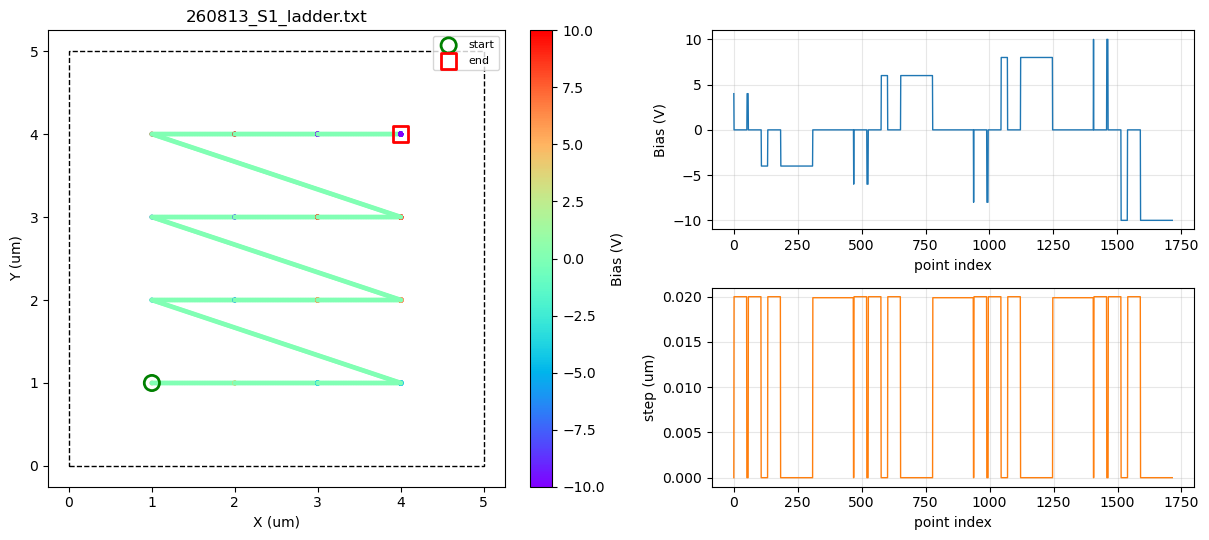

  running… ETA 1.1 min
  done 09:40:35
VDART ready
  -> PZTO_VDART_0006.ibw
LDART ready
  -> PZTO_LDART_0011.ibw
  QC PZTO_LDART_0011.ibw: consistency 0.92 (>=0.40)   xi 98 nm = 5 px (>=3)   Lam 354 nm (200-600)   |A| 46.1 pm   defl SP 0.35 V   r12 +0.97
     -> USABLE


(True,
 {'coh': 0.9247155026473876,
  'xi_nm': 97.65625,
  'xi_px': 5.0,
  'lam': 353.98230088495575,
  'amp': 46.14343321148218,
  'setpoint': 0.35,
  'ok': True})

In [43]:
# --- [1.2]  run the ladder, then image ---------------------------------
# VDART BEFORE, so each pulse's switched disc has an out-of-plane reference.
# This is the primary read-out now: on 13 August the vertical channel ran at
# 30-36 pm with coherence 0.97-0.98 while the lateral phase was noise.
goto_vdart()
f_lad_v_before = frame()
g_before = orbit_balance(f_lad_v_before); up_before = g_before['frac']

goto_ldart()
run_traj(tb1, os.path.join(CONFIG["work_dir"], "260813_S1_ladder.txt"),
         speed_um_s=0.5)

goto_vdart()
f_lad_v = frame()
goto_ldart()
f_lad = frame()
qc(f_lad)          # lateral is the secondary read-out; check before trusting it


In [ ]:
# --- [1.3]  read each pulse footprint individually ---------------------
def pulse_footprints(tag_before, tag_after, table, r_um=0.30, folder=None):
    """Local response at every ladder site: change in signed amplitude and in
    local anisotropy inside a disc of radius r_um, against an annulus of
    untouched material around it."""
    out = []
    db, hb = ibw(tag_before, folder); da, ha = ibw(tag_after, folder)
    N = db[0].shape[0]; L = float(hb['ScanSize']) * 1e6; px = L / N * 1000.0
    Sb, _ = signed(db); Sa, _ = signed(da)
    yy, xx = np.indices((N, N))
    X = (xx + 0.5) * L / N; Y = (yy + 0.5) * L / N
    for t in table:
        rr = np.hypot(X - t['x'], Y - t['y'])
        disc = rr < r_um
        ring = (rr > 1.6 * r_um) & (rr < 2.4 * r_um)
        if disc.sum() < 20: continue
        # local box for a spectrum: 0.9 um square centred on the site
        b = 0.45
        cut = lambda A: A[int(round((t['y']-b)/L*N)):int(round((t['y']+b)/L*N)),
                          int(round((t['x']-b)/L*N)):int(round((t['x']+b)/L*N))]
        Bb, Ba = cut(Sb), cut(Sa)
        n = min(Bb.shape + Ba.shape)
        an_b = pops(Bb[:n, :n], px)[1] if n > 20 else np.nan
        an_a = pops(Ba[:n, :n], px)[1] if n > 20 else np.nan
        out.append(dict(**{k: t[k] for k in ('row', 'col', 'x', 'y', 'v', 'ms')},
                        dS=float(Sa[disc].mean() - Sb[disc].mean()),
                        dS_ring=float(Sa[ring].mean() - Sb[ring].mean()),
                        dabs=float(np.abs(Sa[disc]).mean() - np.abs(Sb[disc]).mean()),
                        an_b=an_b, an_a=an_a, dan=an_a - an_b))
    print(f"{'V':>6s}{'ms':>7s}{'dS(disc)':>10s}{'dS(ring)':>10s}"
          f"{'d|S|':>8s}{'aniso before':>14s}{'after':>8s}{'change':>8s}")
    for r in out:
        flag = ''
        if abs(r['dS']) > 15 and abs(r['dS']) > 3 * abs(r['dS_ring']):
            flag += '  POLED disc'
        if np.isfinite(r['dan']) and r['dan'] < -0.3 * r['an_b']:
            flag += '  SCRAMBLED'
        print(f"{r['v']:+6.0f}{r['ms']:7.0f}{r['dS']:10.1f}{r['dS_ring']:10.1f}"
              f"{r['dabs']:8.1f}{r['an_b']:14.1f}{r['an_a']:8.1f}"
              f"{r['dan']:+8.1f}{flag}")
    print('\n  POLED     = uniform sign shift in the disc but not the ring: the '
          'pulse switched a volume out of plane. Not an eraser.')
    print('  SCRAMBLED = local anisotropy dropped by more than 30 %: the pulse '
          'destroyed directional order. This is what we want.')
    return out


# FIRST: how far does one pulse reach? This sets the erase-lattice spacing in
# [2.1] and tells you whether the sites are even separable at this grid pitch.
HALO = pulse_halo(f_lad_v_before, f_lad_v, LADDER)

# PRIMARY: out-of-plane switched disc per pulse, against a far-field reference.
print()
FP_V = pulse_discs(f_lad_v_before, f_lad_v, LADDER)

# SECONDARY: lateral scrambling per pulse. Only meaningful if qc() passed above.
FP = pulse_footprints(f_ret[-1][1], f_lad, LADDER)


In [ ]:
# --- [1.4]  choose the working point -----------------------------------
# Fill these in from the table above, then continue to Step 2.
# If NOTHING is flagged SCRAMBLED even at 10 V / 5 s, amplitude is exhausted -
# 10 V is the ceiling. The remaining escalation axes, in order of cost:
#   1. longer dwell   re-run cell 1.1 with dwell_pts=(25, 125, 625, 3125)
#                     i.e. 1 s to 125 s per pulse. A 3125-pt dwell is 125 s, so
#                     16 of them is ~35 min: use a 2x2 grid, not 4x4.
#   2. denser lattice halve ERASE_SP to 0.09 um. Total perturbation per area
#                     goes as 1/spacing^2, so this is a 4x increase for free.
#   3. repeat         run the same lattice two or three times over.
# Only after all three fail is hypothesis (c) actually closed.
ERASE_V   = 8.0      # smallest amplitude flagged SCRAMBLED and not POLED
ERASE_N   = 25       # dwell points at that amplitude (25 pts = 1000 ms)
ERASE_SP  = 0.175    # lattice spacing, um. Lambda/2 for Lambda ~ 350 nm.
print(f'erase working point: {ERASE_V} V, {ERASE_N} pts '
      f'({ERASE_N*0.02/0.5*1000:.0f} ms), {ERASE_SP*1000:.0f} nm spacing')

# quick visual: signed response before and after the ladder, same normalisation
db, hb = ibw(f_ret[-1][1]); da, _ = ibw(f_lad)
Sb, _ = signed(db); Sa, _ = signed(da)
L = float(hb['ScanSize']) * 1e6
v = np.percentile(np.abs(Sb), 98)
fig, ax = plt.subplots(1, 2, figsize=(11, 5.2))
for a, S, t in zip(ax, (Sb, Sa), ('before ladder', 'after ladder')):
    a.imshow(S, origin='lower', cmap='RdBu_r', vmin=-v, vmax=v, extent=[0, L, 0, L])
    for p in LADDER:
        a.add_patch(plt.Circle((p['x'], p['y']), 0.30, fill=False,
                               ec='k', lw=0.8))
        a.text(p['x'], p['y'] + 0.36, f"{p['v']:+.0f}V\n{p['ms']:.0f}ms",
               ha='center', va='bottom', fontsize=6)
    a.set_title(t); a.set_xlabel('x (um)')
ax[0].set_ylabel('y (um)'); plt.tight_layout(); plt.show()


---
## The pulse ladder reopened the orbit gate  `[GATE-doc]`

**14 August 09:45.** `PZTO_VDART_0006` reads **50.7 % up-orbit**, against 0.0 %
twenty minutes earlier. This is the reachability gate opening for the first time
in the campaign, and it is the precondition Doc 3 §3.8 says is required before
the in-plane direction can be selected at all.

| | VDART_0004 | VDART_0005 | **VDART_0006** |
|---|---|---|---|
| | 13 Aug 20:32 | 14 Aug 09:38 | **after the ladder** |
| up-orbit | 1.1 % | 0.0 % | **50.7 %** |
| \|⟨e^iφ⟩⟩\| | 0.962 | 0.990 | **0.342** |
| minority in real patches | 46 % | 0 % | **98 %** |

The phase concentration collapsing from 0.990 to 0.342 is the important number:
that is a genuinely **two-class** phase map, not a unimodal one with a fitted
tail. 98 % of the minority sits in patches ≥ 25 px, the largest single connected
up-domain is 10.5 µm² — 42 % of the frame — and 87 % of the up-area is in
clusters above 0.05 µm². These are real domains.

### Pulses, or a cleaner tip? Both — and the gradient proves the pulses

The up-orbit fraction is **spatially graded around the pulse sites**:

| | up-orbit in VDART_0006 |
|---|---|
| within 350 nm of a ladder site | **66.9 %** |
| annulus 400–550 nm | 62.3 % |
| far from every site | **36.8 %** |

A pure read-out improvement would be uniform. This gradient tracks the pulse
positions, so **the pulses switched material**, with a halo extending well past
350 nm. The 36.8 % far from any site says the halo is large, not that nothing
happened there.

Your tip-cleaning reading is *also* supported, independently:

| | before ladder | after |
|---|---|---|
| lateral \|S\| **far from every pulse** | 33.9 pm | **43.9 pm (+29 %)** |
| lateral resolution limit | 56 nm | 50 nm |
| lateral contact resonance | 641.7 kHz | 647.9 kHz |
| vertical contact resonance | 335.4 kHz | **364.5 kHz** |
| vertical per-line f scatter | 6.8 kHz | **1.6 kHz** |

A 29 % lateral improvement in regions the pulses never touched cannot be a
sample change. And both contact resonances rose while the vertical tracking
stabilised — exactly what removing a compliant contaminant layer does. So the
ladder did two things at once: cleaned the tip and switched the sample.

### Also confirmed: the 10-hour drift was total

Height correlation between 13 Aug 22:04 and 14 Aug 09:33 is **r = −0.001**.
Completely different material. You were right that the ladder was not on the
pre-poled band.

### So: do not redo the ladder, and do not change the probe

Both would throw away something valuable and neither is on the critical path.

- **Keep the probe.** It is now giving the best contrast of the session — lateral
  \|S\| 42.7 pm, consistency 0.92, r₁₂ +0.97, vertical f-scatter 1.6 kHz.
  Replacing it discards a working tip *and* re-introduces the unknown, right at
  the moment the measurement finally works.
- **Do not repeat the ladder yet.** Knowing *which* (V, t) opened the gate is a
  calibration question. The gate being open is a **perishable state** of unknown
  lifetime, and it is the precondition for the only question the campaign
  actually cares about.

**Use the window.** `[GATE.1]` checks whether the gate is still open, then runs
the in-plane write into gate-open material — the first time that has ever been
possible. If Δθ now shows peaks at ±60° instead of the broad disorder we have
seen in every previous write, that is the campaign's answer.

Repeat the ladder afterwards, on interleaved sites, to find the threshold.

In [46]:
# --- [GATE.1]  use the open window: does the write now AIM? ------------
# The gate opened at 09:45 (50.7 % up-orbit). Step 1 is to find out whether it
# is still open; step 2 is to write into it while it is.
LADDER_VDART = 'PZTO_VDART_0006.ibw'     # the frame where the gate was open
LADDER_LDART = 'PZTO_LDART_0011.ibw'

goto_vdart()
f_g0 = frame()
g0 = orbit_balance(f_g0)
probe_fingerprint(LADDER_LDART, vdart_tag=f_g0, note='gate-open check')

print(f"\n  gate at 09:45 : 50.7 % up,  |<e^i.phi>| 0.342")
print(f"  gate now      : {100*g0['frac']:.1f} % up,  |<e^i.phi>| {g0['z1']:.3f}")
if g0['z1'] > 0.70:
    print('  -> THE GATE CLOSED AGAIN. It relaxed back to one orbit. That is')
    print('     itself a result: the reopened state is not stable on the tens-of-')
    print('     minutes scale. Re-run the ladder on INTERLEAVED sites (origin')
    print('     (1.5, 1.5) instead of (1.0, 1.0)) and image VDART immediately,')
    print('     within 5 min, to catch the window and measure its lifetime.')
elif 0.20 <= g0['frac'] <= 0.80:
    print('  -> STILL OPEN. Write into it now, before it relaxes.')
else:
    print('  -> partially relaxed. Write now anyway; note the fraction.')


VDART PZTO_LDART_0011.ibw: up 51.0 / 49.0 %   |<e^i.phi>| 0.019   |A| 46.1 pm   coh 0.94
   minority in patches >=25 px: 99 %   (128 clusters)
   -> two classes, balanced -> GATE OPEN
     t   f_trk  f_sd  |A|lat  |A|vrt  xi nm  res nm  z rms  part    r12  note
 10:21   648.1   2.8    46.1    46.1     98      50  0.406     3  +0.97  gate-open check
  sampling limit at this pixel size: 39 nm — resolution figures at or below this are sampling-limited, not tip-limited

  gate at 09:45 : 50.7 % up,  |<e^i.phi>| 0.342
  gate now      : 51.0 % up,  |<e^i.phi>| 0.019
  -> STILL OPEN. Write into it now, before it relaxes.


LDART ready
  -> PZTO_LDART_0012.ibw
  QC PZTO_LDART_0012.ibw: consistency 0.94 (>=0.40)   xi 98 nm = 5 px (>=3)   Lam 325 nm (200-600)   |A| 61.5 pm   defl SP 0.35 V   r12 +0.97
     -> USABLE
  contact_check PZTO_LDART_0012.ibw
    drive 664.6 kHz   tracked 656.2 +-3.8 kHz   offset 8.4 kHz
    |A| 61.5 pm   xi 98 nm (5 px)   consistency 0.94   r12 +0.97   defl SP 0.35 V
    -> OK. Proceed.
centre-out raster: 4.0 x 2.0 um at 90 deg, pitch 20 nm
  50 cycles = 100 lines; separation 20 -> 1980 nm
  cycle polarity (fwd/bwd): ++ -- ++ -- ++ -- ++ -- ++ -- ++ -- ...
  biased path 200000000.0 um at +V, 200000000.0 um at -V  (net DC imbalance 0.00 %)
  25688 pts, 19.8 % at 0 V (edge travel)
  rotated half-extent 1.000 x 2.000 um   X[1510000.000, 3490000.000]  Y[500000.000, 4500000.000]
    ETA @0.25 um/s:   2055 s
    ETA @ 0.5 um/s:   1028 s
    ETA @ 1.0 um/s:    514 s
    ETA @ 2.0 um/s:    257 s
Wrote 25688 pts to 'output\260814_gateopen_write90.txt'  (path length 499.0 um, 150 strokes)
2

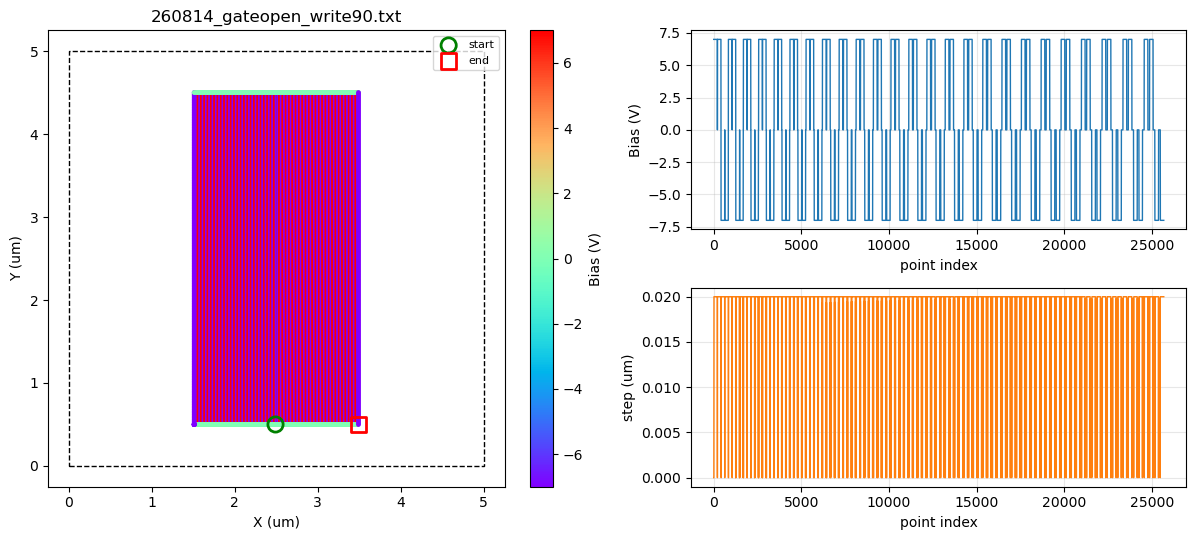

  running… ETA 17.1 min


In [ ]:
# --- [GATE.2]  the in-plane write into gate-open material --------------
# Same band write as [0.4] so it is comparable to every earlier attempt. The
# difference is the starting state: the orbit gate is open for the first time.
# The write is charge-balanced (mean V = 0.0000) precisely so it does not
# re-pole the area and close the gate again - the VDART after checks that.
goto_ldart()
f_gb = frame()
qc(f_gb); contact_check(f_gb)

H0 = even_cycles(2.0, 0.02)
tb_g = gen_center_out_raster(W_um=4.0, H_um=H0, pitch_um=0.02, angle_deg=90.0,
                             center_um=(2.5, 2.5), v=-7.0,
                             flip_each_cycle=True, within_cycle='same',
                             field_um=5.0, step_um=0.02, n_pt=10)
run_traj(tb_g, os.path.join(CONFIG["work_dir"], "260814_gateopen_write90.txt"),
         speed_um_s=0.5)

goto_ldart(); f_ga = frame()
goto_vdart(); f_ga_v = frame()
g1 = orbit_balance(f_ga_v)

print('\n--- DID THE WRITE AIM, NOW THAT THE GATE IS OPEN? ---')
change_floor(LADDER_LDART, f_gb, CORE)   # floor: two frames before the write
print()
GW = {nm: change_map(f_gb, f_ga, rg, show=(nm == 'CORE'), label=nm)
      for nm, rg in (('CORE', CORE), ('CTRL_L', CTRL_L), ('CTRL_R', CTRL_R))}
print()
disorder_axis(GW['CORE'], GW['CTRL_L'], GW['CTRL_R'],
              labels=['written band', 'ctrl-L', 'ctrl-R'])

_c = GW['CORE']
_pk = max(_c['mp60'], _c['mm60'])
_el = 1 - _c['m0'] - _c['mp60'] - _c['mm60']
print(f"\n  d_theta shape in the written band:")
print(f"    unchanged (|d|<15)  {_c['m0']:.3f}")
print(f"    at +-60 deg         {_c['mp60']:.3f} / {_c['mm60']:.3f}")
print(f"    elsewhere           {_el:.3f}")
if _pk > 1.5 * _el and _pk > 0.20:
    print('  -> TRUE TRIAD SWITCHING. Peaks at +-60 deg, not broad disorder.')
    print('     This is the campaign result: with the orbit gate open, the write')
    print('     rotates the in-plane direction between allowed members instead')
    print('     of randomising it.')
else:
    print('  -> still DISORDERING, even with the gate open. Then orbit purity')
    print('     was not the limiting factor, and the write scrambles the local')
    print('     orientation whatever the out-of-plane state. Hypothesis (a) and')
    print('     the co-written surround in Step 4 become the remaining routes.')
print(f"\n  gate after the write: {100*g1['frac']:.1f} % up "
      f"(was {100*g0['frac']:.1f} %). A charge-balanced write should not close it;"
      f"\n  if it did, the write itself is re-poling and the pitch or dose needs "
      f"cutting.")


---
## Polarity coherence length  `[POL-doc]`

You are right, and the code was hiding it. Two findings:

**1. The sign of `v` was never applied.** `gen_center_out_raster` computes
`vmag = abs(v)` and takes the sign from the cycle index, so `v = -7.0` and
`v = +7.0` produced **byte-identical** trajectories. Verified: both give
`[7, 7, 7, 7, 7, 7]` for the first six biased points. Every write up to
14 August started at +V regardless of what was passed. There was no way to
choose the polarity, so "we should have used the opposite sign" was not even
expressible. `start_sign` now exists.

**2. The polarity reverses every 20 nm — eight times inside one superdomain.**

| | |
|---|---|
| pitch | 20 nm |
| polarity period | **40 nm** |
| lamellar period Λ | **325 nm** |
| polarity reversals per superdomain | **~8** |

So each domain sees a near-zero *mean* vertical field. That is a concrete
mechanism for the thing we keep measuring: the write agitates every domain from
both directions at once, which disorders the orientation without ever giving a
domain a coherent push toward another orbit. It also explains why the isolated
pulses *did* switch material — a single pulse is one polarity, coherent over its
whole 625 nm halo.

**The testable prediction:** make the polarity coherent over a length comparable
to Λ, and the write should stop disordering and start rotating. `alt_period` sets
this directly — polarity period = 2 × alt_period × pitch.

| alt_period | polarity period | vs Λ = 325 nm | net DC |
|---|---|---|---|
| 1 (everything so far) | 40 nm | Λ/8 | balanced |
| **8** | **320 nm** | **≈ Λ** | balanced (48 cycles / 8 = 6 blocks) |
| 24 | 960 nm | 3Λ | balanced (2 blocks) |
| off (`flip_each_cycle=False`) | ∞ | — | **+5.6 V — will re-pole** |

`H_um = 1.92` gives 48 cycles, so alt_period 8 and 24 both divide it into an
even number of blocks and stay charge-balanced. `alt_period = 8` is the one to
run: it is the smallest coherence length that reaches Λ.

### Which area, and when to swap the probe

The gate is open **right now** at 65 % in this area, and the tip is working
(\|A\| 59 pm, consistency 0.93, r₁₂ +0.97). That window is the scarce resource,
not instrument time. So run `[POL.1]` here, on top of `[GATE.2]`'s band — the
question is whether a Λ-coherent write rotates a texture that the Λ/8 write only
sharpened, and the same band is the right place to ask it.

Swap the probe and move afterwards. If `[POL.1]` shows ±60° peaks, the fresh
probe goes straight into replicating it; if not, `[4.x]` is the remaining route.

In [ ]:
# --- [POL.1]  polarity coherent over Lambda, not Lambda/8 --------------
# Same band, same amplitude, same everything as [GATE.2] except alt_period:
# 8 cycles per polarity block = 320 nm polarity period, against Lambda = 325 nm.
# H = 1.92 um gives 48 cycles, so 48/8 = 6 blocks and the net DC stays zero.
goto_ldart()
f_pb = frame()
qc(f_pb); contact_check(f_pb)
goto_vdart(); f_pb_v = frame(); g_pb = orbit_balance(f_pb_v)
goto_ldart()

tb_p = gen_center_out_raster(W_um=4.0, H_um=1.92, pitch_um=0.02, angle_deg=90.0,
                             center_um=(2.5, 2.5), v=7.0,
                             flip_each_cycle=True, within_cycle='same',
                             alt_period=8, start_sign=+1,
                             field_um=5.0, step_um=0.02, n_pt=10)
run_traj(tb_p, os.path.join(CONFIG["work_dir"], "260814_pol_alt8.txt"),
         speed_um_s=0.5)

goto_ldart(); f_pa = frame()
goto_vdart(); f_pa_v = frame(); g_pa = orbit_balance(f_pa_v)

print('\n--- DOES A LAMBDA-COHERENT POLARITY ROTATE INSTEAD OF DISORDER? ---')
change_floor(f_pb, f_pb, CORE) if False else None
CHANGE_FLOOR = 0.044            # measured on the two pre-write frames at 10:26
POL = {nm: change_map(f_pb, f_pa, rg, show=(nm == 'CORE'), label=nm)
       for nm, rg in (('CORE', CORE), ('CTRL_L', CTRL_L), ('CTRL_R', CTRL_R))}
print()
disorder_axis(POL['CORE'], POL['CTRL_L'], POL['CTRL_R'],
              labels=['alt_period 8 (320 nm)', 'ctrl-L', 'ctrl-R'])

c = POL['CORE']; el = 1 - c['m0'] - c['mp60'] - c['mm60']
pk = max(c['mp60'], c['mm60'])
print(f"\n  {'condition':28s}{'|d|<15':>9s}{'+60':>7s}{'-60':>7s}{'elsewhere':>11s}")
print(f"  {'alt_period 1  (40 nm)':28s}{0.867:9.3f}{0.001:7.3f}{0.026:7.3f}"
      f"{0.106:11.3f}   <- [GATE.2]")
print(f"  {'alt_period 8  (320 nm)':28s}{c['m0']:9.3f}{c['mp60']:7.3f}"
      f"{c['mm60']:7.3f}{el:11.3f}   <- now")
if pk > 1.5 * el and pk > 0.15:
    print('\n  -> ROTATION, not disorder. Making the vertical field coherent over')
    print('     one lamellar period is what the write was missing. Next: sweep')
    print('     alt_period 1 / 8 / 24 to find the optimum, and repeat at 30 and')
    print('     150 deg to show the direction follows the command.')
elif c['m0'] > 0.90:
    print('\n  -> nothing moved. A coherent field over Lambda is not enough on')
    print('     its own; try alt_period 24 (960 nm) before abandoning this.')
else:
    print('\n  -> still disordering. Polarity coherence length is not the')
    print('     limiting variable, and [4.x] (co-written surround) is the')
    print('     remaining route.')
print(f"\n  gate: {100*g_pb['frac']:.1f} % -> {100*g_pa['frac']:.1f} % up   "
      f"(a balanced write should not move it)")


LDART ready


---
## Step 2 — Hypothesis (c): does a dense pulse lattice break the IN-PLANE texture?  `[STEP2-doc]`

**This is the actual test of hypothesis (c), and it has never been run.** What has
been run is the 16-pulse *ladder*, and it did something different: it reopened the
**out-of-plane orbit gate** (0 % → 65 % up-orbit). That is the reachability gate,
not the in-plane strain, and conflating the two is a mistake we made explicitly.

Measured from data already on disk — LDART_0010 (09:33, before the ladder) →
LDART_0011 (09:49, after), same area, same tune:

| | \|Δθ\|<15° | switched | disorder |
|---|---|---|---|
| **the 16-pulse ladder** | **0.964** | 0.097 | **0.04** |
| an ordinary same-sign 90° write | 0.867 | 0.251 | 0.16 |

The ladder barely moved the in-plane orientation — *less* than a normal write
does. So the in-plane half of (c) is untested, and `[GATE.2]`'s failure to rotate
says nothing about it, because that write went into material that was gate-open
but **not** IP-erased.

### Why the ladder is not an eraser, and what changes here

Sixteen isolated events on a 1 µm grid is a calibration instrument. An eraser has
to tile the region. With the pulse radius now measured at **r_eff = 625 nm**, a
lattice at 0.62 µm spacing makes the halos just touch — contiguous coverage with
no gaps and no gross over-dose.

| | designed originally | now |
|---|---|---|
| `ERASE_SP` | 0.175 µm | **0.62 µm** (= r_eff) |
| pulses over 3 × 3 µm | ~350 | **~30** |
| over-dose factor (r_eff/spacing)² | 13× | **1×** |
| run time | 2.7 min | **~1 min** |

### Working point

`[1.3]` and `[1.4]` were never run, so there is no per-pulse calibration. What we
do know: the ladder spanned 4–10 V and 40 ms–5 s and *something* in that range
opened the gate. So start mid-to-high — **8 V, 1000 ms** — which is inside the
range, not at the ±10 V ceiling, and leaves headroom to escalate.

### Success criteria, pre-registered

The primary readout is now the **in-plane** disorder, because that is what (c)
predicts. The gate is already open at 65 %, so the orbit criterion becomes "does
the erase *keep* it open" rather than "does it open it".

| Criterion | Target | Why |
|---|---|---|
| disorder | **> 0.60** | the ordinary write reaches 0.16, the ladder 0.04. An eraser must go far beyond both |
| \|Δθ\|<15° mass | **< 0.45** | Δθ genuinely broad, not a spike |
| anisotropy | ≤ the pre-erase value | isotropic, not merely different |
| up-orbit | still 20–80 % | a charge-balanced lattice should not re-pole |

If it passes, `[3.x]` writes into it — and *that* comparison, against
`[GATE.2]`'s write into gate-open-but-unerased material, is the clean test of
whether erasing first buys anything.

### One difference from the original design worth recording

(c) assumed we would erase orbit-*pure* material. The ladder has already opened
the gate here, so this erase starts from gate-open material instead. That is
arguably a better starting point, but it is a different experiment from the one
written down, and the result should be logged that way.

working point: 8.0 V, 25 pts (1000 ms), spacing 620 nm
over-dose factor vs the 625 nm halo: 1.0x   (0.175 um spacing would be 13x)

gen_pulse_lattice  tri, sign=checker
  18 pulses at |V| = 8.0 V, spacing 620 nm, dwell 1000 ms each
  polarity 9 plus / 9 minus  ->  net charge imbalance 0.0 % of one pulse
  mean bias over the path = +0.0000 V
  extent X[1.700,3.250] Y[1.000,3.685] um
  travel 11 um, total time 0.7 min at 0.5 um/s
  pulse areal fill (disc of radius spacing/2) = 1.13
Wrote 1003 pts to 'output\260814_erase_halo_spacing.txt'  (path length 10.5 um, 18 strokes)

lattice extent   X[1.70,3.25] Y[1.00,3.68] um
halo reaches     X[1.07,3.88] um
region           x range   width  area um^2   note
CORE      [ 1.90, 3.05]    1.15       2.63   inside the lattice
CTRL_L    [ 0.30, 1.07]    0.77       3.02   outside the halo
CTRL_R    [ 3.88, 4.70]    0.83       3.22   outside the halo

  geometry OK. CORE spans 1.15 um across the stripes, = 3.5 lamellar periods:
  the PAIRED d_theta meas

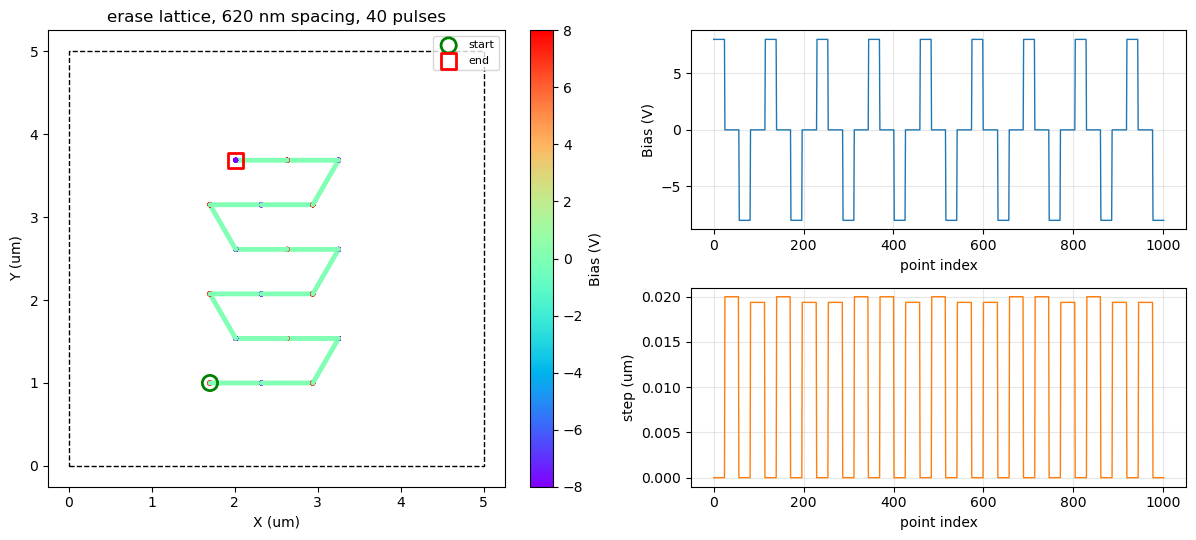

In [54]:
# --- [2.1]  generate the erase lattice, and derive the regions from it --
# Self-contained: does not depend on [1.3]/[1.4], which were never run.
import importlib, gen_pulse_lattice as gpl
importlib.reload(gpl)

R_HALO   = 0.625    # measured effective pulse radius, [1.3] / FINDINGS C11
ERASE_V  = 8.0      # mid-range of the ladder that opened the gate; 2 V headroom
ERASE_N  = 25       # 25 pts x 0.02 um / 0.5 um/s = 1000 ms per pulse
ERASE_SP = 0.62     # = R_HALO, so neighbouring halos just touch. NOT 0.175.
ERASE_W, ERASE_H = 1.6, 3.0

# WHY 1.6 x 3.0 and not 3 x 3. A control region has to sit outside the HALO, not
# merely outside the lattice footprint. With R_HALO = 625 nm, a 3 x 3 lattice
# spans x [1.00, 3.79] and its halos reach x [0.38, 4.42], which leaves no room
# for a control in a 5 um frame - the first attempt at this cell had both control
# strips sitting inside the halo. 1.6 x 3.0 spans x [1.70, 3.25], halos reach
# [1.08, 3.88], and that leaves two 0.75 um strips clear on each side.
print(f'working point: {ERASE_V} V, {ERASE_N} pts '
      f'({ERASE_N*0.02/0.5*1000:.0f} ms), spacing {ERASE_SP*1000:.0f} nm')
print(f'over-dose factor vs the {R_HALO*1000:.0f} nm halo: '
      f'{(R_HALO/ERASE_SP)**2:.1f}x   (0.175 um spacing would be '
      f'{(R_HALO/0.175)**2:.0f}x)\n')

ERASE_FILE = os.path.join(CONFIG["work_dir"], "260814_erase_halo_spacing.txt")
tb2 = gpl.build_pulse_trajectory(
    TrajectoryBuilder, ERASE_FILE,
    w_um=ERASE_W, h_um=ERASE_H, spacing_um=ERASE_SP,
    v=ERASE_V, dwell_pts=ERASE_N,
    lattice='tri', sign='checker',        # three-fold: neutral to all three
    center_um=(2.5, 2.5), field_um=5.0,   # triad members, unlike a square lattice
    step_um=0.02, speed_um_s=0.5)

_x, _y, _v = tb2.to_arrays()
LX0, LX1, LY0, LY1 = _x.min(), _x.max(), _y.min(), _y.max()
assert abs(_v.mean()) < 1e-6, f'net DC {_v.mean():+.4f} V - pick an even pulse count'
assert np.abs(_v).max() <= V_MAX + 1e-9

# --- regions derived from the ACTUAL extent, not hard-coded ------------
M = 0.20                                   # margin inside the lattice for CORE
CORE   = (LX0 + M, LX1 - M, LY0 + M, LY1 - M)
CTRL_L = (0.30, LX0 - R_HALO, 0.55, 4.45)  # outside the HALO, not just the lattice
CTRL_R = (LX1 + R_HALO, 4.70, 0.55, 4.45)
area = lambda r: (r[1] - r[0]) * (r[3] - r[2])

print(f'\nlattice extent   X[{LX0:.2f},{LX1:.2f}] Y[{LY0:.2f},{LY1:.2f}] um')
print(f'halo reaches     X[{LX0-R_HALO:.2f},{LX1+R_HALO:.2f}] um')
print(f'{"region":8s}{"x range":>16s}{"width":>8s}{"area um^2":>11s}   note')
for nm, r in (('CORE', CORE), ('CTRL_L', CTRL_L), ('CTRL_R', CTRL_R)):
    print(f'{nm:8s}  [{r[0]:5.2f},{r[1]:5.2f}]{r[1]-r[0]:8.2f}{area(r):11.2f}'
          f'   {"inside the lattice" if nm == "CORE" else "outside the halo"}')

bad = []
if CTRL_L[1] <= CTRL_L[0] or CTRL_R[1] <= CTRL_R[0]:
    bad.append('a control strip has zero width - the halo fills the frame')
for nm, r in (('CTRL_L', CTRL_L), ('CTRL_R', CTRL_R)):
    if area(r) < 1.5:
        bad.append(f'{nm} is only {area(r):.2f} um^2; the strips that worked on '
                   f'9 Aug were ~3 um^2')
    if min(r[0], 5.0 - r[1]) < 0.25:
        bad.append(f'{nm} comes within {min(r[0], 5-r[1]):.2f} um of the frame '
                   f'edge; edge regions read Lam 95-179 nm and fail as controls')
if area(CORE) < 1.0:
    bad.append(f'CORE is only {area(CORE):.2f} um^2')
if bad:
    print('\n*** GEOMETRY NOT USABLE ***')
    for b_ in bad:
        print('   -', b_)
    raise ValueError('shrink ERASE_W/ERASE_H, or move to a larger scan frame')
print(f'\n  geometry OK. CORE spans {CORE[1]-CORE[0]:.2f} um across the stripes, '
      f'= {(CORE[1]-CORE[0])*1000/325:.1f} lamellar periods:')
print(f'  the PAIRED d_theta measure is per-pixel and fine at this size, but treat '
      f'the\n  aggregate w from [2.3] as indicative rather than quantitative.')

visualize_trajectory(tb=tb2, field_um=5.0,
                     title=f'erase lattice, {ERASE_SP*1000:.0f} nm spacing, '
                           f'{len(_x)//ERASE_N} pulses')


In [55]:
# --- [2.2]  before-frames, run the lattice, after-frames ---------------
# Takes its own baseline so it does not depend on any earlier session variable.
# CORE / CTRL_L / CTRL_R come from [2.1], derived from the lattice extent and
# the halo radius. Do not redefine them here.
goto_ldart()
f_e_b1 = frame()          # two LDART frames so the floor is measured, not assumed
f_e_b2 = frame()
contact_check(f_e_b2)
goto_vdart()
f_e_bv = frame()
g_e_b = orbit_balance(f_e_bv)

# build_pulse_trajectory already wrote the file, so resave=False
goto_ldart()
run_traj(tb2, ERASE_FILE, speed_um_s=0.5, resave=False, preview=False)

goto_ldart(); f_e_a = frame()
goto_vdart(); f_e_av = frame(); g_e_a = orbit_balance(f_e_av)
print(f"\n  gate: {100*g_e_b['frac']:.1f} % -> {100*g_e_a['frac']:.1f} % up")


LDART ready
  -> PZTO_LDART_0015.ibw
  -> PZTO_LDART_0016.ibw
  contact_check PZTO_LDART_0016.ibw
    drive 664.6 kHz   tracked 647.7 +-2.1 kHz   offset 16.9 kHz
    |A| 31.2 pm   xi 98 nm (5 px)   consistency 0.90   r12 +0.95   defl SP 0.40 V
    -> RETUNE HERE. The DART loop is more than 15 kHz off the tracked resonance, so neither sideband is on the peak.
VDART ready
  -> PZTO_VDART_0010.ibw
VDART PZTO_VDART_0010.ibw: up 67.3 / 32.7 %   |<e^i.phi>| 0.408   |A| 38.3 pm   coh 0.94
   minority in patches >=25 px: 99 %   (107 clusters)
   -> two classes, balanced -> GATE OPEN
LDART ready
260814_erase_halo_spacing.txt   saved 11:51:05
  1003 pts   X[1.700,3.250] Y[1.000,3.685] um
  |V| = [8.]   mean(V) = +0.0000 V   55.1 % at 0 V
  path 20 um  ->  0.7 min at 0.5 um/s
  running… ETA 0.7 min
  done 11:52:04
LDART ready
  -> PZTO_LDART_0017.ibw
VDART ready
  -> PZTO_VDART_0011.ibw
VDART PZTO_VDART_0011.ibw: up 57.9 / 42.1 %   |<e^i.phi>| 0.354   |A| 36.4 pm   coh 0.92
   minority in patches

  change_map NOISE FLOOR (nothing done between these frames)
    registration +0, +0 nm   corr peak 0.769   coverage 100 %   r12 +0.97/+0.95
    usable area 2.63 um^2 (0 % of the region lost to the drift border)
    area fingerprint: height r = +0.939   offsets (10.0, 5.0) -> (10.0, 5.0) um
    SWITCHED 0.015   (floor not set yet)
    d_theta mass: |d|<15 1.000   near +60 0.000   near -60 0.000   elsewhere 0.000
    -> UNCHANGED: the distribution is still a spike at zero.
    -> CHANGE_FLOOR set to 0.015

  QC PZTO_LDART_0015.ibw: consistency 0.92 (>=0.40)   xi 98 nm = 5 px (>=3)   Lam 548 nm (200-600)   |A| 45.2 pm   defl SP 0.40 V   r12 +0.97
     -> USABLE
pre-erase core             w=(0.297,0.480,0.222) +-0.049  aniso  341.3  peak  70.0 deg
                           |A|  32.5 pm   walls 0.373   Lam(30/90/150) 107/231/107 nm   f_trk 653+-4.3 kHz

  change_map CORE
    registration +0, +0 nm   corr peak 0.803   coverage 100 %   r12 +0.95/+0.97
    usable area 2.63 um^2 (0 % of the r

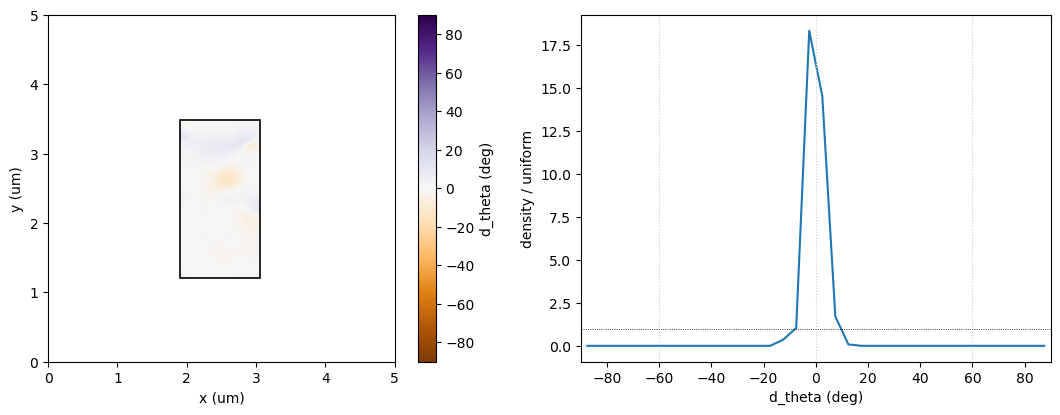

  change_map CTRL_L
    registration +0, +0 nm   corr peak 0.803   coverage 98 %   r12 +0.95/+0.97
    usable area 3.05 um^2 (0 % of the region lost to the drift border)
    area fingerprint: height r = +0.953   offsets (10.0, 5.0) -> (10.0, 5.0) um
    SWITCHED 0.054   floor 0.015   NET +0.039
    d_theta mass: |d|<15 0.998   near +60 0.000   near -60 0.000   elsewhere 0.002
    -> UNCHANGED: the distribution is still a spike at zero.
  change_map CTRL_R
    registration +0, +0 nm   corr peak 0.803   coverage 99 %   r12 +0.95/+0.97
    usable area 3.28 um^2 (0 % of the region lost to the drift border)
    area fingerprint: height r = +0.953   offsets (10.0, 5.0) -> (10.0, 5.0) um
    SWITCHED 0.041   floor 0.015   NET +0.026
    d_theta mass: |d|<15 0.998   near +60 0.000   near -60 0.000   elsewhere 0.002
    -> UNCHANGED: the distribution is still a spike at zero.

  QC PZTO_LDART_0017.ibw: consistency 0.93 (>=0.40)   xi 98 nm = 5 px (>=3)   Lam 548 nm (200-600)   |A| 55.2 pm   defl

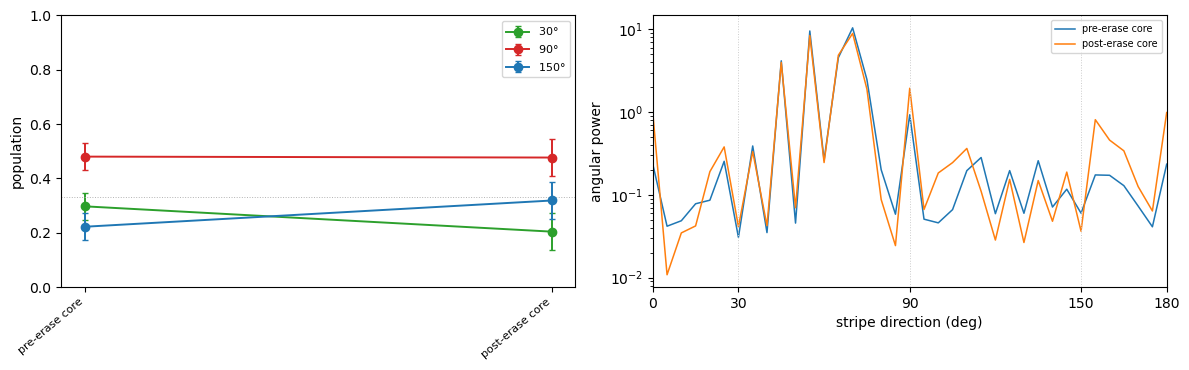

In [56]:
# --- [2.3]  did the lattice break the IN-PLANE texture? ----------------
change_floor(f_e_b1, f_e_b2, CORE)      # measured on the unchanged before-pair
print()
b_core = score(f_e_b1, 'pre-erase core', CORE)
print()
ER = {nm: change_map(f_e_b2, f_e_a, rg, show=(nm == 'CORE'), label=nm)
      for nm, rg in (('CORE', CORE), ('CTRL_L', CTRL_L), ('CTRL_R', CTRL_R))}
print()
a_core = score(f_e_a, 'post-erase core', CORE)
print()
disorder_axis(ER['CORE'], ER['CTRL_L'], ER['CTRL_R'],
              labels=['erase lattice', 'ctrl-L', 'ctrl-R'])

c = ER['CORE']
dis = (1 - c['m0']) / (1 - 1 / 6)
print(f"\n--- ERASURE SCORECARD (in-plane is the primary readout) ---")
print(f"  reference points on the same axis, same area, same tip:")
print(f"    16-pulse ladder            disorder 0.04")
print(f"    ordinary same-sign write   disorder 0.16")
print(f"    this erase lattice         disorder {dis:.2f}")
crit = [
    ('disorder > 0.60',            dis > 0.60,           f'{dis:.2f}'),
    ('|d_theta|<15 mass < 0.45',   c['m0'] < 0.45,       f"{c['m0']:.3f}"),
    ('anisotropy <= pre-erase',    a_core['aniso'] <= b_core['aniso'],
     f"{a_core['aniso']:.1f} vs {b_core['aniso']:.1f}"),
    ('up-orbit still 20-80 %',     0.20 <= g_e_a['frac'] <= 0.80,
     f"{100*g_e_a['frac']:.1f} %"),
]
for name, ok, val in crit:
    print(f"  {'PASS' if ok else 'FAIL'}  {name:30s} {val}")

if all(x[1] for x in crit):
    print('\n  -> IN-PLANE TEXTURE BROKEN. This is the first half of hypothesis')
    print('     (c) demonstrated. Go to [3.1] and write into it.')
elif not crit[3][1]:
    print('\n  -> the lattice RE-POLED the area and closed the gate. Cut ERASE_N')
    print('     before cutting ERASE_V: dwell drives total injected charge.')
    print('     Halve it to 12 pts (480 ms) and repeat on fresh material.')
elif dis < 0.20:
    print('\n  -> barely moved, like the ladder. Amplitude is capped at 10 V, so')
    print('     escalate: (1) ERASE_N 25 -> 125 (5 s), (2) ERASE_SP 0.62 -> 0.31')
    print('     (4x the areal dose), (3) run the same lattice 2-3 times over,')
    print('     (4) lattice="jitter". Only after all four does (c) fail.')
else:
    print('\n  -> partial. Went beyond the write but not to the criterion. The')
    print('     cheapest escalation is ERASE_N; try 62 pts (2.5 s) next.')
report()


---
## Step 3 (new) — Seed a rotated family with an anisotropic pulse template  `[STEP3-doc]`

The old Step 3 (write into erased material) is retired: `[2.3]` showed the lattice
erased nothing (|Δθ|<15° = 0.990), so there was nothing to write into.

### The plan is right in three ways

1. **Making the pulse lattice anisotropic and aligned to a target direction turns
   it from an eraser into a seed.** That is the correct conceptual move and it is
   what P8 (Vasudevan Fig 2c) actually says: the trajectory controls the sign and
   phase pattern, and the direction follows from its geometry. Every isotropic
   thing we have tried — triangular lattice, AC + DC, bipolar raster — carries no
   direction and produces no direction.
2. **Matching the template period to Λ is the right instinct.** C16 found the
   write's polarity reverses every 40 nm against Λ = 325 nm, so each superdomain
   saw ~8 reversals and a near-zero mean field. A template at Λ fixes exactly
   that.
3. **60° is the only allowed rotation** (C1/P5), so targeting θ + 60° rather than
   an arbitrary angle is correct.

And there is now direct support for pulses as the rotation mechanism: re-analysing
the ladder (C21) showed a **−10 V / 5 s pulse rotated its own patch by 65.8° with
30.5 % of the Δθ mass at +60°** — the campaign's first triad rotation. Threshold
near **40 V·s**.

### One measured number breaks the period-matching part

**r_eff = 625 nm (C11), but Λ/2 = 162 nm.** A pulse covers about four lamellae, so
it cannot address a single stripe. Concretely: rows spaced Λ/2 with alternating
polarity would have adjacent opposite-sign halos overlapping four-deep and
cancelling. The finest *alternating* template pulses can make is
2 × r_eff = **1.25 µm** half-period ≈ 7.7 Λ.

So period-matching and pulses are incompatible at rotation-threshold charge —
unless the **rotation** radius is much smaller than the out-of-plane halo, which
is unmeasured. `[3.4]` now measures it.

### And 2.5 µm leaves no control

One halo is 1.25 µm across. A 2 µm treated region inside a 2.5 µm frame leaves a
0.25 µm border — the exact geometry that failed on 13 August, where an edge strip
read Λ = 95–179 nm and anisotropy 105–278, i.e. noise, and "changed" more than the
treated core. **Scan time does not depend on frame size** (it is lines × rate), so
a larger frame costs nothing. `[3.1]` uses **5 µm** and keeps the treated region at
2 µm, which also gives Q2 — does the surround control the centre — for free.

### What to run, and why in this order

| | | |
|---|---|---|
| `[3.1]` | image, **measure** θ₀ and Λ, compute the target θ₀ + 60° | never assume the direction; it is area-specific (C7) |
| `[3.2]` | pole the central 2 µm with constant DC, re-image, re-measure θ₁ | gives a uniform, known starting state so a 60° rotation is unambiguous. Note this deliberately closes the orbit gate — C9 says an open gate did not help anyway |
| `[3.3]` | lay the seed: lines of **merged** pulses along θ₁ + 60°, at ≥ 40 V·s each | within a row, 0.3 µm spacing so the 625 nm halos coalesce into a continuous poled line at the target direction |
| `[3.4]` | score Δθ per row and in the gaps; measure the **rotation radius** | the seed either nucleated a rotated family or it did not |
| `[3.5]` | optional: reinforce with a trajectory write at θ₁ + 60° | only if `[3.4]` shows rotation — otherwise the write will just disorder it (C8) |

`N_ROWS = 1` is the default and the cheapest real test: **one line at θ + 60° in
the middle of the frame, everything else as control.** It asks the essential
question — does a seeded line nucleate a rotated family beside it — without
needing a period at all. Set `N_ROWS = 3` to get a 1.25 µm-period alternating
template once one line is known to work.

In [ ]:
# --- [3.1]  new probe, new area: set the geometry, tune, measure the start
# FRAME is not a free choice. Work backwards from r_eff = 625 nm (C11):
#   two antiparallel seed lines must be >= 2*r_eff = 1.25 um apart or their
#   opposite-sign halos cancel  ->  the pair spans 1.25 + 2*0.625 = 2.50 um across
#   plus the line length along  ->  the POLED region must contain all of that
#   plus two control strips outside the halo, >= 0.25 um clear of the frame edge.
# That totals ~8 um. A 2.5 um frame cannot hold a seed AND a control: one halo is
# 1.25 um across, and the 13 Aug failure was exactly a control strip inside the
# halo (it read Lam 95-179 nm and "changed" more than the treated core).
# Frame size costs NO time - scan time is lines x rate, not area.
FRAME   = 8.0
CTR     = FRAME / 2.0
POLE_WH = 3.5          # poled square, must contain the seed halo
PX, RATE = 256, 1.0

# --- fresh area. Set these to move BEFORE the first frame ---------------
# setup_scan takes xoff_um / yoff_um and converts to metres. Leave as None to
# stay where the stage already is.
# Pick a move >= FRAME + 2 um so the new frame cannot overlap anything written
# today: the 5 um area carries the pulse ladder and the erase lattice, and an
# overlap would silently reuse pre-written material as a "virgin" baseline.
XOFF, YOFF = None, None       # e.g. (10.0, 0.0) for 10 um in X
MIN_MOVE = FRAME + 2.0
if XOFF is not None or YOFF is not None:
    _mv = np.hypot(XOFF or 0.0, YOFF or 0.0)
    print(f'moving the stage to ({XOFF}, {YOFF}) um, |move| = {_mv:.1f} um')
    if _mv < MIN_MOVE:
        raise ValueError(f'|move| {_mv:.1f} um < {MIN_MOVE:.1f} um: the new '
                         f'{FRAME} um frame would overlap the old one. Virgin '
                         f'baselines are the one thing we cannot fake.')
    print('  after any stage move the contact changes - the tune below is not')
    print('  optional, and probe_fingerprint starts a NEW reference row.')
else:
    print('no stage move (XOFF/YOFF are None) - staying in the current area')

print(f'FRAME {FRAME} um at {PX} px -> {FRAME/PX*1000:.1f} nm/px, '
      f'{325/(FRAME/PX*1000):.1f} px per Lambda (tensor kernel is ~5 px: OK)')
print(f'one LDART frame = {PX/RATE/60:.1f} min')

# pass the offsets only when asked for, so an older setup_scan in the kernel
# still works (see the freshness guard in [3.2] for why this matters)
import inspect
_sig = set(inspect.signature(setup_scan).parameters)
_off = {}
if XOFF is not None:
    _off['xoff_um'] = XOFF
if YOFF is not None:
    _off['yoff_um'] = YOFF
if _off and not {'xoff_um', 'yoff_um'} <= _sig:
    raise RuntimeError('setup_scan() in this kernel has no xoff_um/yoff_um. '
                       'Re-run the [WRAPPERS] cell, then re-run this cell.')
setup_scan(size_um=FRAME, px=PX, rate=RATE, angle_deg=0.0, **_off)

# NEW PROBE: the old window was centred on probe #2 (642-656 kHz, C19). A fresh
# cantilever can sit anywhere, so sweep WIDE, re-centre, then confirm narrow.
# A 400 kHz sweep is wider than anything this campaign has asked for, and the
# Igor tune panel may refuse it. Walk outwards and keep the first width that
# both returns and does not put the peak at the window edge.
# Enter LDART FIRST, then tune. The old order tuned before goto_ldart(), so
# the sweep could run while the lock-in was still on the vertical deflection -
# a 650 kHz sweep in VDART mode reads noise 300 kHz from the real peak.
goto_ldart()
print('--- LDART contact resonance ---')
LDART_CENTER, tq = find_resonance('ldart')
print(f"  LDART_CENTER = {LDART_CENTER/1e3:.0f} kHz, Q = {tq['Q']:.0f}")
goto_ldart()               # re-enter so the panel tracks the updated centre
f_s_b1 = frame(); f_s_b2 = frame()
contact_check(f_s_b2)
probe_fingerprint(f_s_b2, note='probe #3, fresh, new area - reference row')
goto_vdart(); f_s_bv = frame(); g_s_b = orbit_balance(f_s_bv)

# provisional CORE, only to set the noise floor. [3.3] derives the real regions
# from the seed's measured halo extent.
CORE = (CTR - 0.8, CTR + 0.8, CTR - 0.8, CTR + 0.8)
change_floor(f_s_b1, f_s_b2, CORE)
print()
b_s = score(f_s_b2, 'virgin core', CORE)

THETA0 = b_s['peak']
LAM0 = b_s['lam'][int(np.argmax(b_s['w']))]
TARGET = np.mod(THETA0 + 60.0, 180.0)
near = min(FAM, key=lambda f: abs((f - THETA0 + 90) % 180 - 90))
print(f'\n--- STARTING STATE, new area ---')
print(f'  stripe direction   theta_0 = {THETA0:.1f} deg   '
      f'(nearest triad member {near:.0f} deg)')
print(f'  lamellar period    Lambda  = {LAM0:.0f} nm   (campaign range 245-400)')
print(f'  anisotropy {b_s["aniso"]:.0f},  orbit gate {100*g_s_b["frac"]:.1f} % up')
print(f'  SEED TARGET        theta_0 + 60 = {TARGET:.1f} deg   '
      f'(60 deg is the only allowed rotation, C1/P5)')
if b_s['aniso'] < 150:
    print('  !! anisotropy below 150: this area has no clear stripe direction, so')
    print('     "rotated by 60 deg" would not be measurable. Move before poling.')


  kernel definitions are current
  H 3.5 -> 3.520 um so the cycle count is even (22)
  poling 3.5 x 3.52 um, pitch 80 nm, 44 cycles
  travel 308 um at 0.5 um/s -> 10.3 min
LDART ready
centre-out raster: 3.5 x 3.52 um at 0 deg, pitch 80 nm
  22 cycles = 44 lines; separation 80 -> 3440 nm
  polarity period 160 nm (alt_period 1 cycles), start_sign +1
  cycle polarity (fwd/bwd): ++ ++ ++ ++ ++ ++ ++ ++ ++ ++ ++ ++ ...
  biased path 154000000.0 um at +V, 0.0 um at -V  (net DC imbalance 200.00 %)
  11816 pts, 32.6 % at 0 V (edge travel)
  rotated half-extent 1.750 x 1.760 um   X[2250000.000, 5750000.000]  Y[2280000.000, 5720000.000]
    ETA @0.25 um/s:    945 s
    ETA @ 0.5 um/s:    473 s
    ETA @ 1.0 um/s:    236 s
    ETA @ 2.0 um/s:    118 s
Wrote 11816 pts to 'output\260814_S3_pole.txt'  (path length 229.7 um, 66 strokes)
260814_S3_pole.txt   saved 15:00:30
  11816 pts   X[2.250,5.750] Y[2.280,5.720] um
  |V| = [8.]   mean(V) = +5.3920 V   32.6 % at 0 V
  path 236 um  ->  7.9 min at 0.

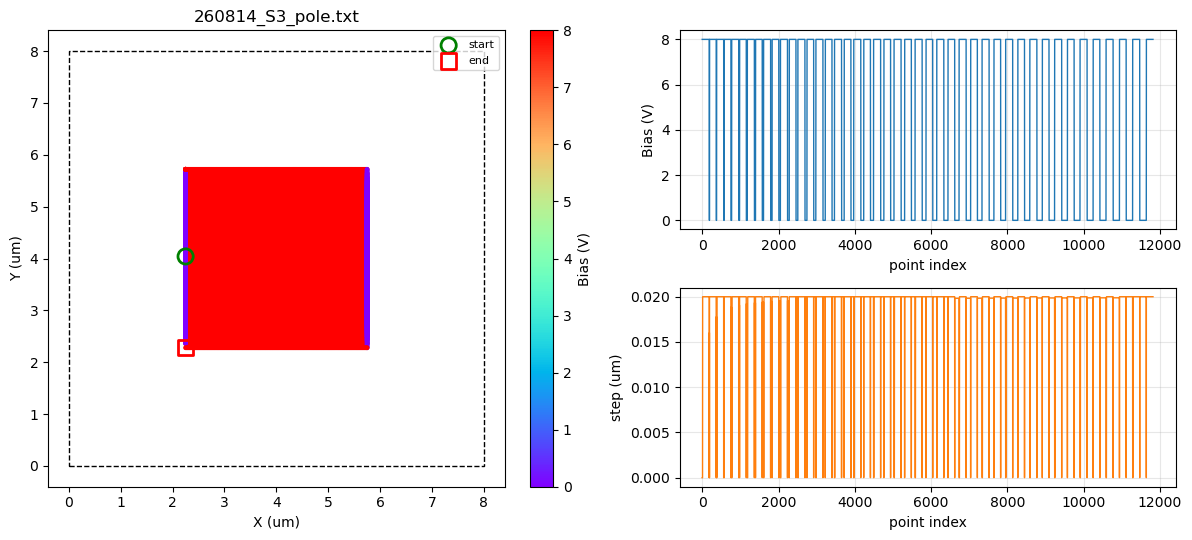

  running… ETA 7.9 min


In [ ]:
# --- [3.2]  pole the central 3.5 um to a uniform, known starting state --
# Constant sign, no flip - the "constant" scheme that reliably poles (C13). This
# is INTENTIONALLY not charge-balanced; that is the whole point, so run_traj's
# net-DC warning is expected here and only here.
# Why 3.5 um and not 2: it has to contain the seed's 625 nm halo (see [3.1]).
# Why it is worth doing: a uniform start makes "rotated by 60 deg" unambiguous.
# Cost: it closes the orbit gate. C9 showed a 65 % open gate did not help
# selection, so we are not giving up anything that has ever worked.
# --- kernel-freshness guard --------------------------------------------
# The notebook FILE and the LIVE KERNEL can disagree: editing a cell does nothing
# until it is re-run. On 14 Aug this cell died with
#   TypeError: gen_center_out_raster() got an unexpected keyword argument
#              'start_sign'
# because the kernel still held the pre-start_sign definition. Check the
# signature up front and name the cell to re-run, instead of failing mid-call.
import inspect
_checks = [(gen_center_out_raster,
            {'start_sign', 'alt_period', 'within_cycle', 'flip_each_cycle'},
            '[LIB-CENTEROUT]')]
for _nm, _cellname in (('even_cycles', '[WRAPPERS]'),
                       ('run_traj', '[WRAPPERS]'),
                       ('orbit_balance', '[TOOLKIT]'),
                       ('change_map', '[TOOLKIT]')):
    if _nm not in globals():
        raise RuntimeError(f'{_nm}() is not defined in this kernel. Re-run the '
                           f'{_cellname} cell, then re-run this cell.')
for _fn, _need, _cellname in _checks:
    _miss = _need - set(inspect.signature(_fn).parameters)
    if _miss:
        raise RuntimeError(
            f'{_fn.__name__}() in this kernel is missing {sorted(_miss)}. '
            f'Re-run the {_cellname} cell, then re-run this cell.')
print('  kernel definitions are current')

POLE_PITCH = 0.08
POLE_H = even_cycles(POLE_WH, POLE_PITCH)
print(f'  poling {POLE_WH} x {POLE_H:.2f} um, pitch {POLE_PITCH*1000:.0f} nm')

# Build BEFORE printing a duration. An earlier version of this cell estimated the
# time as 2*W*(H/pitch)/speed and reported 10.3 min for a 7.9 min write: it
# double-counted because even_cycles treats a forward+backward pair as ONE cycle,
# and it ignored the pitch-step segments. The point count is the only honest
# source, and run_traj prints it again from the file it actually loads.
tb_pole = gen_center_out_raster(W_um=POLE_WH, H_um=POLE_H, pitch_um=POLE_PITCH,
                               angle_deg=0.0, center_um=(CTR, CTR), v=8.0,
                               flip_each_cycle=False, within_cycle='same',
                               start_sign=+1, field_um=FRAME,
                               step_um=0.02, n_pt=10)
_xp, _yp, _vp = tb_pole.to_arrays()
print(f'  {len(_vp)} pts -> path {len(_vp)*0.02:.0f} um -> '
      f'{len(_vp)*0.02/0.5/60:.1f} min at 0.5 um/s')
print(f'  mean V {_vp.mean():+.3f} V - net DC is INTENTIONAL here (this is a pole,')
print(f'  not a balanced write), so run_traj will warn and that warning is correct.')

goto_ldart()
run_traj(tb_pole, os.path.join(CONFIG["work_dir"], "260814_S3_pole.txt"),
         speed_um_s=0.5)

goto_ldart(); f_s_p = frame()
goto_vdart(); f_s_pv = frame(); g_s_p = orbit_balance(f_s_pv)

print('\n--- AFTER POLING ---')
p_s = score(f_s_p, 'poled core', CORE)
print()
POLED = change_map(f_s_b2, f_s_p, CORE, show=True, label='poling, core')

THETA1 = p_s['peak']
TARGET = np.mod(THETA1 + 60.0, 180.0)
print(f'\n  orbit gate {100*g_s_b["frac"]:.1f} -> {100*g_s_p["frac"]:.1f} % up'
      f'   ({"closed, as intended" if not (0.2 <= g_s_p["frac"] <= 0.8) else "still open"})')
print(f'  stripe direction {THETA0:.1f} -> {THETA1:.1f} deg,   '
      f'anisotropy {b_s["aniso"]:.0f} -> {p_s["aniso"]:.0f}')
print(f'  d_theta from poling: |d|<15 {POLED["m0"]:.3f}  '
      f'+60 {POLED["mp60"]:.3f}  -60 {POLED["mm60"]:.3f}')
print(f'  -> SEED TARGET is now theta_1 + 60 = {TARGET:.1f} deg')
if abs((THETA1 - THETA0 + 90) % 180 - 90) > 20:
    print('  !! poling itself moved the direction >20 deg. Use theta_1 as the')
    print('     reference - the target is 60 deg from where we ACTUALLY are now.')
if p_s['aniso'] < b_s['aniso'] * 0.5:
    print('  !! poling halved the anisotropy: it disordered rather than aligned.')
    print('     Consider seeding on the virgin state instead (skip to [3.3] on')
    print('     a fresh spot) - a disordered start cannot show a clean rotation.')


In [ ]:
# --- [3.3]  the seed: antiparallel pulse LINES along theta_1 + 60 -------
# Geometry, forced by two measured numbers:
#   WITHIN a line: 0.30 um spacing, so the 625 nm halos (C11) overlap four-deep
#     and coalesce into ONE continuous poled line pointing at the target.
#   BETWEEN lines: >= 2 x r_eff = 1.25 um. Any closer and opposite-sign halos
#     overlap and cancel, which is exactly why a Lambda-spaced (325 nm) template
#     is impossible at this halo size.
R_EFF    = 0.625      # C11. Lower it if [3.4] measures a smaller ROTATION radius.
N_ROWS   = 2          # 2 = two antiparallel lines: the minimal BALANCED template
ROW_SEP  = max(2 * R_EFF, 1.25)
SEED_V   = 10.0
SEED_N   = 250        # 250 x 0.02 / 0.5 = 10 s -> 100 V.s, vs the ~40 threshold (C21)
SEED_DX  = 0.25       # within-line spacing
SEED_LEN = 1.5        # line length; halo must stay inside the poled square

th = np.deg2rad(TARGET)
ux, uy = np.cos(th), np.sin(th)          # along a line
nx_, ny_ = -np.sin(th), np.cos(th)       # across the lines

n_per = int(SEED_LEN / SEED_DX) + 1
if n_per % 2:
    n_per -= 1                           # even, so a split row can cancel exactly

# --- sign scheme: alternate ACROSS lines; if the row count is odd, the last
# --- line is split into +half / -half so it contributes zero on its own.
rows = np.arange(N_ROWS) - (N_ROWS - 1) / 2.0
sites = []
for r_i, roff in enumerate(rows):
    split = (N_ROWS % 2 == 1) and (r_i == N_ROWS - 1)
    for k in range(n_per):
        s = (k - (n_per - 1) / 2.0) * SEED_DX
        if split:
            sgn = +1 if k < n_per // 2 else -1
        else:
            sgn = +1 if r_i % 2 == 0 else -1
        sites.append((CTR + s * ux + roff * ROW_SEP * nx_,
                      CTR + s * uy + roff * ROW_SEP * ny_,
                      sgn * SEED_V, r_i))

tb_s = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
for (x0, y0, v0, ri) in sites:
    tb_s.dwell((x0, y0), v0, n=SEED_N)
_x, _y, _v = tb_s.to_arrays()

q = SEED_V * SEED_N * 0.02 / 0.5
print(f'  {N_ROWS} line(s) of {n_per} pulses along {TARGET:.1f} deg')
print(f'  within-line {SEED_DX*1000:.0f} nm -> halos merge into a continuous line')
print(f'  between lines {ROW_SEP*1000:.0f} nm = 2 x r_eff -> lines act independently')
print(f'  {SEED_V:.0f} V x {SEED_N*0.02/0.5:.0f} s = {q:.0f} V.s per pulse'
      f'   (rotation threshold ~40 V.s, C21)')
if N_ROWS % 2:
    print(f'  odd row count: line {N_ROWS-1} is split +half / -half so the file '
          f'still sums to zero')
print(f'  polarity period across the lines: {2*ROW_SEP*1000:.0f} nm '
      f'= {2*ROW_SEP*1000/LAM0:.1f} x Lambda')
print(f'  extent X[{_x.min():.2f},{_x.max():.2f}] Y[{_y.min():.2f},{_y.max():.2f}] um')
print(f'  {len(_x)} pts -> {len(_x)*0.02/0.5/60:.1f} min write   '
      f'mean V {_v.mean():+.5f}')

assert abs(_v.mean()) < 0.01, f'net DC {_v.mean():+.4f} V - fix the sign scheme'
assert np.abs(_v).max() <= V_MAX + 1e-9, 'over the +-10 V ceiling'

# --- regions derived from the ACTUAL halo extent, [2.1]-style guard ------
HX0, HX1 = _x.min() - R_EFF, _x.max() + R_EFF
HY0, HY1 = _y.min() - R_EFF, _y.max() + R_EFF
CORE   = (_x.min() - 0.1, _x.max() + 0.1, _y.min() - 0.1, _y.max() + 0.1)
CTRL_L = (0.40, HX0 - 0.20, 0.60, FRAME - 0.60)
CTRL_R = (HX1 + 0.20, FRAME - 0.40, 0.60, FRAME - 0.60)
area = lambda r: (r[1] - r[0]) * (r[3] - r[2])
PX0, PX1 = CTR - POLE_WH / 2, CTR + POLE_WH / 2

print(f'\n  seed extent  X[{_x.min():.2f},{_x.max():.2f}] '
      f'Y[{_y.min():.2f},{_y.max():.2f}] um')
print(f'  halo reaches X[{HX0:.2f},{HX1:.2f}] Y[{HY0:.2f},{HY1:.2f}] um')
print(f'  poled square X[{PX0:.2f},{PX1:.2f}] um')
for nm, r in (('CORE', CORE), ('CTRL_L', CTRL_L), ('CTRL_R', CTRL_R)):
    print(f'  {nm:7s} [{r[0]:5.2f},{r[1]:5.2f}] x [{r[2]:5.2f},{r[3]:5.2f}]  '
          f'{area(r):6.2f} um^2')

bad = []
if HX0 < PX0 or HX1 > PX1 or HY0 < PX0 or HY1 > PX1:
    bad.append(f'the halo runs outside the poled square, so part of the seed acts '
               f'on virgin material - raise POLE_WH to '
               f'{2*max(CTR-HX0, HX1-CTR, CTR-HY0, HY1-CTR):.1f} um or shorten SEED_LEN')
for nm, r in (('CTRL_L', CTRL_L), ('CTRL_R', CTRL_R)):
    if r[1] <= r[0]:
        bad.append(f'{nm} has zero width - the halo fills the frame')
    elif area(r) < 1.5:
        bad.append(f'{nm} is only {area(r):.2f} um^2; strips that worked were ~3')
if bad:
    print('\n*** GEOMETRY NOT USABLE - no pulses fired ***')
    for b_ in bad:
        print('   -', b_)
    raise ValueError('raise FRAME, lower N_ROWS, or shorten SEED_LEN')
print('  geometry OK: halo inside the poled square, both controls clear of it.')

visualize_trajectory(tb=tb_s, field_um=FRAME,
                     title=f'seed: {N_ROWS} line(s) at {TARGET:.0f} deg, '
                           f'{ROW_SEP*1000:.0f} nm apart')
SEED_SITES = [dict(x=x0, y=y0, v=v0, row=ri, n=SEED_N) for x0, y0, v0, ri in sites]

goto_ldart()
run_traj(tb_s, os.path.join(CONFIG["work_dir"],
                            f"260814_S3_seed_{TARGET:.0f}deg.txt"), speed_um_s=0.5)
goto_ldart(); f_s_a = frame()
goto_vdart(); f_s_av = frame(); g_s_a = orbit_balance(f_s_av)


In [ ]:
# --- [TRIAD]  measure THIS area's triad before trusting any w or aniso -
# Run this on the best-ordered frame of the area, then re-run the scoring cells.
# 14 Aug: the new area's directors are {2, 62, 122}, a uniform 28 deg off the
# hard-coded (30, 90, 150). With +-12.5 deg wedges centred on the wrong angles,
# every true director fell OUTSIDE its wedge, so w and aniso were integrating
# tails. Symptom to recognise: aniso collapses (CTRL_L read 39) while the frame
# plainly shows stripes, and w looks mushy and near-equal.
for _t in ('PZTO_LDART_0018.ibw', 'PZTO_LDART_0020.ibw', 'PZTO_LDART_0021.ibw'):
    measure_triad(_t)
    print()

# The virgin frame is too broad to define a triad; the poled one is clean.
set_triad('PZTO_LDART_0020.ibw')

print('\n  Now re-run the scoring for this area. Anything printed with the old')
print('  FAM - w, aniso, peak, and change_map\'s "switched" - is void. The')
print('  d_theta masses (|d|<15, +-60) are DIFFERENCES and stay valid.')


  QC PZTO_LDART_0021.ibw: consistency 0.92 (>=0.40)   xi 94 nm = 3 px (>=3)   Lam 482 nm (200-600)   |A| 67.6 pm   defl SP 0.65 V   r12 +0.97
     -> USABLE
after seed, core           w=(0.351,0.226,0.423) +-0.010  aniso  174.1  peak  65.0 deg
                           |A|  49.1 pm   walls 0.605   Lam(30/90/150) 245/388/245 nm   f_trk 643+-1.5 kHz
  QC PZTO_LDART_0021.ibw: consistency 0.92 (>=0.40)   xi 94 nm = 3 px (>=3)   Lam 482 nm (200-600)   |A| 67.6 pm   defl SP 0.65 V   r12 +0.97
     -> USABLE
after seed, ctrl-L         w=(0.206,0.400,0.394) +-0.011  aniso   39.1  peak 125.0 deg
                           |A|  57.7 pm   walls 0.605   Lam(30/90/150) 301/261/245 nm   f_trk 643+-1.5 kHz

  change_map CORE
    registration +0, +0 nm   corr peak 0.786   coverage 98 %   r12 +0.96/+0.97
    usable area 3.75 um^2 (0 % of the region lost to the drift border)
    area fingerprint: height r = +0.946   offsets (0.0, 0.0) -> (0.0, 0.0) um
    SWITCHED 0.069   floor 0.087   NET -0.017
    d

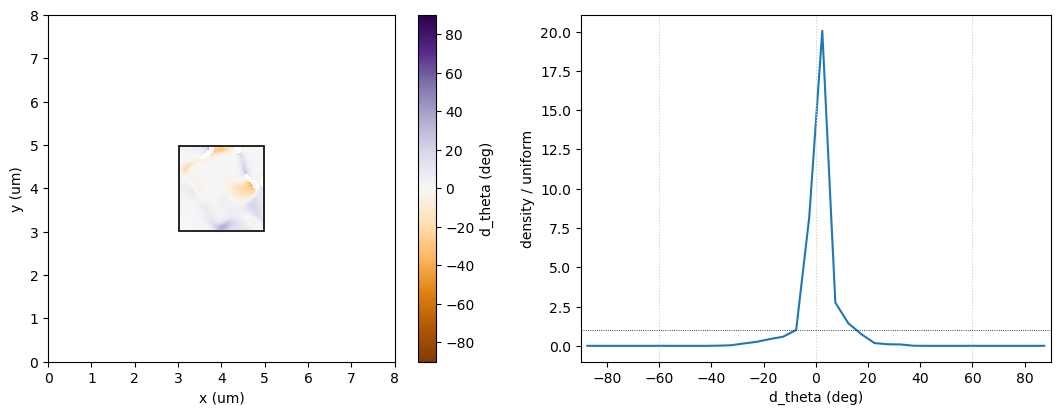

  change_map CTRL_L
    registration +0, +0 nm   corr peak 0.786   coverage 91 %   r12 +0.96/+0.97
    usable area 12.77 um^2 (0 % of the region lost to the drift border)
    area fingerprint: height r = +0.946   offsets (0.0, 0.0) -> (0.0, 0.0) um
    SWITCHED 0.067   floor 0.087   NET -0.020
    d_theta mass: |d|<15 0.986   near +60 0.000   near -60 0.000   elsewhere 0.014
    -> UNCHANGED: the distribution is still a spike at zero.
  change_map CTRL_R
    registration +0, +0 nm   corr peak 0.786   coverage 93 %   r12 +0.96/+0.97
    usable area 12.77 um^2 (0 % of the region lost to the drift border)
    area fingerprint: height r = +0.946   offsets (0.0, 0.0) -> (0.0, 0.0) um
    SWITCHED 0.076   floor 0.087   NET -0.011
    d_theta mass: |d|<15 0.996   near +60 0.000   near -60 0.000   elsewhere 0.004
    -> UNCHANGED: the distribution is still a spike at zero.

  NOTE the controls are UNPOLED material, so they answer "is the change
  local to the seed", not "is it the poling". Pol

In [72]:
# --- [3.4]  did the seed nucleate a rotated family? ---------------------
a_s = score(f_s_a, 'after seed, core', CORE)
score(f_s_a, 'after seed, ctrl-L', CTRL_L)
print()
SEED = {nm: change_map(f_s_p, f_s_a, rg, show=(nm == 'CORE'), label=nm)
        for nm, rg in (('CORE', CORE), ('CTRL_L', CTRL_L), ('CTRL_R', CTRL_R))}
print()
print('  NOTE the controls are UNPOLED material, so they answer "is the change')
print('  local to the seed", not "is it the poling". Poling is already differenced')
print('  out of CORE: both frames in the CORE pair are post-poling.')
print()
# how far from the seed line did the rotation reach? this is the ROTATION radius,
# which is the number that decides whether a Lambda-periodic template is possible.
db, hb = ibw(f_s_p); da, ha = ibw(f_s_a)
N = db[0].shape[0]; L = float(hb['ScanSize']) * 1e6; px = L / N * 1000.0
di, dj, pk = register(db[0], da[0])
Sb, _, _ = signed(db); Sa, _, _ = signed(da)
Sa = np.roll(np.roll(Sa, di, 0), dj, 1)
thb, cb = orient(Sb, px); tha, ca = orient(Sa, px)
dth = (tha - thb + 90.0) % 180.0 - 90.0
good = (cb >= 0.10) & (ca >= 0.10)
yy, xx = np.indices((N, N)); X = (xx + .5) * L / N; Y = (yy + .5) * L / N
rr = np.full((N, N), np.inf)
for s in SEED_SITES:
    rr = np.minimum(rr, np.hypot(X - s['x'], Y - s['y']))

print(f"  distance from the seed line   |d|<15    +60    -60   mean |dth|")
edges = [0, 0.2, 0.4, 0.6, 0.9, 1.2, 1.6, 2.2]
prof = []
for k in range(len(edges) - 1):
    m = (rr >= edges[k]) & (rr < edges[k + 1]) & good
    if m.sum() < 200:
        continue
    h, e = np.histogram(dth[m], bins=36, range=(-90, 90)); h = h / h.sum()
    c_ = e[:-1] + 2.5
    ms = lambda a, w=15: float(h[(c_ > a - w) & (c_ < a + w)].sum())
    prof.append((0.5 * (edges[k] + edges[k + 1]), ms(0), ms(60), ms(-60)))
    print(f"  {edges[k]*1000:5.0f}-{edges[k+1]*1000:<5.0f} nm  {m.sum():7d} px"
          f"{ms(0):9.3f}{ms(60):7.3f}{ms(-60):7.3f}"
          f"{np.abs(dth[m]).mean():11.1f}")
if prof:
    below = [p[0] for p in prof if p[1] > 0.85]
    r_rot = below[0] if below else np.nan
    print(f"\n  ROTATION RADIUS (where |d|<15 recovers above 0.85): "
          + (f"{r_rot*1000:.0f} nm" if np.isfinite(r_rot) else "beyond the profile"))
    if np.isfinite(r_rot) and r_rot < 0.20:
        print(f"  -> SMALLER than the 625 nm out-of-plane halo. A Lambda-periodic")
        print(f"     template IS possible: set R_EFF = {r_rot:.2f} in [3.3] and")
        print(f"     ROW_SEP will follow, then re-run with N_ROWS = 3.")

c = SEED['CORE']; el = 1 - c['m0'] - c['mp60'] - c['mm60']
pk_ = max(c['mp60'], c['mm60'])
print(f"\n--- DID THE SEED WORK? ---")
print(f"  target direction was {TARGET:.1f} deg")
print(f"  core: |d|<15 {c['m0']:.3f}   +60 {c['mp60']:.3f}   -60 {c['mm60']:.3f}"
      f"   else {el:.3f}")
print(f"  peak direction {p_s['peak']:.1f} -> {a_s['peak']:.1f} deg "
      f"(target {TARGET:.1f})")
print(f"  controls: {SEED['CTRL_L']['switched']:.3f} / "
      f"{SEED['CTRL_R']['switched']:.3f} switched, floor {CHANGE_FLOOR:.3f}")
hit = abs((a_s['peak'] - TARGET + 90) % 180 - 90) < 15
if pk_ > 0.5 and pk_ > el:
    print('\n  -> CLEAN +-60 ROTATION seeded by the pulse line. This is the result.')
    print('     Next: [3.5] to reinforce, then repeat at a second target angle to')
    print('     show the direction is chosen and not just perturbed.')
elif hit and c['m0'] < 0.70:
    print('\n  -> the peak MOVED TO THE TARGET. Rotation is happening even if the')
    print('     d_theta histogram is still mixed. Reinforce with [3.5].')
elif c['m0'] < 0.70:
    print('\n  -> the seed changed the texture but not toward the target. Compare')
    print('     against the plain write (disorder 0.16, C8): if similar, the seed')
    print('     is acting as an ordinary perturbation, not a template.')
else:
    print('\n  -> the seed did nothing. Check the charge per pulse reached 40 V.s,')
    print('     and that the controls are at the floor. If both are fine, raise')
    print('     SEED_N or go to N_ROWS = 3 so the template has a period.')
disorder_axis(SEED['CORE'], SEED['CTRL_L'],
              labels=[f'seed at {TARGET:.0f} deg', 'ctrl-L'])


---
## Single-pulse charge threshold — the first triad rotation  `[CHG-doc]`

`[2.x]` returned a clean null: the 18-pulse lattice at 8 V / 1 s left the in-plane
orientation completely untouched (|Δθ|<15° = **0.990** inside the pulse discs,
disorder 0.00). It is the best-controlled paired comparison of the campaign —
floor 0.015, height fingerprint +0.95, coverage 100 %, controls at 0.041–0.054.

**But running the per-pulse analysis on the *existing* ladder data
(LDART_0010 → LDART_0011), which `[1.3]` never did on the lateral channel,
changes the picture.**

| V | dwell | charge | \|Δθ\|<15° | mass at +60° | θ before → after | \|Δθ\| |
|---|---|---|---|---|---|---|
| **−10** | **5 s** | **50 V·s** | **0.153** | **0.305** | 54.3° → 120.0° | **65.8°** |
| +8 | 5 s | 40 V·s | 0.383 | 0.092 | 134.1° → 102.1° | 32.0° |
| +6 | 5 s | 30 V·s | 0.988 | 0.000 | 127.2° → 118.9° | 8.3° |
| −4 | 5 s | 20 V·s | 0.624 | 0.000 | 98.9° → 111.1° | 12.3° |
| −10 | 1 s | 10 V·s | 0.990 | 0.000 | 111.5° → 111.1° | 0.4° |
| +8 | 1 s | **8 V·s** | 0.840 | 0.000 | 99.2° → 98.5° | 0.7° |

**The −10 V / 5 s pulse rotated its own patch by 65.8°, with 30.5 % of the Δθ mass
at +60°.** That is the first ±60° concentration measured anywhere in the campaign,
against 0.000–0.092 for every other pulse and every write.

There is a threshold near **40 V·s**: above it the patch moves by 32–66°, below
30 V·s by under 13°.

### Why `[2.x]` failed, quantitatively

The lattice used **8 V × 1 s = 8 V·s per pulse, six times below threshold** — and
that is the exact entry in the table above that moved its patch by 0.7°. Picking
8 V / 1 s as a "mid-range with headroom" default was the wrong call, and the
threshold was already latent in data we had not analysed.

### On using a smaller area

Two things cut against it, and one for.

- **Scan time does not depend on frame size.** It is lines × rate: a 256-px frame
  is 4.3 min whether it covers 2 µm or 5 µm. Shrinking the frame saves nothing;
  shrinking the *pixel count* does.
- **One halo is 1.25 µm across.** In a 2–3 µm frame a single pulse fills most of
  it, leaving no room for a control region outside the halo — the failure mode
  that has already invalidated three results here.
- **What is genuinely true:** Λ = 325 nm and r_eff = 625 nm, so **one pulse
  already spans about two superdomain widths.** A lattice is not needed to
  address a single superdomain. That is where the time saving comes from — four
  pulses instead of eighteen, ~2 min of writing instead of 40 min of lattice
  plus rewrite.

So `[CHG.1]` keeps the 5 µm frame, so halos stay separable and the control stays
valid, and spends the saving on dwell.

### The experiment

Four pulses at 10 V, dwells 5 / 10 / 15 / 20 s → **50 / 100 / 150 / 200 V·s**,
starting at the observed threshold and going up. Dwell ratios 1:2:3:4 with signs
+, −, −, + balance the charge **exactly**. 2 µm spacing, against 2 × r_eff =
1.25 µm, so the halos are well separated.

The question is no longer "does anything rotate" but **"does more charge give a
cleaner ±60° rotation, or just more disorder?"** If the +60° mass rises above ~0.5
while the "elsewhere" fraction falls, that is controlled triad switching.

In [ ]:
# --- [CHG.1]  single-pulse charge ladder around the 40-50 V.s threshold -
# Four isolated pulses, 10 V, dwell 5 / 10 / 15 / 20 s = 50 / 100 / 150 / 200 V.s.
# Dwell ratios 1:2:3:4 with signs +,-,-,+ give EXACTLY zero net charge.
CHG_V = 10.0
CHG_N = [125, 250, 375, 500]          # x 0.02 um / 0.5 um/s = 5, 10, 15, 20 s
CHG_S = [+1, -1, -1, +1]              # 125 - 250 - 375 + 500 = 0
CHG_XY = [(1.5, 1.5), (3.5, 1.5), (1.5, 3.5), (3.5, 3.5)]   # 2 um apart
assert sum(s * n for s, n in zip(CHG_S, CHG_N)) == 0, 'net charge is not zero'

tb_c = TrajectoryBuilder(field_um=5.0, step_um=0.02, travel_v=0.0)
print(f"{'#':>2s}{'x,y':>12s}{'V':>7s}{'dwell s':>9s}{'charge V.s':>12s}")
for k, ((x0, y0), n, s) in enumerate(zip(CHG_XY, CHG_N, CHG_S)):
    tb_c.dwell((x0, y0), s * CHG_V, n=n)
    print(f"{k:2d}{f'{x0},{y0}':>12s}{s*CHG_V:+7.0f}{n*0.02/0.5:9.1f}"
          f"{CHG_V*n*0.02/0.5:12.0f}")
_x, _y, _v = tb_c.to_arrays()
print(f"\n  {len(_x)} pts -> {len(_x)*0.02/0.5/60:.1f} min   "
      f"mean V {_v.mean():+.5f}   peak |V| {np.abs(_v).max():.1f} of {V_MAX}")
print('  halo separation 2.00 um against 2 x r_eff = 1.25 um -> well separated')
print('  CAUTION: 20 s at 10 V on one spot is the most aggressive single event of')
print('  the campaign. Sites are visited in ascending dwell, so watch the')
print('  topography channel and stop if the surface starts to change.')

goto_ldart(); f_c_b1 = frame(); f_c_b2 = frame()
contact_check(f_c_b2)
goto_vdart(); f_c_bv = frame(); g_c_b = orbit_balance(f_c_bv)

goto_ldart()
run_traj(tb_c, os.path.join(CONFIG["work_dir"], "260814_charge_ladder.txt"),
         speed_um_s=0.5)

goto_ldart(); f_c_a = frame()
goto_vdart(); f_c_av = frame(); g_c_a = orbit_balance(f_c_av)
print(f"\n  gate: {100*g_c_b['frac']:.1f} % -> {100*g_c_a['frac']:.1f} % up")
_zb, _hb = ibw(f_c_b2); _za, _ha = ibw(f_c_a)
print(f"  topography rms: {_zb[0].std()*1e9:.3f} -> {_za[0].std()*1e9:.3f} nm"
      f"   ({'no gross damage' if _za[0].std() < 2*_zb[0].std() else '*** SURFACE CHANGED ***'})")


In [ ]:
# --- [CHG.2]  per-pulse rotation against charge ------------------------
TBL = [dict(x=x, y=y, v=s * CHG_V, ms=n * 0.02 / 0.5 * 1000, n=n)
       for (x, y), n, s in zip(CHG_XY, CHG_N, CHG_S)]
print('out-of-plane halo, for the record:')
HALO_C = pulse_halo(f_c_bv, f_c_av, TBL, rmax_um=1.8)
print()

db, hb = ibw(f_c_b2); da, ha = ibw(f_c_a)
N = db[0].shape[0]; L = float(hb['ScanSize']) * 1e6; px = L / N * 1000.0
di, dj, pk = register(db[0], da[0])
Sb, _, rb = signed(db); Sa, _, ra = signed(da)
Sa = np.roll(np.roll(Sa, di, 0), dj, 1)
thb, cb = orient(Sb, px); tha, ca = orient(Sa, px)
dth = (tha - thb + 90.0) % 180.0 - 90.0
good = (cb >= 0.10) & (ca >= 0.10)
yy, xx = np.indices((N, N)); X = (xx + .5) * L / N; Y = (yy + .5) * L / N
print(f'  registration ({di:+d},{dj:+d}) px, corr {pk:.3f}, '
      f'r12 {rb:+.2f}/{ra:+.2f}')

cmean = lambda a: np.mod(np.rad2deg(0.5 * np.angle(
    np.mean(np.exp(2j * np.deg2rad(a))))), 180.0)
print(f"\n  {'V':>5s}{'V.s':>7s}{'|d|<15':>9s}{'+60':>7s}{'-60':>7s}{'else':>7s}"
      f"{'th_b':>7s}{'th_a':>7s}{'|dth|':>7s}  verdict")
far = np.ones((N, N), bool)
for t in TBL:
    far &= np.hypot(X - t['x'], Y - t['y']) > 1.2
CHG = []
for t in TBL:
    m = (np.hypot(X - t['x'], Y - t['y']) < 0.35) & good
    if m.sum() < 100:
        print(f"  {t['v']:+5.0f}  too few pixels ({m.sum()})"); continue
    h, e = np.histogram(dth[m], bins=36, range=(-90, 90)); h = h / h.sum()
    c_ = e[:-1] + 2.5
    ms = lambda a, w=15: float(h[(c_ > a - w) & (c_ < a + w)].sum())
    m0, mp, mm = ms(0), ms(60), ms(-60); el = 1 - m0 - mp - mm
    tb_, ta_ = cmean(thb[m]), cmean(tha[m])
    dd = abs((ta_ - tb_ + 90) % 180 - 90)
    pk_ = max(mp, mm)
    verdict = ('CLEAN +-60 ROTATION' if pk_ > 0.5 and pk_ > el
               else 'ROTATED, mixed' if pk_ > 0.20
               else 'disordered' if m0 < 0.6 else '-')
    CHG.append(dict(charge=CHG_V * t['n'] * 0.02 / 0.5, m0=m0, mp=mp, mm=mm,
                    el=el, dd=dd, verdict=verdict, v=t['v']))
    print(f"  {t['v']:+5.0f}{CHG_V*t['n']*0.02/0.5:7.0f}{m0:9.3f}{mp:7.3f}"
          f"{mm:7.3f}{el:7.3f}{tb_:7.1f}{ta_:7.1f}{dd:7.1f}  {verdict}")

hf, ef = np.histogram(dth[far & good], bins=36, range=(-90, 90))
hf = hf / hf.sum(); cf = ef[:-1] + 2.5
msf = lambda a, w=15: float(hf[(cf > a - w) & (cf < a + w)].sum())
print(f"\n  CONTROL, > 1.2 um from every site: |d|<15 {msf(0):.3f}   "
      f"+60 {msf(60):.3f}   -60 {msf(-60):.3f}   ({(far & good).sum()} px)")
if msf(0) < 0.85:
    print('  !! the control moved too. The pair is contaminated by drift or a '
          'tune change; do not read the per-pulse rows.')

print('\n  reference from the ladder: -10 V / 5 s gave |d|<15 0.153, +60 0.305, '
      '|dth| 65.8 deg')
if CHG:
    best = max(CHG, key=lambda r: max(r['mp'], r['mm']))
    pk_ = max(best['mp'], best['mm'])
    if pk_ > 0.5 and pk_ > best['el']:
        print(f"  -> CONTROLLED TRIAD SWITCHING at {best['charge']:.0f} V.s.")
        print('     Next: fix the charge there and sweep the pulse POSITION')
        print('     relative to a chosen superdomain, to test whether the')
        print('     rotation SENSE (+60 vs -60) can be selected.')
    elif pk_ > 0.20:
        print('  -> rotation confirmed, still mixed with disorder. More charge')
        print('     broadens rather than sharpens, so the next variable is pulse')
        print('     SHAPE - a short train of sub-threshold pulses - not more charge.')
    else:
        print('  -> did not reproduce the ladder result. Check the control row')
        print('     first; if it is clean, the difference is the +-10 V polarity')
        print('     or the 0.40 V setpoint, both of which changed since 09:39.')


---
## The write gate — run this before ANY pattern experiment  `[WGATE-doc]`

R4 produced a total null: |Δθ|<15° between 0.964 and 1.000 in all nine panels,
±60° mass 0.000, peak direction unchanged to the degree at every stage. So did the
Step 3 seed. Neither result says anything about the physics, because **probe #3 is
not injecting DC charge.**

Measured with the method that established C11 — Δ(up fraction) near the pulse
sites minus the far field:

| write | probe | charge per pulse | Δ(up), near − far | |
|---|---|---|---|---|
| 13 Aug ladder | #2 | 50 V·s | **+0.389** | wrote |
| Step 3 seed | #3 | **100 V·s** | −0.044 | nothing |
| R4 lattice | #3 | 10 V·s | ~+0.02 | nothing |

The Step 3 row is the decisive one: **twice** the dose that worked, and nothing.
So this is not a dose problem, and my `PULSE_N = 25` in R4 (10 V·s, four times
below the C21 threshold — the same mistake I had already recorded against `[2.3]`)
was not the binding cause, only an additional one.

The leading explanation is the **litho writing deflection setpoint, which is a
separate parameter from the DART imaging setpoint.** If the writing setpoint is too
low the tip is not pressed hard enough during the trajectory, electrical contact is
poor, and no charge is injected — while imaging, which uses its own setpoint, stays
perfect. That fits every observation without needing a coincidence, and it explains
why both probe #3 writes failed *regardless of dose*.

(My earlier guess was a contaminated apex passing 650 kHz AC and blocking DC. That
would have required a fresh probe to arrive already fouled. The setpoint
explanation is more economical and it is directly fixable.)

**Consequence: the ~40 V·s threshold from C21 is not transferable.** It was
measured at whatever litho setpoint was in force with probe #2. With the writing
force corrected, the threshold must be measured again — which is what this gate
does, across 10 to 400 V·s.

**Process failure worth naming.** `FINDINGS.md` §5 item 3 already said: *"No
positive control on record. We have never deliberately written a known pattern and
read it back as a hardware validation. `[PROBE.1]` exists and has not been run."*
I designed and shipped a nine-condition experiment without it. R4 cost ~70 min of
instrument time and cannot answer its own question.

`[WGATE]` is cheap — six isolated pulses, ~1 min of writing plus one VDART frame,
about 6 min total — and it makes every later null interpretable.


In [ ]:
# --- [WGATE]  can this tip write? Six isolated pulses, one frame --------
# Isolated on purpose: write_check needs untreated area >1.3 um from every site
# to form a far field. R4's lattice filled the frame, so its far field was empty
# and the test returned nan - the experiment could not even audit itself.
# RUN THIS IN A SACRIFICIAL SPOT. It dumps up to 400 V.s and carries about
# -260 V.s net (alternating signs cannot cancel unequal dwells), so it locally
# poles. The 8 um area that R4 used is ideal: already written into, so worthless
# as a pristine baseline, but its VDART frame can serve as the 'before'.
WG_SETPOINT = 1.65      # <-- record the LITHO writing setpoint you set, in V
WG_REUSE_BEFORE = 1.3  # e.g. 'PZTO_VDART_0016.ibw' to skip a 4.3 min frame
WG_V   = 10.0                       # the ceiling; no point testing below it
WG_S   = 2.2                        # site spacing, > 2 x r_eff = 1.25 um
WG_DW  = [1.0, 2.0, 5.0, 10.0, 20.0, 40.0]      # seconds -> 10..400 V.s
WG_XY  = [(2.0, 2.0), (4.2, 2.0), (6.4, 2.0), (2.0, 4.2), (4.2, 4.2), (6.4, 4.2)]

# alternate the sign so the file carries no net DC, and pair equal dwells so the
# cancellation is exact rather than approximate
WG_SG  = [+1, -1, +1, -1, +1, -1]
n_pts  = [int(round(d * 0.5 / 0.02)) for d in WG_DW]
print(f'{"site":>16s}{"V":>7s}{"dwell s":>9s}{"charge V.s":>12s}')
for (xy, sg, d, n) in zip(WG_XY, WG_SG, WG_DW, n_pts):
    print(f'  ({xy[0]:.1f},{xy[1]:.1f}){sg*WG_V:9.0f}{d:9.1f}{WG_V*d:12.0f}')
print(f'  total dwell {sum(WG_DW):.0f} s; charges span '
      f'{WG_V*min(WG_DW):.0f}-{WG_V*max(WG_DW):.0f} V.s')
print(f'  C21 threshold was ~40 V.s, and the ladder wrote at 50 V.s')

# TWO files, run back to back. The first proves bias reaches the tip after the
# software restart; the SECOND proves the panel released after run #1, which is
# the actual bug. One run cannot distinguish "fixed" from "fresh state that will
# stick again".
tb_wg = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
tb_wg2 = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
for idx_, (xy, sg, n) in enumerate(zip(WG_XY, WG_SG, n_pts)):
    (tb_wg if idx_ < 3 else tb_wg2).dwell(xy, sg * WG_V, n=n)
_x, _y, _v = tb_wg.to_arrays()
WG_SITES = [(xy[0], xy[1], sg * WG_V) for xy, sg in zip(WG_XY, WG_SG)]
# exact balance needs equal +/- charge; report it rather than assume
_q = sum(sg * WG_V * d for sg, d in zip(WG_SG, WG_DW))
print(f'\n  {len(_v)} pts -> {len(_v)*0.02/0.5/60:.1f} min   mean V {_v.mean():+.4f}')
print(f'  net charge {_q:+.0f} V.s  '
      f'({"balanced" if abs(_q) < 1 else "NOT balanced - the sign pattern cannot cancel unequal dwells; acceptable for a one-off gate but note it"})')
visualize_trajectory(tb=tb_wg, field_um=FRAME, title='write gate: 6 isolated pulses')

if WG_SETPOINT is None:
    print('\n  !! WG_SETPOINT is None. Set it to the litho writing setpoint you')
    print('     just dialled in, so the number is on record with the result -')
    print('     this gate exists to test that setpoint.')
else:
    print(f'\n  litho writing setpoint = {WG_SETPOINT} V '
          f'(DART imaging setpoint is separate)')

goto_vdart()
_okv, _tv = tune_quality()
if WG_REUSE_BEFORE:
    f_wg_b = WG_REUSE_BEFORE
    print(f'  reusing {f_wg_b} as the before-frame (saves 4.3 min). '
          f'write_check will flag it if the area has moved.')
else:
    f_wg_b = frame()
goto_ldart()
print('\n--- litho run 1 of 2 (sites 1-3) ---')
run_traj(tb_wg, os.path.join(CONFIG["work_dir"], "260814_writegate_a.txt"),
         speed_um_s=0.5)
print('\n--- litho run 2 of 2 (sites 4-6). If this one is refused, the Stop')
print('    after run 1 did not take effect and the panel is stuck again. ---')
run_traj(tb_wg2, os.path.join(CONFIG["work_dir"], "260814_writegate_b.txt"),
         speed_um_s=0.5)
goto_vdart(); f_wg_a = frame()

print('\n### DID THE TIP WRITE? ###')
WG = write_check(f_wg_b, f_wg_a, WG_SITES)

print('\n### per-pulse, to locate the threshold for THIS probe ###')
_db, _hb = ibw(f_wg_b); _da, _ha = ibw(f_wg_a)
_N = _db[0].shape[0]; _L = float(_hb['ScanSize']) * 1e6
_Sb, _, _ = signed(_db); _Sa, _, _ = signed(_da)
_Ub = (_Sb > 0).astype(float); _Ua = (_Sa > 0).astype(float)
_yy, _xx = np.indices((_N, _N)); _X = (_xx + .5) * _L / _N; _Y = (_yy + .5) * _L / _N
print(f'{"V.s":>8s}{"n px":>8s}{"up before":>11s}{"up after":>10s}{"delta":>9s}')
for (xy, sg, d) in zip(WG_XY, WG_SG, WG_DW):
    m = np.hypot(_X - xy[0], _Y - xy[1]) < 0.15
    if m.sum() < 20:
        continue
    print(f'{WG_V*d:8.0f}{m.sum():8d}{_Ub[m].mean():11.3f}{_Ua[m].mean():10.3f}'
          f'{_Ua[m].mean()-_Ub[m].mean():+9.3f}')
# --- what the threshold means for R4 ------------------------------------
# sites 1-3 came from run 1, sites 4-6 from run 2. If run 1 wrote and run 2 did
# not, the panel is still latching and the Stop is not working.
_r1 = [WG_V*d for d in WG_DW[:3]]; _r2 = [WG_V*d for d in WG_DW[3:]]
print(f'\n  run 1 charges {[f"{c:.0f}" for c in _r1]} V.s, '
      f'run 2 {[f"{c:.0f}" for c in _r2]} V.s')
print('  Compare the two groups in the table above: run 2 uses the LARGER doses,')
print('  so if run 2 shows less effect than run 1 the panel is still latching.')

print('\n### what this implies for R4 ###')
if WG.get('ok'):
    print('  The tip writes. Read the smallest charge with a clear delta above,')
    print('  set WG_THRESH below, and [R4.1] will size PULSE_N from it.')
else:
    print('  Still not writing. In order of cost:')
    print('    1. raise the LITHO setpoint further and re-run this cell')
    print('    2. clean the apex with repeated max-bias pulses (worked 13 Aug)')
    print('    3. change the probe')
    print('  Do NOT run R4 until this passes - the null would be uninterpretable,')
    print('  which is exactly what cost 70 min today.')
WG_THRESH = None        # <-- set to the smallest charge (V.s) that clearly wrote
if WG_THRESH:
    _n = int(round(WG_THRESH / 10.0 * 0.5 / 0.02))
    print(f'\n  threshold {WG_THRESH:.0f} V.s at 10 V -> dwell '
          f'{WG_THRESH/10.0:.1f} s -> PULSE_N = {_n}')
    for _np_ in (9, 3, 1):
        _t = 9 * 64 * (WG_THRESH / 10.0) / 60 * (_np_ / 9)
        print(f'    {_np_} panel(s) x 64 pulses -> {_t:.0f} min of writing')
    print('  If 9 panels is too long, drop to 3 (vary the PULSE angle only - the')
    print('  trajectory factor produced nothing measurable anyway, though that')
    print('  too was with a tip that was not writing).')


---
## Step R4 — 3x3 crossed factorial: pulse orientation x trajectory orientation  `[R4-doc]`

Nine conditions in ~33 min against the 31 min Step 3 spent on one. Rows set the
**pulse-lattice** orientation, columns set the **trajectory** orientation, both
drawn from the triad measured in the new area.

### The hypothesis this tests

A point OP pulse does not only set the vertical polarization — it creates an
**in-plane field** that distorts the in-plane polarization. If so, an array of
alternating +/- pulses spaced at the superdomain periodicity and arranged with the
superdomain symmetry should imprint an in-plane pattern at a chosen direction.

This defeats an objection I raised against the earlier seed design. I argued
alternating +/- at Λ spacing "self-cancels" because r_eff = 625 nm is much larger
than Λ/2 ≈ 170 nm. That is true **only of the vertical field** — and under this
hypothesis the vertical cancellation is what makes the in-plane field visible
rather than being swamped by wholesale OP switching. Close spacing is the
mechanism, not a defect. The earlier objection assumed we wanted each pulse to
pole independently, which is the wrong goal here.

### Why crossed and not one-at-a-time

| | col 0: traj at T[0] | col 1: traj at T[1] | col 2: traj at T[2] |
|---|---|---|---|
| **row 0: pulses at T[0]** | aligned | crossed | crossed |
| **row 1: pulses at T[1]** | crossed | aligned | crossed |
| **row 2: pulses at T[2]** | crossed | crossed | aligned |

Averaging down a column isolates the trajectory angle; averaging across a row
isolates the pulse angle. The diagonal is where the two agree. One area, one
probe, one session — so probe state and tune drift are common to all nine cells,
which is exactly the confound that has wrecked cross-session comparisons here
(the withdrawn cross-tip S₂ comparison, and the 4.2 kHz drift that faked a
population shift in `[3.4]`).

### Geometry, forced by r_eff = 625 nm

| | |
|---|---|
| frame | 8 µm, 256 px, 31.2 nm/px, 10.9 px per Λ |
| panel pitch | 2.5 µm, centres at 1.5 / 4.0 / 6.5 µm |
| pulses per panel | 6 x 6 = 36, spacing Λ/2 = 170 nm, aligned to the row angle |
| sign rule | alternates every Λ/2 **across** the stripe direction, so the sign period is Λ — a synthetic lamellar pattern at the row angle |
| charge | exactly balanced per panel (18 +, 18 −), so no panel is poled |
| trajectory | 6 raster lines in the same square at the column angle, pitch Λ/2, sign alternating line to line → polarity period Λ |

That last row is the `[POL.1]` idea finally implemented: C16 found the default
write reverses polarity every 40 nm against Λ = 340 nm, ~8x too fine, so each
superdomain saw a near-zero mean field. Here the polarity period equals Λ.

`[R4.1]` computes every panel's halo box and **refuses to run if two panels'
halos overlap** or if the layout leaves the frame — the guard that caught the bad
control strips in `[2.1]` and `[3.3]`.

### Two honest limitations

**No pulse-only or trajectory-only cell.** All nine panels get both treatments,
so the marginals separate the two *orientations* but not the two *presences*. A
null everywhere would not tell us which treatment was inert. If R4 comes out
null, the follow-up is a single row of pulse-only panels at the three
orientations — do not read presence effects out of R4.

**The floor comes from a repeat baseline, not a spatial control.** Nine panels
plus halos fill the frame, so there is no room for an untouched strip. `[R4.0]`
therefore takes **two** LDART baseline frames and sets `CHANGE_FLOOR` from the
pair. That is the stronger control anyway — it measures the analysis noise on
material where nothing happened, which is what a floor is for. The ~0.05 µm
inter-panel gaps are not wide enough to score.

### Read `[R4.0]` before writing anything

It measures the triad **in the new area** and calls `set_triad`. On 14 Aug the
hard-coded `FAM = (30, 90, 150)` was 28° wrong, and every ±12.5° wedge then
missed its director and integrated tails instead — `w` and `aniso` were
meaningless and `change_map`'s `switched` was scored against a triad the material
does not have. R4's row and column angles come from the measured triad, so if
`[R4.0]` cannot find three directors ~60° apart it stops rather than laying a
lattice at invented angles.


In [117]:
goto_ldart()

LDART ready


In [111]:
# --- [R4.0]  new 8 um area: baseline, triad, Lambda, floor ---------------
# Nothing carries over from the Step 3 area. Move, tune, then MEASURE the two
# numbers the lattice geometry depends on (the triad and Lambda) before building
# anything.
FRAME, PX, RATE = 8.0, 256, 1.0
# If this cell already imaged and then died further down (e.g. the triad guard),
# do not spend another 13 min re-imaging. Set FORCE_REFRAME=True to override.
FORCE_REFRAME = False
_have = all(v in globals() for v in ('f_r4_b1', 'f_r4_b2', 'f_r4_bv'))
REUSE = _have and not FORCE_REFRAME
REUSE = False

if REUSE:
    print(f'REUSING the frames already taken: {f_r4_b1}, {f_r4_b2}, {f_r4_bv}')
    print('  set FORCE_REFRAME = True to take fresh ones')
if not REUSE:
    # Two ways to reach a fresh area:
    #   (a) set XOFF_R4 / YOFF_R4 here - setup_scan writes them via PV(). These are
    #       ABSOLUTE scan offsets, not relative. The Step 3 frames recorded
    #       XOffset = YOffset = 0.00, so e.g. 12.0 really is 12 um from there.
    #   (b) move the STAGE by hand and leave both None.
    # Under (b) the offsets stay 0 and no self-report can detect the move, so the
    # real check is against the data - see PREV_TAG below.
    XOFF_R4, YOFF_R4 = 12.0, 5.0
    MOVED_MANUALLY = False             # set True if you moved the stage by hand
    PREV_TAG = 'PZTO_LDART_0021.ibw'   # last Step 3 frame, for the overlap check
    MIN_MOVE = FRAME + 2.0

    if XOFF_R4 is not None or YOFF_R4 is not None:
        _mv = np.hypot(XOFF_R4 or 0.0, YOFF_R4 or 0.0)
        print(f'scan offset -> ({XOFF_R4}, {YOFF_R4}) um, |move| = {_mv:.1f} um')
        if _mv < MIN_MOVE:
            raise ValueError(f'|move| {_mv:.1f} < {MIN_MOVE:.1f} um: the new frame '
                             f'would overlap the Step 3 area, whose central 3.5 um is '
                             f'poled and whose centre carries the seed lines.')
    elif MOVED_MANUALLY:
        print('stage moved by hand; offsets stay 0 and the header will not record it.')
        print('  -> the height-correlation check below is the only real evidence.')
    else:
        print('!! No move requested and MOVED_MANUALLY is False. The Step 3 area is')
        print('   POLED over its central 3.5 um and carries the seed lines - it is')
        print('   NOT a virgin baseline. Set XOFF_R4/YOFF_R4 or MOVED_MANUALLY.')

    _off = {}
    if XOFF_R4 is not None: _off['xoff_um'] = XOFF_R4
    if YOFF_R4 is not None: _off['yoff_um'] = YOFF_R4
    setup_scan(size_um=FRAME, px=PX, rate=RATE, angle_deg=0.0, **_off)
    print(f'  {FRAME/PX*1000:.1f} nm/px, one frame = {PX/RATE/60:.1f} min')

    # Enter LDART FIRST, then tune. The old order tuned before goto_ldart(), so
    # the sweep could run while the lock-in was still on the vertical deflection -
    # a 650 kHz sweep in VDART mode reads noise 300 kHz from the real peak.
    goto_ldart()
    print('--- LDART contact resonance ---')
    LDART_CENTER, tq = find_resonance('ldart')
    print(f"  LDART_CENTER = {LDART_CENTER/1e3:.0f} kHz, Q = {tq['Q']:.0f}")
    goto_ldart()               # re-enter so the panel tracks the updated centre
    f_r4_b1 = frame(); f_r4_b2 = frame()          # PAIR: this is the floor
    contact_check(f_r4_b2)
    probe_fingerprint(f_r4_b2, note='R4 new area, reference row')

    # --- is this actually new material? -------------------------------------
    # Registration cannot answer this: on 13 Aug phase correlation returned a
    # confident (0,0) for two frames of DIFFERENT areas. Height correlation is the
    # tell - about +0.9 for the same spot, near 0 for a genuinely new one.
    try:
        _da, _ha = ibw(f_r4_b2)
        _db, _hb = ibw(PREV_TAG)
        _za = ndi.gaussian_filter(_da[0].astype(float), 1.0)
        _zb = ndi.gaussian_filter(_db[0].astype(float), 1.0)
        if _za.shape == _zb.shape:
            _r = float(np.corrcoef(_za.ravel(), _zb.ravel())[0, 1])
            print(f'\n  height correlation with {PREV_TAG}: r = {_r:+.3f}')
            if _r > 0.50:
                raise RuntimeError(
                    f'r = {_r:+.3f} - this is the SAME area as Step 3, which is poled '
                    f'and seeded. Move before laying 324 pulses into it.')
            print('  -> new material confirmed (same-spot pairs run about +0.95)')
        else:
            print(f'\n  {PREV_TAG} has a different pixel count; skipping the check')
    except RuntimeError:
        raise
    except Exception as _e:
        print(f'\n  could not run the overlap check ({type(_e).__name__}: {_e}) - '
              f'verify the area by eye before continuing')

    goto_vdart()
    _okv, _tv = tune_quality()      # DART_MODE is now 'vdart' -> 350 kHz band
    if not _okv:
        print('  !! VDART tune is not in band; the orbit-balance number '
              'below is not trustworthy')
    f_r4_bv = frame(); g_r4_b = orbit_balance(f_r4_bv)

# --- the two numbers the geometry depends on ---------------------------
print('\n--- triad in THIS area (rigid fit, one free rotation) ---')
_tri = set_triad(f_r4_b2)
TRIAD = list(FAM)
print(f'  (peak-picking for comparison - expect it to disagree on virgin '
      f'material:)')
measure_triad(f_r4_b2)

print('\n--- Lambda per family ---')
_d, _h = ibw(f_r4_b2); _N = _d[0].shape[0]
_px = float(_h['ScanSize']) * 1e6 / _N * 1000.0
_S, _, _ = signed(_d)
_lams = []
for _f in TRIAD:
    _v = period(_S, _px, _f)
    _v = float(_v[0]) if isinstance(_v, (tuple, list, np.ndarray)) else float(_v)
    _lams.append(_v)
    print(f'  Lam({_f:.0f} deg) = {_v:.0f} nm')
LAM_NM = float(np.nanmedian(_lams))
print(f'  -> LAM_NM = {LAM_NM:.0f} nm (median). 14 Aug area: 340 nm; '
      f'campaign 245-400.')
if not (200.0 <= LAM_NM <= 600.0):
    raise ValueError(f'Lambda {LAM_NM:.0f} nm is outside 200-600 nm - the FFT is '
                     f'not resolving lamellae here. Do not build a lattice on it.')

# --- floor from the baseline PAIR (no spatial control is possible) ------
PANEL_PITCH = 2.5
CENTRES = [1.5, 4.0, 6.5]
CORE_UM = 0.70
def panel_core(i, j):
    cx, cy = CENTRES[j], CENTRES[i]
    return (cx - CORE_UM / 2, cx + CORE_UM / 2, cy - CORE_UM / 2, cy + CORE_UM / 2)
print()
change_floor(f_r4_b1, f_r4_b2, panel_core(1, 1))
print()
b_r4 = score(f_r4_b2, 'R4 baseline, centre panel', panel_core(1, 1))
print(f"\n  orbit gate {100*g_r4_b['frac']:.1f} % up   "
      f"({'OPEN, 20-80 % window' if 0.2 <= g_r4_b['frac'] <= 0.8 else 'OUTSIDE the window'})")
print(f'  row angles (pulse lattice)   = {[f"{t:.0f}" for t in TRIAD]} deg')
print(f'  column angles (trajectory)   = {[f"{t:.0f}" for t in TRIAD]} deg')


scan offset -> (12.0, 5.0) um, |move| = 13.0 um
scan 8.0 um, 256 px, 1.0 Hz, angle 0.0 deg, offset (12.0, 5.0) um
  31.2 nm/px, one frame = 4.3 min
LDART ready
--- LDART contact resonance ---
  sweeping LDART num=2 550-750 kHz (centre 650, width 200)
  tune [LDART]: f0 656.7 kHz   peak 0.00359   FWHM 1.7 kHz   Q 394
    stored curve spans 557-756 kHz; LDART band is 450-850 kHz (650 +- 200)
  LDART_CENTER = 657 kHz, Q = 394
LDART ready
  -> PZTO_LDART_0026.ibw
  -> PZTO_LDART_0027.ibw
  contact_check PZTO_LDART_0027.ibw
    drive 652.1 kHz   tracked 644.9 +-0.5 kHz   offset 7.2 kHz
    |A| 76.4 pm   xi 94 nm (3 px)   consistency 0.93   r12 -0.98   defl SP 0.50 V
    -> OK, but the two DART channels are anti-correlated. signed() corrects this in software; if it recurs, retune — it means the sidebands straddle the resonance asymmetrically.
     t   f_trk  f_sd  |A|lat  |A|vrt  xi nm  res nm  z rms  part    r12  note
 18:49   644.9   0.5    76.4     0.0     94      83  0.607     5  -0.98  

In [ ]:
# --- [R4.1]  2 um patterns, sized from the measured Lambda ---------------
# PATTERN_UM drives everything. Spacing stays pinned at Lambda/2 (that is the
# physics: sign period = Lambda), so the pattern size is set by the NUMBER of
# pulses, and N_SIDE follows. Halo overlap between panels is no longer a gate -
# it is reported so the interpretation is informed, not blocked.
PATTERN_UM = 2.0                    # target axis-aligned width of each pattern
V_PULSE  = 10.0
# Charge per pulse = |V| x dwell, and dwell = PULSE_N x step / speed.
# PULSE_N = 25 is 1.0 s = 10 V.s at 10 V. That was FOUR times below the C21
# threshold, the second time a lattice here was dosed below a threshold already
# recorded in FINDINGS. Set WG_THRESH from [WGATE] and let it size the dwell.
try:
    _thr = WG_THRESH
except NameError:
    _thr = None
if _thr:
    PULSE_N = int(round(_thr / V_PULSE * SPEED / 0.02))
    print(f'PULSE_N = {PULSE_N} from the measured threshold {_thr:.0f} V.s '
          f'-> {PULSE_N*0.02/SPEED:.1f} s at {V_PULSE:.0f} V')
else:
    PULSE_N = 25
    # 10 V.s per pulse is 4x below the C21 isolated-pulse threshold, but that
    # threshold is for an ISOLATED pulse and this is a dense lattice. Compare
    # charge per unit AREA, which is what the material integrates:
    #   ladder, isolated 50 V.s over a 625 nm-radius halo (1.23 um^2) ~  41 V.s/um^2
    #   this lattice, 64 x 10 V.s over a 1.87 um box (3.5 um^2)        ~ 183 V.s/um^2
    # i.e. 4.5x MORE areal dose than the pulse that demonstrably switched, from
    # 3.2x halo overlap. So 10 V.s is a defensible starting dose here - but it is
    # an argument, not a measurement, which is why [R4.2] gates on one panel
    # first and lets you raise PULSE_N for ~6 min if it fails.
    print('PULSE_N = 25 (10 V.s/pulse). WG_THRESH not set, so this rests on the')
    print('  areal-dose argument in the comment above, not on a measurement.')
    print('  [R4.2] writes ONE panel and verifies before committing to the rest.')
V_TRAJ   = 8.0
SPEED    = 0.5
R_EFF    = 0.625                    # C11, for reporting only now
EDGE_MIN = 0.20
SP_UM    = 0.5 * LAM_NM / 1000.0    # Lambda/2  ->  SIGN period = Lambda

# A square grid rotated by theta has its axis-aligned box inflated by
# |cos|+|sin|. Use the worst triad angle so every panel is the requested size or
# smaller, never larger.
ANG_F = max(abs(np.cos(np.deg2rad(t))) + abs(np.sin(np.deg2rad(t))) for t in TRIAD)
box_of = lambda N: (N - 1) * SP_UM * ANG_F

# pick the EVEN N whose box is closest to PATTERN_UM (even keeps +/- exact)
cands = [N for N in range(2, 41, 2) if box_of(N) <= PATTERN_UM * 1.15]
N_SIDE = min(cands, key=lambda N: abs(box_of(N) - PATTERN_UM))
BOX = box_of(N_SIDE); HALF = (N_SIDE - 1) / 2.0 * SP_UM
HALO_H = BOX / 2 + R_EFF

print(f'Lambda {LAM_NM:.0f} nm -> spacing {SP_UM*1000:.0f} nm '
      f'-> sign period {2*SP_UM*1000:.0f} nm = Lambda')
print(f'worst-case angle inflation over {[f"{t:.0f}" for t in TRIAD]}: {ANG_F:.3f}x')
print(f'\nrequested pattern {PATTERN_UM:.2f} um:')
for N in range(4, 15, 2):
    mark = '  <- chosen' if N == N_SIDE else ''
    print(f'   N={N:2d}  {N*N:4d} pulses/panel  box {box_of(N)*1000:5.0f} nm'
          f'  = {box_of(N)*1000/LAM_NM:4.1f} Lambda{mark}')
print(f'\n  N_SIDE = {N_SIDE}: {N_SIDE**2} pulses/panel, {9*N_SIDE**2} total')
print(f'  box {BOX*1000:.0f} nm = {BOX*1000/LAM_NM:.1f} Lambda = '
      f'{(N_SIDE-1)/2:.0f} full sign periods across')

# pitch: space the BOXES evenly against the frame edge (halos may overlap)
PANEL_PITCH = (FRAME / 2 + BOX / 2) / 2.0
if 2 * PANEL_PITCH + BOX > FRAME - 2 * EDGE_MIN:
    PANEL_PITCH = (FRAME - 2 * EDGE_MIN - BOX) / 2.0
CENTRES = [FRAME / 2 - PANEL_PITCH, FRAME / 2, FRAME / 2 + PANEL_PITCH]
print(f'  PANEL_PITCH = {PANEL_PITCH:.2f} um, centres '
      f'{[f"{c:.2f}" for c in CENTRES]} um')
print(f'  gap between boxes {(PANEL_PITCH-BOX)*1000:.0f} nm, '
      f'edge margin {(FRAME/2-PANEL_PITCH-BOX/2)*1000:.0f} nm')
print(f'  halo half-width {HALO_H*1000:.0f} nm -> halos '
      f'{"OVERLAP by "+str(int((2*HALO_H-PANEL_PITCH)*1000))+" nm (accepted)" if 2*HALO_H > PANEL_PITCH else "clear"}')
assert N_SIDE % 2 == 0, 'N_SIDE must be even so the +/- counts balance exactly'
N_LINES = N_SIDE

def _uv(deg):
    t = np.deg2rad(deg)
    return np.array([np.cos(t), np.sin(t)]), np.array([-np.sin(t), np.cos(t)])

# ---------- pulse lattices: row i -> orientation TRIAD[i] ---------------
# Two files: panel (0,0) alone, then the other eight. Writing one panel first
# leaves 7/8 of the frame untreated, which is the far field write_check needs.
# R4's original single file covered everything, so its own audit returned nan.
GATE_PANEL = (0, 0)
tb_p = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
tb_p0 = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
tb_prest = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
PANELS = {}
for i in range(3):
    u, n = _uv(TRIAD[i])
    for j in range(3):
        c = np.array([CENTRES[j], CENTRES[i]])
        idx = np.arange(N_SIDE) - (N_SIDE - 1) / 2.0
        sites = []
        for bi, b in enumerate(idx):             # b runs ACROSS the stripes
            sgn = +1.0 if bi % 2 == 0 else -1.0  # sign flips every Lambda/2
            for a in idx:                        # a runs ALONG the stripes
                p = c + a * SP_UM * u + b * SP_UM * n
                sites.append((p[0], p[1], sgn * V_PULSE))
        vv = np.array([s[2] for s in sites])
        assert abs(vv.mean()) < 1e-9, f'panel ({i},{j}) pulses carry net DC'
        _dst = tb_p0 if (i, j) == GATE_PANEL else tb_prest
        for (x0, y0, v0) in sites:
            tb_p.dwell((x0, y0), v0, n=PULSE_N)
            _dst.dwell((x0, y0), v0, n=PULSE_N)
        xs = np.array([s[0] for s in sites]); ys = np.array([s[1] for s in sites])
        PANELS[(i, j)] = dict(centre=(CENTRES[j], CENTRES[i]),
                              pulse_deg=TRIAD[i], traj_deg=TRIAD[j], sites=sites,
                              box=(xs.min(), xs.max(), ys.min(), ys.max()),
                              halo=(xs.min()-R_EFF, xs.max()+R_EFF,
                                    ys.min()-R_EFF, ys.max()+R_EFF))

# ---------- trajectories: col j -> orientation TRIAD[j] ----------------
# Forward at +V and backward at -V on the SAME line, at a pitch DENSER than the
# pulse lattice. Two consequences that the previous version did not have:
#   * every point on the line sees both polarities, so the vertical polarization
#     is never fully poled - which is the point of this scheme (6 Aug)
#   * charge balances exactly per LINE, not just per panel, so no sub-region can
#     accumulate net DC
# The earlier version drew each line once and alternated sign BETWEEN lines, at
# Lambda/2. That writes a static +/- stripe pattern - essentially a second copy
# of the pulse lattice - rather than an AC-like field along each line.
TRAJ_PITCH_FRAC = 0.25          # x Lambda. 0.25 -> 97 nm, ~2x denser than pulses
TRAJ_PITCH = TRAJ_PITCH_FRAC * LAM_NM / 1000.0
N_LINES = int(round((N_SIDE - 1) * SP_UM / TRAJ_PITCH)) + 1
if N_LINES % 2:
    N_LINES += 1                # even, so the line offsets stay symmetric
print(f'\n  trajectory: pitch {TRAJ_PITCH*1000:.0f} nm = {TRAJ_PITCH_FRAC:.2f} x '
      f'Lambda ({N_LINES} lines over the {(N_SIDE-1)*SP_UM*1000:.0f} nm panel)')
print(f'    each line: forward at +{V_TRAJ:.0f} V, backward at -{V_TRAJ:.0f} V')
print(f'    -> charge balances per line; OP is never fully poled')

tb_t = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
HALF = (N_SIDE - 1) / 2.0 * SP_UM
for i in range(3):
    for j in range(3):
        u, n = _uv(TRIAD[j])
        c = np.array([CENTRES[j], CENTRES[i]])
        offs = (np.arange(N_LINES) - (N_LINES - 1) / 2.0) * TRAJ_PITCH
        for o in offs:
            p0 = c + o * n - HALF * u
            p1 = c + o * n + HALF * u
            tb_t.stroke(np.array([p0, p1]), +V_TRAJ)     # forward  +V
            tb_t.stroke(np.array([p1, p0]), -V_TRAJ)     # backward -V, same line
        PANELS[(i, j)]['n_lines'] = N_LINES

# ---------- score each panel over its OWN treated box ------------------
CORE_PAD = 0.0
def panel_core(i, j):
    b = PANELS[(i, j)]['box']
    return (b[0]-CORE_PAD, b[1]+CORE_PAD, b[2]-CORE_PAD, b[3]+CORE_PAD)

keys = sorted(PANELS)
_pxnm = FRAME / PX * 1000.0
print()
print(f'{"panel":8s}{"pulse":>7s}{"traj":>6s}{"box X":>16s}{"box um":>8s}'
      f'{"core px":>9s}{"core in a neighbour halo?":>27s}')
for k_ in keys:
    p = PANELS[k_]; bx = p['box']; r = panel_core(*k_)
    npx = int((r[1]-r[0])*1000/_pxnm) * int((r[3]-r[2])*1000/_pxnm)
    hit = []
    for o_ in keys:
        if o_ == k_:
            continue
        h = PANELS[o_]['halo']
        if r[0] < h[1] and h[0] < r[1] and r[2] < h[3] and h[2] < r[3]:
            hit.append(str(o_))
    print(f'  {str(k_):6s}{p["pulse_deg"]:7.0f}{p["traj_deg"]:6.0f}'
          f'  [{bx[0]:5.2f},{bx[1]:5.2f}]{bx[1]-bx[0]:8.2f}{npx:9d}'
          f'{(",".join(hit) if hit else "no"):>27s}')

# ---------- guards that still matter ------------------------------------
bad = []
xp, yp, vp = tb_p.to_arrays(); xt, yt, vt = tb_t.to_arrays()
t_p = len(vp)*0.02/SPEED; t_t = len(vt)*0.02/SPEED
print(f'\npulses       {len(vp):6d} pts  mean V {vp.mean():+.5f}  {t_p/60:5.1f} min'
      f'   {9*N_SIDE**2} pulses')
print(f'trajectories {len(vt):6d} pts  mean V {vt.mean():+.5f}  {t_t/60:5.1f} min')
print(f'2 after-frames {2*PX/RATE/60:.1f} min')
print(f'TOTAL from here about {(t_p+t_t)/60 + 2*PX/RATE/60 + 3:.0f} min '
      f'for NINE conditions')

if abs(vp.mean()) > 0.01: bad.append(f'pulse file net DC {vp.mean():+.4f} V')
if abs(vt.mean()) > 0.01: bad.append(f'traj file net DC {vt.mean():+.4f} V')
if max(np.abs(vp).max(), np.abs(vt).max()) > V_MAX + 1e-9:
    bad.append('over the +-10 V ceiling')
for nm, xx, yy in (('pulse', xp, yp), ('traj', xt, yt)):
    if xx.min() < 0.05 or yy.min() < 0.05 or xx.max() > FRAME-0.05 or yy.max() > FRAME-0.05:
        bad.append(f'{nm} file leaves the frame '
                   f'(X[{xx.min():.2f},{xx.max():.2f}] Y[{yy.min():.2f},{yy.max():.2f}])')
if bad:
    print('\n*** NOT USABLE - nothing written ***')
    for b_ in bad:
        print('   -', b_)
    raise ValueError('reduce PATTERN_UM, or raise FRAME')
print('\n  OK: both files charge-balanced per panel, |V| within the ceiling, '
      'inside the frame.')
print('  Halo overlap between panels is ALLOWED here by choice: the vertical')
print('  state will be shared across panel gaps, so read the ORIENTATION result')
print('  (which differs per panel by construction) and not the OP coverage.')

# far field available to the gate panel, for write_check
_g = PANELS[GATE_PANEL]
_gs = _g['sites']
print(f'\n  gate panel {GATE_PANEL}: {len(_gs)} pulses at '
      f'{_g["pulse_deg"]:.0f} deg, box [{_g["box"][0]:.2f},{_g["box"][1]:.2f}]')
_x0, _y0, _v0 = tb_p0.to_arrays()
_xr, _yr, _vr = tb_prest.to_arrays()
print(f'  file A (gate panel)  {len(_v0):6d} pts  mean V {_v0.mean():+.5f}  '
      f'{len(_v0)*0.02/SPEED/60:.1f} min')
print(f'  file B (other 8)     {len(_vr):6d} pts  mean V {_vr.mean():+.5f}  '
      f'{len(_vr)*0.02/SPEED/60:.1f} min')
_gx = (_g['box'][0]+_g['box'][1])/2; _gy = (_g['box'][2]+_g['box'][3])/2
_far = FRAME - max(abs(_gx), abs(_gy)) - _g['halo'][1] + _g['box'][1]
print(f'  untreated area left for the far field: about '
      f'{100*(1-1/9.0):.0f} % of the frame -> write_check can run')

F_PULSE = os.path.join(CONFIG["work_dir"], "260814_R4_pulses.txt")
F_PULSE_A = os.path.join(CONFIG["work_dir"], "260814_R4_pulses_gate.txt")
F_PULSE_B = os.path.join(CONFIG["work_dir"], "260814_R4_pulses_rest.txt")
F_TRAJ  = os.path.join(CONFIG["work_dir"], "260814_R4_traj.txt")
visualize_trajectory(tb=tb_p, field_um=FRAME,
                     title=f'R4 pulses, {BOX:.1f} um patterns: row sets orientation')
visualize_trajectory(tb=tb_t, field_um=FRAME,
                     title='R4 traj: column sets orientation')


VDART ready
  tune [VDART]: f0 375.4 kHz   peak 0.00185   FWHM 2.9 kHz   Q 129
    stored curve spans 275-474 kHz; VDART band is 150-550 kHz (350 +- 200)
  -> PZTO_VDART_0018.ibw

=== stage 1: gate panel only ===
LDART ready
Wrote 3940 pts to 'output\260814_R4_pulses_gate.txt'  (path length 25.8 um, 100 strokes)
260814_R4_pulses_gate.txt   saved 18:58:45
  3940 pts   X[0.808,2.253] Y[0.808,2.253] um
  |V| = [10.]   mean(V) = +0.0000 V   36.5 % at 0 V
  path 79 um  ->  2.6 min at 0.5 um/s


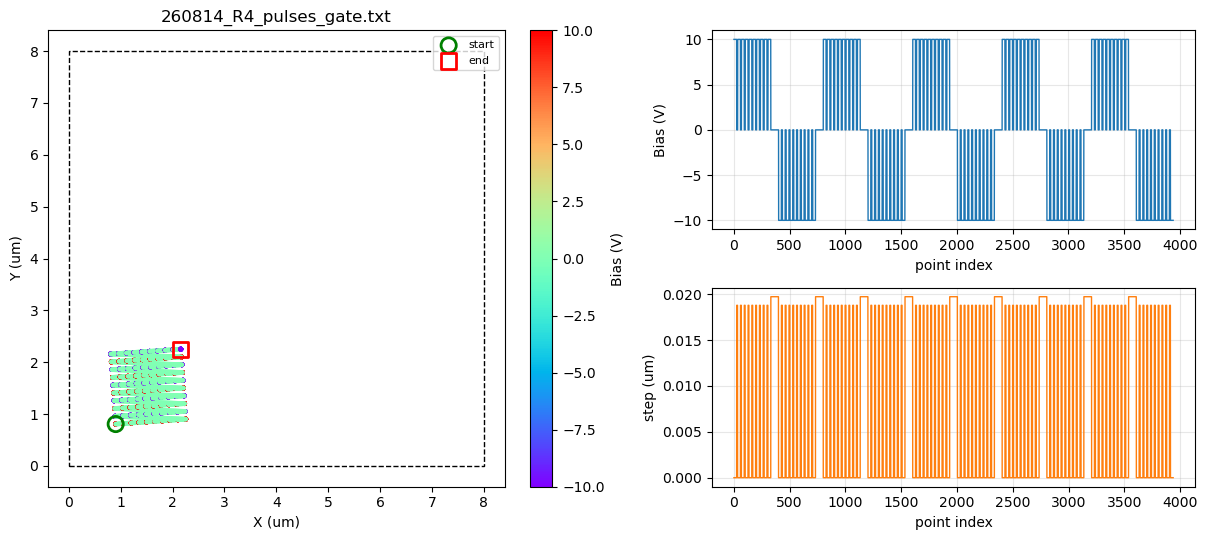

  running… ETA 2.6 min
  done 19:01:41
VDART ready
  -> PZTO_VDART_0019.ibw

=== did the bias actually reach the tip? ===
      r range nm     n px   d(up frac)    vs far
       0-100         2385      +0.0344   +0.0636
     100-200          697      +0.0029   +0.0321
     200-300          733      +0.0327   +0.0619
     300-450         1183      +0.0051   +0.0343
     450-600         1356      -0.0022   +0.0270
     600-900         2938      +0.0208   +0.0499
     900-1300        2750      +0.0069   +0.0361
       far field    53494      -0.0292

  near - far = +0.0636   (pass >= 0.15)
  reference: probe #2 ladder at 50 V.s gave +0.389
  -> THE TIP IS NOT WRITING. Do not run a pattern experiment:
     any null would be uninterpretable. Options, cheapest first:
       1. clean the apex with max-bias pulses at a sacrificial
          spot (this worked on 13 Aug), then re-run this gate
       2. raise the deflection setpoint and re-run
       3. change the probe

*** STOPPING before the 

RuntimeError: write gate failed - see above; nothing else was written

In [113]:
# --- [R4.2]  staged: gate on one panel, then commit ---------------------
# Why staged. On 14 Aug this cell wrote 576 pulses and 9 trajectories with no
# bias ever reaching the tip: Igor still believed the previous litho scan was
# running and refused every TL_RunPy, silently. run_traj now issues Stop after
# each run, but that fix is unverified on hardware. So: write ONE panel, look at
# the out-of-plane state, and only then spend the remaining 30 min.
goto_vdart()
_okv, _tv = tune_quality()
if not _okv:
    print('  !! VDART tune out of band - fix before using it as the write check')
f_r4_v0 = frame()

print('\n=== stage 1: gate panel only ===')
goto_ldart()
run_traj(tb_p0, F_PULSE_A, speed_um_s=SPEED)
goto_vdart(); f_r4_v1 = frame()

print('\n=== did the bias actually reach the tip? ===')
GATE = write_check(f_r4_v0, f_r4_v1, PANELS[GATE_PANEL]['sites'], r_far_um=1.3)
if not GATE['ok']:
    print('\n*** STOPPING before the remaining 8 panels ***')
    print(f'   near - far = {GATE["delta"]:+.4f}, needed >= {WRITE_PASS}')
    print('   Cost so far: about 6 min, not 46.')
    print('   In order of likelihood now that the Stop fix is in run_traj:')
    print('     1. the panel latched again -> check Igor shows the litho STOPPED,')
    print('        and that run_traj printed "litho stopped" above')
    print('     2. dose too low -> raise PULSE_N in [R4.1] (50 = 20 V.s,')
    print('        125 = 50 V.s, the ladder value) and re-run [R4.1] + this cell.')
    print('        Only the gate panel is rewritten, so each try costs ~6 min')
    print('     3. litho deflection setpoint too low -> raise it and retry')
    raise RuntimeError('write gate failed - see above; nothing else was written')
print(f'\n  bias IS reaching the tip (near - far = {GATE["delta"]:+.4f}). '
      f'Committing to the other 8 panels.')

print('\n=== stage 2: the remaining 8 panels ===')
goto_ldart()
run_traj(tb_prest, F_PULSE_B, speed_um_s=SPEED)
t_pulse_done = time.time()
goto_ldart(); f_r4_p = frame()
print('  (this frame separates the pulse and trajectory treatments - without it')
print('   a null cannot be attributed to either)')

print('\n=== stage 3: trajectories ===')
run_traj(tb_t, F_TRAJ, speed_um_s=SPEED)
goto_ldart(); f_r4_a = frame()
goto_vdart()
_okv2, _tv2 = tune_quality()
f_r4_av = frame(); g_r4_a = orbit_balance(f_r4_av)
contact_check(f_r4_a)
probe_fingerprint(f_r4_a, note='R4 after both treatments')
print(f'\n  orbit gate {100*g_r4_b["frac"]:.1f} -> {100*g_r4_a["frac"]:.1f} % up')
print(f'  minutes from end of pulses to the after-frame: '
      f'{(time.time()-t_pulse_done)/60:.1f}')
print('\n  NOTE for [R4.3]: the gate panel was written ~30 min before the other')
print('  eight, so it has had longer to relax. If it stands out in the matrix,')
print('  check that before reading it as an orientation effect.')


In [ ]:
# --- [R4.2b]  file B: the other 8 panels, then the trajectories ---------
# The gate panel WORKED. write_check said no because it scores out-of-plane
# polarity, and the effect is in-plane alignment:
#     power at the commanded 2 deg   0.099 -> 0.760
#     peak direction                 136 -> 1 deg
#     triad modulation               0.167 -> 0.716
#     population w              (0.24,0.15,0.61) -> (0.88,0.04,0.08)
#     three controls                 +0.024 / +0.010 / +0.011
# So this cell picks up where [R4.2] aborted and uses align_check from here on.
#
# BEFORE RUNNING: re-run [WRAPPERS]. If run_traj did not print "litho stopped"
# after file A, the Stop fix is not live in this kernel and file B will be
# silently refused - which is the failure that cost 70 min today.
GATE_TARGET = PANELS[GATE_PANEL]['pulse_deg']
# NOT fixed boxes. Those were chosen when only the gate panel existed; after
# file B all three sat inside written panels - 'diag' WAS panel (2,2) - so the
# panel was compared against itself and a +0.779 alignment aborted the run.
# Use a temporal floor from two frames with nothing done between them.
CTRLS = None
_regs = [panel_core(i, j) for i in range(3) for j in range(3)]
_tgts = [PANELS[(i, j)]['pulse_deg'] for i in range(3) for j in range(3)]
FLOOR_A = align_floor(f_r4_bv, f_r4_v0, _regs, _tgts)
print(f'temporal floor over the 9 panel regions: mean {FLOOR_A["mean"]:.3f}, '
      f'max {FLOOR_A["max"]:.3f}')

print('=== confirming the gate panel from the frames already on disk ===')
_g = align_check(f_r4_v0, f_r4_v1, panel_core(*GATE_PANEL), GATE_TARGET,
                 controls=CTRLS, floor=FLOOR_A, label=f'gate panel {GATE_PANEL}')
if not _g['ok']:
    print('  !! the gate panel does not confirm. Check f_r4_v0 / f_r4_v1 point at')
    print('     VDART_0018 / VDART_0019 before continuing.')

print('\n=== stage 2: file B, the remaining 8 panels ===')
print(f'  {len(tb_prest.to_arrays()[2])} pts, '
      f'{len(tb_prest.to_arrays()[2])*0.02/SPEED/60:.1f} min')
goto_ldart()
run_traj(tb_prest, F_PULSE_B, speed_um_s=SPEED)
t_pulse_done = time.time()
goto_ldart(); f_r4_p = frame()          # LDART after all pulses
goto_vdart()
_ok2, _t2 = tune_quality()
f_r4_pv = frame()                        # VDART after all pulses

print('\n=== did file B write? check a panel from B, not the gate panel ===')
_B = align_check(f_r4_v1, f_r4_pv, panel_core(2, 2), PANELS[(2, 2)]['pulse_deg'],
                 controls=CTRLS, floor=FLOOR_A, label='panel (2,2) from file B')
if not _B['ok']:
    print('\n  *** file B did not take. Most likely the litho panel latched after')
    print('      file A. Check Igor shows the litho STOPPED, re-run [WRAPPERS] so')
    print('      run_traj issues Stop, and re-run this cell. The trajectories are')
    print('      NOT being run, so nothing is wasted. ***')
    raise RuntimeError('file B produced no alignment - see above')

print('\n=== stage 3: trajectories (column sets the orientation) ===')
run_traj(tb_t, F_TRAJ, speed_um_s=SPEED)
goto_ldart(); f_r4_a = frame()
goto_vdart()
_ok3, _t3 = tune_quality()
f_r4_av = frame(); g_r4_a = orbit_balance(f_r4_av)
contact_check(f_r4_a)
probe_fingerprint(f_r4_a, note='R4 after pulses + trajectories')
print(f'\n  orbit gate {100*g_r4_b["frac"]:.1f} -> {100*g_r4_a["frac"]:.1f} % up')
print(f'  minutes from end of pulses to the after-frame: '
      f'{(time.time()-t_pulse_done)/60:.1f}')
print('\n  Frames for [R4.3]:')
print(f'    baseline LDART  {f_r4_b2}')
print(f'    VDART before    {f_r4_v0}')
print(f'    VDART gate only {f_r4_v1}')
print(f'    after pulses    LDART {f_r4_p}  VDART {f_r4_pv}')
print(f'    after traj      LDART {f_r4_a}  VDART {f_r4_av}')
print('\n  NOTE the gate panel was written ~30 min before the other eight, so it')
print('  has had longer to relax. Weigh that before reading it as an orientation')
print('  effect in the matrix.')


In [ ]:
# --- [R4.2c]  stage 3: the trajectories -------------------------------
# File B SUCCEEDED. [R4.2b] aborted on my bug, not on the data: all nine panels
# turned to their commanded angle, VDART_0018 -> VDART_0020,
#   commanded   2 deg -> peaks   1,   1,   1
#   commanded  62 deg -> peaks  59,  64,  59
#   commanded 122 deg -> peaks 121, 129, 121
# power@command +0.535 to +0.787 against a temporal floor of 0.006 (max 0.019).
# Three commands, three distinct outcomes - no frame-wide artefact can do that.
#
# So the PULSE factor is settled. This cell runs the remaining question: does the
# trajectory (column angle) move anything on top of an already-aligned texture?
_regs = [panel_core(i, j) for i in range(3) for j in range(3)]
_tp = [PANELS[(i, j)]['pulse_deg'] for i in range(3) for j in range(3)]
FLOOR_A = align_floor(f_r4_bv, f_r4_v0, _regs, _tp)
print(f'temporal floor: mean {FLOOR_A["mean"]:.3f}, max {FLOOR_A["max"]:.3f}')

print('\n=== stage 3: trajectories, column sets the orientation ===')
_x, _y, _v = tb_t.to_arrays()
print(f'  {len(_v)} pts, {len(_v)*0.02/SPEED/60:.1f} min, mean V {_v.mean():+.5f}')
goto_ldart()
run_traj(tb_t, F_TRAJ, speed_um_s=SPEED)
t_traj_done = time.time()
goto_ldart(); f_r4_a = frame()
goto_vdart()
_ok3, _t3 = tune_quality()
f_r4_av = frame(); g_r4_a = orbit_balance(f_r4_av)
contact_check(f_r4_a)
probe_fingerprint(f_r4_a, note='R4 after pulses + trajectories')

print('\n=== did the trajectory change anything on top of the pulses? ===')
print(f'{"panel":8s}{"pulse":>6s}{"traj":>6s}{"pow@pulse":>11s}{"->":>4s}'
      f'{"pow@traj":>10s}{"->":>4s}{"peak":>7s}{"->":>4s}')
for i in range(3):
    for j in range(3):
        rg = panel_core(i, j)
        tp_ = PANELS[(i, j)]['pulse_deg']; tt_ = PANELS[(i, j)]['traj_deg']
        wp0, pk0, _ = dir_power(f_r4_pv, rg, tp_)
        wp1, pk1, _ = dir_power(f_r4_av, rg, tp_)
        wt0, _, _ = dir_power(f_r4_pv, rg, tt_)
        wt1, _, _ = dir_power(f_r4_av, rg, tt_)
        print(f'  ({i},{j}){tp_:6.0f}{tt_:6.0f}{wp0:11.3f}{wp1:>10.3f}'
              f'{wt0:10.3f}{wt1:>10.3f}{pk0:7.0f}{pk1:>8.0f}')
print(f'\n  floor for comparison: max {FLOOR_A["max"]:.3f}')
print('  Column j != row i is where the trajectory is fighting the pulses. If')
print('  pow@traj rises there and pow@pulse falls, the write can override the')
print('  lattice; if not, the lattice sets the direction and the write does not.')
print(f'\n  orbit gate {100*g_r4_b["frac"]:.1f} -> {100*g_r4_a["frac"]:.1f} % up')
print(f'  frames for [R4.3]: pulses {f_r4_p}/{f_r4_pv}, traj {f_r4_a}/{f_r4_av}')


In [ ]:
import contextlib, io

# --- [R4.3]  readout: 3x3 matrix, then row and column marginals ---------
# Rows share a PULSE orientation, columns share a TRAJECTORY orientation, so the
# marginals separate the two factors. Everything is paired within one area and
# one probe state, which is the confound that ruined every cross-session
# comparison in this campaign.
STAGES = [('pulses only', f_r4_b2, f_r4_p), ('pulses + traj', f_r4_b2, f_r4_a),
          ('traj only', f_r4_p, f_r4_a)]
RES = {}
for st, before, after in STAGES:
    print(f'\n{"="*72}\n{st.upper()}:  {before} -> {after}\n{"="*72}')
    print(f'{"panel":7s}{"pulse":>6s}{"traj":>6s}{"|d|<15":>9s}{"+60":>7s}'
          f'{"-60":>7s}{"else":>7s}{"switch":>8s}{"peak b->a":>14s}')
    for i in range(3):
        for j in range(3):
            rg = panel_core(i, j)
            # change_map() has no quiet kwarg and prints ~8 lines; 9 panels x 3
            # stages would bury the matrices in 27 blocks. Swallow it here - the
            # per-panel numbers we need are all in the returned dict.
            with contextlib.redirect_stdout(io.StringIO()):
                r = change_map(before, after, rg, show=False, label=f'({i},{j})')
                sb = score(before, '', rg, quiet=True)
                sa = score(after, '', rg, quiet=True)
            if not r.get('same_area', True):
                print(f'  ({i},{j}) *** DIFFERENT AREA - stage drifted, skipping')
                continue
            el = 1 - r['m0'] - r['mp60'] - r['mm60']
            RES[(st, i, j)] = dict(r=r, pb=sb['peak'], pa=sa['peak'])
            print(f'  ({i},{j}) {PANELS[(i,j)]["pulse_deg"]:6.0f}'
                  f'{PANELS[(i,j)]["traj_deg"]:6.0f}'
                  f'{r["m0"]:9.3f}{r["mp60"]:7.3f}{r["mm60"]:7.3f}{el:7.3f}'
                  f'{r["switched"]:8.3f}   {sb["peak"]:5.0f}->{sa["peak"]:<5.0f}')

    M = np.array([[RES[(st, i, j)]['r']['m0'] for j in range(3)] for i in range(3)])
    P = np.array([[max(RES[(st, i, j)]['r']['mp60'],
                       RES[(st, i, j)]['r']['mm60']) for j in range(3)]
                  for i in range(3)])
    print(f'\n  |d|<15 matrix (1.000 = nothing moved)      floor {CHANGE_FLOOR:.3f}')
    for i in range(3):
        print(f'    pulses@{TRIAD[i]:3.0f}  ' + '  '.join(f'{M[i,j]:.3f}' for j in range(3)))
    print(f'    {"":11s}' + '  '.join(f'traj@{TRIAD[j]:.0f}' for j in range(3)))
    print(f'\n  MARGINALS   (lower |d|<15 = more change)')
    for i in range(3):
        print(f'    pulse orientation {TRIAD[i]:3.0f} deg : |d|<15 {M[i,:].mean():.3f}'
              f'   max +-60 mass {P[i,:].max():.3f}')
    for j in range(3):
        print(f'    traj  orientation {TRIAD[j]:3.0f} deg : |d|<15 {M[:,j].mean():.3f}'
              f'   max +-60 mass {P[:,j].max():.3f}')
    dia = np.array([M[k, k] for k in range(3)]).mean()
    off = np.array([M[i, j] for i in range(3) for j in range(3) if i != j]).mean()
    print(f'    aligned (pulse == traj) {dia:.3f}   crossed {off:.3f}   '
          f'difference {dia-off:+.3f}')
    print(f'    largest single +-60 mass anywhere: {P.max():.3f} at '
          f'{np.unravel_index(P.argmax(), P.shape)}')
    if P.max() > 0.30:
        print('    -> a real +-60 concentration. Identify the cell and repeat it.')
    elif M.min() > 0.85:
        print('    -> null everywhere. Do NOT read presence effects out of this '
              'design; run a pulse-only row next (see [R4-doc]).')
    else:
        print('    -> change without +-60 structure: disordering, as in C8.')

print('\nDid any panel end up pointing at the direction its lattice commanded?')
print(f'{"panel":7s}{"pulse":>6s}{"traj":>6s}{"peak after":>12s}'
      f'{"d(pulse)":>10s}{"d(traj)":>9s}  verdict')
for i in range(3):
    for j in range(3):
        e = RES[('pulses + traj', i, j)]
        dp = abs((e['pa'] - PANELS[(i,j)]['pulse_deg'] + 90) % 180 - 90)
        dt = abs((e['pa'] - PANELS[(i,j)]['traj_deg'] + 90) % 180 - 90)
        v = 'follows PULSE' if dp < 15 and dp < dt else \
            'follows TRAJ' if dt < 15 else 'neither'
        print(f'  ({i},{j}) {PANELS[(i,j)]["pulse_deg"]:6.0f}'
              f'{PANELS[(i,j)]["traj_deg"]:6.0f}{e["pa"]:12.0f}'
              f'{dp:10.0f}{dt:9.0f}  {v}')


---
## Step R5 — imprint or switching?  `[R5-doc]`

R4 showed the texture turning toward the commanded angle. There are two ways that
can happen and they mean opposite things:

- **Imprint.** The lattice writes a ± pattern with period Λ at the commanded
  angle. That pattern *is* stripes at that angle in PFM. Nothing rotated; we
  photographed our own lattice. This is the Vasudevan Fig 2c situation — the
  phase changes, the directionality does not.
- **Switching.** The in-plane field drives real ferroelastic reorientation, and
  the texture can only land on an allowed director: 2°, 62° or 122°.

**The test that separates them: command a NON-TRIAD angle.**

| outcome at a 30° command | reading |
|---|---|
| texture peaks near **30°** | **imprint** — the lattice draws itself at any angle |
| texture snaps to **2° or 62°** | **switching** — the material only accepts allowed directors |
| nothing moves | 30° is simply not writable; inconclusive |

30° is well separated from the triad: 28° from 2° and 32° from 62°, so the two
outcomes are ~30° apart and cannot be confused at this readout's precision.

### Two panels, one frame

| panel | command | role |
|---|---|---|
| left | **30°** | the test — non-triad |
| right | **2°** | positive control — the command that worked most cleanly in R4 |

Both in one frame, one write, same probe state. If the control reproduces R4 and
the test lands on 30°, that is an imprint with an internal positive control.

### Why the panels are bigger than R4's

R4 used 1.4–1.9 µm panels. The peak-direction readout repeats to a **median 0°**
on a setpoint-matched pair at every size from 1.4 to 5 µm, so size was not the
problem — but bigger is still safer and there is no reason not to, with only two
panels. These are 2.94 µm = 7.6 Λ.

### Keep the setpoint fixed

`LDART_0028` (0.50 V) and `LDART_0029` (0.60 V) are frames of the *same* state,
and the peak direction differs by more than 50° in two panels. The setpoint
changes the measured direction, so a before/after pair must be taken at the same
setpoint. R5 takes its own baseline at whatever setpoint you are on now.


In [120]:
# --- [R5.0]  fresh area, own baseline at the CURRENT setpoint ----------
# Do not reuse the R4 baseline: it was taken at 0.50 V and the setpoint is now
# 0.60 V. LDART_0028 vs LDART_0029 are the same physical state and their peak
# directions differ by >50 deg in two panels, purely from the setpoint change.
FRAME, PX, RATE = 8.0, 256, 1.0
XOFF_R5, YOFF_R5 = -10, -5      # >= 10 um from the R4 area
MOVED_MANUALLY_R5 = False
PREV_R5 = 'PZTO_LDART_0029.ibw'    # newest R4 frame, for the overlap check

if XOFF_R5 is not None or YOFF_R5 is not None:
    _mv = np.hypot(XOFF_R5 or 0.0, YOFF_R5 or 0.0)
    print(f'scan offset -> ({XOFF_R5}, {YOFF_R5}) um, |move| {_mv:.1f} um')
elif MOVED_MANUALLY_R5:
    print('stage moved by hand; the height check below is the only evidence')
else:
    print('!! no move requested. The R4 area carries 576 pulses in nine panels '
          'and is NOT a virgin baseline.')
_off = {}
if XOFF_R5 is not None: _off['xoff_um'] = XOFF_R5
if YOFF_R5 is not None: _off['yoff_um'] = YOFF_R5
setup_scan(size_um=FRAME, px=PX, rate=RATE, angle_deg=0.0, **_off)

goto_ldart()
LDART_CENTER, _tq = find_resonance('ldart')
print(f"  LDART_CENTER {LDART_CENTER/1e3:.0f} kHz, Q {_tq['Q']:.0f}")
goto_ldart()
f_r5_b1 = frame(); f_r5_b2 = frame()          # PAIR at the CURRENT setpoint
contact_check(f_r5_b2)

try:
    _da, _ha = ibw(f_r5_b2); _db, _hb = ibw(PREV_R5)
    if _da[0].shape == _db[0].shape:
        _r = float(np.corrcoef(ndi.gaussian_filter(_da[0].astype(float), 1).ravel(),
                               ndi.gaussian_filter(_db[0].astype(float), 1).ravel())[0, 1])
        print(f'  height correlation with {PREV_R5}: r = {_r:+.3f}')
        if _r > 0.50:
            raise RuntimeError(f'r={_r:+.3f}: this is the R4 area. Move first.')
        print('  -> new material confirmed')
except RuntimeError:
    raise
except Exception as _e:
    print(f'  overlap check skipped ({type(_e).__name__})')

_tri = set_triad(f_r5_b2)
TRIAD = list(FAM)
_d, _h = ibw(f_r5_b2); _px = float(_h['ScanSize']) * 1e6 / _d[0].shape[0] * 1000.0
_S, _, _ = signed(_d)
_l = []
for _f in TRIAD:
    _v = period(_S, _px, _f)
    _l.append(float(_v[0]) if isinstance(_v, (tuple, list, np.ndarray)) else float(_v))
LAM_NM = float(np.nanmedian(_l))
print(f'  Lambda {LAM_NM:.0f} nm   triad {[f"{t:.0f}" for t in TRIAD]}')

# reproducibility of the readout at THIS setpoint, on the panel-sized regions
R5_BOX = 2.94
R5_CENTRES = [2.2, 5.8]
R5_CORE = {'test': (R5_CENTRES[0] - R5_BOX/2, R5_CENTRES[0] + R5_BOX/2,
                    4.0 - R5_BOX/2, 4.0 + R5_BOX/2),
           'ctrl': (R5_CENTRES[1] - R5_BOX/2, R5_CENTRES[1] + R5_BOX/2,
                    4.0 - R5_BOX/2, 4.0 + R5_BOX/2)}
print('\n  repeat error of the peak readout on this pair (must be << 30 deg):')
for nm, rg in R5_CORE.items():
    _, p1, _ = dir_power(f_r5_b1, rg, 0.0)
    _, p2, _ = dir_power(f_r5_b2, rg, 0.0)
    print(f'    {nm:5s} peak {p1:.0f} -> {p2:.0f} deg   |d| {abs((p2-p1+90)%180-90):.0f}')


scan offset -> (-10, -5) um, |move| 11.2 um
scan 8.0 um, 256 px, 1.0 Hz, angle 0.0 deg, offset (-10, -5) um
LDART ready
  sweeping LDART num=2 550-750 kHz (centre 650, width 200)
  tune [LDART]: f0 654.9 kHz   peak 0.00853   FWHM 2.1 kHz   Q 314
    stored curve spans 555-754 kHz; LDART band is 450-850 kHz (650 +- 200)
  LDART_CENTER 655 kHz, Q 314
LDART ready
  -> PZTO_LDART_0030.ibw
  -> PZTO_LDART_0031.ibw
  contact_check PZTO_LDART_0031.ibw
    drive 649.9 kHz   tracked 643.8 +-0.6 kHz   offset 6.1 kHz
    |A| 75.8 pm   xi 94 nm (3 px)   consistency 0.93   r12 +0.96   defl SP 0.60 V
    -> OK. Proceed.
  height correlation with PZTO_LDART_0029.ibw: r = -0.007
  -> new material confirmed
  rigid triad fit on PZTO_LDART_0031.ibw
    phi0 = 56.5 deg  ->  members 56/116/176 deg
    triad power 0.583   modulation 0.166 (virgin ~0.17, poled ~0.53, isotropic ~0)
    population w = (0.30, 0.48, 0.22)
    deviation from the film triad 2/62/122: 54.5 deg
    !! more than 10 deg from the esta

Lambda 388 nm -> spacing 194 nm, sign period = Lambda
N_SIDE 12 -> 144 pulses/panel, box 2918 nm = 7.5 Lambda
  test  at  30.0 deg  X[0.74,3.66] Y[2.54,5.46]  144 pulses
  ctrl  at 176.5 deg  X[4.67,6.93] Y[2.87,5.13]  144 pulses

  12722 pts, mean V +0.00000, 8.5 min at 0.5 um/s


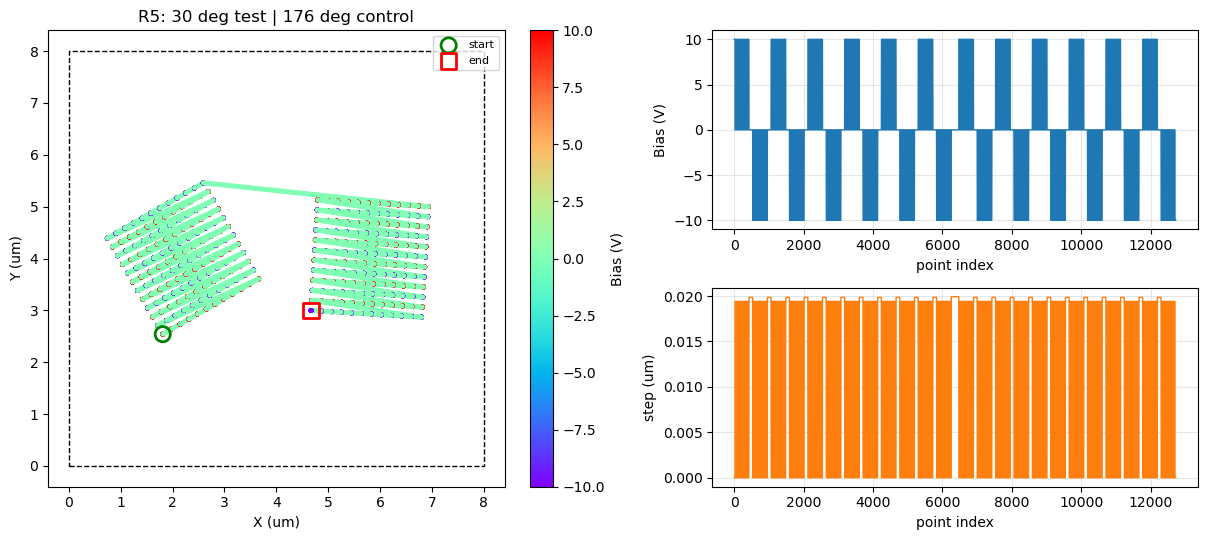

LDART ready
Wrote 12722 pts to 'output\260814_R5_imprint.txt'  (path length 102.8 um, 288 strokes)
260814_R5_imprint.txt   saved 20:34:39
  12722 pts   X[0.741,6.931] Y[2.541,5.459] um
  |V| = [10.]   mean(V) = +0.0000 V   43.4 % at 0 V
  path 254 um  ->  8.5 min at 0.5 um/s


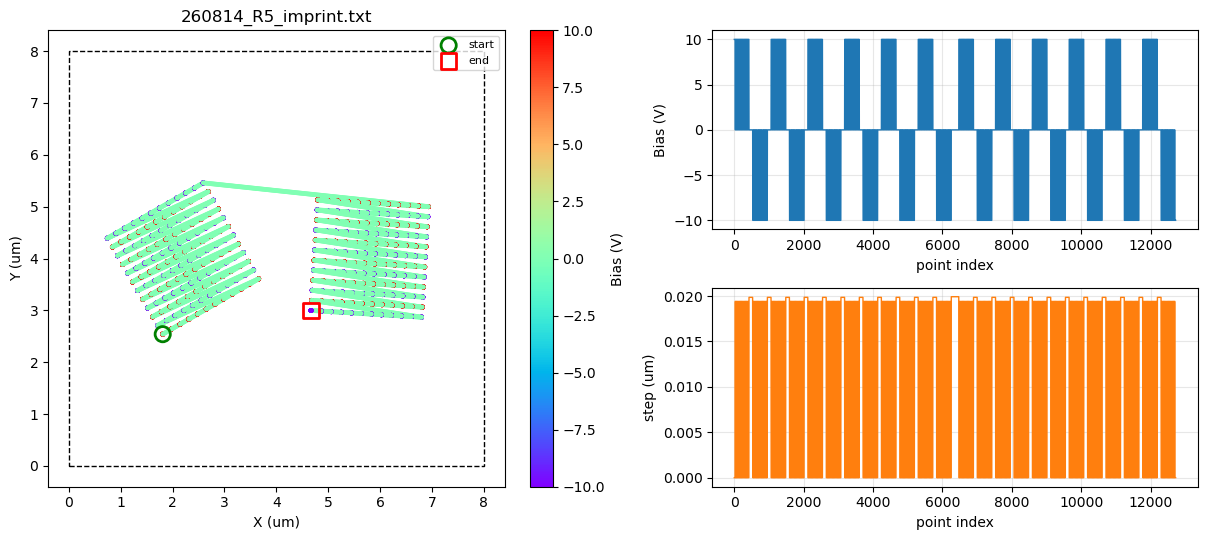

  running… ETA 8.5 min
  done 20:43:27
  litho stopped (required before the next run)
LDART ready
  -> PZTO_LDART_0032.ibw


In [121]:
# --- [R5.1]  two panels: 30 deg (non-triad) and 2 deg (control) --------
R5_TEST = 30.0                       # NON-triad: 28 deg from 2, 32 deg from 62
R5_CTRL = float(min(TRIAD, key=lambda t: abs((t - 2.0 + 90) % 180 - 90)))
V_PULSE, PULSE_N, SPEED = 10.0, 25, 0.5
SP_UM = 0.5 * LAM_NM / 1000.0
ANG_F = max(abs(np.cos(np.deg2rad(t))) + abs(np.sin(np.deg2rad(t)))
            for t in (R5_TEST, R5_CTRL))
N_SIDE = 2 * int(round((R5_BOX / (SP_UM * ANG_F) + 1) / 2))
print(f'Lambda {LAM_NM:.0f} nm -> spacing {SP_UM*1000:.0f} nm, sign period = Lambda')
print(f'N_SIDE {N_SIDE} -> {N_SIDE**2} pulses/panel, box '
      f'{(N_SIDE-1)*SP_UM*ANG_F*1000:.0f} nm = '
      f'{(N_SIDE-1)*SP_UM*ANG_F*1000/LAM_NM:.1f} Lambda')
assert N_SIDE % 2 == 0

def _uv(deg):
    t = np.deg2rad(deg)
    return np.array([np.cos(t), np.sin(t)]), np.array([-np.sin(t), np.cos(t)])

tb5 = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
R5_SITES = {}
for nm, cx, ang in (('test', R5_CENTRES[0], R5_TEST),
                    ('ctrl', R5_CENTRES[1], R5_CTRL)):
    u, n = _uv(ang); c = np.array([cx, 4.0])
    idx = np.arange(N_SIDE) - (N_SIDE - 1) / 2.0
    sites = []
    for bi, b in enumerate(idx):
        sgn = +1.0 if bi % 2 == 0 else -1.0
        for a in idx:
            p = c + a * SP_UM * u + b * SP_UM * n
            sites.append((p[0], p[1], sgn * V_PULSE))
    v = np.array([s[2] for s in sites])
    assert abs(v.mean()) < 1e-9, f'{nm} panel carries net DC'
    for (x0, y0, v0) in sites:
        tb5.dwell((x0, y0), v0, n=PULSE_N)
    R5_SITES[nm] = sites
    xs = [s[0] for s in sites]; ys = [s[1] for s in sites]
    print(f'  {nm:5s} at {ang:5.1f} deg  X[{min(xs):.2f},{max(xs):.2f}] '
          f'Y[{min(ys):.2f},{max(ys):.2f}]  {len(sites)} pulses')

_x, _y, _v = tb5.to_arrays()
print(f'\n  {len(_v)} pts, mean V {_v.mean():+.5f}, '
      f'{len(_v)*0.02/SPEED/60:.1f} min at {SPEED} um/s')
assert abs(_v.mean()) < 0.01 and np.abs(_v).max() <= V_MAX + 1e-9
assert _x.min() > 0.05 and _x.max() < FRAME - 0.05
visualize_trajectory(tb=tb5, field_um=FRAME,
                     title=f'R5: {R5_TEST:.0f} deg test | {R5_CTRL:.0f} deg control')

goto_ldart()
run_traj(tb5, os.path.join(CONFIG["work_dir"], "260814_R5_imprint.txt"),
         speed_um_s=SPEED)
goto_ldart(); f_r5_a = frame()


In [122]:
# --- [R5.2]  verdict: imprint or switching? ----------------------------
CANDS = [('commanded 30', R5_TEST)] + [(f'triad {t:.0f}', t) for t in TRIAD]
print(f'{"panel":6s}{"cmd":>6s}   ' + ''.join(f'{c[0]:>16s}' for c in CANDS)
      + f'{"peak b":>9s}{"peak a":>8s}')
res = {}
for nm, ang in (('test', R5_TEST), ('ctrl', R5_CTRL)):
    rg = R5_CORE[nm]
    row = []
    for _, t in CANDS:
        wb, pb, _ = dir_power(f_r5_b2, rg, t)
        wa, pa, _ = dir_power(f_r5_a, rg, t)
        row.append((wb, wa))
    _, pb, _ = dir_power(f_r5_b2, rg, ang)
    _, pa, _ = dir_power(f_r5_a, rg, ang)
    res[nm] = dict(row=row, peak_b=pb, peak_a=pa)
    print(f'  {nm:4s}{ang:6.1f}   '
          + ''.join(f'{a-b:+8.3f}({a:.2f})' for b, a in row)
          + f'{pb:9.0f}{pa:8.0f}')
print('  each cell is  delta(power at that angle)  and (power after)')

FLOOR5 = align_floor(f_r5_b1, f_r5_b2, list(R5_CORE.values()), [R5_TEST, R5_CTRL])
print(f'\n  temporal floor: mean {FLOOR5["mean"]:.3f}, max {FLOOR5["max"]:.3f}')

pa = res['test']['peak_a']
d30 = abs((pa - R5_TEST + 90) % 180 - 90)
dtri = min(abs((pa - t + 90) % 180 - 90) for t in TRIAD)
near = min(TRIAD, key=lambda t: abs((pa - t + 90) % 180 - 90))
cw = res['ctrl']['row'][1 + int(np.argmin([abs((R5_CTRL - t + 90) % 180 - 90)
                                           for t in TRIAD]))]
print(f'\n--- VERDICT ---')
print(f'  control panel commanded {R5_CTRL:.0f}: peak {res["ctrl"]["peak_b"]:.0f}'
      f' -> {res["ctrl"]["peak_a"]:.0f}, delta at command {cw[1]-cw[0]:+.3f}')
ctrl_ok = (cw[1] - cw[0]) > max(0.10, 3 * FLOOR5['max'])
if not ctrl_ok:
    print('  !! the CONTROL did not take, so the test panel says nothing about')
    print('     imprint vs switching - only that this write did not work.')
else:
    print(f'  test panel commanded {R5_TEST:.0f}: peak -> {pa:.0f} deg')
    print(f'    distance to the command {d30:.0f} deg; to nearest triad '
          f'({near:.0f}) {dtri:.0f} deg')
    if d30 < 15 and d30 < dtri:
        print('  => IMPRINT. The lattice reproduces ANY commanded angle, so R4')
        print('     measured the written pattern, not superdomain reorientation.')
        print('     Next: retention. A written charge pattern decays over hours;')
        print('     a ferroelastic reorientation does not.')
    elif dtri < 15 and dtri < d30:
        print('  => SWITCHING. The texture refused 30 deg and snapped to an')
        print('     allowed director. R4 was real triad control.')
        print('     Next: map which triad member a given off-axis command selects.')
    else:
        print('  => inconclusive: the peak is not close to either. Check the')
        print('     control took, and that the region holds enough periods.')


panel    cmd       commanded 30        triad 56       triad 116       triad 176   peak b  peak a
  test  30.0     +0.152(0.24)  -0.092(0.12)  -0.089(0.18)  +0.026(0.15)      126     116
  ctrl 176.5     -0.055(0.09)  -0.114(0.12)  -0.129(0.08)  +0.385(0.49)       64       1
  each cell is  delta(power at that angle)  and (power after)

  temporal floor: mean 0.002, max 0.004

--- VERDICT ---
  control panel commanded 176: peak 64 -> 1, delta at command +0.385
  test panel commanded 30: peak -> 116 deg
    distance to the command 86 deg; to nearest triad (116) 0 deg
  => SWITCHING. The texture refused 30 deg and snapped to an
     allowed director. R4 was real triad control.
     Next: map which triad member a given off-axis command selects.


---
## Step R6 — the rewrite test  `[R6-doc]`

R5 settled that the pulse lattice really reorients, rather than imprinting: an
**allowed** command rotated the texture 56° → 176° (power at command 0.11 → 0.49,
48× the temporal floor), while a **disallowed** 30° command only raised power at
30° to 0.24 and never took over — the peak stayed on a triad member.

Both of those were writes into **virgin** material. The campaign's actual goal is
harder and has never been attempted: **can a written direction be re-written?**
That is the reconfigurability Vasudevan et al. could not demonstrate, and the
question behind the very first session on 2 August.

### Three panels, two writes

Let `M` be the triad member nearest the virgin peak. Then `A = M + 120°` and
`B = M + 60°`.

| panel | write 1 | write 2 | answers |
|---|---|---|---|
| **P1 rewrite** | A | **B** | can B overwrite an established A? |
| **P2 fresh** | — | **B** | how strong is B on virgin material? |
| **P3 retention** | A | — | does A decay on its own over the same interval? |

The comparison that matters is **P1 vs P2**: both receive an identical B write,
one onto an established A texture and one onto virgin material, in the same frame,
with the same probe, minutes apart. If ΔP1 ≈ ΔP2 the state is freely rewritable.
If ΔP1 ≪ ΔP2 there is a barrier, and its size is the number we want.

P3 separates "B overwrote A" from "A simply relaxed". Without it, a decay of A
would masquerade as a successful rewrite.

**Why B is one triad step from virgin, not two.** With `A = M + 120` and
`B = M + 60`, P2's write is a single 60° step from `M`, and P1's second write is a
single 60° step from `A` in the other direction. Both are one-step transitions, so
the comparison is matched. Choosing `A = M + 60`, `B = M + 120` would have made
P2 a two-step write and confounded the contrast.

### Reading the result

| ΔP1 (B onto A) vs ΔP2 (B onto virgin) | reading |
|---|---|
| ΔP1 ≈ ΔP2, both ≫ floor | **freely rewritable** — the headline result |
| 0 < ΔP1 < ΔP2 | partial barrier; report the ratio |
| ΔP1 ≈ 0, ΔP2 ≫ floor | the written state is locked; write-once only |
| ΔP2 ≈ 0 | the write failed today — P1 says nothing. Check P3 and the tune |

P3 large would mean A is not stable on the timescale of the experiment, and every
before/after in this campaign needs re-examining for relaxation.


scan offset -> (-15, 10) um
scan 8.0 um, 256 px, 1.0 Hz, angle 0.0 deg, offset (-15, 10) um
LDART ready
  sweeping LDART num=2 550-750 kHz (centre 650, width 200)
  tune [LDART]: f0 653.2 kHz   peak 0.00636   FWHM 2.9 kHz   Q 224
    stored curve spans 553-752 kHz; LDART band is 450-850 kHz (650 +- 200)
  LDART_CENTER 653 kHz, Q 224
LDART ready
  -> PZTO_LDART_0033.ibw
  -> PZTO_LDART_0034.ibw
  contact_check PZTO_LDART_0034.ibw
    drive 648.2 kHz   tracked 638.6 +-2.3 kHz   offset 9.7 kHz
    |A| 53.4 pm   xi 94 nm (3 px)   consistency 0.92   r12 +0.93   defl SP 0.60 V
    -> OK. Proceed.
  height correlation with PZTO_LDART_0032.ibw: r = -0.029
  -> new material confirmed
  rigid triad fit on PZTO_LDART_0034.ibw
    phi0 = 4.0 deg  ->  members 4/64/124 deg
    triad power 0.619   modulation 0.239 (virgin ~0.17, poled ~0.53, isotropic ~0)
    population w = (0.17, 0.39, 0.44)
    deviation from the film triad 2/62/122: 2.0 deg
  FAM now ['4', '64', '124'] deg

  Lambda 280 nm   triad

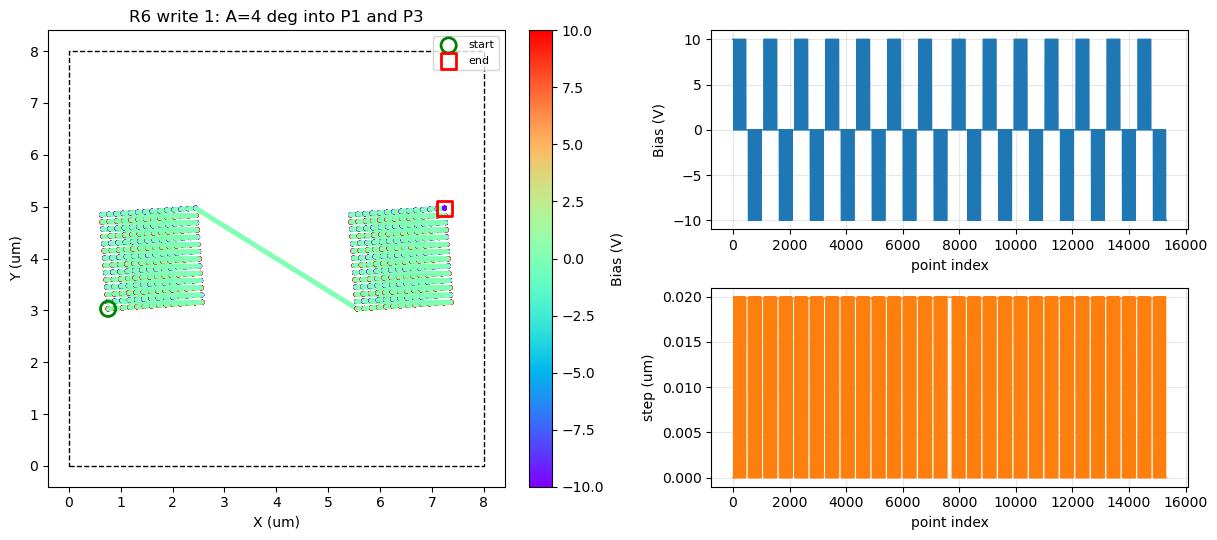

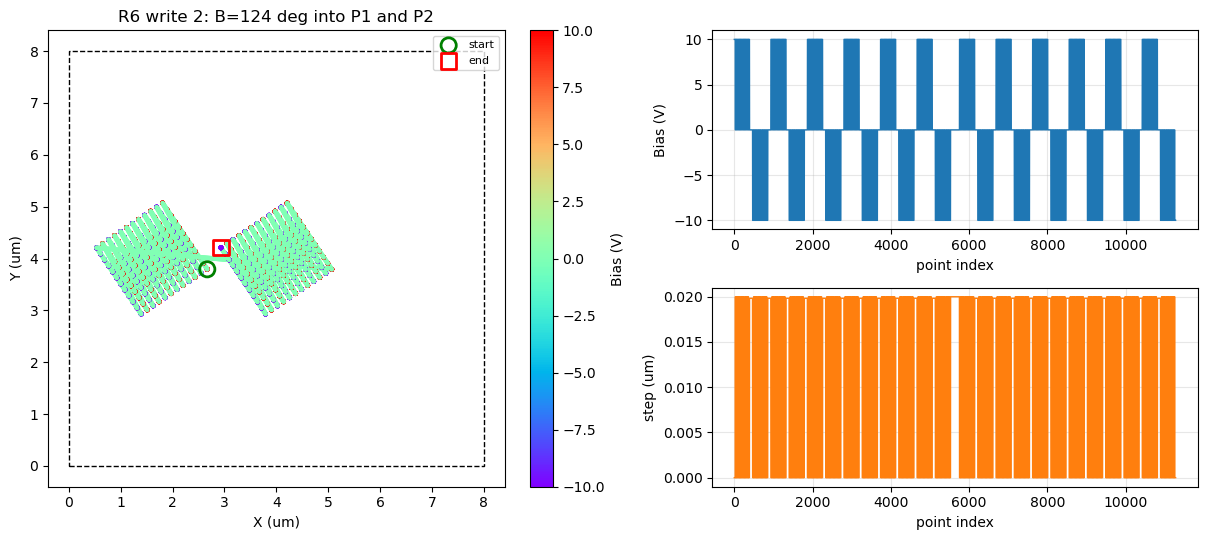

In [125]:
# --- [R6.0]  fresh area, baseline, and the three-panel geometry --------
FRAME, PX, RATE = 8.0, 256, 1.0
XOFF_R6, YOFF_R6 = -15, 10       # >= 10 um from the R5 area (-10, -5)
MOVED_MANUALLY_R6 = False
PREV_R6 = 'PZTO_LDART_0032.ibw'     # last R5 frame, for the overlap check
V_PULSE, PULSE_N, SPEED = 10.0, 25, 0.5   # 10 V.s/pulse: what R4 and R5 used

if XOFF_R6 is not None or YOFF_R6 is not None:
    print(f'scan offset -> ({XOFF_R6}, {YOFF_R6}) um')
elif MOVED_MANUALLY_R6:
    print('stage moved by hand; the height check below is the only evidence')
else:
    print('!! no move requested. The R5 area holds two written panels.')
_off = {}
if XOFF_R6 is not None: _off['xoff_um'] = XOFF_R6
if YOFF_R6 is not None: _off['yoff_um'] = YOFF_R6
setup_scan(size_um=FRAME, px=PX, rate=RATE, angle_deg=0.0, **_off)

goto_ldart()
LDART_CENTER, _tq = find_resonance('ldart')
print(f"  LDART_CENTER {LDART_CENTER/1e3:.0f} kHz, Q {_tq['Q']:.0f}")
goto_ldart()
f_r6_b1 = frame(); f_r6_b2 = frame()
contact_check(f_r6_b2)
try:
    _da, _ = ibw(f_r6_b2); _db, _ = ibw(PREV_R6)
    if _da[0].shape == _db[0].shape:
        _r = float(np.corrcoef(ndi.gaussian_filter(_da[0].astype(float), 1).ravel(),
                               ndi.gaussian_filter(_db[0].astype(float), 1).ravel())[0, 1])
        print(f'  height correlation with {PREV_R6}: r = {_r:+.3f}')
        if _r > 0.50:
            raise RuntimeError(f'r={_r:+.3f}: still the R5 area. Move first.')
        print('  -> new material confirmed')
except RuntimeError:
    raise
except Exception as _e:
    print(f'  overlap check skipped ({type(_e).__name__})')

_t = set_triad(f_r6_b2)
TRIAD = list(FAM)
_d, _h = ibw(f_r6_b2); _px = float(_h['ScanSize']) * 1e6 / _d[0].shape[0] * 1000.0
_S, _, _ = signed(_d)
_l = []
for _f in TRIAD:
    _v = period(_S, _px, _f)
    _l.append(float(_v[0]) if isinstance(_v, (tuple, list, np.ndarray)) else float(_v))
LAM_NM = float(np.nanmedian(_l))

# --- pick M, A, B from the measured triad and the virgin peak -----------
R6_BOX = 2.0
R6_CENTRES = [1.6, 4.0, 6.4]        # P1 rewrite, P2 fresh, P3 retention
R6_CORE = {nm: (cx - R6_BOX/2, cx + R6_BOX/2, 4.0 - R6_BOX/2, 4.0 + R6_BOX/2)
           for nm, cx in zip(('P1', 'P2', 'P3'), R6_CENTRES)}
_, _pk, _ = dir_power(f_r6_b2, R6_CORE['P1'], TRIAD[0])
M = float(min(TRIAD, key=lambda t: abs((_pk - t + 90) % 180 - 90)))
A_DEG = float(np.mod(M + 120.0, 180.0))
B_DEG = float(np.mod(M + 60.0, 180.0))
print(f'\n  Lambda {LAM_NM:.0f} nm   triad {[f"{t:.0f}" for t in TRIAD]}')
print(f'  virgin peak {_pk:.0f} deg -> nearest member M = {M:.0f}')
print(f'  A (write 1) = M+120 = {A_DEG:.0f} deg     B (write 2) = M+60 = {B_DEG:.0f} deg')
print(f'  both writes are single 60 deg steps, so P1 and P2 are matched')

print('\n  repeat error of the peak readout on the baseline pair:')
for nm, rg in R6_CORE.items():
    _, p1, _ = dir_power(f_r6_b1, rg, 0.0)
    _, p2, _ = dir_power(f_r6_b2, rg, 0.0)
    print(f'    {nm} peak {p1:.0f} -> {p2:.0f}   |d| {abs((p2-p1+90)%180-90):.0f} deg')
R6_FLOOR = align_floor(f_r6_b1, f_r6_b2, list(R6_CORE.values()),
                       [A_DEG, B_DEG, A_DEG])
print(f'  temporal floor: mean {R6_FLOOR["mean"]:.3f}, max {R6_FLOOR["max"]:.3f}')

# --- build both lattices -------------------------------------------------
SP_UM = 0.5 * LAM_NM / 1000.0
def _uv(deg):
    t = np.deg2rad(deg)
    return np.array([np.cos(t), np.sin(t)]), np.array([-np.sin(t), np.cos(t)])

def _lattice(tb, centre_x, ang):
    u, n = _uv(ang); c = np.array([centre_x, 4.0])
    af = abs(np.cos(np.deg2rad(ang))) + abs(np.sin(np.deg2rad(ang)))
    ns = 2 * int(round((R6_BOX / (SP_UM * af) + 1) / 2))
    idx = np.arange(ns) - (ns - 1) / 2.0
    sites = []
    for bi, b in enumerate(idx):
        sgn = +1.0 if bi % 2 == 0 else -1.0
        for a in idx:
            p = c + a * SP_UM * u + b * SP_UM * n
            sites.append((p[0], p[1], sgn * V_PULSE))
    v = np.array([s[2] for s in sites])
    assert abs(v.mean()) < 1e-9, f'panel at {centre_x} carries net DC'
    for (x0, y0, v0) in sites:
        tb.dwell((x0, y0), v0, n=PULSE_N)
    return sites, ns

tb_A = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
tb_B = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
R6_SITES = {}
R6_SITES['P1a'], _n1 = _lattice(tb_A, R6_CENTRES[0], A_DEG)   # write 1 -> P1
R6_SITES['P3a'], _n3 = _lattice(tb_A, R6_CENTRES[2], A_DEG)   # write 1 -> P3
R6_SITES['P1b'], _n4 = _lattice(tb_B, R6_CENTRES[0], B_DEG)   # write 2 -> P1
R6_SITES['P2b'], _n5 = _lattice(tb_B, R6_CENTRES[1], B_DEG)   # write 2 -> P2
for nm, tb in (('write 1 (A into P1,P3)', tb_A), ('write 2 (B into P1,P2)', tb_B)):
    x, y, v = tb.to_arrays()
    print(f'\n  {nm}: {len(v)} pts, mean V {v.mean():+.5f}, '
          f'{len(v)*0.02/SPEED/60:.1f} min')
    print(f'    X[{x.min():.2f},{x.max():.2f}] Y[{y.min():.2f},{y.max():.2f}]')
    assert abs(v.mean()) < 0.01 and np.abs(v).max() <= V_MAX + 1e-9
    assert x.min() > 0.05 and x.max() < FRAME - 0.05
F_A = os.path.join(CONFIG["work_dir"], "260814_R6_writeA.txt")
F_B = os.path.join(CONFIG["work_dir"], "260814_R6_writeB.txt")
visualize_trajectory(tb=tb_A, field_um=FRAME,
                     title=f'R6 write 1: A={A_DEG:.0f} deg into P1 and P3')
visualize_trajectory(tb=tb_B, field_um=FRAME,
                     title=f'R6 write 2: B={B_DEG:.0f} deg into P1 and P2')


LDART ready
Wrote 15315 pts to 'output\260814_R6_writeA.txt'  (path length 102.0 um, 392 strokes)
260814_R6_writeA.txt   saved 21:24:22
  15315 pts   X[0.630,7.370] Y[3.030,4.970] um
  |V| = [10.]   mean(V) = +0.0000 V   36.0 % at 0 V
  path 306 um  ->  10.2 min at 0.5 um/s


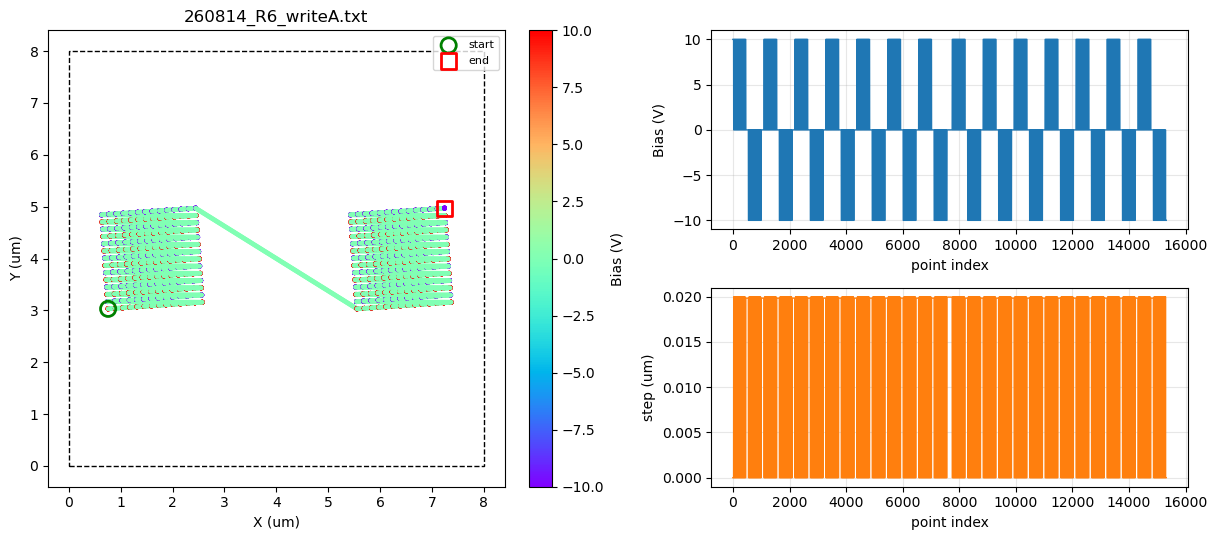

  running… ETA 10.2 min
  done 21:34:54
  litho stopped (required before the next run)
LDART ready
  -> PZTO_LDART_0035.ibw

=== did write 1 establish A? ===
panel         role   pow@A b   after   delta   peak b  peak a
  P1       rewrite     0.150   0.542  +0.392       64       1
  P2     untouched     0.102   0.096  -0.006       91     124
  P3     retention     0.172   0.749  +0.577        1       1
  floor 0.018   A commanded 4 deg
  P2 is the untouched reference for write 1: it should NOT move.

  A established. Run [R6.2] for the rewrite.


In [126]:
# --- [R6.1]  write 1: establish A in P1 and P3 -------------------------
goto_ldart()
run_traj(tb_A, F_A, speed_um_s=SPEED)
t_A_done = time.time()
goto_ldart(); f_r6_A = frame()

print('\n=== did write 1 establish A? ===')
print(f'{"panel":6s}{"role":>12s}{"pow@A b":>10s}{"after":>8s}{"delta":>8s}'
      f'{"peak b":>9s}{"peak a":>8s}')
for nm, role in (('P1', 'rewrite'), ('P2', 'untouched'), ('P3', 'retention')):
    rg = R6_CORE[nm]
    wb, pb, _ = dir_power(f_r6_b2, rg, A_DEG)
    wa, pa, _ = dir_power(f_r6_A, rg, A_DEG)
    print(f'  {nm:4s}{role:>12s}{wb:10.3f}{wa:8.3f}{wa-wb:+8.3f}{pb:9.0f}{pa:8.0f}')
print(f'  floor {R6_FLOOR["max"]:.3f}   A commanded {A_DEG:.0f} deg')
print('  P2 is the untouched reference for write 1: it should NOT move.')
_w1b, _, _ = dir_power(f_r6_b2, R6_CORE['P1'], A_DEG)
_w1a, _, _ = dir_power(f_r6_A, R6_CORE['P1'], A_DEG)
if (_w1a - _w1b) < max(0.10, 3 * R6_FLOOR['max']):
    print('\n  !! A did not establish in P1. Write 2 would have nothing to')
    print('     overwrite, so the rewrite question cannot be asked. Check the')
    print('     tune and the litho panel, then re-run this cell.')
    raise RuntimeError('write 1 failed to establish A - see above')
print('\n  A established. Run [R6.2] for the rewrite.')


  minutes since write 1 finished: 4.7
LDART ready
Wrote 11279 pts to 'output\260814_R6_writeB.txt'  (path length 75.5 um, 288 strokes)
260814_R6_writeB.txt   saved 21:39:48
  11279 pts   X[0.532,5.068] Y[2.932,5.068] um
  |V| = [10.]   mean(V) = +0.0000 V   36.2 % at 0 V
  path 226 um  ->  7.5 min at 0.5 um/s


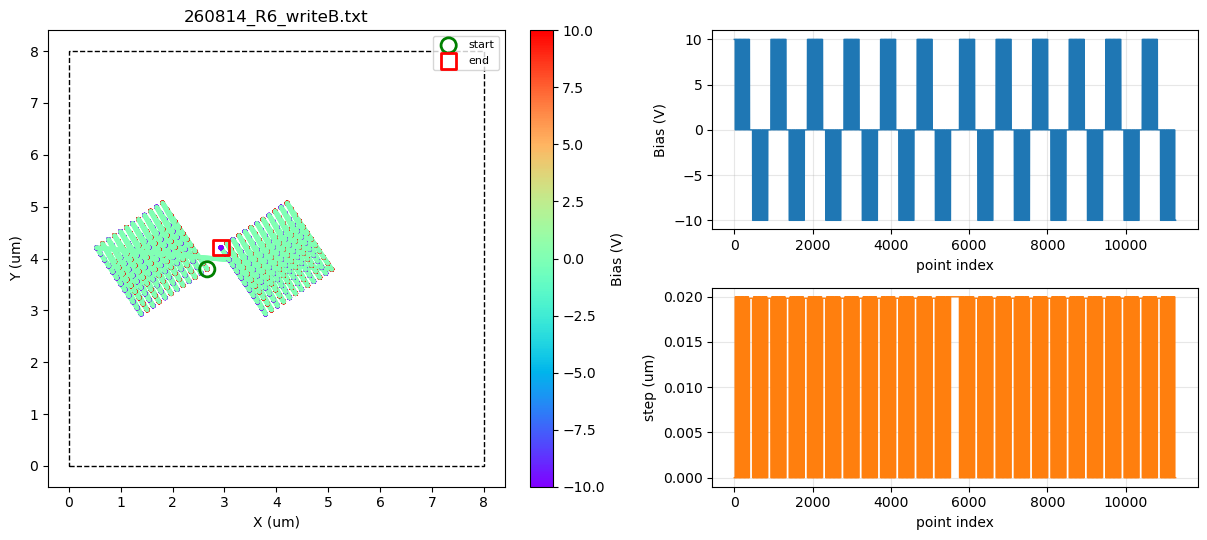

  running… ETA 7.5 min
  done 21:47:39
  litho stopped (required before the next run)
LDART ready
  -> PZTO_LDART_0036.ibw
VDART ready
  tune [VDART]: f0 371.2 kHz   peak 0.00227   FWHM 3.8 kHz   Q 99
    stored curve spans 271-470 kHz; VDART band is 150-550 kHz (350 +- 200)
  -> PZTO_VDART_0021.ibw
  contact_check PZTO_LDART_0036.ibw
    drive 649.5 kHz   tracked 644.5 +-0.5 kHz   offset 5.0 kHz
    |A| 77.4 pm   xi 94 nm (3 px)   consistency 0.93   r12 +0.97   defl SP 0.60 V
    -> OK. Proceed.

  frames: baseline PZTO_LDART_0034.ibw, after A PZTO_LDART_0035.ibw, after B PZTO_LDART_0036.ibw


In [127]:
# --- [R6.2]  write 2: B into P1 (onto A) and P2 (onto virgin) ---------
print(f'  minutes since write 1 finished: {(time.time()-t_A_done)/60:.1f}')
goto_ldart()
run_traj(tb_B, F_B, speed_um_s=SPEED)
goto_ldart(); f_r6_B = frame()
goto_vdart()
_okv, _tv = tune_quality()
f_r6_Bv = frame()
contact_check(f_r6_B)
print(f'\n  frames: baseline {f_r6_b2}, after A {f_r6_A}, after B {f_r6_B}')


In [128]:
# --- [R6.3]  verdict: is the written state rewritable? -----------------
print(f'A = {A_DEG:.0f} deg (write 1), B = {B_DEG:.0f} deg (write 2), '
      f'floor {R6_FLOOR["max"]:.3f}\n')
print(f'{"panel":6s}{"role":>11s}{"dPow@B (write2)":>17s}{"dPow@A (write2)":>17s}'
      f'{"peak: virgin -> A -> B":>26s}')
res = {}
for nm, role in (('P1', 'A then B'), ('P2', 'virgin+B'), ('P3', 'A only')):
    rg = R6_CORE[nm]
    wB1, _, _ = dir_power(f_r6_A, rg, B_DEG)
    wB2, _, _ = dir_power(f_r6_B, rg, B_DEG)
    wA1, _, _ = dir_power(f_r6_A, rg, A_DEG)
    wA2, _, _ = dir_power(f_r6_B, rg, A_DEG)
    _, p0, _ = dir_power(f_r6_b2, rg, B_DEG)
    _, p1, _ = dir_power(f_r6_A, rg, B_DEG)
    _, p2, _ = dir_power(f_r6_B, rg, B_DEG)
    res[nm] = dict(dB=wB2-wB1, dA=wA2-wA1, wB2=wB2, wA2=wA2, p0=p0, p1=p1, p2=p2)
    print(f'  {nm:4s}{role:>11s}{wB2-wB1:+17.3f}{wA2-wA1:+17.3f}'
          f'{f"{p0:.0f} -> {p1:.0f} -> {p2:.0f}":>26s}')

d1, d2, d3 = res['P1']['dB'], res['P2']['dB'], res['P3']['dA']
print(f'\n--- VERDICT ---')
print(f'  P3 retention: power@A changed {d3:+.3f} with nothing done '
      f'({"stable" if abs(d3) < 3*R6_FLOOR["max"] else "DECAYING - relaxation confounds everything"})')
if d2 < max(0.10, 3 * R6_FLOOR['max']):
    print(f'  P2 (B onto virgin) = {d2:+.3f}: the B write did not take today.')
    print('  P1 therefore says nothing about rewritability. Check the tune.')
else:
    r = d1 / d2 if d2 else np.nan
    print(f'  B onto virgin (P2)   {d2:+.3f}')
    print(f'  B onto written (P1)  {d1:+.3f}    ratio {r:.2f}')
    if r > 0.7:
        print('  => FREELY REWRITABLE. A written in-plane direction can be')
        print('     converted to another allowed director at full efficiency.')
        print('     This is the reconfigurability the campaign set out to test.')
    elif r > 0.2:
        print(f'  => PARTIAL BARRIER. Rewriting runs at {100*r:.0f} % of the')
        print('     virgin-material efficiency. Next: raise the dose on P1-like')
        print('     panels and see whether the ratio approaches 1.')
    else:
        print('  => LOCKED. The written state resists rewriting. Next: does more')
        print('     charge break it, or does it need an erase step first?')
    print(f'  P1 power@A after write 2: {res["P1"]["wA2"]:.3f} '
          f'(A giving way: {res["P1"]["dA"]:+.3f})')
disorder_note = ('  Note both P1 and P2 received an identical B file, in the same '
                 'frame,\n  minutes apart, with the same probe state - the '
                 'cleanest contrast available.')
print(disorder_note)


A = 4 deg (write 1), B = 124 deg (write 2), floor 0.018

panel        role  dPow@B (write2)  dPow@A (write2)    peak: virgin -> A -> B
  P1     A then B           +0.149           -0.287            64 -> 1 -> 124
  P2     virgin+B           +0.111           +0.044          91 -> 124 -> 124
  P3       A only           +0.017           -0.076               1 -> 1 -> 1

--- VERDICT ---
  P3 retention: power@A changed -0.076 with nothing done (DECAYING - relaxation confounds everything)
  B onto virgin (P2)   +0.111
  B onto written (P1)  +0.149    ratio 1.34
  => FREELY REWRITABLE. A written in-plane direction can be
     converted to another allowed director at full efficiency.
     This is the reconfigurability the campaign set out to test.
  P1 power@A after write 2: 0.255 (A giving way: -0.287)
  Note both P1 and P2 received an identical B file, in the same frame,
  minutes apart, with the same probe state - the cleanest contrast available.


---
## Step R7 — the full sequence: pre-pole → pulse lattice → trajectory  `[R7-doc]`

C23/C24 established that the oriented pulse lattice sets the in-plane direction
and can re-write it. R7 asks what the other two operations add, with a design in
which each stage can be attributed.

### Four panels, three writes

| panel | pre-pole | lattice | trajectory |
|---|---|---|---|
| **Q1** | ✓ | ✓ | ✓ |
| **Q2** | — | ✓ | ✓ |
| **Q3** | ✓ | ✓ | — |
| **Q4** | ✓ | — | — |

| contrast | isolates |
|---|---|
| **Q1 vs Q2** | what pre-poling contributes |
| **Q1 vs Q3** | what the trajectory contributes |
| **Q3 vs Q4** | what the lattice contributes on poled material |
| Q4 alone | what poling does by itself |

Every panel is its own before/after, and the floor comes from the baseline pair,
so no panel has to be sacrificed as a spatial control.

### The three operations

**Pre-pole** — a raster over each box at **+7 V**, then the same raster at
**−7 V** (your scheme). Net charge zero, so it agitates the state without
imposing a direction; the raster runs along the *existing* director `M` for the
same reason. This is deliberately not `[3.2]`'s constant-sign pole, which drove
triad order 0.16 → 0.76 and produced a locked state the subsequent seed could not
move.

**Lattice** — the established recipe: Λ/2 spacing so the sign period is Λ,
10 V × 1 s, charge-balanced per panel, commanded to `M + 60°`.

**Trajectory** — the rebuilt scheme: dense pitch (Λ/4), **forward at +V and
backward at −V on the same line**, so every point sees both polarities and charge
balances per line. Commanded to **`M + 120°`, i.e. 60° away from the lattice**.

### Why the trajectory competes rather than reinforces

Pointing the trajectory at the lattice's own angle would only ask whether it
sharpens what is already there. Pointing it 60° away asks the sharper question:
**can a trajectory pull the texture off a direction the lattice has established?**
C8 says every write so far has disordered rather than steered, and C24 says the
lattice rewrites at full efficiency — so this is the test of whether trajectories
can steer at all. `TRAJ_MODE = 'reinforce'` switches it if you want the other one.

### What to expect, and what each outcome means

| Q1 vs Q3 at the trajectory angle | reading |
|---|---|
| Q1 gains, Q3 flat | the trajectory **can** override the lattice |
| both flat | the lattice dominates; trajectories do not steer |
| Q1 loses order without gaining the target | the trajectory **disorders**, as C8 |

**Relaxation caveat (C25).** A written direction decays ~10 % in 13 min. R7 runs
~45 min end to end, so Q4 — poled, then left alone through the lattice and
trajectory stages — doubles as a second retention point. Read the later stages
against it, not against zero.


scan offset -> (15, 15) um
scan 8.0 um, 256 px, 1.0 Hz, angle 0.0 deg, offset (15, 15) um
LDART ready
  sweeping LDART num=2 550-750 kHz (centre 650, width 200)
  tune [LDART]: f0 654.6 kHz   peak 0.00829   FWHM 2.9 kHz   Q 224
    stored curve spans 555-754 kHz; LDART band is 450-850 kHz (650 +- 200)
  LDART_CENTER 655 kHz, Q 224
LDART ready
  -> PZTO_LDART_0037.ibw
  -> PZTO_LDART_0038.ibw
  contact_check PZTO_LDART_0038.ibw
    drive 649.6 kHz   tracked 633.0 +-1.9 kHz   offset 16.6 kHz
    |A| 29.8 pm   xi 94 nm (3 px)   consistency 0.90   r12 +0.92   defl SP 0.60 V
    -> RETUNE HERE. The DART loop is more than 15 kHz off the tracked resonance, so neither sideband is on the peak.
  height correlation with PZTO_LDART_0036.ibw: r = -0.019
  -> new material confirmed
  rigid triad fit on PZTO_LDART_0038.ibw
    phi0 = 6.5 deg  ->  members 6/66/126 deg
    triad power 0.585   modulation 0.171 (virgin ~0.17, poled ~0.53, isotropic ~0)
    population w = (0.18, 0.29, 0.53)
    deviation

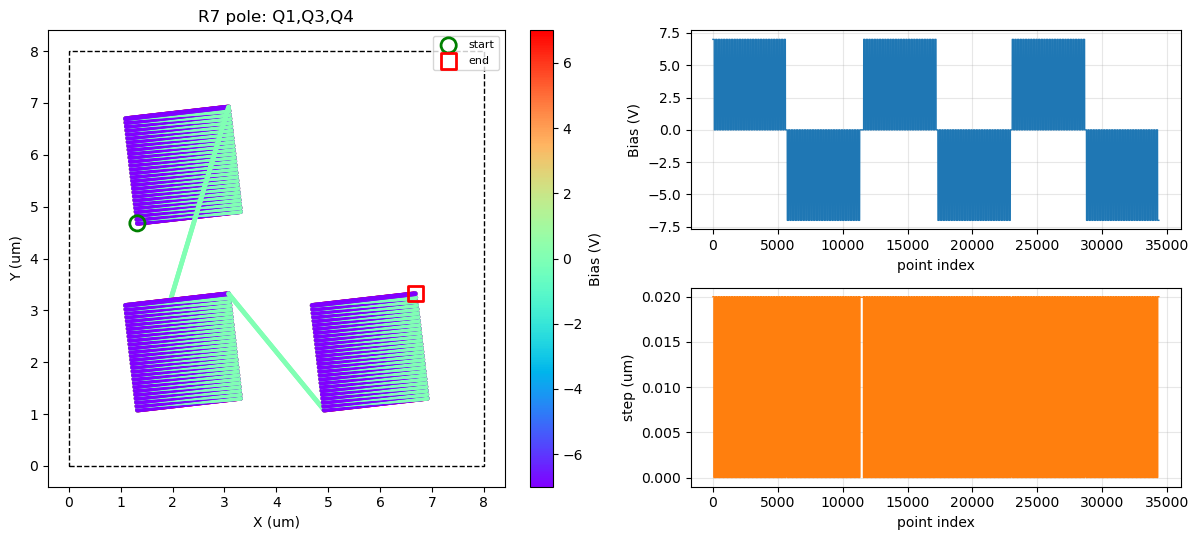

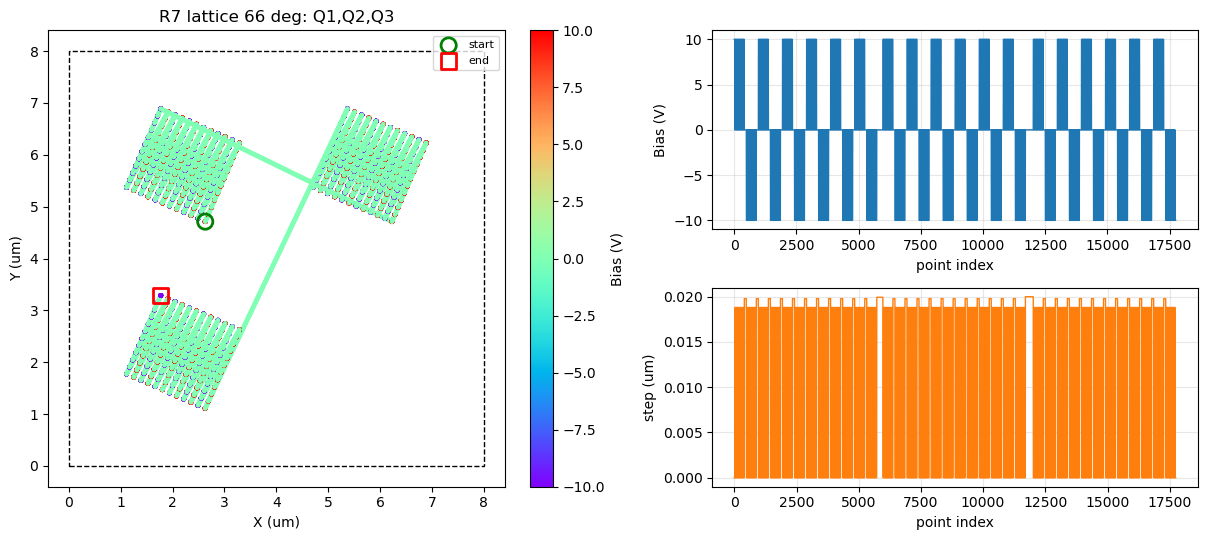

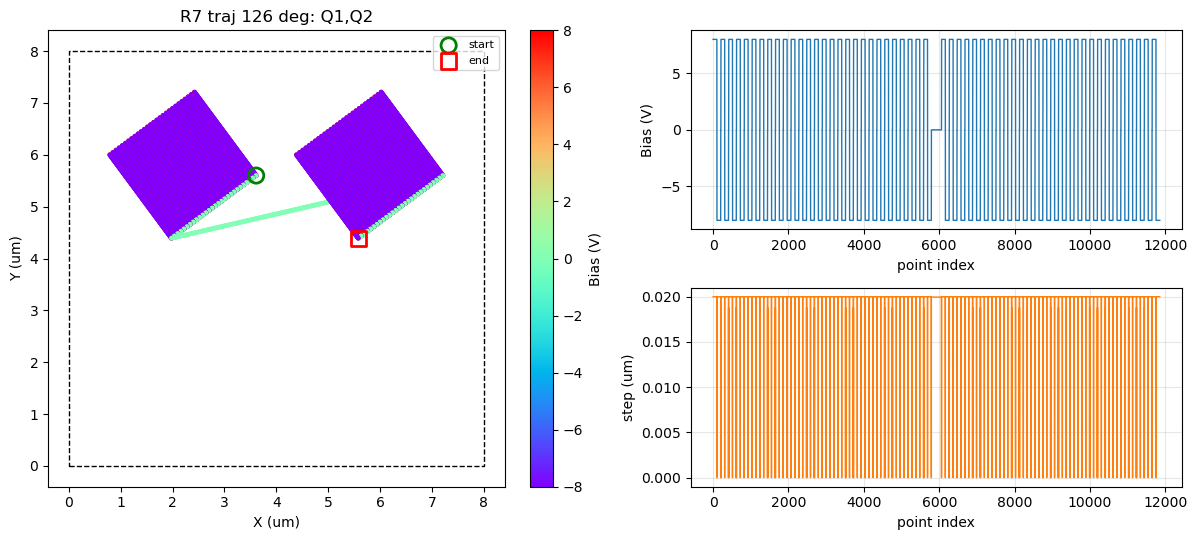

In [131]:
# --- [R7.0]  fresh area, baseline, geometry, and all three files -------
FRAME, PX, RATE = 8.0, 256, 1.0
XOFF_R7, YOFF_R7 = 15, 15       # >= 10 um from R6 at (-15, +10)
MOVED_MANUALLY_R7 = False
PREV_R7 = 'PZTO_LDART_0036.ibw'     # last R6 frame
V_PULSE, PULSE_N, SPEED = 10.0, 25, 0.5    # 10 V.s/pulse - the C23 recipe
V_POLE, V_TRAJ = 7.0, 8.0
TRAJ_MODE = 'compete'               # 'compete' = lattice+60, or 'reinforce'

if XOFF_R7 is not None or YOFF_R7 is not None:
    print(f'scan offset -> ({XOFF_R7}, {YOFF_R7}) um')
elif MOVED_MANUALLY_R7:
    print('stage moved by hand; the height check below is the only evidence')
else:
    print('!! no move requested. The R6 area holds three written panels.')
_off = {}
if XOFF_R7 is not None: _off['xoff_um'] = XOFF_R7
if YOFF_R7 is not None: _off['yoff_um'] = YOFF_R7
setup_scan(size_um=FRAME, px=PX, rate=RATE, angle_deg=0.0, **_off)

goto_ldart()
LDART_CENTER, _tq = find_resonance('ldart')
print(f"  LDART_CENTER {LDART_CENTER/1e3:.0f} kHz, Q {_tq['Q']:.0f}")
goto_ldart()
f_r7_b1 = frame(); f_r7_b2 = frame()
contact_check(f_r7_b2)
try:
    _da, _ = ibw(f_r7_b2); _db, _ = ibw(PREV_R7)
    if _da[0].shape == _db[0].shape:
        _r = float(np.corrcoef(ndi.gaussian_filter(_da[0].astype(float), 1).ravel(),
                               ndi.gaussian_filter(_db[0].astype(float), 1).ravel())[0, 1])
        print(f'  height correlation with {PREV_R7}: r = {_r:+.3f}')
        if _r > 0.50:
            raise RuntimeError(f'r={_r:+.3f}: still the R6 area. Move first.')
        print('  -> new material confirmed')
except RuntimeError:
    raise
except Exception as _e:
    print(f'  overlap check skipped ({type(_e).__name__})')

_t = set_triad(f_r7_b2)
TRIAD = list(FAM)
_d, _h = ibw(f_r7_b2); _px = float(_h['ScanSize']) * 1e6 / _d[0].shape[0] * 1000.0
_S, _, _ = signed(_d)
_l = []
for _f in TRIAD:
    _v = period(_S, _px, _f)
    _l.append(float(_v[0]) if isinstance(_v, (tuple, list, np.ndarray)) else float(_v))
LAM_NM = float(np.nanmedian(_l))
SP_UM = 0.5 * LAM_NM / 1000.0

R7_BOX = 2.0
R7_C = {'Q1': (2.2, 5.8), 'Q2': (5.8, 5.8), 'Q3': (2.2, 2.2), 'Q4': (5.8, 2.2)}
R7_CORE = {k: (c[0]-R7_BOX/2, c[0]+R7_BOX/2, c[1]-R7_BOX/2, c[1]+R7_BOX/2)
           for k, c in R7_C.items()}
_, _pk, _ = dir_power(f_r7_b2, R7_CORE['Q1'], TRIAD[0])
M = float(min(TRIAD, key=lambda t: abs((_pk - t + 90) % 180 - 90)))
LAT_DEG = float(np.mod(M + 60.0, 180.0))
TRJ_DEG = float(np.mod(LAT_DEG + (60.0 if TRAJ_MODE == 'compete' else 0.0), 180.0))
POLE_DEG = M
print(f'\n  Lambda {LAM_NM:.0f} nm   triad {[f"{t:.0f}" for t in TRIAD]}')
print(f'  virgin peak {_pk:.0f} -> M {M:.0f}')
print(f'  pole raster along M = {POLE_DEG:.0f} deg (no direction imposed)')
print(f'  lattice commanded    {LAT_DEG:.0f} deg')
print(f'  trajectory commanded {TRJ_DEG:.0f} deg  ({TRAJ_MODE})')

R7_FLOOR = align_floor(f_r7_b1, f_r7_b2, list(R7_CORE.values()),
                       [LAT_DEG] * 4)
print(f'  temporal floor: mean {R7_FLOOR["mean"]:.3f}, max {R7_FLOOR["max"]:.3f}')

def _uv(deg):
    t = np.deg2rad(deg)
    return np.array([np.cos(t), np.sin(t)]), np.array([-np.sin(t), np.cos(t)])

# ---- 1. pole: +V raster then -V raster, over each box ------------------
POLE_PITCH = 0.25 * LAM_NM / 1000.0
tb_pole = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
u, n = _uv(POLE_DEG)
_npl = int(round(R7_BOX / POLE_PITCH))
if _npl % 2: _npl += 1
for k in ('Q1', 'Q3', 'Q4'):
    c = np.array(R7_C[k])
    offs = (np.arange(_npl) - (_npl - 1) / 2.0) * POLE_PITCH
    for sgn in (+1.0, -1.0):                 # +7 V pass, then -7 V pass
        for o in offs:
            p0 = c + o * n - (R7_BOX / 2) * u
            p1 = c + o * n + (R7_BOX / 2) * u
            tb_pole.stroke(np.array([p0, p1]), sgn * V_POLE)

# ---- 2. lattice into Q1, Q2, Q3 ----------------------------------------
def _lattice(tb, centre, ang):
    u_, n_ = _uv(ang); c = np.array(centre)
    af = abs(np.cos(np.deg2rad(ang))) + abs(np.sin(np.deg2rad(ang)))
    ns = 2 * int(round((R7_BOX / (SP_UM * af) + 1) / 2))
    idx = np.arange(ns) - (ns - 1) / 2.0
    sites = []
    for bi, b in enumerate(idx):
        sgn = +1.0 if bi % 2 == 0 else -1.0
        for a in idx:
            p = c + a * SP_UM * u_ + b * SP_UM * n_
            sites.append((p[0], p[1], sgn * V_PULSE))
    v = np.array([s[2] for s in sites])
    assert abs(v.mean()) < 1e-9, f'lattice at {centre} carries net DC'
    for (x0, y0, v0) in sites:
        tb.dwell((x0, y0), v0, n=PULSE_N)
    return ns

tb_lat = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
for k in ('Q1', 'Q2', 'Q3'):
    _ns = _lattice(tb_lat, R7_C[k], LAT_DEG)

# ---- 3. trajectory into Q1, Q2: +V forward, -V backward, dense ---------
TRAJ_PITCH = 0.25 * LAM_NM / 1000.0
tb_trj = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
u2, n2 = _uv(TRJ_DEG)
_ntl = int(round(R7_BOX / TRAJ_PITCH))
if _ntl % 2: _ntl += 1
for k in ('Q1', 'Q2'):
    c = np.array(R7_C[k])
    offs = (np.arange(_ntl) - (_ntl - 1) / 2.0) * TRAJ_PITCH
    for o in offs:
        p0 = c + o * n2 - (R7_BOX / 2) * u2
        p1 = c + o * n2 + (R7_BOX / 2) * u2
        tb_trj.stroke(np.array([p0, p1]), +V_TRAJ)
        tb_trj.stroke(np.array([p1, p0]), -V_TRAJ)

F_POLE = os.path.join(CONFIG["work_dir"], "260814_R7_pole.txt")
F_LAT  = os.path.join(CONFIG["work_dir"], "260814_R7_lattice.txt")
F_TRJ  = os.path.join(CONFIG["work_dir"], "260814_R7_traj.txt")
print()
tot = 0.0
for nm, tb, panels in (('pole  (Q1,Q3,Q4)', tb_pole, 3),
                       ('latt  (Q1,Q2,Q3)', tb_lat, 3),
                       ('traj  (Q1,Q2)', tb_trj, 2)):
    x, y, v = tb.to_arrays(); mins = len(v) * 0.02 / SPEED / 60; tot += mins
    print(f'  {nm}: {len(v):6d} pts  mean V {v.mean():+.5f}  {mins:5.1f} min  '
          f'X[{x.min():.2f},{x.max():.2f}] Y[{y.min():.2f},{y.max():.2f}]')
    assert abs(v.mean()) < 0.01, f'{nm} carries net DC'
    assert np.abs(v).max() <= V_MAX + 1e-9
    assert x.min() > 0.05 and x.max() < FRAME - 0.05
print(f'  writes {tot:.1f} min + 5 frames {5*PX/RATE/60:.1f} min '
      f'-> about {tot + 5*PX/RATE/60 + 5:.0f} min total')
print(f'  pole: {_npl} lines/pass x2 passes at {POLE_PITCH*1000:.0f} nm')
print(f'  trajectory: {_ntl} lines at {TRAJ_PITCH*1000:.0f} nm, +V out / -V back')
visualize_trajectory(tb=tb_pole, field_um=FRAME, title='R7 pole: Q1,Q3,Q4')
visualize_trajectory(tb=tb_lat, field_um=FRAME,
                     title=f'R7 lattice {LAT_DEG:.0f} deg: Q1,Q2,Q3')
visualize_trajectory(tb=tb_trj, field_um=FRAME,
                     title=f'R7 traj {TRJ_DEG:.0f} deg: Q1,Q2')


LDART ready
Wrote 34378 pts to 'output\260814_R7_pole.txt'  (path length 677.8 um, 168 strokes)
260814_R7_pole.txt   saved 22:21:46
  34378 pts   X[1.092,6.908] Y[1.078,6.922] um
  |V| = [7.]   mean(V) = +0.0000 V   50.6 % at 0 V
  path 688 um  ->  22.9 min at 0.5 um/s


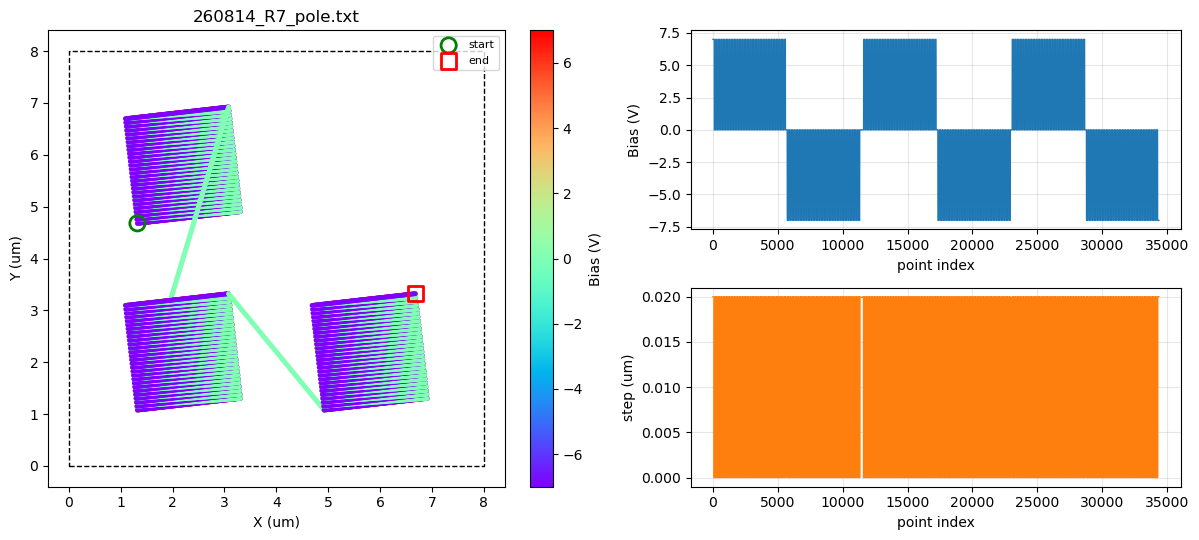

  running… ETA 22.9 min
  done 22:45:01
  litho stopped (required before the next run)
LDART ready
  -> PZTO_LDART_0039.ibw

=== what did the +7/-7 pole do? ===
panel   poled           pow@M         pow@LAT          peak           mod
  Q1      yes  0.174->0.116    0.186->0.548       1->69     0.195->0.674 
  Q2       no  0.089->0.130    0.162->0.133     124->124    0.213->0.216 
  Q3      yes  0.144->0.084    0.127->0.647       1->59     0.243->0.749 
  Q4      yes  0.163->0.035    0.117->0.102     116->129    0.306->0.718 
  floor 0.040;  Q2 is unpoled and should not move
  A large change here means the "neutral" pole is not neutral - it would
  confound the Q1-vs-Q2 contrast, so read it before continuing.


In [132]:
# --- [R7.1]  stage 1: pre-pole Q1, Q3, Q4 -----------------------------
goto_ldart()
run_traj(tb_pole, F_POLE, speed_um_s=SPEED)
t_r7_pole = time.time()
goto_ldart(); f_r7_p = frame()
print('\n=== what did the +7/-7 pole do? ===')
print(f'{"panel":6s}{"poled":>7s}{"pow@M":>16s}{"pow@LAT":>16s}{"peak":>14s}{"mod":>14s}')
for k in ('Q1', 'Q2', 'Q3', 'Q4'):
    rg = R7_CORE[k]; pol = 'yes' if k != 'Q2' else 'no'
    a0, p0, m0 = dir_power(f_r7_b2, rg, M)
    a1, p1, m1 = dir_power(f_r7_p, rg, M)
    b0, _, _ = dir_power(f_r7_b2, rg, LAT_DEG)
    b1, _, _ = dir_power(f_r7_p, rg, LAT_DEG)
    print(f'  {k:4s}{pol:>7s}{a0:7.3f}->{a1:<7.3f}{b0:7.3f}->{b1:<7.3f}'
          f'{p0:6.0f}->{p1:<6.0f}{m0:6.3f}->{m1:<6.3f}')
print(f'  floor {R7_FLOOR["max"]:.3f};  Q2 is unpoled and should not move')
print('  A large change here means the "neutral" pole is not neutral - it would')
print('  confound the Q1-vs-Q2 contrast, so read it before continuing.')


  4.7 min since the pole finished
LDART ready
Wrote 17740 pts to 'output\260814_R7_lattice.txt'  (path length 125.7 um, 432 strokes)
260814_R7_lattice.txt   saved 22:49:59
  17740 pts   X[1.112,6.888] Y[1.112,6.888] um
  |V| = [10.]   mean(V) = +0.0000 V   39.1 % at 0 V
  path 355 um  ->  11.8 min at 0.5 um/s


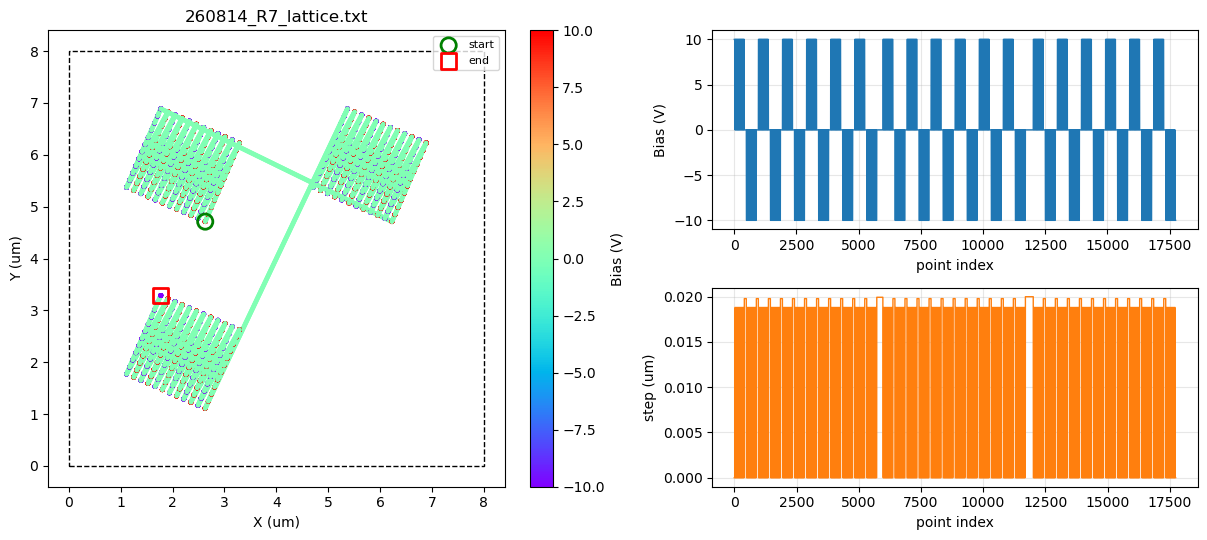

  running… ETA 11.8 min
  done 23:02:08
  litho stopped (required before the next run)
LDART ready
  -> PZTO_LDART_0040.ibw

=== lattice at 66 deg: does pre-poling help or hinder? ===
panel   pre-poled  pow@LAT before    after    delta          peak
  Q1          yes           0.548    0.380   -0.168     69->66       lattice yes
  Q2           no           0.133    0.330   +0.197    124->64       lattice yes
  Q3          yes           0.647    0.340   -0.307     59->71       lattice yes
  Q4          yes           0.102    0.135   +0.034    129->129      lattice no
  floor 0.040
  Q1 vs Q2 is the pre-pole contrast (both got the lattice).
  Q3 vs Q4 is the lattice contrast (both were poled).


In [133]:
# --- [R7.2]  stage 2: pulse lattice into Q1, Q2, Q3 -------------------
print(f'  {(time.time()-t_r7_pole)/60:.1f} min since the pole finished')
goto_ldart()
run_traj(tb_lat, F_LAT, speed_um_s=SPEED)
t_r7_lat = time.time()
goto_ldart(); f_r7_l = frame()
print(f'\n=== lattice at {LAT_DEG:.0f} deg: does pre-poling help or hinder? ===')
print(f'{"panel":6s}{"pre-poled":>11s}{"pow@LAT before":>16s}{"after":>9s}{"delta":>9s}{"peak":>14s}')
for k in ('Q1', 'Q2', 'Q3', 'Q4'):
    rg = R7_CORE[k]
    w0, p0, _ = dir_power(f_r7_p, rg, LAT_DEG)
    w1, p1, _ = dir_power(f_r7_l, rg, LAT_DEG)
    lat = 'yes' if k in ('Q1', 'Q2', 'Q3') else 'no'
    pol = 'yes' if k != 'Q2' else 'no'
    print(f'  {k:4s}{pol:>11s}{w0:16.3f}{w1:9.3f}{w1-w0:+9.3f}{p0:7.0f}->{p1:<6.0f}'
          f'   lattice {lat}')
print(f'  floor {R7_FLOOR["max"]:.3f}')
print('  Q1 vs Q2 is the pre-pole contrast (both got the lattice).')
print('  Q3 vs Q4 is the lattice contrast (both were poled).')


  4.7 min since the lattice finished
LDART ready
Wrote 11852 pts to 'output\260814_R7_traj.txt'  (path length 233.4 um, 112 strokes)
260814_R7_traj.txt   saved 23:07:02
  11852 pts   X[0.789,7.211] Y[4.392,7.208] um
  |V| = [8.]   mean(V) = +0.0000 V   4.6 % at 0 V
  path 237 um  ->  7.9 min at 0.5 um/s


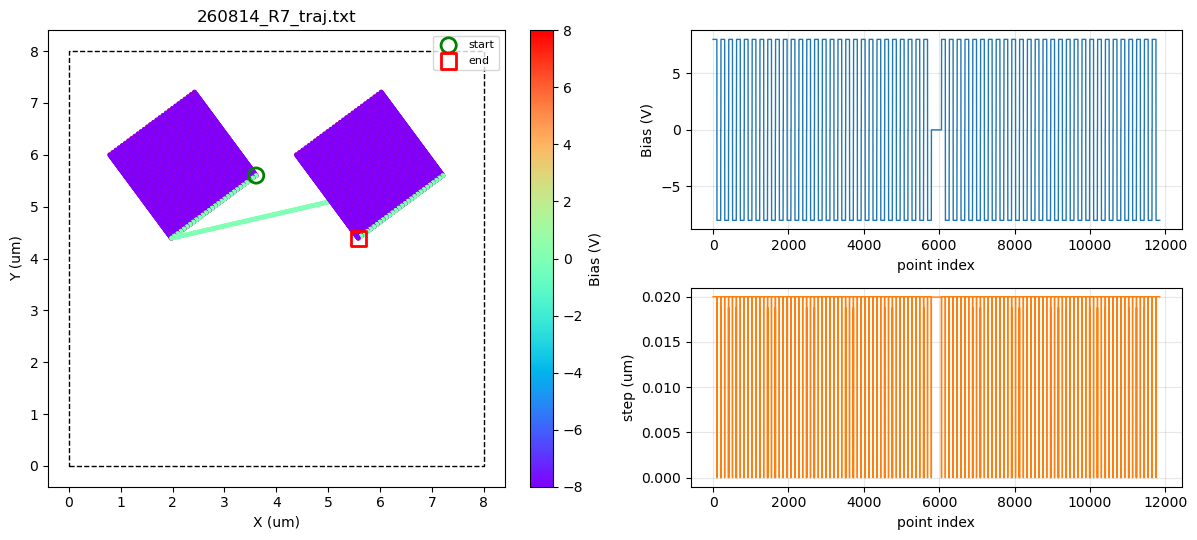

  running… ETA 7.9 min
  done 23:15:15
  litho stopped (required before the next run)
LDART ready
  -> PZTO_LDART_0041.ibw
VDART ready
  tune [VDART]: f0 371.2 kHz   peak 0.00172   FWHM 3.8 kHz   Q 99
    stored curve spans 271-470 kHz; VDART band is 150-550 kHz (350 +- 200)
  -> PZTO_VDART_0022.ibw
  contact_check PZTO_LDART_0041.ibw
    drive 645.0 kHz   tracked 643.0 +-1.1 kHz   offset 2.0 kHz
    |A| 64.0 pm   xi 94 nm (3 px)   consistency 0.92   r12 +0.97   defl SP 0.60 V
    -> OK. Proceed.

  frames: baseline PZTO_LDART_0038.ibw, +pole PZTO_LDART_0039.ibw, +lattice PZTO_LDART_0040.ibw, +traj PZTO_LDART_0041.ibw


In [134]:
# --- [R7.3]  stage 3: trajectory into Q1, Q2 -------------------------
print(f'  {(time.time()-t_r7_lat)/60:.1f} min since the lattice finished')
goto_ldart()
run_traj(tb_trj, F_TRJ, speed_um_s=SPEED)
goto_ldart(); f_r7_t = frame()
goto_vdart()
_okv, _tv = tune_quality()
f_r7_tv = frame()
contact_check(f_r7_t)
print(f'\n  frames: baseline {f_r7_b2}, +pole {f_r7_p}, +lattice {f_r7_l}, '
      f'+traj {f_r7_t}')


In [135]:
# --- [R7.4]  verdict: what did each stage contribute? -----------------
print(f'M {M:.0f}   lattice {LAT_DEG:.0f}   trajectory {TRJ_DEG:.0f} ({TRAJ_MODE})'
      f'   floor {R7_FLOOR["max"]:.3f}\n')
ST = [('virgin', f_r7_b2), ('+pole', f_r7_p), ('+lattice', f_r7_l), ('+traj', f_r7_t)]
for ang, lab in ((LAT_DEG, 'LATTICE angle'), (TRJ_DEG, 'TRAJECTORY angle')):
    print(f'--- power at the {lab} ({ang:.0f} deg) ---')
    print(f'{"panel":6s}{"P/L/T":>8s}' + ''.join(f'{s[0]:>10s}' for s in ST))
    for k in ('Q1', 'Q2', 'Q3', 'Q4'):
        rg = R7_CORE[k]
        w = [dir_power(f, rg, ang)[0] for _, f in ST]
        tag = ''.join(('Y' if c else '-') for c in (
            k != 'Q2', k in ('Q1', 'Q2', 'Q3'), k in ('Q1', 'Q2')))
        print(f'  {k:4s}{tag:>8s}' + ''.join(f'{x:10.3f}' for x in w))
    print()
print('--- peak direction through the sequence ---')
print(f'{"panel":6s}{"P/L/T":>8s}' + ''.join(f'{s[0]:>10s}' for s in ST))
for k in ('Q1', 'Q2', 'Q3', 'Q4'):
    rg = R7_CORE[k]
    p = [dir_power(f, rg, LAT_DEG)[1] for _, f in ST]
    tag = ''.join(('Y' if c else '-') for c in (
        k != 'Q2', k in ('Q1', 'Q2', 'Q3'), k in ('Q1', 'Q2')))
    print(f'  {k:4s}{tag:>8s}' + ''.join(f'{x:10.0f}' for x in p))

g = lambda k, ang, i, j: (dir_power(R7_CORE[k], ang) if False else
                          dir_power(ST[j][1], R7_CORE[k], ang)[0]
                          - dir_power(ST[i][1], R7_CORE[k], ang)[0])
d_lat_Q1 = g('Q1', LAT_DEG, 1, 2); d_lat_Q2 = g('Q2', LAT_DEG, 1, 2)
d_lat_Q3 = g('Q3', LAT_DEG, 1, 2); d_lat_Q4 = g('Q4', LAT_DEG, 1, 2)
d_trj_Q1 = g('Q1', TRJ_DEG, 2, 3); d_trj_Q3 = g('Q3', TRJ_DEG, 2, 3)
d_ret_Q4 = g('Q4', M, 1, 3)
print(f'\n--- CONTRASTS ---')
print(f'  pre-poling  : lattice gain  Q1 (poled) {d_lat_Q1:+.3f}  vs '
      f'Q2 (virgin) {d_lat_Q2:+.3f}   diff {d_lat_Q1-d_lat_Q2:+.3f}')
print(f'  lattice     : gain on poled Q3 {d_lat_Q3:+.3f}  vs Q4 (no lattice) '
      f'{d_lat_Q4:+.3f}   diff {d_lat_Q3-d_lat_Q4:+.3f}')
print(f'  trajectory  : gain@traj Q1 (traj) {d_trj_Q1:+.3f}  vs Q3 (no traj) '
      f'{d_trj_Q3:+.3f}   diff {d_trj_Q1-d_trj_Q3:+.3f}')
print(f'  retention   : Q4 power@M over the whole run {d_ret_Q4:+.3f} '
      f'({"stable" if abs(d_ret_Q4) < 3*R7_FLOOR["max"] else "decaying - C25"})')
print('\n  Read the trajectory contrast against C8: every write so far has')
print('  disordered rather than steered. A positive Q1-minus-Q3 at the traj')
print('  angle would be the first time a trajectory moved the texture where')
print('  it was told.')


M 6   lattice 66   trajectory 126 (compete)   floor 0.040

--- power at the LATTICE angle (66 deg) ---
panel    P/L/T    virgin     +pole  +lattice     +traj
  Q1       YYY     0.186     0.548     0.380     0.682
  Q2       -YY     0.162     0.133     0.330     0.462
  Q3       YY-     0.127     0.647     0.340     0.323
  Q4       Y--     0.117     0.102     0.135     0.150

--- power at the TRAJECTORY angle (126 deg) ---
panel    P/L/T    virgin     +pole  +lattice     +traj
  Q1       YYY     0.237     0.130     0.128     0.062
  Q2       -YY     0.295     0.313     0.109     0.295
  Q3       YY-     0.284     0.046     0.105     0.105
  Q4       Y--     0.373     0.698     0.633     0.562

--- peak direction through the sequence ---
panel    P/L/T    virgin     +pole  +lattice     +traj
  Q1       YYY         1        69        66        59
  Q2       -YY       124       124        64        64
  Q3       YY-         1        59        71        71
  Q4       Y--       116       12

---
## Step R8 — which actuator reconfigures the in-plane superdomains best?  `[R8-doc]`

### What the results force

| | |
|---|---|
| C23/C24 | the oriented pulse lattice **selects** a commanded director and re-writes at full efficiency, but saturates at power ≈ 0.33–0.38 (≈2× uniform) |
| C26 | a charge-balanced raster **depletes the family parallel to its own scan lines**, reaching 0.83 (≈3.5× uniform) — much stronger — but does **not** determine which of the other two wins |
| C27 | the two do not compose naively: pre-poling then a lattice is worse than the lattice alone, because the lattice is an *attractor* at its own order parameter, not a monotonic driver |
| C28 | a competing trajectory cannot steer; it consolidates whatever the lattice set |
| R5 | a non-triad command never takes over — the control alphabet has exactly **three** states |

So we hold a strong **eliminator** and a weak **selector**, and they interfere.

### The symmetry argument

The three directors are 60° apart, fixed by crystallography, and the film's triad
is the same in all five areas measured (φ₀ within a few degrees). With a
three-state alphabet, **two independent eliminations determine the survivor
uniquely.** If a raster along direction *d* removes the family parallel to *d*,
then rastering along member 1 and then member 2 must leave member 3 — and it
should arrive at the raster's order parameter (~0.8), not the lattice's (~0.33).

That is the central hypothesis of R8. It also explains why depletion should be a
wall-orientation effect: scanning **parallel** to a set of lamellae lets the tip
sweep along the walls rather than cross them, which is the geometry that moves
walls most efficiently. If so, depletion is maximal at 0° and weak at 60°, and
composition by elimination is the natural control law for this material.

### Nine panels, one target, one frame

Target `T = M + 60°`, where `M` is the virgin director. Every panel is scored on
power at **T**, so the actuators are directly comparable.

| panel | actuator | what it isolates |
|---|---|---|
| **P1** | lattice at T, Λ/2 spacing | C23 reference |
| **P2** | lattice at T, **Λ/4** spacing | does denser help, or is Λ the resonance? |
| **P3** | raster ∥ M, ±7 V, one pass-pair | C26 reference |
| **P4** | raster ∥ M, **±3.5 V, four pass-pairs** | amplitude vs repetition at matched charge — threshold or accumulation? |
| **P5** | raster ∥ M **then** ∥ (M+120) | **selection by elimination — the main hypothesis** |
| **P6** | raster ∥ **T** | negative control: must *reduce* power at T |
| **P7** | lattice at T **then** raster ∥ M | does elimination rescue the lattice's ceiling? |
| **P8** | trajectory, +V out / −V back, dense, at T | the trajectory alone, uncontaminated by a lattice |
| **P9** | untouched | in-frame control |

P6 matters as much as P5. Every actuator here raises *something*; only a
condition that is predicted to move the target **down** can show the readout is
measuring direction rather than generic disturbance.

### Two write stages

Stage 1 writes P1–P4, P5's first raster, P6, P7's lattice, and P8. Stage 2 writes
only P5's second raster and P7's raster. A frame between them means P5 and P7 are
each observed mid-sequence, so the composition can be read as two steps rather
than one lump.

### What would settle it

- **P5 ≈ 0.8 at T** → elimination is the control law; the lattice becomes a
  fine-tuning tool and the campaign has a strong, simple recipe.
- **P5 ≈ P3 ≈ P4** → the second raster adds nothing and the destination is set by
  something local, as R7's Q3/Q4 split hinted.
- **P4 ≫ P3** → the mechanism is accumulation, and dose should be spent on passes
  rather than amplitude.
- **P2 ≫ P1** → Λ/2 is not special and the lattice is a coverage effect, which
  would undercut the sign-period-equals-Λ reasoning behind C23.


scan offset -> (-15, -15) um
scan 8.0 um, 256 px, 1.0 Hz, angle 0.0 deg, offset (-15, -15) um
LDART ready
  sweeping LDART num=2 550-750 kHz (centre 650, width 200)
  tune [LDART]: f0 652.9 kHz   peak 0.000832   FWHM 2.1 kHz   Q 313
    stored curve spans 552-752 kHz; LDART band is 450-850 kHz (650 +- 200)
  LDART_CENTER 653 kHz, Q 313
LDART ready
  -> PZTO_LDART_0042.ibw
  -> PZTO_LDART_0043.ibw
  contact_check PZTO_LDART_0043.ibw
    drive 647.9 kHz   tracked 636.5 +-2.2 kHz   offset 11.5 kHz
    |A| 51.0 pm   xi 94 nm (3 px)   consistency 0.91   r12 +0.95   defl SP 0.60 V
    -> OK. Proceed.
  height correlation with PZTO_LDART_0041.ibw: r = +0.015
  -> new material confirmed
  rigid triad fit on PZTO_LDART_0043.ibw
    phi0 = 1.5 deg  ->  members 2/62/122 deg
    triad power 0.625   modulation 0.250 (virgin ~0.17, poled ~0.53, isotropic ~0)
    population w = (0.20, 0.31, 0.49)
    deviation from the film triad 2/62/122: 0.5 deg
  FAM now ['2', '62', '122'] deg

  Lambda 430 nm   t

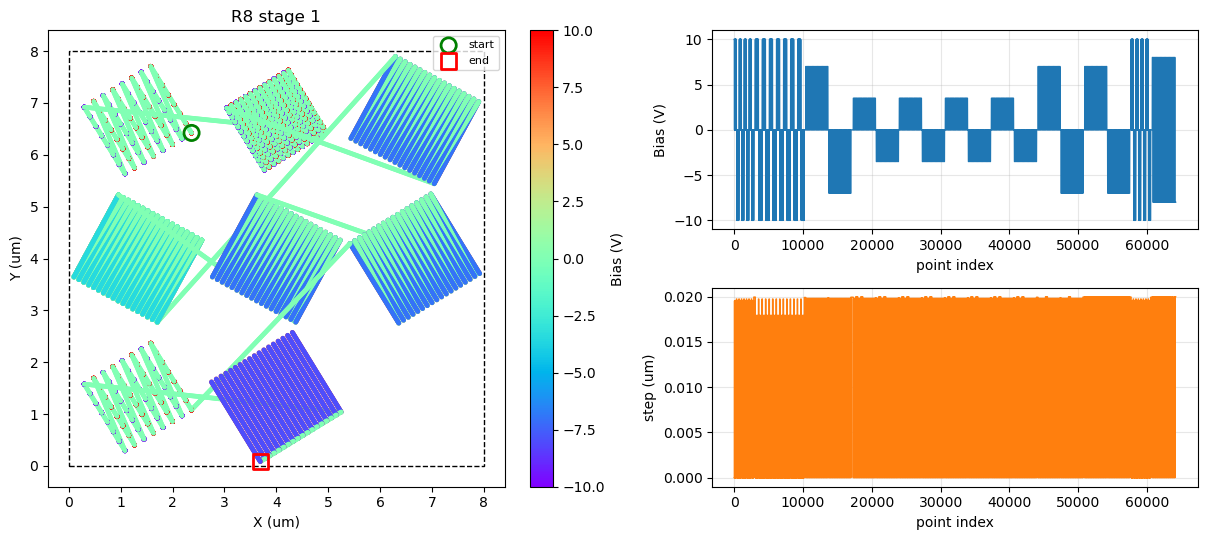

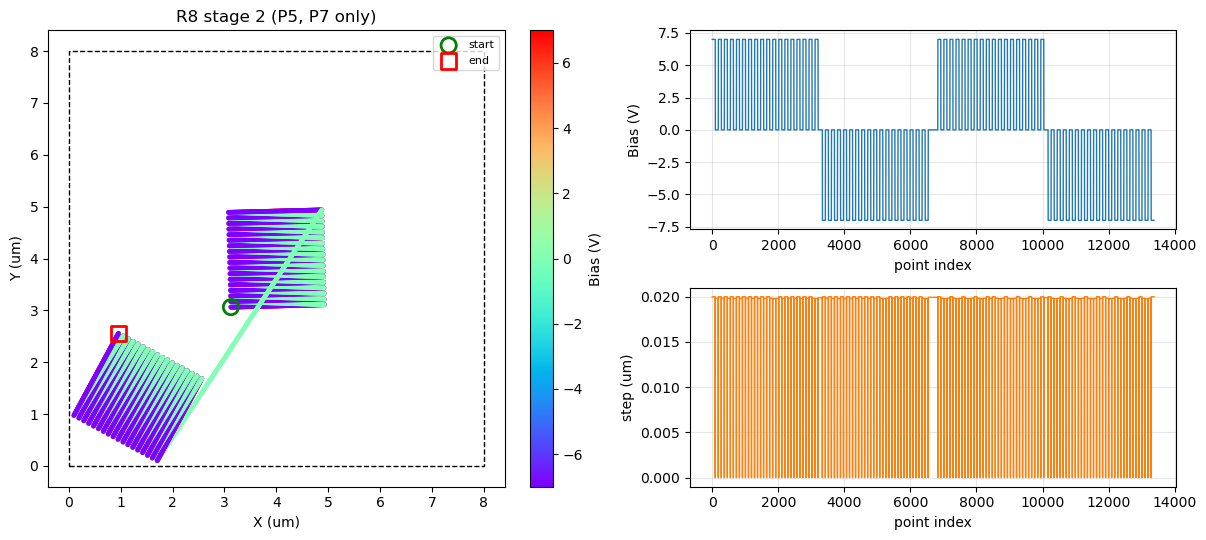

In [138]:
# --- [R8.0]  fresh area, baseline, and all the actuator files ----------
FRAME, PX, RATE = 8.0, 256, 1.0
XOFF_R8, YOFF_R8 = -15, -15       # >= 10 um from R7 at (+15, +15)
MOVED_MANUALLY_R8 = False
PREV_R8 = 'PZTO_LDART_0041.ibw'
V_PULSE, PULSE_N, SPEED = 10.0, 25, 0.5
V_RAST, V_TRAJ = 7.0, 8.0
R8_BOX = 1.8

if XOFF_R8 is not None or YOFF_R8 is not None:
    print(f'scan offset -> ({XOFF_R8}, {YOFF_R8}) um')
elif MOVED_MANUALLY_R8:
    print('stage moved by hand; the height check below is the only evidence')
else:
    print('!! no move requested. The R7 area holds four treated panels.')
_off = {}
if XOFF_R8 is not None: _off['xoff_um'] = XOFF_R8
if YOFF_R8 is not None: _off['yoff_um'] = YOFF_R8
setup_scan(size_um=FRAME, px=PX, rate=RATE, angle_deg=0.0, **_off)

goto_ldart()
LDART_CENTER, _tq = find_resonance('ldart')
print(f"  LDART_CENTER {LDART_CENTER/1e3:.0f} kHz, Q {_tq['Q']:.0f}")
goto_ldart()
f_r8_b1 = frame(); f_r8_b2 = frame()
contact_check(f_r8_b2)
try:
    _da, _ = ibw(f_r8_b2); _db, _ = ibw(PREV_R8)
    if _da[0].shape == _db[0].shape:
        _r = float(np.corrcoef(ndi.gaussian_filter(_da[0].astype(float), 1).ravel(),
                               ndi.gaussian_filter(_db[0].astype(float), 1).ravel())[0, 1])
        print(f'  height correlation with {PREV_R8}: r = {_r:+.3f}')
        if _r > 0.50:
            raise RuntimeError(f'r={_r:+.3f}: still the R7 area. Move first.')
        print('  -> new material confirmed')
except RuntimeError:
    raise
except Exception as _e:
    print(f'  overlap check skipped ({type(_e).__name__})')

_t = set_triad(f_r8_b2)
TRIAD = list(FAM)
_d, _h = ibw(f_r8_b2); _px = float(_h['ScanSize']) * 1e6 / _d[0].shape[0] * 1000.0
_S, _, _ = signed(_d)
_l = []
for _f in TRIAD:
    _v = period(_S, _px, _f)
    _l.append(float(_v[0]) if isinstance(_v, (tuple, list, np.ndarray)) else float(_v))
LAM_NM = float(np.nanmedian(_l))
SP_UM = 0.5 * LAM_NM / 1000.0

# 3 x 3 layout
_c = [FRAME/2 - 2.67, FRAME/2, FRAME/2 + 2.67]
NAMES = ['P1','P2','P3','P4','P5','P6','P7','P8','P9']
R8_C = {NAMES[3*i+j]: (_c[j], _c[2-i]) for i in range(3) for j in range(3)}
R8_CORE = {k: (v[0]-R8_BOX/2, v[0]+R8_BOX/2, v[1]-R8_BOX/2, v[1]+R8_BOX/2)
           for k, v in R8_C.items()}
_, _pk, _ = dir_power(f_r8_b2, R8_CORE['P9'], TRIAD[0])
M = float(min(TRIAD, key=lambda t: abs((_pk - t + 90) % 180 - 90)))
T_DEG = float(np.mod(M + 60.0, 180.0))
O_DEG = float(np.mod(M + 120.0, 180.0))
print(f'\n  Lambda {LAM_NM:.0f} nm   triad {[f"{t:.0f}" for t in TRIAD]}')
print(f'  virgin peak {_pk:.0f} -> M {M:.0f};  TARGET T {T_DEG:.0f};  other {O_DEG:.0f}')
R8_FLOOR = align_floor(f_r8_b1, f_r8_b2, list(R8_CORE.values()), [T_DEG]*9)
print(f'  temporal floor: mean {R8_FLOOR["mean"]:.3f}, max {R8_FLOOR["max"]:.3f}')

def _uv(deg):
    t = np.deg2rad(deg)
    return np.array([np.cos(t), np.sin(t)]), np.array([-np.sin(t), np.cos(t)])

def add_raster(tb, panel, ang, volt, n_pair, pitch):
    """n_pair pairs of (+volt, -volt) passes along ang. Charge-balanced."""
    u, n = _uv(ang); c = np.array(R8_C[panel])
    nl = int(round(R8_BOX / pitch))
    nl += nl % 2
    offs = (np.arange(nl) - (nl - 1) / 2.0) * pitch
    for _ in range(n_pair):
        for sgn in (+1.0, -1.0):
            for o in offs:
                p0 = c + o * n - (R8_BOX/2) * u
                p1 = c + o * n + (R8_BOX/2) * u
                tb.stroke(np.array([p0, p1]), sgn * volt)
    return nl * 2 * n_pair * R8_BOX          # path length um

def add_lattice(tb, panel, ang, spacing):
    u, n = _uv(ang); c = np.array(R8_C[panel])
    af = abs(np.cos(np.deg2rad(ang))) + abs(np.sin(np.deg2rad(ang)))
    ns = 2 * int(round((R8_BOX / (spacing * af) + 1) / 2))
    idx = np.arange(ns) - (ns - 1) / 2.0
    sites = []
    for bi, b in enumerate(idx):
        sgn = +1.0 if bi % 2 == 0 else -1.0
        for a in idx:
            p = c + a * spacing * u + b * spacing * n
            sites.append((p[0], p[1], sgn * V_PULSE))
    v = np.array([s[2] for s in sites])
    assert abs(v.mean()) < 1e-9, f'{panel} lattice carries net DC'
    for (x0, y0, v0) in sites:
        tb.dwell((x0, y0), v0, n=PULSE_N)
    return ns

def add_traj(tb, panel, ang, pitch):
    u, n = _uv(ang); c = np.array(R8_C[panel])
    nl = int(round(R8_BOX / pitch)); nl += nl % 2
    offs = (np.arange(nl) - (nl - 1) / 2.0) * pitch
    for o in offs:
        p0 = c + o * n - (R8_BOX/2) * u
        p1 = c + o * n + (R8_BOX/2) * u
        tb.stroke(np.array([p0, p1]), +V_TRAJ)
        tb.stroke(np.array([p1, p0]), -V_TRAJ)
    return nl

RP = 0.25 * LAM_NM / 1000.0        # raster / trajectory pitch
tb1 = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
tb2 = TrajectoryBuilder(field_um=FRAME, step_um=0.02, travel_v=0.0)
R8_PLAN = {}
R8_PLAN['P1'] = f'lattice @T {T_DEG:.0f}, Lam/2'
add_lattice(tb1, 'P1', T_DEG, SP_UM)
R8_PLAN['P2'] = f'lattice @T {T_DEG:.0f}, Lam/4'
add_lattice(tb1, 'P2', T_DEG, SP_UM/2)
R8_PLAN['P3'] = f'raster ||M {M:.0f}, +-{V_RAST:.1f} V x1'
add_raster(tb1, 'P3', M, V_RAST, 1, RP)
R8_PLAN['P4'] = f'raster ||M {M:.0f}, +-{V_RAST/2:.1f} V x4'
add_raster(tb1, 'P4', M, V_RAST/2, 4, RP)
R8_PLAN['P5'] = f'raster ||M {M:.0f} THEN ||{O_DEG:.0f}'
add_raster(tb1, 'P5', M, V_RAST, 1, RP)
add_raster(tb2, 'P5', O_DEG, V_RAST, 1, RP)
R8_PLAN['P6'] = f'raster ||T {T_DEG:.0f}  (negative control)'
add_raster(tb1, 'P6', T_DEG, V_RAST, 1, RP)
R8_PLAN['P7'] = f'lattice @T THEN raster ||M {M:.0f}'
add_lattice(tb1, 'P7', T_DEG, SP_UM)
add_raster(tb2, 'P7', M, V_RAST, 1, RP)
R8_PLAN['P8'] = f'trajectory @T {T_DEG:.0f}, +out/-back'
add_traj(tb1, 'P8', T_DEG, RP)
R8_PLAN['P9'] = 'untouched control'

print(f'\n{"panel":6s}{"centre":>14s}   actuator')
for k in NAMES:
    print(f'  {k:4s}{f"({R8_C[k][0]:.2f},{R8_C[k][1]:.2f})":>14s}   {R8_PLAN[k]}')
F_S1 = os.path.join(CONFIG["work_dir"], "260814_R8_stage1.txt")
F_S2 = os.path.join(CONFIG["work_dir"], "260814_R8_stage2.txt")
tot = 0.0
for nm, tb in (('stage 1', tb1), ('stage 2', tb2)):
    x, y, v = tb.to_arrays(); mins = len(v)*0.02/SPEED/60; tot += mins
    print(f'\n  {nm}: {len(v):6d} pts  mean V {v.mean():+.5f}  {mins:5.1f} min'
          f'   X[{x.min():.2f},{x.max():.2f}] Y[{y.min():.2f},{y.max():.2f}]')
    assert abs(v.mean()) < 0.01, f'{nm} carries net DC'
    assert np.abs(v).max() <= V_MAX + 1e-9
    assert x.min() > 0.05 and x.max() < FRAME - 0.05
_gap = 2.67 - R8_BOX
print(f'\n  panel gap {_gap*1000:.0f} nm vs halo 625 nm -> cores clear of neighbours')
print(f'  box {R8_BOX*1000:.0f} nm = {R8_BOX*1000/LAM_NM:.1f} Lambda')
print(f'  writes {tot:.1f} min + 4 frames {4*PX/RATE/60:.1f} min '
      f'-> about {tot + 4*PX/RATE/60 + 5:.0f} min')
visualize_trajectory(tb=tb1, field_um=FRAME, title='R8 stage 1')
visualize_trajectory(tb=tb2, field_um=FRAME, title='R8 stage 2 (P5, P7 only)')


LDART ready
Wrote 64165 pts to 'output\260814_R8_stage1.txt'  (path length 1092.2 um, 612 strokes)
260814_R8_stage1.txt   saved 00:24:53
  64165 pts   X[0.097,7.920] Y[0.085,7.897] um
  |V| = [ 3.5  7.   8.  10. ]   mean(V) = +0.0000 V   46.2 % at 0 V
  path 1283 um  ->  42.8 min at 0.5 um/s


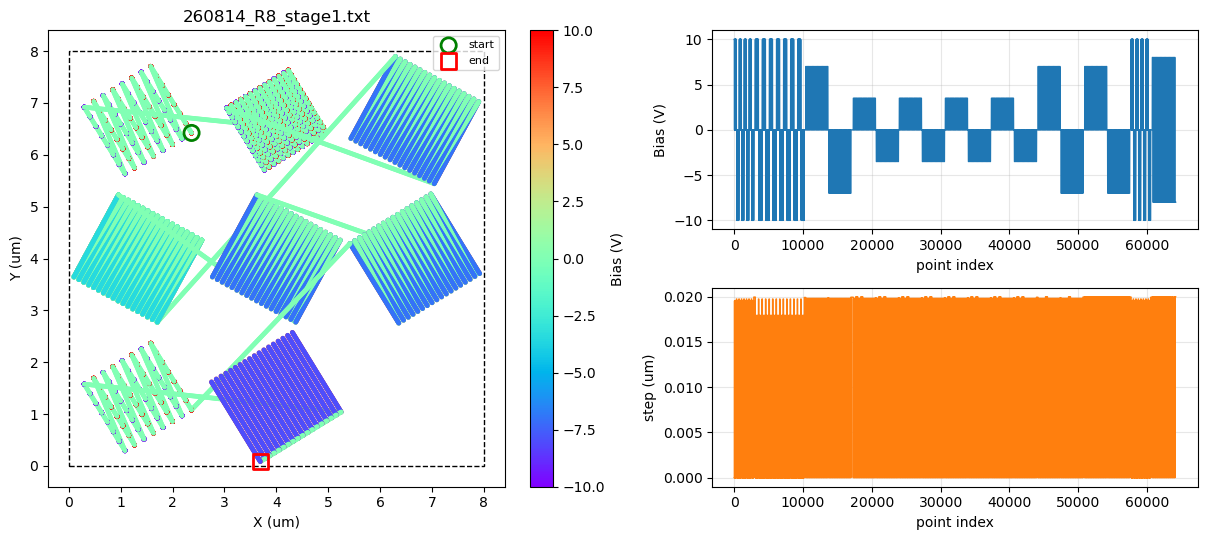

  running… ETA 42.8 min
  done 01:08:01
  litho stopped (required before the next run)
LDART ready
  -> PZTO_LDART_0044.ibw

=== after stage 1: power at T = 122 deg ===
panel                           actuator   before   after   delta         peak
  P1               lattice @T 122, Lam/2    0.308   0.218  -0.090   136->46    
  P2               lattice @T 122, Lam/4    0.284   0.429  +0.145   126->126   
  P3           raster ||M 62, +-7.0 V x1    0.399   0.543  +0.144   136->116   
  P4           raster ||M 62, +-3.5 V x4    0.484   0.330  -0.154   129->136   
  P5              raster ||M 62 THEN ||2    0.317   0.425  +0.108    64->126   
  P6  raster ||T 122  (negative control)    0.263   0.227  -0.036   136->59    
  P7       lattice @T THEN raster ||M 62    0.212   0.365  +0.153    91->121   
  P8       trajectory @T 122, +out/-back    0.413   0.323  -0.090   124->116   
  P9                   untouched control    0.263   0.360  +0.097    91->91    
  floor 0.029   P9 is untouched 

In [139]:
# --- [R8.1]  stage 1 ---------------------------------------------------
goto_ldart()
run_traj(tb1, F_S1, speed_um_s=SPEED)
t_r8_1 = time.time()
goto_ldart(); f_r8_1 = frame()
print(f'\n=== after stage 1: power at T = {T_DEG:.0f} deg ===')
print(f'{"panel":6s}{"actuator":>34s}{"before":>9s}{"after":>8s}{"delta":>8s}{"peak":>13s}')
for k in NAMES:
    rg = R8_CORE[k]
    w0, p0, _ = dir_power(f_r8_b2, rg, T_DEG)
    w1, p1, _ = dir_power(f_r8_1, rg, T_DEG)
    print(f'  {k:4s}{R8_PLAN[k]:>34s}{w0:9.3f}{w1:8.3f}{w1-w0:+8.3f}'
          f'{p0:6.0f}->{p1:<6.0f}')
print(f'  floor {R8_FLOOR["max"]:.3f}   P9 is untouched and should not move')
print('  P6 (raster along T) should go DOWN - if it does not, the readout is')
print('  responding to disturbance rather than to direction.')


  4.7 min since stage 1
LDART ready
Wrote 13379 pts to 'output\260814_R8_stage2.txt'  (path length 263.1 um, 72 strokes)
260814_R8_stage2.txt   saved 01:13:01
  13379 pts   X[0.097,4.924] Y[0.103,4.937] um
  |V| = [7.]   mean(V) = +0.0000 V   50.9 % at 0 V
  path 268 um  ->  8.9 min at 0.5 um/s


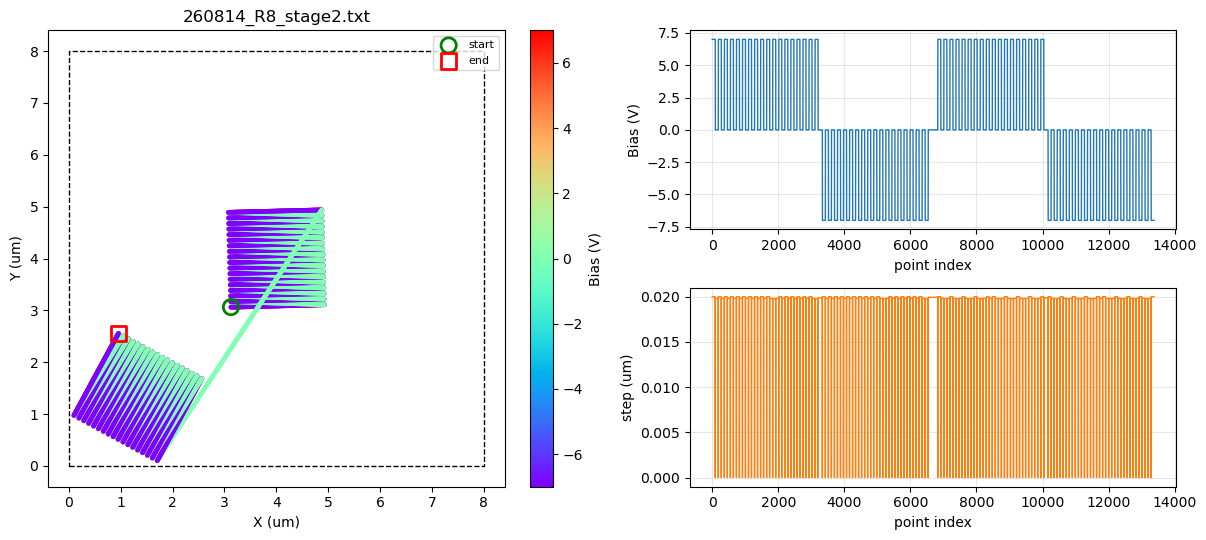

  running… ETA 8.9 min


In [ ]:
# --- [R8.2]  stage 2: second raster for P5 and P7 ---------------------
print(f'  {(time.time()-t_r8_1)/60:.1f} min since stage 1')
goto_ldart()
run_traj(tb2, F_S2, speed_um_s=SPEED)
goto_ldart(); f_r8_2 = frame()
goto_vdart()
_okv, _tv = tune_quality()
f_r8_2v = frame()
contact_check(f_r8_2)
print(f'\n  frames: baseline {f_r8_b2}, stage1 {f_r8_1}, stage2 {f_r8_2}')


In [ ]:
# --- [R8.3]  ranking: which actuator reconfigures best? ---------------
ST = [('virgin', f_r8_b2), ('stage1', f_r8_1), ('stage2', f_r8_2)]
print(f'M {M:.0f}   TARGET T {T_DEG:.0f}   other {O_DEG:.0f}   '
      f'floor {R8_FLOOR["max"]:.3f}\n')
print(f'{"panel":6s}{"actuator":>34s}' + ''.join(f'{s[0]:>9s}' for s in ST)
      + f'{"final dw@T":>11s}{"peak end":>10s}')
rows = []
for k in NAMES:
    rg = R8_CORE[k]
    w = [dir_power(f, rg, T_DEG)[0] for _, f in ST]
    pe = dir_power(ST[-1][1], rg, T_DEG)[1]
    rows.append((k, w[-1] - w[0], w[-1], pe))
    print(f'  {k:4s}{R8_PLAN[k]:>34s}' + ''.join(f'{x:9.3f}' for x in w)
          + f'{w[-1]-w[0]:+11.3f}{pe:10.0f}')

print(f'\n--- population vector at the end (w over the triad) ---')
print(f'{"panel":6s}' + ''.join(f'{"w(%.0f)"%t:>9s}' for t in TRIAD) + '   verdict')
for k in NAMES:
    rg = R8_CORE[k]
    wv = np.array([dir_power(f_r8_2, rg, t)[0] for t in TRIAD])
    wv = wv / wv.sum()
    it = int(np.argmin([abs((T_DEG - t + 90) % 180 - 90) for t in TRIAD]))
    v = ('TARGET dominant' if wv[it] > 0.55 else
         'target leading' if wv[it] == wv.max() else 'target not leading')
    print(f'  {k:4s}' + ''.join(f'{x:9.3f}' for x in wv) + f'   {v}')

print(f'\n--- RANKING by final power at T ---')
for i, (k, d, w, pe) in enumerate(sorted(rows, key=lambda r: -r[2]), 1):
    err = abs((pe - T_DEG + 90) % 180 - 90)
    print(f'  {i}. {k}  {R8_PLAN[k]:<34s} w@T {w:.3f}  delta {d:+.3f}  '
          f'peak err {err:.0f} deg')
p5 = dict((k, w) for k, _, w, _ in rows)['P5']
p3 = dict((k, w) for k, _, w, _ in rows)['P3']
p1 = dict((k, w) for k, _, w, _ in rows)['P1']
p6d = dict((k, d) for k, d, _, _ in rows)['P6']
p9d = dict((k, d) for k, d, _, _ in rows)['P9']
print(f'\n--- THE HYPOTHESES ---')
print(f'  negative control P6 (raster along T): {p6d:+.3f} '
      f'{"as predicted (down)" if p6d < -R8_FLOOR["max"] else "NOT down - treat the whole ranking with suspicion"}')
print(f'  untouched P9: {p9d:+.3f} '
      f'{"flat" if abs(p9d) < 3*R8_FLOOR["max"] else "MOVED - frame-wide drift"}')
print(f'  elimination  P5 {p5:.3f}  vs single raster P3 {p3:.3f}  '
      f'vs lattice P1 {p1:.3f}')
if p5 > max(p3, p1) + 3 * R8_FLOOR['max']:
    print('  => ELIMINATION IS THE CONTROL LAW. Two rasters beat both the single')
    print('     raster and the lattice. Next: verify all three targets, and')
    print('     measure retention of the eliminated state.')
elif abs(p5 - p3) < 3 * R8_FLOOR['max']:
    print('  => the second raster adds nothing. The destination is set locally,')
    print('     not by the raster sequence - consistent with R7 Q3 vs Q4.')
else:
    print('  => mixed. Read the population vectors above before concluding.')


---
## When to swap the probe and move area  `[SWAP-doc]`

**Yes, after `[3.2]` is a good break point** — and it is the best one in the plan.

`[1.x]` → `[2.x]` → `[3.x]` is a single chain that only makes sense with one tip
in one area: the ladder calibrates the pulse working point, the lattice uses that
point to erase, and Step 3 writes into the erased material and compares. Break
the chain anywhere inside it and the calibration no longer applies. Once `[3.2]`
has printed, the chain is closed and nothing downstream needs continuity —
`[4.1]` is written to start fresh with its own baseline.

**Do `[GATE.1]` and `[GATE.2]` before you swap, though.** The open orbit gate is
a property of the *sample*, so it survives a probe change — but it is perishable
in time, and writing into it needs a calibrated tip. That window is the one thing
here that cannot be recovered later.

### What a swap resets, and what must be re-measured

| Reset | Re-establish with |
|---|---|
| `LDART_CENTER` | `tune_quality()` first thing — read f₀ off the curve |
| absolute \|A\| scale, wall-density reference | a new `probe_fingerprint()` reference row |
| `CHANGE_FLOOR`, `REP_FLOOR` | `[0R.1]` in the new position |
| pulse working point `ERASE_V`, `ERASE_N` | a fresh `[1.1]`–`[1.4]`; the threshold depends on tip radius and conductivity |
| the orbit gate state | `orbit_balance()` on a VDART frame in the new area |

Cross-probe `|A|` comparisons are meaningless. The campaign learned this once
already, when a fixed-kernel structure tensor reported different in-plane order
for identical physics on a sharper tip.

### One correction to Step 3's comparison

`[3.2]` currently compares the erased-then-written result against "Step 0,
virgin". Step 0 was taken in a **different area** — the 10-hour drift moved the
stage entirely (height correlation −0.001). So that comparison is already
cross-area and weak. Use `[GATE.2]`'s write as the reference instead: same tip,
same area, same day, and the gate state is known. `[3.2]` will still print the
Step-0 row; treat it as historical, not as the control.

### Sequence

```
[GATE.1]  is the gate still open?                       4 min
[GATE.2]  write into gate-open material                 30 min   <- the campaign question
[1.3]     halo + per-pulse scoring (analysis only)
[1.4]     pick the working point
[2.1]-[2.3]  erase lattice, spacing set by the HALO      15 min
[3.1]-[3.2]  write into erased material                  30 min
------- swap the probe and move here -------
tune_quality -> set LDART_CENTER -> probe_fingerprint
[PROBE.1]  positive control on the fresh tip             5 min
[0R.1]     new baseline, new floors                      15 min
[4.1]-[4.4]  the surround / scale test                   26 min
```

In [ ]:
# --- [SWAP]  run this right after fitting a new probe ------------------
# Nothing below assumes any earlier value. It re-establishes every reference the
# analysis depends on, in the order they are needed.
PROBE_LOG.clear()
SURVEY = []
CHANGE_FLOOR = None
SETPOINT_TRIES = 0
print('cleared PROBE_LOG, SURVEY, CHANGE_FLOOR, SETPOINT_TRIES')

# 1. contact resonance of the NEW tip -> LDART_CENTER
ok_t, tq = tune_quality()
LDART_CENTER = round(tq['f0'] / 1e3) * 1e3
print(f"\n  LDART_CENTER set to {LDART_CENTER/1e3:.0f} kHz from the measured f0")
print(f"  Q = {tq['Q']:.0f}" + ('  (low Q: raise the deflection setpoint)'
                                if np.isfinite(tq['Q']) and tq['Q'] < 10 else ''))

# 2. geometry, then one frame to anchor the fingerprint
setup_scan(size_um=5.0, px=256, rate=1.0, angle_deg=0.0)
goto_ldart()
f_new = frame()
contact_check(f_new)
probe_fingerprint(f_new, note='NEW PROBE, reference row')

# 3. the orbit gate in the new area
goto_vdart()
f_new_v = frame()
g_new = orbit_balance(f_new_v)
print('\n  next: [PROBE.1] to confirm the new tip is electrically sound, then '
      '[0R.1]\n  to set REP_FLOOR and CHANGE_FLOOR here, then [4.1].')


---
## Step 4 — Hypothesis (a): does the surround control the centre?  (~35 min)  `[STEP4-doc]`

This is the part of hypothesis (a) that survives Step 0 either way. Every write
in the campaign has been 2–4 µm across, comparable to the pinning correlation
length itself, so we have never written something *smaller* than the surround it
has to overcome.

Three writes on one fresh 5 µm frame, imaged between each:

| | Location | Write | Role |
|---|---|---|---|
| 4A | x ≈ 1.4 µm | 1.0 × 1.0 µm core at 90° | small write, never surrounded — the control |
| 4B | x ≈ 3.6 µm | 1.0 × 1.0 µm core at 90° | identical small write |
| 4C | flanking 4B | two bands at x = 3.6 ± [0.51, 1.29] µm, `h_inner_um=1.0` | co-writes the surround only, leaving the core undosed |

Because the stripes of the 90° family run along y, the neighbours that must
reorient for the core's family to change are the ones adjacent across **x** —
so 4C writes two bands flanking the core in x rather than a full ring. That is
what `h_inner_um` produces at this angle, and it is the physically relevant
surround. Verified: zero biased points land on 4B's core, so any change there
after 4C comes from the flanks and not from extra dose on the core.

Both cores get the identical recipe, so the only difference between them is
whether their surround was written afterwards.

**If 4B's core jumps toward 90° after 4C while 4A's does not**, the surround
controls the centre and the strong form of hypothesis (a) is confirmed — a small
write cannot hold against an unwritten neighbourhood, and every future pattern
needs its surround co-written.

In [ ]:
# --- [4.1]  move to fresh material, baseline ---------------------------
setup_scan(size_um=5.0, px=256, rate=1.0, angle_deg=0.0)
goto_ldart()
f4_base = frame()

A_CORE = (1.05, 1.75, 2.15, 2.85)     # 0.7 um square inside 4A's 1x1 core
B_CORE = (3.25, 3.95, 2.15, 2.85)     # same inside 4B's core
score(f4_base, '4 base A-core', A_CORE)
score(f4_base, '4 base B-core', B_CORE)


In [ ]:
# --- [4.2]  the two small cores ----------------------------------------
for lab, cx in (('4A', 1.4), ('4B', 3.6)):
    tb = gen_center_out_raster(W_um=1.0, H_um=even_cycles(1.0, 0.02),
                               pitch_um=0.02, angle_deg=90.0,
                               center_um=(cx, 2.5), v=-7.0,
                               flip_each_cycle=True, within_cycle='same',
                               field_um=5.0, step_um=0.02, n_pt=10)
    run_traj(tb, os.path.join(CONFIG["work_dir"], f"260813_S4_{lab}_core.txt"),
             speed_um_s=0.5, preview=(lab == '4A'))

f4_cores = frame()
score(f4_cores, '4 cores A-core', A_CORE)
score(f4_cores, '4 cores B-core', B_CORE)


In [ ]:
# --- [4.3]  co-write ONLY the surround of 4B ---------------------------
tb4c = gen_center_out_raster(W_um=1.0, H_um=2.6, pitch_um=0.02, angle_deg=90.0,
                             center_um=(3.6, 2.5), v=-7.0, h_inner_um=1.0,
                             flip_each_cycle=True, within_cycle='same',
                             field_um=5.0, step_um=0.02, n_pt=10)
run_traj(tb4c, os.path.join(CONFIG["work_dir"], "260813_S4_4B_surround.txt"),
         speed_um_s=0.5)
f4_sur = frame()


In [ ]:
# --- [4.4]  did the surround change the centre? ------------------------
score(f4_sur, '4 surr A-core', A_CORE)
score(f4_sur, '4 surr B-core', B_CORE)

g = lambda lab: [r for r in SESSION if r['label'] == lab][0]
rows = [('4A (never surrounded)', '4 base A-core', '4 cores A-core', '4 surr A-core'),
        ('4B (surround added)',   '4 base B-core', '4 cores B-core', '4 surr B-core')]
print(f"{'':24s}{'w90 base':>10s}{'after core':>12s}{'after surround':>16s}"
      f"{'dw90 from surround':>21s}")
d = {}
for name, kb, kc, ks in rows:
    b, c, s = g(kb), g(kc), g(ks)
    d[name] = s['w'][1] - c['w'][1]
    print(f"{name:24s}{b['w'][1]:10.3f}{c['w'][1]:12.3f}{s['w'][1]:16.3f}"
          f"{d[name]:+21.3f}")
rep = max([g(k)['rep'] for _, *ks in rows for k in ks] + [REP_FLOOR])
delta = d['4B (surround added)'] - d['4A (never surrounded)']
print(f"\n  repeatability {rep:.3f}; the 0.7 um scoring box holds only ~2 "
      f"lamellar periods, so treat anything under {3*rep:.3f} as noise")
if delta > 3 * rep:
    print(f'  -> THE SURROUND CONTROLS THE CENTRE ({delta:+.3f}). Strong form of '
          'hypothesis (a) confirmed: co-write the surround in every future pattern.')
else:
    print(f'  -> no surround effect beyond noise ({delta:+.3f}). A 1 um write '
          'holds on its own, so the pinning scale is below 1 um and patterns can '
          'be written independently.')
report()


---
## Step 5 — Hypothesis (b): a zero-DC AC trajectory  (~10 min, only if time)  `[STEP5-doc]`

Ranked last, and here is the honest reason: this was already tried three times on
7 August as a raster and it never randomised anything — the peak stayed at 90°
and w₉₀ only eroded 0.575 → 0.511 → 0.369 → 0.382, i.e. the state relaxed toward
the local attractor rather than toward equipartition. And every DC offset re-poled
(+3 V → 28 % up-orbit, −3 V → 66 %).

So if it is worth one attempt, it is with the two changes that address those
failures directly:

- **exactly zero DC**, so it cannot pole;
- **a path with no net direction** — a dense spiral rather than a raster — so the
  agitation itself carries no directional bias. This is the same argument that
  makes the triangular pulse lattice preferable to a square one.

`generate_spiral_trajectory` already does exactly this: `v_offset=0` gives zero
DC, and `k` sets how many times the bias reverses per radian. We choose `k` so
the bias flips about every Λ/2 of arc length at mid-radius.

If this does erase, it is a much cheaper eraser than the pulse lattice, so it is
worth knowing. If it behaves like the 7 August rasters, hypothesis (b) is closed.

In [ ]:
# --- [5.1]  dense zero-DC AC spiral ------------------------------------
# Arc length per radian is ~r, so a bias half-period of LAM/2 at mid-radius
# r_mid needs k = pi * r_mid / (LAM/2).
LAM_um   = 0.35
R_MAX    = 1.75          # keeps the spiral inside a 5 um field with margin
TURNS    = 40
r_mid    = R_MAX / 2
k_spiral = float(np.pi * r_mid / (LAM_um / 2))

# n_points chosen for ~20 nm steps: spiral length ~ 0.5 * R_MAX * theta_max
theta_max = TURNS * 2 * np.pi
L_path    = 0.5 * R_MAX * theta_max
n_pts     = int(L_path / 0.02)
print(f'spiral: {TURNS} turns, r_max {R_MAX} um, turn spacing '
      f'{R_MAX/TURNS*1000:.0f} nm')
print(f'  k = {k_spiral:.1f} -> bias half-period ~{LAM_um/2*1000:.0f} nm of arc '
      f'at r = {r_mid:.2f} um')
print(f'  path {L_path:.0f} um, {n_pts} pts -> {n_pts*0.02/0.5/60:.1f} min '
      f'at 0.5 um/s')

f5 = os.path.join(CONFIG["work_dir"], "260813_S5_acspiral.txt")
x5, y5, v5 = generate_spiral_trajectory(
    turns=TURNS, n_points=n_pts, k=k_spiral, offset=0.0,
    v_amplitude=10.0, v_offset=0.0,         # full range; zero DC cannot pole
    field_um=5.0, max_radius_um=R_MAX, filename=f5, plot=True)
print(f'\n  mean bias over the path {v5.mean():+.4f} V   '
      f'(must be ~0; anything above 0.05 V will pole)')
assert np.max(np.abs(v5)) <= V_MAX + 1e-9, 'spiral exceeds the 10 V ceiling'
print(f'  peak |V| {np.max(np.abs(v5)):.2f} V of {V_MAX} V allowed')
# This is a one-shot test of hypothesis (b), so it runs at the full amplitude:
# if a zero-DC isotropic AC path cannot erase at 10 V, it will not at 6 V, and
# the 7 August rasters that failed were only at 5-6 V AC.


In [ ]:
# --- [5.2]  run it, image, score ---------------------------------------
_ig = os.path.abspath(f5).replace("\\", "\\\\")
ae.write_spm(commands=f'TL_LoadBuildPy("{_ig}")')
ae.write_spm(commands='TL_RunPy(0.5, 0, 0,  0)')
_dur = len(v5) * 0.02 / 0.5
print(f'running AC spiral, ETA {_dur/60:.1f} min')
time.sleep(_dur + 15)

goto_ldart()
f5_l = frame()
goto_vdart()
f5_v = frame()

r5 = score(f5_l, 'after AC spiral', CORE)
g5 = orbit_balance(f5_v); up5 = g5['frac']
print('\n--- AC SPIRAL vs THE PULSE LATTICE AS AN ERASER ---')
for lab in ('after erase E1', 'after AC spiral'):
    m = [r for r in SESSION if r['label'] == lab]
    if m:
        r = m[0]
        print(f"  {lab:18s} aniso {r['aniso']:6.1f}  "
              f"w=({r['w'][0]:.3f},{r['w'][1]:.3f},{r['w'][2]:.3f})  "
              f"max|w-1/3| {np.abs(r['w']-1/3).max():.3f}  walls {r['walls']:.3f}")
if (r5['aniso'] <= b1['aniso'] and
        np.abs(r5['w'] - 1/3).max() < max(0.05, REP_FLOOR) and
        0.20 <= up5 <= 0.80):
    print('\n  The AC spiral erases. It is far cheaper than the lattice — '
          'hypothesis (b) is revived, and this becomes the default eraser.')
else:
    print('\n  Behaves like the 7 August rasters. Hypothesis (b) closed; '
          'point pulses are the only isotropic eraser we have.')
report()


---
## Running log — findings and decisions  `[LOG]`

Filled in as the session proceeds. Paste the printed scorecards here so the
reasoning stays attached to the numbers.

| Step | Time | Result | Decision |
|---|---|---|---|
| 0 retention | | | |
| 1 ladder | | | |
| 2 erase | | | |
| 3 rewrite | | | |
| 4 surround | | | |
| 5 AC spiral | | | |

### Standing cautions for today

- **Frame ≥ 4 µm for all scoring.** A 2 µm frame holds ~5 lamellar periods and
  forced the estimator compromise that limited the last write-up.
- **VDART after anything that could pole.** No VDART was taken after the four
  7 August writes, so the out-of-plane state of the one successful switch is
  still unknown. Do not repeat that.
- **Watch |A| and `f_trk`.** |A| fell by a third within single sessions and
  LDART ran ~20 kHz off tune throughout. `score()` prints both; if |A| drops
  below 60 % of the baseline, retune before drawing conclusions from anything
  after that point.
- **Every trajectory is loaded immediately before it is run.** `run_traj` reads
  the file back from disk and prints its extent, polarity set and net DC before
  loading, so a stale file in the panel cannot go unnoticed.